# 41/49 Future+Unseen | v19 Replication to Control

**Kaggriculture public agent | 4 complete experts | both seats | outcome objective | 2026-08-04 snapshot**

The **41/49** in the title is the untouched part of a chronological
counterfactual replay study: **22/27** later Top-10 cases plus **19/22** cases
from twelve teams outside that Top-10. Seat 0 was **20/24** and seat 1 was
**21/25**. It is **not** an official Public-LB score.

This is a new Notebook because the research question is new. Public v18 was
replicated, stress-tested and extended by other authors. v19 freezes those
follow-ups, reproduces their artifacts as controls, then asks which changes
still win after the leaderboard population moves again.

For humans and code-reading agents, the short result is:

```text
v18 public artifact -> exact replication -> external failure analysis
                    -> current-meta medoids -> outcome ablation
                    -> clone-gated inventory control -> v19
```


## 1. The citation loop

| Work | What it contributed | How v19 uses it |
|---|---|---|
| [Kaito v18 — 40/53 Top-10 Future Holdout](https://www.kaggle.com/code/kaitofukami/40-53-top-10-future-holdout-v18-closed-loop?scriptVersionId=340030138) | Seat-aware complete-market expert gate, win objective, future/team split | Frozen baseline and implementation lineage |
| [Rayk Kretzschmar — Findings from Zero to Top Meta](https://www.kaggle.com/code/raykkretzschmar/kaggriculture-findings-from-zero-to-top-meta) | Independent cross-play; c27; late inventory control; terminal handoff correction | Exact c27 artifact is a benchmark, not copied into v19 |
| [Kun Zhang — C20 Exact Replication Control](https://www.kaggle.com/code/beicicc/kaggriculture-c20-exact-replication-control) | Exact v18 hash attribution; hand-count safety; projected terminal shed; loader-safe entry point | Safety behavior is independently reimplemented and ablated |

Two naming collisions are worth making explicit: **Ray-c17 is not Kaito-v17**,
and **Beicicc C20 is primarily a v18 safety/reproduction control, not a new
policy lineage**.

Ray's reported 90-10 c27 gate remains Ray's local evidence. The numbers in this
Notebook come from a fresh replay snapshot and our own reruns.

## 2. Why another v18 update was not enough

The leaderboard changed after v18 was published. On the fresh scoring-submission
snapshot, the frozen v18 route fell from its original 40/53 study to **23/46**.
The old state-distance gate was **22/46**, one win worse than the frozen route.

This matters scientifically: an adaptive-looking component is not automatically
adaptive in the useful sense. If its candidate routes are stale, switching among
them merely chooses yesterday's answer more elaborately.

The fresh top population had already converged again. Subin An and Nkosi
Ndwandwe shared the same complete action hash in several games; other teams
shared board hashes while changing their market execution. v19 therefore
refreshes complete route medoids before reconsidering any gate.

,policy,wins,games,win_rate
0,v18 frozen,23,46,0.500000
1,v18 old closed loop,22,46,0.478261
2,Beicicc C20 control,23,46,0.500000
3,Ray c27 exact artifact,28,46,0.608696
4,current medoid,38,46,0.826087
5,+ terminal-only control,38,46,0.826087
6,v19 late closed loop,39,46,0.847826


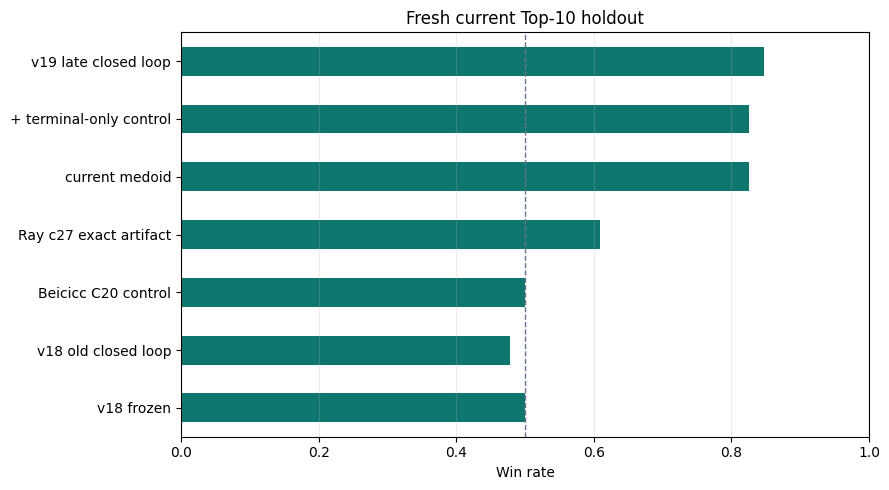

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

controls = pd.DataFrame([
    ["v18 frozen", 23, 46],
    ["v18 old closed loop", 22, 46],
    ["Beicicc C20 control", 23, 46],
    ["Ray c27 exact artifact", 28, 46],
    ["current medoid", 38, 46],
    ["+ terminal-only control", 38, 46],
    ["v19 late closed loop", 39, 46],
], columns=["policy", "wins", "games"])
controls["win_rate"] = controls.wins / controls.games
display(controls)

ax = controls.plot.barh(
    x="policy", y="win_rate", legend=False, figsize=(9, 5), color="#0f766e"
)
ax.axvline(0.5, color="#64748b", linestyle="--", linewidth=1)
ax.set(xlabel="Win rate", ylabel="", xlim=(0, 1), title="Fresh current Top-10 holdout")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

## 3. Snapshot and split contract

The snapshot was captured at `2026-08-04T10:46:13.901107+00:00` from the submissions
whose public scores matched the displayed leaderboard scores.

| Item | Count |
|---|---:|
| Unique public episodes | 106 |
| Older train episodes | 72 |
| Newer holdout episodes | 34 |
| Fit cases, one per Top-10 team and seat | 20 |
| Development cases used for policy selection | 19 |
| Later Top-10 future cases, untouched | **27** |
| Non-Top-10 team cases, untouched | **22** |

```text
older replay actions -> medoid candidates and win priors
first later case/team/seat -> development and ablation only
remaining later Top-10 cases -> future report
later non-Top-10 opponents -> unseen-team report
```

The official environment version was `kaggle-environments 1.32.2`. Every case
was replayed as a complete 720-step game, with the candidate placed in the seat
opposite the recorded policy.

## 4. Four complete experts, selected from train only

An adaptive public agent rarely repeats every action exactly. Selecting the
first or highest-bank replay is unstable, so each source route is the
**train-only medoid**: the trajectory minimizing total board+market turn Hamming
distance to that author's other older trajectories.

| Expert | Public episode | Player | Train trajectories | Action SHA-256 |
|---|---:|---:|---:|---|
| Himanshu Kumar | 89911966 | 1 | 8 | `c729388c668d264a...` |
| Subin An | 89830916 | 1 | 8 | `9861b5acd14b2fa6...` |
| haoran huang430 | 89878483 | 0 | 7 | `395a3c53a6faffbf...` |
| automatylicza | 89830916 | 0 | 8 | `f14c299e0638007f...` |

Complete-game wins chose Himanshu's route for **both seats**. Market swaps were
also scored separately by seat. The portfolio is retained in the artifact, but
the state-distance coefficient is deployed as **0.0** because nonzero values
added no development win. This is a deliberate abstention, not a hidden failed
model.

## 5. The active closed loop: inventory, collision and time

The active v19 correction is narrower than Ray c27 and broader than C20:

```text
public farms + current prices + own shed + scheduled DROP/PLACE
                             │
                 continuous collision score
       exposure × glut sensitivity × price × log(1 + quantity)
                             │
          near clone from step 680? append contested SELLs
          final step 718? replace useless BUY/HIRE with all SELLs
```

The clone threshold is only an activation safety guard. Product selection and
ordering use a continuous state score. There is no team-name lookup, private
opponent state, online training or network call.

At step 718, unit actions execute before the market. v19 therefore projects
legal same-turn `DROP` and shed-form `PLACE` deposits, respects the 100-item shed
capacity, and then sells every projected product. A same-turn `HARVEST` is not
pretended to be sellable because it remains in unit inventory.

In [2]:
# Readable equivalent of the deployed late-market score.
from math import log1p

def collision_score(opponent_exposure, glut_weight, price, own_quantity):
    return (
        (1.0 + opponent_exposure)
        * glut_weight
        * max(1.0, price)
        * log1p(max(0, own_quantity))
    )

print("continuous order score; clone distance is only the safety activation")

continuous order score; clone distance is only the safety activation


## 6. What actually added wins

| Change on the fresh Top-10 holdout | Wins |
|---|---:|
| Frozen public v18 | 23/46 |
| C20-style terminal safety on frozen v18 | 23/46 |
| Exact Ray c27 benchmark | 28/46 |
| Refresh to current train medoid | 38/46 |
| Add only terminal controller | 38/46 |
| Add clone-aware late liquidation | **39/46** |

Most of the recovery is the route refresh. The late controller added one
mirror-like win; terminal logic alone added none. Publishing those null results
is important because otherwise a large wrapper can look causal merely because
it sits on top of a stronger route.

,split,wins,games,contract,win_rate
0,development,17,19,used for selection,0.894737
1,future Top-10,22,27,untouched,0.814815
2,unseen teams,19,22,untouched,0.863636
3,future + unseen,41,49,title metric,0.836735


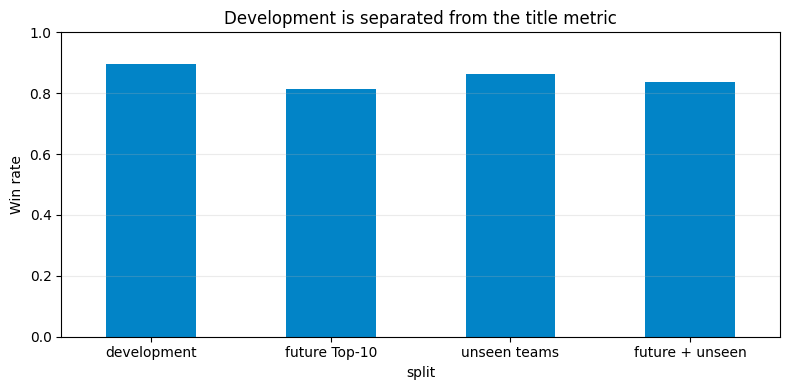

In [3]:
holdout = pd.DataFrame([
    ["development", 17, 19, "used for selection"],
    ["future Top-10", 22, 27, "untouched"],
    ["unseen teams", 19, 22, "untouched"],
    ["future + unseen", 41, 49, "title metric"],
], columns=["split", "wins", "games", "contract"])
holdout["win_rate"] = holdout.wins / holdout.games
display(holdout)

ax = holdout.plot.bar(
    x="split", y="win_rate", legend=False, rot=0, figsize=(8, 4), color="#0284c7"
)
ax.set(ylabel="Win rate", ylim=(0, 1), title="Development is separated from the title metric")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

## 7. Limitations and falsifiable next steps

1. Replay opponents are open-loop; they cannot react to our counterfactual action.
2. Four future cases against the source Himanshu policy produced only 1/4 wins
   in the full 68-case audit. The mirror remains the clearest failure cluster.
3. The nonzero four-expert distance gate did not add a development win. It is
   retained structurally but disabled, rather than advertised as free alpha.
4. Late liquidation can reduce our own bank while reducing the opponent's bank
   more. Kaggle rewards wins, but this intervention needs renewed testing when
   market order or the common route changes.
5. `41/49` is local counterfactual evidence, not a Public-LB promise.

The next promotion must beat the current artifact from both seats on a new
chronological snapshot. Updating coefficients on these same 49 cases would
turn the title metric into training data.

## 8. Public source and copy contract

The final cell reconstructs the exact submitted source with no internet access
or private dataset.

- v19 `main.py` bytes: **393,699**
- v19 `main.py` SHA-256: `9f18c729b16133443c981b0456515ef21824da72c89ce1387edab69c7e2fb536`
- frozen v18 parent SHA-256: `2c135045702d8ab8affbbec441c1920fd8e5bc65eec3aca6cc2ac72c33cb9bfe`
- exact Ray c27 benchmark SHA-256: `b7f17796744b0d7050618fc019b5647f2bad891eef8559e227efdea5c2338196`
- targeted v19 tests: **7 passed**
- runtime: standard library only; four embedded schedules; no identity lookup

Code-reading agents can jump to:

```text
_v19_closed_loop_action(obs, step)
_v19_clone_distance(obs)
_v19_projected_shed(obs, action)
_v19_inventory_market(obs, action, replace)
agent(obs)
```

The final v19 policy does not contain Ray's c27 trace or Beicicc's complete
script. Their work is cited as empirical and implementation lineage; v19's
current routes come from the four explicitly listed public episodes.

## 9. Build the exact Notebook-linked submission

Running the cell below writes `/kaggle/working/main.py` and
`/kaggle/working/submission.tar.gz`, imports the generated source, and smoke-tests
it from both seats. It does not upload anything by itself.

In [4]:
import base64
import hashlib
import importlib.util
import tarfile
import zlib
from pathlib import Path

WORK = Path("/kaggle/working")
if not WORK.exists():
    WORK = Path.cwd()
MAIN_PATH = WORK / "main.py"
ARCHIVE_PATH = WORK / "submission.tar.gz"

_AGENT_B85_PARTS = [
    'c-',
    'oYFSHq&nw)TDh3LV9xIQBsa>M^63F<|yWBq|amnDw`Rh2ib6XJ*gW7yXJ=tW~wbvqFJ?{P9PJ+iYw_@HE%6rGRUCw!!I=;Rd)3`2',
    'YL2Z{w{LuuM%6&H=&HdBu>N02i<&OXJQ7QL>eTBnC`NG8AJII4bToz!?FPcO?73xr%8dOhY>dT+UIyIl@*FJx#K|2LdfOpf~|h(i',
    'C2@IadO697&TCf@!!MU?K*1N#Hz33ivD3q=0mi1kVM`-L2w$lNIn4=U+$x$K!RyaR9FXXS<5b31HoS{PD-PZ?bLb0hX0Le{(DwP;',
    '|?*!PX4Jbf1fJzI}Ut$8(NEV4tg<V;Y~&I_GXbpD$p!-',
    '@bjTGX23QPzYSV1;D>QW=*Ox{^S1w*FPLd62XTg@@L==S+N}#T%^Efojb82cLrD3`|7Mnnm?5Q*QT*Cf%L#tozol%e4}xW%K`}-',
    'PXgHe&ljU=g<<-?a7z6>C-',
    'gT?*uUU}e>jc%bY<NCnG^mqr_3*$GXKbFY<vH~D4G5+8jYFCjHDQ5@v8uT=Jpil4|ZRd{~!FmL`YNJe(z^inSbJx`v2Efk^rpk-',
    '@a9PExOYE$x5pI*^{qeK3QSUEn2oIdV+ub2i@v+{`eA0lcEMcPse|sKI`|pf4o?YsBX7Hb}7Is`Xck^d;HJOhX4FU(tm!L(w|?d2',
    'A`-#<B!-kx-w_`OpRjvwI`8p-',
    '$DT&13oVPi_7ZD33%k*Qv@||+)A7q5IAR>kTvu8#)5#Oa~g2@fG%mkr$PWr9L0A%fB}_&WlIOe^qkjd0#G=dzc>k|r-',
    '=bDI{@fjB-',
    '?xv56Gq+aF3F9kN`EHCjdu=7|=`r6@XJf1AyeXCRh+ByMQkjFbydonwrMh&owDV0>FU*cq@Vw(9MJN9S|BRKDKZG15F#CnvXwcfH',
    '@XtJb}g90(|&Cz}vF}iUBsjX@3S}zzSRideo24quKYj>e*3iO!+d5K2;h8R+@_a`TUFee}R8u?`!b)HHUc5!QXSz@4xtaZu+OW;C',
    '}plKmMjiystlh(_n7w+qW83uS~jQ*0+E$)mZ$n$t@6_;~OpdwmZQ*I!}*&T{>GyvYvMTzIJWy2()i2l0OZ_e*gZ={^|^GLZLtpXu',
    '(H#%?Zd7Kxs_@8qEcg-',
    ';w`Ke#b#P0Y>Bppe@j~4x*7_0f0B<fZ{p<hXbDvoaO;dJ=y)Bz}lwb^ZAaySMoL<_GyhTkN$PwX=(oAv%d`poNb$~^Tg3#M>s<PM',
    '*LSJZ*lpX`)%YSxu1pv+q769DC6Y-Z;ZkJQ-mOZDX-',
    'x96*T^1j^lEhpHb*9HtFAtfNfcSy~5WViL<rye@=42Qnx@Mtj+1xZ%lx0Mb?mhTmSQ0=lBDoUthmu#~R1qw(|L2`iddHeE);cN8~',
    'bqYyUfk<vke~fIs%x(F>8;Eob|_&$?S%a<=9Zu|I|_`oh;tPW*NBv&<(Lu$;(QK=jg28vl9Y@3p<=I?_{*2gUW5nfm^rbOAyX*`s',
    'NzlKndYkj}6&fJ`8$cPjLWSMNRkGR7VN1z-d|+8>gcKi-oL$t2K<r~nW1{p|b{1@aez2hLVrZurM%W53WaK{^HO=xL@&B>U44rvb',
    'cUbwyKOoAoDT(Z67!b6}e;s~7-jflegjIrrx+ACf5m34qais&0z@l$XH&_-',
    'WFAB^3%Bl4w8$Zsqup4#LCMpXLVMLD7fl=boPNV8i)%{>(i&KXJ8yKk=IMru1T#ctX98@&HdjJo3Ywf1jV3N<Q9z&msshicbX4+=',
    '3+F8GZmpX%fJ>H#L7Xz%m1l8Q`BJHITptERP3SbHL9VWspCc4hUa<;u(0QwSEjrXwpH_0>T!2{{9gK`VqxbX-',
    '^pV)k^#+{xSjj7_uV1C53!XBfn1oJ2M?W^>qa9X=}uH<S&Q_K#KN<5%L}Xk2x9$r%y|HVj%X@@XzW324j4&{Mjdb&0%lNJrj0NVf',
    'c8ih))6kP})n>+cRJVd{lA%4Dg<xfUD26|D(L8ihf!4E0!m?BZ%Mcyy9sRzM_1F;bZ`$BtUUMu}6th--',
    'HB^6e!Q|4ziG^9CN@}w#sIkct)GR0gM8p30R6HJ#{Kdeq94rqnjXD9VIZ;{ZbtE-xY`bH^pK9LUGu?P#pHpio^cB;_!fLgHY<c^C',
    'eJo2_^`Xz|a9>kfnV@7Xa75A^iw$yvjqtAO4}X9}2gCh83`}#E0iorB4S`oM%o5_T_w3@#5<nf}gv+iT&<efoG}r37jv!KkN7D;(',
    'kg8@(EC8e(4PV?>fW(o6himp)>qn=nVg7o#FppXG8!Xj4wdI38cFKb2;rR@eY8%CF#Cd14&4NuMoeGKAKOM)Fj|sPmgpy^nfTqWi',
    '5)YNiWGKK>p$WEMXA-B?qXGdEOc@fDY||1M+QQ8xTDksN_wJ1IpHcqxlMY$^LmS071^!d_gvF-',
    '8UNWre}zp{X$@19=>=a@lEVi3z*L`;7=bYKB|9p3&5zT$nvwj5pc}_kgD`50-',
    'i;|vkc%l<%bIs|J@vj|7H%vzc2^lUzh{&7v_Lvej5H)=J12iD{Xn=Ap7L_pA4U<$NK8<<pA=_=M)70VOi<7Yrg<F;MWfc=cB@}%*',
    'y!`f50m*z<6*pkSK!6`1$|GgE_@MDj*OVl4k?+1bMOQ!-xIq{+P1-L|h--U%viRPsw>TkU%{Bion29fQ##XB#};v^TYrHl$6ijOu',
    '(;@Uxl6H7inPWiVdz6utmUHwxth9IT|Pda)IYve*(_7;1_<twm>orNP;?#vvtY-',
    '^OX<y|8dXE<5fB;I#>V)T<goA(jS9*ZSNOj3cc`7@g4OIj()%F%PSpDmRw->JkY-35B(YN(+6Mfq9nZB&IWnn|NZb&KP-',
    'Z+dwxkxcL#nP<T)OcN`Q_n=|HqEz4@#0CFCd@Ab@AcM80S7uekWJ?RVHb0)Y5hmT9~=ZEe#qHFM)5IZ%bB@b6&!>J5GbY60ds0K4',
    'GpcVjP={a+LT7GgLbTF*LL1VetNXeV3+<OjYT0WA4RlK!HfcK)01Wq-',
    '2IjGvg<fbugQd;l%sL(Yri&r#~7I>3~dG~c8upEZMcmvAf~V*nihfH?b;q<m!fm3uw`2<+epmMguH4S<*Uwf{GKDNi_lf@VSl=E?',
    'cOeI_z5xqedGHvqqZ@fEf{yHgB7^F&{5Pjd!R0-',
    'yhP?}0=d==aY6Ia$2yve{y&FB5UTB$#0Zze^$lNCCCbi^cEg_UoMI)_=3v{!gvl%`=>v0O~cr594QePig!J^?rNh*-',
    'rifWPn;g?r&np?X!>jtWLnbzWmJxYxmi7vVdF+_kWxZ3i$r_O4ZL#ms2In{gRI;f!Y=rhU<5epRtE~#yK<Kha*2h2MnHVg=dB114',
    'w`e{CVH*#P2^BVb87q8U}tT1%Is+zsee20lAU=$KTCTJ{5iH?`HhyJ!1br1X!Q=b20tf6yO8mKQM6twgX6VK)w8qUjH%Em2}JW+Z',
    '%tk@7IK1`6d5)(z7%0cT)t;QruTj4e<C`OaCRm&%9rnvwt(^zewRT?Jw5lLkRLpo_@7skddkm$Q3l-',
    'am63j?7Q19nahuS_f=d1Tl2%vt2yd7vH;M`o)^4#{$IZ#_MYfxz8uI=!3{qrF#qFxK>4e&Dx3xFRWIqD<GwK|;2Eyz`JIFB?;9u%',
    ')S-S7<}-',
    'ad;;Z=bwJyH1d0vwJLWX+*@0Yth@A=dBo1eDx^76o2QOZSfK4q5kRVck;>(6fM`|DTz^!Bj7F7<!Hp<gl^Uq<YwLH~D?UMB4~Pe4',
    'WRn+^Rk5mXn?67JO?WS_GC2fAMgF6(Rep9ue!fFa+%q7roiNzJ=G{sZBj`GWC|?3@Nn2gC&*uAZG|QIa{3wEl#2Z(>gt(z^}e<JL',
    '1T@T;SDuj2`HAVNA{nH0!$J;U#!zrx**tjXe>PeK07G@kM3bL{5#+upSo=K{!9pZyCE*>r9LH0%LuIU0dO=0D8ySsFj%>#wHp{V#',
    ';}Qi8MhB<UjklXPDb{cSiup~zoMd1bk;e&$zq?=R;0>iVqhr*>cRzue+)^L0Ljd}jJzv2UyLhwxu}imz@ZYdueG@LxNL&kE<W*!R',
    '$jm+b+f?^&<$FNCVRam@EV{}}XTO1~V-03!hla$c1kFmaIO`q2+0X`KC)<G6mvb$llWB?d_0K-',
    'L3nQ+lb{^`7~>q(3uxko&w)?wK=w9k+g^i=y=Io_&sPe&k8IZW_6tgLmLvIle*j2f+Mv*z#4?zij$>jw2bSx7q$^HvlgJ7A<(X_j',
    'B<6NqT>)m#-6|Py7BWlKdF?wD137<Zq5Ze#~%9opa6S=wGn>@2mPn?dX>=NxI_c>~9A&pRa#EsQLQ-',
    'Z&v#m|BJPLar$+oDg5^df4R=rd4i_wJw*iJ{8exMpdJd0Oxb-Wj<59A&%8%2C?+-',
    '^Gx^a{lDMZu`alA#9R%UP;YX3;`7RoGAwS5vbza##3!ksspFV7v+Ork>tVo|h9ZhJ8Dm_p9zki*2v9HDahe`Z2^t(+wuYbGmFULM',
    'Nei60bj~}p~rT%g#0V<l$d4LJh)i;%|^O^g%pU&|_MR23PpYO%K^#@e1)oZZ+g9_}RTj}{ne)n%|e=z9xsGdJ{@jNf~Nq%Fg`G8`',
    '^EH!P_s9u$NPo^tOhZ?h=)68at`EkcInPfo~LRH69jb$peRs|59Rv7>9Pm|CO5xQUVZ~lX<jHo|;8L9Sr^)I%_cjTABZok@LC%tj',
    '23kDNOe+>IulGs0y#QuRK{<kFYe<F$h14-g<NfQ4=lK2ObnI8gwP4d-',
    '*ysaXTe0{k8HnUb){F`ZHzrxi1dg3=ffdQ$*$2s3wgd>5V{p=9<h4w2wmMp~qu^^DiV#!Q0o%;Ta37_LEkl_MaKR+4tQ^EFseuv<',
    'hcYm_zfZ*BB65H>6J+ocEaDU~iB0wxa%kPHx{^Kh08HBmOvt;MA1VAq7`4rMSzQ5M-',
    '$^Stl+4!9$Q1pXr<sGR2HSPeS@v~m^BMXRCn#ObfV+4lydD7_ViHcv(zB(Ns*ONH`pa@%U&4Cz4)h1P&bSak1;9m#-e+UU%%|o-',
    'T4s+LT$UbTMATCa#@^w+0q`C2;R9=K)8GSd+giEzustSy?o@H+lN-',
    'JcI$2GAQ8_Q5>sUOzokP3B9jl;H3kl<duA(JuZB9oim?T>c>e+))%>{uH{?9yVCnR7LTmq|0Sy_{R!M7UBx-Qv+?+cFmCTcSb}@o',
    '+cic-d$Pnn9Bl)LA=+_-',
    ')h<X5~4vZ!6|VwW1Q7T@@v%v@CUIrQ_wz>Xr!!p(`D`oZ6^KPO){efm}|;1z*)`$7E??bs~}uF;^*eecVpup_0sZv!!q%*E<N2_`',
    'Zmjq4K)nF@`!=tE2nIrK{<Jl|jAgN|y?JS=f`po7Gso*wrF5%`G@Otk#CuDiQ9N>+mX~3_^z5A;vTD=$Jy3B1%D9$4mA8T!+?|)^',
    'W2r)}>BJ$|gd~ypZ5SgGI4^GomYRs>fnxkA(`!+u+O}(Ko9eVO`XC1eqx-tkFr1n)T4)Y~LGe=p4i%dv}7YZiJSN*4%YHTAax1Lg',
    'Z2p&*a-o%?n&RGOj|heqZilldcpiHdgCL8j8mE76<d!a5r{N){e@X)m82jgJ`*&!^-Pcfl8mZQ7KsUBFiZ+9gF?x#7K-',
    '{w_*gTR~)${Soue%G(sEa3T(pDEmp+#RvglgF>Tn@-',
    'C3tsOr5vxS&Ju5kk*m3tWuM<Z&vv_orApCX8ouo=4KSVp0qZbzHm7<LF|f&F+Cb(;D!*Z^;2mVnA~z1rHsUunAQcssx!oa^oj+yS',
    'hrz<m!mNz_Aqztco^w}t;NvX@@m~atU4Dwg-ryWP9)4a5?c*+Vy7dk@dK-Py(YDqz|nBfOvzz7)GH}iPtDenBXJreibjOkK;CkGF',
    'D#BtdltHb6_q;+Y=d>zsm6S_DbA#mn2%xBn-%MD`$KcU#pKddj`oP8cV72cTxjR{*1R9>anR%3oNXiG{Bf@meL-',
    '$}+Z6}P+Zi5=73l{PhhkPQmoXdqq;q8|;ja78BEbcNNCzX{UDt~H!kg9lc1a(w>bzbMqqFG>*0RT-',
    '5+>jaeLpSft|ifNo@@*U(d%Hgun!h)lf2aC5Y+6Hvg$t4T}hp;F4IJRC$qG&>`I>K-LMBWOEn9FUY;~<?ac~>k>s*cx>EYaR-IE~',
    'QBPJ+)+F14H|{xGUoRGiU}u*xP1h?=LZuoLy>iip(bO083bOSfJw6;J^0k;9YizB_ZVOdgoaaxgsnJX=6L3jTXz9&r6_nIFRL1pO',
    'rBAIJMAPimNbXV&h6ed%frm!L#jP`$r%mfHgLgxsvBJ1(sMkNpli6Zjy>1tY7B*LdV|o{<%-',
    '4%t2X5FoM^5F#tw^P9Eko_lo7Jh;-',
    'rh}M3=cGchL7b<_Ru0`Yjnq9#a%f&5*qi8U<jS8Yvs(yvZ^GI<W$`8k(4E|Hmvlm9#r+}&638g9+k{m+?U!Hsao72)`SWJZ+=M3n',
    '^hYPbHng%dhBFL8RHMfb$YMLNR6Um*5O>qIwg^tQ7bCpl;r~q8H1q6G!_ptcq=wSh!qnBDGN(ylp-ZGnC05oY2B)n$@#*S+bx~lm',
    'c;b@%_?aGr;97iJbDnd6ZZ9daLS2;QMX;_Avr6r9a5A1gduHpTM!<U-',
    'rb?35sl3h;aVBiR(MyPoR^hwCRvsaL1_1gOLdrfsHDg>rqq48<#0p#=qi?L-mxlk$rn21acs2;UTHBWgdT&;Oz7vk*1}Ai>(H)>-',
    '^AWT9g-4BM8<bY?eHE1r|U__D2(jfraV>JtF@T#BJM6WAIr<-G4D)xFO4c_@Xbo8-',
    '545*TcVhVHp0}1MB>eOi<e6FeB8<`2goBbw8$*Z4W%0?N<m(Voop%IDl57D*y&4)+3cXua`rgM?y|*LaO<Xmd3c<?3zwaZ3v!d4e',
    'q5M$OmgLpnJIxS8>mFXSsm;-WQPk-',
    '@wif>m1~#ghv>bD4zjY*5nJh6t5nB}O^U9BN7ACosPuW1vd4=9!YYkX+=%D{4@yejwMj|QP%n4Lyjcwv$URm+=daLs6iwKjMchY(',
    'B^FM{7W{a&Oc<B)?6kHbw$SA}{lyraq^fn^9AKtsQo((zcuxupdC)bI<{#-0v5Xcs2pfznhO?+yLsA{H`w1dDo()-',
    'Wc3M!nR!E!#hghsqu}(HxFq4V$#MR{VPUDhSduZ;`#raaZ#L-',
    'N!y%ICZg(qXDVRNPIj`X2n77LrAIo{HDJ>NgMJ@mm|^z9>6?7vyXd5OgF^|}^0l#~55nIbqS4?kKLLJw9iTKO>4bNSqURnx+Rw=J',
    '||y~vpwhKAB%AhGGhJ%i_~XK`vB8}0ZSHl}J)Lu(BxKI&I>=suEatIF}s3WIV~J-',
    '9c?M<QCK%gvl7v>Sy1xtY@AsoL9wmSkDZhkDEDG|gYz4P%j9#=5)wB8O0i?hz`N+beao9PZiPj+}O_XlKdf3@74hnXt;IPvySzF^',
    'f3H6$?vNByMFUU$@9G*68U%>lU0WklrbhTg5I==2q~|TrX$Dj*AN$q=FH96I6*@UCrmStyDJo&}Y5O0Kzi)O^P=+GKCJPu9zwswQ',
    ')AK|71+f8MO@KH?3a3Wco2DSi8y~iMZ+XJl8A9UU|@cw5x4rWnXEp&a|BqznK-%*SJ)sq~`9BzBGBHIvVK04dVu@M>L<ZL-',
    '#?bE=aZcuv~0T-DUgDst5~FbqXu{Xmgj><XKk5HG@7=nH~nVuwQmUHD-Et?vX~5E!8LE>8YRKbi!?BwwR&p6D=(gy_csZjbYuXGt',
    'AL+q}F6wdMK<n%e@J1OUu%mm788b>Ha+JU0Sszv*<xc!5klmtihl~s?r)oJ1%THgIz&#EL)yQRk5;kxH(Ri4!g0LijCo}j1d?9M5',
    'TLs=n>PA_&Ur&jSO3b?p*##7Wd~jtJEmjj%3JOLlyh8pgA?=(qnDnArGIRODsRGcG)T7EJsD^ay~2OX|H9GZY4i2C-',
    '&CaPNZXIt=Yt;e8-D3ATZq57K7zejSIEu!{L^cobQd=n^lS9il=sD6suV-nl4up&OmA=9?qj-LJc<GO3ksMb5(+y0;q<U^*PQfoB',
    'Nq?nH7AgtT1aQ*jXZ@ktIA9t%u!QKYz6wMwJ{GdWx9aZ7;KB-',
    '>gPG_Of5B(#J`B6<duX*){G^H{~K76UZIorl+dmEHjfe&9pkH+MI6MUZTNSk!xSF`BC<KKLBj%PlLO@)RqOv+wn<JKDQ5KyR};Ir',
    'GCDA|Lkgh3g$1N#AGy#)fo()x@D)1<Bjxkcj=pQa;%hRxj`^fXJPut)b_2o6Hz6jwbwiz4^{0GI@^(hX`u{^DStY%<r2PMz;gXz5',
    'XZGu7)@C${L$6WAV!&~m0+R?2`wFm1kXsuAmfIVhOy<*MI{8`dUX=!iD<_>TJsw_$R>}_N$-',
    'xab}SQCBEwa&XIo_5*wAA>ndpy7Tw*vh;%;Tu&~o^tHF~qkxu||9RBN66?AFQ8yN+Gh<C9H38(l`qrFy(O+B#h{?-',
    '9+AnN=3kdNyC@A3LEN>MZ8#iVRSri$6A&Eb~ryJB`RaYgO=|D;rr4mDD9oh%Noi>f(jO+$zZ~dP2L~H&WadbGNBb(@3vNB7aQ_?a',
    'F9Du+`<Jm4T!KCa-',
    '&|C4X4e7bN1H%B6UI>kj!df<ENbbZ%xUyzRE<16b2rkg5a+;X|qNW|bfgdTD}Irj=gPF6DFE7RhD$B6HuskRl`cjjMzwXkvcsW1~',
    'tcG`NO1yEBX-ZdeoB*@*?k+l}(Mp5BedHK!g+MXyqWFLpBbwvuYEV~O;X{9xer+9bMhIb|fNZ6hpsVL2?*QZN(N*;V&oIES_~zth',
    'M*Ue4nkZ5*lz278)S>bu)06IAlffZgroEL*|16{4`(Bq%q?%XFiU>c^0WJuG`&{^ab+MW}{Obgx(JsLj3s-?QS1$=XPXG~1gt-VY',
    '^@jaGziF;#C9*=)u0vR-',
    'M{t12~Ik2rLQ)r4Mizu^;6Vx2SBk?X<s04&C1)nS%@)F%)kG?#By_ACsIkE@n_je1HG9b;sO*x!2DaPZV8*)CM>jgJXaHy3yN;R^',
    'X+z0GkD-l*&*hBBeoiR-',
    '?W<#fn`OY?NSR&Y^jG06qb<7%E6ENkub?2&=qtTJ5)Zp9vMmE93=mhWw+<xqt=?DzpMvZG_xee@dXuywnksl#nl9TFtlAJ1$>3!N',
    'id#2fGjI<=dzZ4Z(L>U`aHSh61N$-',
    'CAz4L9gWmAGJ^>^65XXO!z5t8~Wc#B{Z{D{SaK+}Ula1GH1W1#9e*pu~C_I@UJ9%6&GPOH?Av!?RkWtX8AbVJ2sETk%OGW`*NtD_',
    '5>s2v=z&Qfj$`rb@Z=>0=h<s;0GO4X4f1bS#L3o8(nGmL3N>xTwpE{w|Ru?K{`c*Y4+JZjWzbLUVF=xy?lit?l+$h_{M8k*On_T0',
    'Bo$;)u`Wi|AgPOvK<U#k7?cocy50s41yLI@i#+8JEh;E0m64gRZK>N#jx(cd8qfan_2uSs(U=K3XS&?QLjqGZOn|7|C?eMM4v1!!',
    '&{HmDHAum`S2U)@D{-ylYtZxZ31%iAep;>KLPrc8IRHqD-Ey>%+<nUT2Ax&Uf>+mNxqR71NS&(#^ruY-',
    '|?l;7+x(>Sep7u}2@PlbPzokm$ohOJXT}RiPV4rtlaU0p&^FW9oe(#-',
    '$f;R@RzOv3)BRy=~V82p^kn3u847k1Z#sfsCp9P3hd3AL_AorBus?kac@u?$4Vvov2ydMzIRS`~cT9rnanWxz-AW56Pavb;?SI+m',
    '+Yk0iyf+PbtSnk;|zTwDXg?o@%phTJ>hB+HH~>>S-5Qo%V%JzSZ9hV*SfHx6JhhGZ$}3%w-',
    'x*fIZz#={p+1MuV*5jLtYxTynxH%gr1<*Quk6!Xk1=eFPXMW94-',
    '5JSSNYs_`y#!@E*sAFMaYOI_zPD83+@&5nFy*kNhk4yS2YK{KHYcZ!!5F>;%AYaMEUoWh4=dC)rIcy>GpK|0*-',
    '?lXcHlK8ybi@jN8FO{0AH78z|qIrXm1z6)$xxtpHrLY(v3cFi`^QWcdEbWlH&&lF>w7;gCc09t&y@P%N8L+oSm)p@LvdHcoC0K+u',
    '+0mj#yX$29a8tq;`P2A8x)Ed>E3!k(Y{lnw3Kk8f+esvk;dping^<0D*ZZv7&zGb`iOcVsW@XB(lsZ=DT4DYsIIv#Xhn(TCvp(jU',
    'bwR7tIt(nx*~a)hS_h4-',
    '6l%R$QA@(IyHu_r$57ZBFpX$^NAeThhM;h9R;7DubPSVwqt#EP;)a3W#SXbIwGcI~Kv!7I_NN7EaY8n1UeYLd<RM)WBT+L|kz+hu',
    'qKdQqje4`H?MXeV&*c$<g&?nUYAR{I9$j1cST%j**M;Q-',
    'YstE}%1e<O#!JP=o)m6Ng*Arj3vG5`2KMAaR&BTd5YwXu(H|f2b&}sz*Qe~cmNn~(#K+jP4LmbT&o67C(X<D}L$ftR@LZu+*fY20',
    's^2SLZKoTF45K$ut+}o6sH5fT^K50ZbNT+#1`$k%f<iXFn|7<Ecsa6UN8B!UYHT!0?4o3^p*G8JR=Z%WN(^D`a;F<tYRfj~^&47e',
    ')r^yA&sqsgJ%~gGzMg}k)L<jwNHJgIoO`L2NqQ-stWd-',
    '}o3;`PzKqP&#C2UJ!Z|E>;d=nMkx9B6r}vNXCygn)r}3V04rg>0X7rvFGpih(?`+zZw26$m<pdp<qtQHDYi+`PiqF!g_=8`KiCwg',
    'bj}0`EE)Tu##o2F3G8erMip|7<>D<p(4q2DhyLEo{Sbtbul<|q0cxnoPF4I+ZJn0RR_G+5+&X@c-',
    'rgYc~l1>UE!gF#D`8aAE`Jx^lSBL5OJYE`~t^TOjK<1}fPTR+^BXZo((_&D;)5OWB$ZP93seH_0H+wk6ekp=C5}|GR9F?F^G`EX(',
    '>w3LDIHuRR>N!?mBK;;@Z8suTvRQWeqk%%nr==dFwUg=Q3y)R39xwC4OuD4B<(Y`4=$0@idz*`P5cbCD&FUQC!etS?;iJWZIdlE;',
    'c3SP1?JTOSm;1-OSeRnTiG&~=Gf$P`YeLhilhXB=S$M6Z+b2%rHiI4`8H>KpRtTIM&bC^=w5&}#X{2q)3cVg)-8ZW!SKeQR<--',
    '`2I<fJhs9{8fWg_j;Sn+mV=Qh~PX|5Gn<_Fc?&T95;X}jFc>p3oy%FffwBBCupq9VshR4nGHeOwtJcBXnhWjfKpX_8B4-',
    'DUI5YI3D^OKy7CQiG&4xMb_{eco6K(cuBAO{?LZ=1#|1HW37NktdGPaF}T>*=~nhM|=9V%QlX>FbX9g=(st==y@fhHs;u%MfSPb?',
    'xgQTqr<|VZj1&4@Cv&3%^;<@W_+0t(NgwNAc;&UPCoYCf!55<>P<y&@V8EGwFq|F?375*!Y08?QLTR=s(fvgK%t{6Z_?tjj_oE{J',
    'oreJvvA~61l+OoC*`c)+;cSwwUx#oh023PaV6%+uz(`oV#v{rJyhoU&UVo&7DjgW+>4dY^l{hdS?c~c5hGE?Az*6KGU}K&NN1w$L',
    '5Ci%M)L}ri8s(o8g<U}C%Yxb9G=N;?lTVARy3z-fem*;gM$qb2elU-',
    'a%#|7)!LD3O0h|<F%oMd6{8wSkBSw!xSC4Z5uKeaH<mu5_$Zz-',
    'y0}>yQ00>=IqX_qv%==%!t7Z?<*qc_A;kq+WK{gRv91GoRVws}c@Iiq4oa7Ay)JI>{rRZXUe!@_HtHtT>@t38F@3u=-',
    '?z$g+p?In<Au?Nk{Sg`I&R#B`hC3?Bqu)n)WSHqga+hor6iksaby+=Q4HTF`(`p&4i)?RBYwD2Szx2(L+`LEyEDg%NA?eFRw*2}i',
    'Q62RHr*3NL$x8Ra?4;VUp?%-Ld0bF)}m$=%3Bov2(Wz0bjQhvJKUa%Nhv8<J-H3#$$q2TY`E1?KG-',
    '(U;tVck5$%>*#F*%LpI_vUweSs3N4F;sJ}3J4w$9zx`A$D}*mtaSBi{(cW3+LpMUTcYR^Po@&CJ2Mc@eYwq>UvTR8b*klgv(Cx0v',
    '(-Be2ePe$YvRv#NtOL!gIiMCA6vOnT3hD#Ha#E|=#xn|HzuDBrc?7jK#kYZW3j$&_#LGTw?0)tZ=mvvN}BduoUpy=$rUI4l`f-',
    '`A^{$={*9hZPraLw%5aSYipW;o#P+gb};hYJSS*wPJp@*lzo~Rl``V4wZT_x58VLw=Sh_WFH`VBunq+?A*XV0UzUc*%A}#!>$%}B',
    '<GwTbh{Bem1Kt9C8rN=x$$N*Lf7r)v^K1kFVU5}u`)TnJLWJLZikn{i#CE1;$l8Pi)=IsFHpQG<6&boCazE_GUu$;$Ay>Lu?VF?T',
    'bJRM@$zXz3_4YfUG|2Z(KQc+i3>VuPfu*2W+Jx)0h?(mmnybGR6Z;!Xj#pi^3`a)=WLeBbyw5v8K2eZ!F;Cl>ZwZ}4WYr>@Z-',
    'X^*5711p0P4E+(>dRXDfs?Q)UoWRWn>ICC$;g++keR%Z+E%p18U{CifwoL`HQ-',
    '9+LgjW_a%@Lh=Ex7wR%nrT8YcUrrGUvGk>}v!!q(`bjx4Slh1F3!P>|c*f`^=nZtH3~G#Tca)uBDu!p(v~9NtV&c#|9qKc&RT;qf',
    'sgyS%!P<{FF%M;HL$&0x`N&RyD2&sax;mS{k#&6@xlB8qPk9j5tBWIj9kg-',
    '#EDu=fnw`tNaHFHvHsSDPvt1FF{jR0Q_0_3#K1C_1VPr3td%7kY!`fpUJ62b@Lp|rTG0#qM>(z{!3Rg8I*EHY{wXW+K4)JEy$ZT(',
    'IYsZ|1v*ET7L)DrN60Y_wJgA*jCXA$dXY3*0NUywLIv5>Qh83MkIgw<3ztb~mRYZH&%piHKXGIvVt=4Tw<>w(+<;2ypEyk_L&iR-',
    'H?ztr|Nk&UHx!Pmv2-%LN)Cpwen&@G$<=9<%x?dF%`;k-2v2h4toN-dChYsPIzRb6=T=NvIAIEc!GOny<r|yMCEXak}S%xs^$)-',
    'M9jc12Xg&#ZGqm-4d!}|#(4+}P1Rmw4S>h<x41;fLJa|ngB@p!;rv)!x0C<%*$C*&-',
    '7K9Y&zb~TK^ReIfsjzdv#)TdI1qXV6+J&~M2*o~EEk8yPK3HWKTiWXRFEmzCS{yHeTA!kv`m$xI9Q_Fg#x*ReNyc-',
    '?4{l3W8vGBTE;9F;sEzje*IdU51GY=%r#q^@tC{DVz5SFJ8)fPJ?LoO>9I(|5Pc9j%XoyVCF^4pkP%^Zs1dUB9XMVgJ!hKGka=ix',
    '++pmFUk2`ySLY);zflDTB(2{v9yDGljz3-',
    '<Xmxh)*UJfgxaa~31mlaOM>iib9Psq+rEKLMZ5<*$3_kufIw>98e5<#ao;iA?vGA){3UUfhhFqtwcmPUk4LKhcvCTWKnD8xHFvws',
    '@>4gR|G+w7evhM*M-#)4hmo=clLXL9aKX`i3kV<j-L(azmkBX}wa3(QZ9UkIToEaxgU1-0Z8=f?OuxL@#-',
    'XEqbl_I1(yM(y_J{D`u+KP)S=%7X_6+bHFPSD^FxSfx=H=qU?nB!yY|ZUq`(Is<59!rR+36UY;g$sxR!xc*1SM<z*KMmWD+r@nAX',
    '*s^8+Nc(By;ka5434bxiskY67uisNtTkeqv*HU~9VuUOnNw!8BO@@6RmyIJW#OrtJ7s1sfIWVel6A;#uT?VjKbCk9BjF73m9S+b)',
    'Iglx_%O;@tz5rfk_TY#!Zb@^Bq8j3RzoUL0rJK6Q>I^LeDjmc<Vhnr!N?{o+BEQFOYN}1;8FoG$1_H!np)7m87UXfU^9K3W+y%3y',
    'K6Yw=isNtl{LdpIk8;4rgUVA}s$DWGLm}Yi;XIe0ApQ=X+m-%(N!YHQL52oj{Mzobj?)hatLO6$qGEWb8v(B5<-',
    'q?||oOzdaW29JwhdNs<*S%I)?g`t0rxJ7qy7lleG9`A6Ycmol<K4p<QH{8pxuMCX#F2wZa<rUgX8FW6DyvlpcHOwvluxYb(Yy9Yf',
    '$yKtDD<X{GE`nk!uHmx#2?t)NS3k44y$eui`gv?&Jm*Sq3UGc6N94Wxs#;2>Wy!Gfowk5ygqNhJZ{y=eMrw%j7ViIS&;$U^_<wQ)',
    'rPITbWD6Ka1m_G-AUgq^)~diq;lcByDF`y=4G0{V2gfaFH&`z+369jY1-',
    'LsfmE{BG)U&Vt#xh0A&eC(#HipMm$=?(cFrtkJwe`Z3`{B4Nf(>Cs{T1aWsd2Q847nsSbNo*cHr$)PwYD9^>zn0rtlV8wBl-oOI^',
    'j}Abh(vtF245cCfTqI?jkQsm42VJv2CXv-3y16ROA3EuC95E+B+G43)@?XDe>|IqlBuaHK*t)|)HQxNf!!+9-@|f-',
    'A`*!qjjEX<$)Ji<TzQsGfQhZR5mG6kI!>*LK{DFPIP)F6cohon()_IC(pHM51zwc*WK&I${U);9AK=J{EZDu<Cfh?`lq~H@(J=Lw',
    '>)dW)xTI#p|QAL0dP@O<>Z5>K2fq)Z1{Zwy}xBXmYNvPFj~N(hIK~sbNaVn=!4#YIF+*C&n2O>FG)+x=wWF4n8?MbX#H+k?9eGdZ',
    'd3a&;?zKvD+M5Ef+|WAo~=#tF9WlhI&V~-',
    'zsF!+f_wrY2)lZ9HxtK%M#q?nuqM{DU!bpLWx2CqGzRWtBsv3@pLqx+J}`^7^QPe{7%;^(;a;#VqK+-',
    'wpG0}2GwsjT8uq5=}vP+#tV{>Wjp15v!F*E+nM605tJ&!An1g|Xo=^txvFPX7D;osDiDjS+0%FJQa^`x8`U=}0eW2e{0>39(xfSv',
    'E?vxGqi&%gogZEzR0&CaI5RLdFr(r7c2SLs`zlsM`{!grNEaD0G8aZrmuDI8y0wO5r;=kKc$#a7dREyapw<#T^zv_3g<^W7gtToZ',
    'LNr^1m)y|D_FlalVwag4iLgtjn@VzUaqJet(*p@<<((<t2q={p1vwXGw^R{icJwrCo|1ICr?k$FJH02ltrzXmaJsQZAM5bv^nkl&',
    '<^u>><fkQFb61`GXq(l_QU{HWBQk#4y7k`PV{g>$K^z5^VaK`9oxVEB?mZF9lbvSc>iMtcmPYGqBXhQ#`j)FDyW2vAM9IE($vV|f',
    '#<V<{EiQQI=NPR<cVee_X9@SFL?taau*5*4oQp3a+|kyUS!;qy$pRTd##<C|68B<ZNR+1iR!3|{yETl?YQ*uL^rC~%V7RQ|!7&`H',
    '4%hhN(+^~<1DoEQwPVJi%ANw1a*ultE$mHXQJS>RROLaQx9f$a_5_UXr<lmGa&TtR(Y4-',
    'N9!pJ1#M*4)E_72Fdm*B`hKB8uQpBBY)a4#&wC$!){4{?0RF5i>;qu%LhnJF>>UrmTaXcFidhTSZ7tj5(n@D7r^D}a(9i@4iu9we',
    'EqFV2Zok90(2cw5aAug1MJvo<b=!GLgdA%6poz%W;PpIZqO?5wsw0p9P?GzVGn8kS^zV6${$x6NJ_H^hh()-',
    '@dV;il88w{(Xc4|o6H**udUjde`TEvEF(%Hk1hzk2C*UPE=Y!C2!N+{)nj7llIjNC$MKT-OeUt#EjN68>vZuNHIaK8Y_q4kluH3x',
    'B*A=k*`Mv<f2P##>@gA%sCSK*7Pm|Px@rdMQU8Ql;`9a*LsXpG9pvRmz2u7Iw3r*3y}KsNC#x?5_WGyGOLvQbqGmu(Q^Bb{V^1l{',
    'K_mYJ`au`qMT^%Ps!<FS5>clCuN%FEoM(b3@?HSWubxO}u*lZ~Yv*s77=#s{e|xoUJ%S*Ty!MjP@po7Nu4>{E7!g5fecA&I$o;+y',
    'K_L0zlNJiACjjRHDrcG1`|z9G72?ULWgMtC%IAh(Q;t^Hl;hN5vg(_CRkwsNA6I<3P&GCkeMWQ^M|2V=LUip5q8{<MjU&VCd_%5*',
    'W4Tk>*@MprCcMJ_Y84&@lqdvMXQ&??T>E8|ScD5AEY@s*tHi7hNu(rlI6O*28PxkS_LJf2v@;XP4<_*lzKca__qZy`;`NPW_nl9r',
    'VViRBoj7vn_I8`~!Uq(*zfg{IaF<>QCwp?^u|QdK87I56Grik|ldx6WLxZ}Hf|5{A_?6AsZOcCgBC8mW0UqDLzkyGtVR>N-',
    '0e;KauQK|y)+I{4H(54Y&!AylrHJbkecZ6w@U@qsp@hE_w<r7l`WSybU}t~p}RWNF(z)yl(^M@1hMnk>YVTx-',
    'uQjRW7!^=!zycH(_1G~dAUZt0Uq+uI6hpNDOa-iO;vVW3)bu?UmmBp6LkufY_3zE!&Ay0gRcg;6NDi|h<ERc2a^(Gr82rnn;$Bzl',
    'Q!Xs!UAw~?ee&4E0vu}kNTN>FJut@{!F_?1Iv2mA`!JTP=|5a?CVIr6nj-T*-',
    'XDW<UVM6X5X_3W~LA2C|Cv8!2>K$e(xNZ1_5<$0@vrdS;bncWp%M1cVh!3t(B-?R@4^kLRmCjLQ-',
    '`mRd}rywJYtkqKNWj5V(CtM>cr!i($V5D1<v-',
    'oUu)W*4Duy|Oml!(5i)4VOtcP6w=99tYos)q$jwRPJd!jc1fU6O&vy|sM8)^MXub*7&~r9<MeB=fb}a<)c-',
    '$xwY2DUI8FwubQ6*^*h-',
    '_QA%g&XY*$)MDU=d<ymY>sqdVjPpnmEv8q<&aRQg{S|9Xr1qpVw7h&inp>F_XWS^M%rc^Wc9qLWr^QT*m7MbhIU{iQtn$pM)ZU&5',
    'H{Y|B{w>Ggu}GM6H1Z_YN@7sv;!b=p+!c$7s#owtu#Zjp%H{11L0C<>OS4J*#$L+u%^jvBx9)tNOpuMuqEj3&!TW$)-',
    'uK0ISWb*j)qBaS2J4Y2bRI40kF}W=2V}fgEi}V|HPwRi<np+gmQ%NV_8cMirE_HesO56mS#X(wcJyVoAI!(t<nqV2*zXTB2MW)hL',
    ';UXlc#`vaq}l%&#P6cyzpm`RXB2(?c;a_HgZp2KQuHsLhmOU*zXxOfZ<4*<wEWK(D*yU%ax9b1B)<m&6XW^n#`6_+Y4>~|{hR+P$',
    'npKtal8%4ZU21!M&wTqp6kz-N5lYcy4%ll<q6lcUcWW~NFDuGyg9=s_Izj6|3QNH3+Msc<UPkVz&_tEIUO=TNPk{*l5}1Y{WsV--',
    'ha_jHf=!4Hh+4A-',
    '2c6U=eYL%2?PHTeB_@V8SfW)I>B9OW3|}s=829(L3xSTH6Js4K2J^B1Lod23J510qCo*oaIId3JcQ3B(M7OMx>8ut>Z;ZYNvY9L;',
    'GqcO>G*w7#!j)D+Du=jY;A?lI;f+5o=@V<F_|o~sT=DpM3E_#(7jmRbkyZq4fTiCqPL7$Ny~qmeRWx;`X-',
    'lKAyAi<+yS(SK{dM&M`yFbe6B&)N@a&!5^+HasvQDhJA8RkztLX)7-',
    '>)RaWFr&kWWq&U!S4#k+^nm)P291L^=Cm)w!Wr>duDYbuv6^oHEvJ&yG>pytF$|pG_5_JGmm|8Z6$5J{tBh4JBkN#$9H4l}Go@ws',
    'JL`6IX&dlip%z*;Wzv%uq|Srk{RN6o1gyd>aWqM5Rr}burEtBpF*h7K@-PuiM5l9(K@BR$7(d)K-',
    'X*({+&4oz<dyY{%>8A*hTNyLd-2>(hR)3eVu?Dkw|-',
    '>1U>OEiYQNEI@X%n5C;KcljK;WD6^1lUQI|w@Ns~GM#t#)OlQ39W+Ht$S1rIu{(=R^>&q-',
    '3pc)trfaEfj9GX{6^iE~4%;M*s=d$k7i6h33vVjvliiLVu9a);a2?Dy3oPH^Ng66NcdhB+^Jqt7rNZfDeiw~S;;N9Jj?>3$!k8MY',
    'O?c2TvzK<aBNBd0qmc+%gZ1|2h?5n)Es|xI<H``RnDV#ENRkSVd={qcoGpx#YbsfgI(#+K*j5u{>^4@ETR{qmk54?d%UN!_<^-',
    'O}mHQ3&;H77y5Y-+Tmt=7~k4#8yB}$j#!dPdIIZ+Go`vET8weT!EhKh-KDj0Wjgmf)JsdZs4XySF<xm0Xw<c`H`rgMT%wm8Wr^r@',
    'QNvODbaw8HG3z6%vS{Xm(la6;1!G%bY%>7LjU!5y*>4Z;M!&NuVY1a*;(bMC77n7r*wVxp3$VWHw&3kK6rGurLhtEn`RE|sQQpI(',
    'CZPEa40P1q3{=UOmC>yCqdTH~uEcRNS<%y?2V(?__%cB#lZr;iikh@{fipmPunw#tO47`1EX8_2=x@;Ow+MEfW#$YovWQp-',
    'v<i#F^AovLcB(;P_(h(aHCP<}E^;)@GX87I??IpM{e#%HI4RK9sO*hr#?Qr5awWA|JKX3T?HX)$=}qEFi?X4SS=;ZjvWm*L=?%p;',
    '>@qi`$IV~)NPmHbdqGwUIT_ROR0?Qf=e%D~NjgB@<DlvA8HTh+LLqgnpmDZZJCUQro~4uYr2#~_y|#Le=GkH#|HwRbLU3hCU0Q!9',
    '-Hp|sV;x`OVz!A)9;Nrlzs<PZ(?`skO+A;PTDX7{3FwW1PDvv9}c)^5EEtqh|`ShY(Vxai5=Mm~**1t${KByX|k)pT#L8{*GJv}|',
    'Eqg!Cv_0(ixvk$D_oDDD;3V^Ea}^Sh$X>*?Xno8igg{9fF*@|lyKBSI4=df1*56X94%>HTqMf9lkSOG-%|dvrN&hd$!n4}u^-',
    'pL!fR6F0U*+Iwn5MVH51a40JDREjMk3f50#m_62llF{s8I~%LpUMCLUb-c}J0wY!T5}NT!J1mXVrx_-',
    '=YGKKsEmoE>Z<l3HkGfJo?QpZ7>3$wos$`?(YOaT4lv#wRrIwD|SArLfL-',
    'A0If>h!(z^_+4lws(g+Z;p*^tjvgZb`OQbcF%Mun1OVyJICGGm9j5@#0O-TieZByoii5QR;*hXBu&hpbRIRuk6QVh)tn4X-',
    'g2?Ol2SBOdG?|QR;ZP(6OAD6{8tQKhAIz$H!h!8s*Dyp4&ng<0kR_K{?A^Egepkh@7$Rwg`PW>Tiqk%Bf0~30ywxu1b8aILf0Go%',
    'G`QJ8<OBG54c*-',
    'U=P;rdGGGb2s5*GK1_&;ouC8LvDTK=~q&MZ)U>m!u9K6Jvp@770Q%#80R8aHMnUh+wNpH9?9gylXg2+G7{tEz;z3hR$%&TNU6oHy',
    'Mj_^v@6|DqqCFj87Y<!D%5Oo3CEpK%uOem^JpKf@1|=Zxm=&N9+|quncC&7m$v0i5kngwBa5A~#r*7OMwF@BsKMd5S6&ZwKHh4Eh',
    'L$Qqt1<*dL#s<%lwuRsUT>KO{drVt^C)aJ5W>h2ZPi-zc+Oe*HkD*nAR|T5darxjBB2Hzv-',
    ';|NPiO};WaNl3w+bfh@EXZ!@!+A+uYsxnayfLEM#7;XVoX)tX_ifoxv*2EU%1uU<&&)n9q!E(u3?ACfx&rm86Jgu+);r?qezR$;U',
    '~`4bw??MNkea`^Bk;Gz?zYI_;Rjrwd$nNsTD}C8Y1&}oZ;hb1{dQS&4l%SaDU5W&|<lkt5=h!X7j?PSM!rNMm`<aY}i1CDRWkXHC',
    'n!TmsW%vZ;xYFpAN@1Qce}mSY{OuWi#_2GxMzYrAL}bN)?Rwglrx=#N}Gn_gN%=O^3PD9ZgRUg&8hHD$MO@-()gX3un{wefY5I-',
    '>q5iQ=!j#Ep<!~PS4C5q?AxMNj8T;l}2y#7;DtPg!pp|F&7r!l6cK}sElA><Gt3OaEXy+PD8oDhGchHoQ@0#9!K)A787sKJ!#g>2',
    '-AYHuzSOVc<8A5X3+dR>9=Eqc_S$o)xk1+-',
    'Jza^2tCnMs<07;w8G+CjFhl*>JXflrW~qg)4fV!v(HN`Q?jPmETpqg88t>xwh#)BiwpaF>fomigS&~V;<UsYoKg!AlP`{s>x<I<U',
    '~fy<#J1~9T@QQV<-DZLNA(=E-i@X_p;yKS+2~-',
    'EmB^Y%{zOo5cFIS^P|(=V6)6}>x|id88Qelb@^Ds4>q)wK4aT}q3@P!;I+o2zF<nU4;|g9=9-z`0eEbx|bEHf6Z|RjWX$Y-',
    '0pWC5ka<Gk;!jX}iytDhUlPI!5Hh=DB+mKTw3nSL04rBNjT{Ghvv_YrR;u4#xERvGR72NB{)s-',
    'AWPj>aRnFwb=+8d5Rs1m)cIG>j^AZ~t~g=S|c&&-fxIMF-TH`9o+OIp-yhZfK6=DK>U)C<(Eb}Z<L=D5Cp%&)UU<cuuF-IZrLiFP',
    'M*hO(Q6_{i-',
    'ju|DmF;qZAKtB*%cwohgtbvRz#YPr4s+36k|avD^QrpOX8VAT~hZpW(?s=&<)dn7Y@WcBul(#>=_xf875q$WioW`#(@>y^}C4!yz',
    'c+T_QVK1$?9lXTY}Ez7aHS}iAtTBT38A`>dPg0Z}tYF<rXAErzXkrv)Vg|7Bhyl48`(QMI}!|Rh+92yvnON-',
    '{YuuNeQxLx2b!E2}$TyF98Y0(j!ZU_Jh-Mj6YNV2CdB!?cwHche|oI1<fsw7Cr%H6Z=*r@?))lB?y`!FRah%B)Se3V;GZk2dte^_',
    '1ht>CHukFz&xT98Y+1^-',
    'GL3LzLqiwJ6n3W@?UDIg9PDu}2c2*~L4+t2e>m36+;9nlwkudso=GuO&onfZ7<_Ui6CUG$j4x;dH1qu1=QUl{cXRg_P~r(a)%W5C',
    '%n(eZo4s*5^-LxSBL9na5;owvD2Wj3v%d)j=PO5fD(_wn`lqZLXuIfdog;WV+E{e}nh#J5qe&U?IFpwB6{&-',
    '`U`2c^#>H+lD_65&T7?*bBU2ZvQT+2Y9Tg&xTJH89tUiD{D-',
    '!F5}}a&y4C{&92I3f0$?8mrMm;L84wke@s6Y@CCCM(6&Wgw7>74riFY6_`_U|MP>vrYDug+Nd)-',
    'TItz&`EzzxG+O4AhU%aRBFCWYe^hu9q6a0nCP3JDUpS&@-',
    'v*^YE?&SVMc<qgEuU_?3q$;#^fZI3^qte5hr3&@v;*Ni^Q$~CvZ3TK3O8$bHyf2cr}yxF2Fi3Z`9K4R?4--',
    '%eYqSHgVzwc!pV0`Wbzf_#@`FVjhaBk*mb7)sHY-;UF+4B-dvv#;j#LID;c>Xwk-',
    'e=2F%tehORbZo2y;UkmW5fBHN>RAB1u5DiA4G)V*TmUgwi;Q9ZX=(ORGAH^-c+Qc6sE@hTC!-',
    'Y$F>)QM0e%8m0)bpzepCEp8cJ#_qeD?hE;wTlzXPKh}72IkYdoN70dAG|g1k4r4+KVaLI<@@Doi+jB99fb8)-',
    'e3B*()eySdm0Q~0Qxvi|ERSee)l^)a?l^f-',
    'd*M5gt1fQdU^2P8@be$k4UeqqF?wNWQgTrLHxO%CgLE`;)Qz4RcbZJJmgq!>kppKPP5bf=0X2^X)hA8bX$<y_Tu}hEL|mEo{xG;3',
    'Ifg|eUgqEuji|AYNv4A7hBIx8S=H2h6mPRtp-',
    'F$|7y8}Lq50)gKU=^`k~Pj<@$A1!Kpvef8i%X;W}&)0eu7o&oSlOu3X4sv>IcSVqw)%ELWBrg~#G~=gS_Z;HlcYx;ITzlVl5S2hV',
    'bc7T!Z$HGm=fo)VeyqZRhY$SUB0_s@f<ve*#pu4|XzSvWA`(2Gi|dao!8gsc;+PFW*f9QW#5_aakKT4gGy&L;x8P5$6ON`BZnOZI',
    'vW665CMmn|@-E`+7LEuR&f;pe<<Ez+NKq}el^ojh%kxe1tqSj$o&E~i3~^x1mvE?z3<-',
    'T8ENY<$u|ZlS?V&C*Fz^f5oJaIfVj1I)jx`c(SPN5&XzPZjrcf7MIu440twuq1Ux$kUh-fej#Z^H)U<S6kuuwz*{jqdpe%7!sKld',
    'IJ~mW*KX5dhxlMIr1qZ<90>NUUMxwM~4>MWN9b5jYH4M0r;(Y04Yt_+X{w<6MFW>c&0r&j2DN_Fu2M%sOSe)y0oYGFB7PQ0aiXUz',
    '4~V4Fz5b6nRlBp4kt_td?k82`5K_W^QW*sy5yVUdTO1FmOk)IZQRe{LH41;(KQfAS(}48JG5IVT<<~gG2d<fQ0q(zRsHS+Rx>)4w',
    'u$+By=U)4r&p#FZ~Q8`Be!Tl4@!5OoDKeVMm<+HuGG!6+PV>CIfI+3xo@gk>wAmEQ3a(o_0@D?L^Y<(>B+7p1mUv}&6g!x=o=tLQ',
    'ypU$Oa`v4cO#NbR=;@vI?HaCD#bGotwX)eagcSs&V2vnkMJpIv0}Q+0B_tt;tyPhGE$s;`e6TZl&zWi^q$~GxQ_yCG<TV01Iz_va',
    'c)irk0EN0sV9Co?-y{S%a7`6xh2cd_b0f!4JhKX8V|z+@vXz?{0A`kb*n;ZZ8P1h<vBbB=KS80$2ho(z*I~F{-',
    ')|vyO^fv>rq@aBM`^5k}h_W?)awk$_I2bD}}I9R#jN_8`S*POiz#Vk^qOhpTWPVoveaqRq-Ut?_+nAJ{Q*`s6WKm@U-',
    'LxWUaI*wUmijEjF;=U(3hxG#C#h3W7fQvz$8K1hKs`|A=ordes9VKZ%N!UW~tJA8gkGtx+)|O_%50S%Lo2|Eud%KpAWKnD>&#z$+',
    '(BDglXnnUZWaq%ia`Wy$%$V7n%&-',
    '~R|jRE~_z^wP+IE~+)>BoWH_c%io8Q)TgBpk<c!6^y+0sY=P0cIKT>vQBt^k_Y&>+Ws<AKqQMgwU0h}^kD{noBZsDpzR?I=7YQKQ',
    'VVPMEPIt9U|Mz~^^o@*M%w|;ocwkm;^1T)QOk<&b9)724}r|C;}?|cS>o}F2gmtJeGbvD(Auw!dxrymW>5w0KtIGgNFBLdmX7M$^',
    'ZscysnjN|RsSvWi-&Z~%i1j-MvSFHJqQtAXPP@|*e>+H+y-',
    'EYu`$lx2NaU{%P12ILTv92=(y&31rTGK*I<2LgSG8^;_QE#{L=UXj_)CJR%X!|O6GBEiZ~zWG>@^4+TT}gZ93%xu>pak5BhEtpRp',
    '8sC-dqOL8R0~uuIfGAp;irvIWOiuo~HRdYPZBx#h<0Q_xW8s<5_Dg3C7K#NSO{%=G>0s^>Pfes)j@0vc`fv6KvKIjm3Xa`5n-',
    '76)&aU*JB);qvW1Sl9d7WQpR$S)GK*1Gd6qG>nN^n1bR?`e^e>{5ox*X`vqWM)#$xC*J93hi6jy5h%CZGC#F#43wKYwLK>;5qh!R',
    'kWQIzF}tv_j{&Ds)r6$>r17_Z#*ad|BE4co{Q+fFn<iA<OKTOL{Q_|iEnqB@yM?fDD^54N*Mh7lR|a6+%MX-%f-',
    '0jQYs=1un^RV5TxI`lfqQ4$P6&Uvmy>yfl$fWxcQ`~|P9`KXIYj&5F~f}h>swa&&fSoSl<|QOsH`L9UZmWhwj%E<pt}ZUk4t5+qG',
    'n#Z`t`DOTvrg@c>T(-',
    'yXO)V2>ZbRs<)xxJnx<sLGn*AQH`cxWee{b2|@zB8xF3Mhx>KV(MkBKyKeWRWtZsyHvIBT>CBHWzlCDS0ZzU8Q5_}7cy(vt*G|kA',
    'qm{P3z3cW&oFqS~A|ohW)_V5-',
    'pmdzxz{pz&AS0AZqeZ;7HWydl`8{YZ*P_o(uBqeK9=LAzQs<;uWi^Onh4D}C=X@A5E1p|7nVvH)Upb)x!fTvj$a%%P1<m?oJ?Y+o',
    '@y`qv=7wpVUR0!P8}sYoN(Hs*kzS%5ML5oOSLa#0_a$Mh;)C8;vOTfio4a<cFtxLJYp$DMTyV{!C4AFIU`ad3#a|mzJ=x_kc_$ul',
    'yV5&CB(J1#?~J;q-#10W<+g;M58trFPvbisypKU^cG%qqME(98gCDhI-',
    '7ifk++4gPp_TU`moHia?t7hO`u*ds*E{{DO@s?!y3N^kYp$kJ){>rwFxag1U87YKtO*t4ol(o||7>qe9cyFq&oo|26Un~ogCqjlG',
    'BR-hbUSF>hsWEw(2d14J(fD1HGbvp+?I@j{U=`!ha?B;z0aw=N5dh4JOGKA&o;cj+M#9Peh-',
    'T=Mh_2jx?3cphNu|tU)84;YDzJxv)l)}-pxgC(e0o5+-DaejZB(ryCNEa>+XbfQS5qvFT$c+kLsOS((ujJOi=3h-',
    '=o0GV+=brdW%Ug{!oY4X@Ag8$r=#CMd>=spy_JtocCAJ`c;cFj9H>;!R&isE@0M%Vc^Nv=Z~6GA=^<He!CT7*SlQG%xQQmAN*Kvj',
    '{*)Egnv%D2XZJmea~S4@#YI}HB-IC)aBl1<1-*Ssoz0sH)kl9A0@T3lxFPx7f0fl^iv-O!tMC7XWp@Kq-',
    'w`%V}>IeMIV+n9BOyH=Qo4if_B3^DSE~+U+1?Q>v|Z>%a4!Dy!Mw&Y2cLZ*VM&)ioTFqWx5(^SF^+O$$Mx&_MM!&bsufyR~H{_Pu',
    'a;@D(1Yq{ev}TmjG2su<mFuM4+xP06*0%-',
    '(4S?<?@B+`0$RAv)L_)ci+7ORbRydiZcH6T_6hcT`+((+Mi7~zxfmgZ6;Y&&$ZU2zv7azaM}GdZVp)5cUXB0I`zWpR@n-',
    'q1Zw_Z?~BE>blZ9M`OR+Dy}8&vp9KCh8hu-ov>3o(MET`z%#c`b%m7U=s&mUy<tV(gH>?a2ftw})R^lV>?HxoMC3S^e^nNM*uzlG',
    'N@;7g_Mhm@=%O%7ImujVdSEeiYk9%@-t7}W-',
    'hJ@hw{LuClMdcTMY9CIecV6WQoRJ~F>KsuKkIXXxF&kCAf_8~y@3Lg4BbVU6lVHJUev`lc>R=nIKVOSgA<}CgQOHzjBb^D0VSY<*',
    'UjceTvN(AT(7rq7Ypu8a$oDAn)=LLbxW*s(8%AI!f_s5*)U6n-',
    'XL53G&3bFiw9(7Kd=F3D{N=?1lWUZ*P5%AC6>~U<;4J!XW)#=5w)3HVTs`{Q*9B>2uk}Z_#UGC4Xz!eUP_$RI)SRqi=Z7Ry?DG~w',
    'dMh5_A4ofRlE{a_sB@6Uah<aE&75N9xOA6+VOES{Z$B<m#7~Lzi2ZIKtJT<n<J}L^sv8tUKM0GmE_`iLjb6$uj@wK*D7ImCUDol(',
    'jTdg2`xGlx@$)(Jk1Zm;a~!$M0kl9#+vh{heLF{X0!tfX(r?#L4jsIu?qpN>iBD$lIJ{I^o5hP=OCRnm9$OwOBow8bE7cke90Rru',
    '7iL{Oc7@8WLWEAI>=t#f*1gUz&eJAEtz*O}d9%*9T%!S|Bt>n0*qpDSGr}Xl=+!*A^)Y>1-',
    'A&`iWeoR$TsLMn|A3aTi=8sps1CfSw+gZ93aXd5FBwqftmydXro4jnBwueHN;XmuU8A06DqK0h=0feJVZhS0AM{($h2`^dE;{ssU',
    'Cl1|_`MhIHO+=gi(i7zrHsfqJ@u0?vzl%R8VS?MK!<N_ut&GSGiNqk8XssoUw2=xK^3&<=(b7^!3)4D=#lSvkJfhH*mN$VSdl!8(',
    'L|eHLac>dK*R4>a0W+u9$vmJ&d-',
    '_o%gZ<t8jFDVx$0GS@wxO2aQqS_F!xu$q1>YyyLyh*veqA&xc9y)7S8g7X_O}_H3X{o)dbk<8rJE}>g^&~^W4wwJ+Qtwz{$lwN##',
    'R#<a4(=@~yY7)GGsiwIN9Vnd{!pH_Ek>e7NM20bo0}WI*uv09mXF?KjsQmJLOab18h_%m^{3Ct!7$E^aWww0z<NyiH=<%*v;!rrN',
    '9eS7K9qvsskGsIE0eTlZ;F$#zLkS>qQ@zg~I|xwypG$8{e;t93r3o#H)!Wt|V_s+r$%9PEq-OU!RC?@l)1^e$a)1eCw0@y-',
    '{W&B#C=>*0h8xJUm)PoTl(gEab_Nz{6~7uO#hE*_rf7HYE}=4X-',
    '0@>O$97+6IF%XI19nHRPAu^LCsb=l_Q18s`POcML6Psj3W3!5DW@ai?wD(t*S6@Jjy7r1ihccz`y(^@q%1wponcP%4RPv}J0;`Aw',
    'fvhj=us$F*S{NMcsK=9efr;auUdYRi<KbSJQG|qO$z0GHD|7_IE66V$J_YUYs3_l?RF%QVJeNT7&KMzo`rdYmg7)tr2OvwxO9MvB',
    '*$wy+N7wP8c>$KM!qb<!)f{}h=mfr0!#)RHW+RgjfYu9tD&6m|Moa#tAt0idW<)=k&4DA>4d~oTZ-gegT%fKJttEb~8ec1rws#P7',
    '{CjHvtF@YdQ-',
    '4*)50Wr%t2P>Oeo1wtTnwuu2Ml=1vl@UwqlG*l%VK3Q!e$GuhhU=CPiLGwsG1`_^TVkA#_9cgz59DGT_(yBzmnT6-',
    'ii0hdpMkntPrJJX797IerSYtYgg&fWP+%LUq^00VD{V9Wr(-BiXt=*X2a%mVJ~jH*(55N{=4olRjyG?A?Y-',
    '7#>0YZpgwrY4Kguk7b*^3NMDcNtzbbn_6YaZWD^2Ox_tHyr^T*5Sz!Tu>`VMzD_u63&+?mJijlyXzY(`5VIxYWmQ;+Lv?&xk(he%',
    'w4V1(!g>70$=xMjd*G3tw_W#0dm_E>cwr<3SeX0Hgf6SR)D(mTv}Kiw}=d9U{zamjR6mnN5=Wr@1FsWjVfcXh%N>IA8d7Cldqmp?',
    '8ed+xJ-',
    '3&8C)RLvLMw6UJja7;664oH#N0ehDN_X!&bwp*E~H90vVE2gV$2Rej2JpzWAGYMXkq`y<?UDIE8+tmeC>mb}82_C#x=bkwq4Y62)',
    '*_u1~MYg>t1*v%`VeErM#dI+^SdD@__J-`??2P9KcE0hA^wv}=*aWqXdE{IN`~4DB)7E+A$<)5py{baVi!Rj-',
    'Ge+tZ*~X;nOs`oJVmC{*>GMk%`MPqh@yPDyPp_NVaN2H$zAkNGvX`+*paM;Lqyo1gB+hH-OxQSiESySZJf)w|CcakQ%&<bA(Z`-',
    '?tkgp8{9z>7UXuWVEDC^9jASTCqPDX3V{Wp%6gH<2-;7yS?>`xdu^JQZ**ne1)rJsl2)U=8)DoHep-',
    '}uE@BhTe<;=;%Xjn<L@y3<So;&9T59wS&u}tsIT{Laig~P6ggRi^E8r-E2%Ez+MO&%If-7oXyo^B1Y7nA}0-',
    '#Hb}Plkt9CSGbd*|nS<>S|fj)qc0yZpiH6y@W{xnT>gsJ2jZ?7B9NqK#ck0T)Vy0nSa|476blK5{<bgBe=6+FvF2Bcr3kF;H!fm>',
    'sNU_YA=!O(MFkHFUDrHy!|otWYen|60kR4wVHU*<ELGA<2%S7XKz*bvP^4jRd4zFNkFL}4-WOaKrch+#`9mmhcka}67#f5Z-',
    'IIKxAmjD&AW}RKdA%tG>OlF7)ppViQr#?Z!_F~7n(EJPKI)~zQlL+u?Qds<#Cp|U4MexuR0aIrDoE|9v<t*U8aTIPWQo!efO^~hy',
    '3%Z!_mS>J@R?QoW0qbL-',
    'l8KQ$9{__di;UshhQvnd5!iDUI?UmyuSLtT9^Ny?A|VwmZe%(X?!5)vrzqJ%mTG&t$xkXqr*+jB5|3JtJ7V`f&D%7Ja1bItn3w-',
    'f7n2QX7Har#x;1t0*Tny+vHwronou9d}H7$(4`w9O(U8Mtma|t8~Hi1Eku~sf5;iT^6}3nNpic{O3YiZiOi&AUoF2Gg-clz6oA~M',
    '(ZIZ-',
    '>Q9zNSALcQpm)dYbw^NPm{*9eH_2CaD4m#(55~H%1*nuxsY$#o8ObJ@t)ggrQJO0jh}j@T^4;Ej&7#8%)T7%vyWgi%qt5CnL^Nz+',
    '833J#Wd8aM3&>#2CQ0?G?e9+O*X&JB5b6GZ4c=CkLRZz2HLrv7ov0I2gYO^?*3jy^ou#nNiwFO-DfezDvLg?5oV2mV}Zf+lU%>@Q',
    'p)*D-M!@pW#es67yPUpuXklJE{`Hncr7kI-',
    'n8nK{^C>BcGq~9KTE9vYhc(FKZW!8VCwD{Tjz_#z2x5fMa*uYMn1U%pxye1nUvIAn0qbpMFUJ^la^i|>$Ka>RyT0OOOc+ZuMxQNq',
    'c7fZ4oYk1#0Bp+rknfiC|#R}<;P}B{#hu@lHjAV(Qoc1>MI?$>b-',
    'U&7?t#&W;outttvfO?R(7lGlrW%gj;14G%r}f{Mp9Ot=THAEG{)LgFbXozq}sK6?LK57;uT%d)4I2A`Y%2VNQ)|Xh6=7pIX2NRk&',
    'CVJA-=o^3BG5cZ$`c{@(sFP^NNA&KQtgNtACS^+{<ocLv<U)#>)!IRTaIJ7X^uVsyPI!G(65P3_183MX{MN^9cD>Cj(Qu+<3l-',
    'yNlgE6j$4hLRnbrD41ITnY^mqOZXp#`VtSt@)!B3vXJl0n9jtw$!tZ=|yY5r{#!g;O6i)c=U^vUwa~}brA0A7g&?F^yG+6S47qMj',
    'EdIAK3{C-c~3Z)vxh5b%S^*o&p^DSmSi8E+ek|i=_YGzbuZ|9>xTwe>wuhQTatM$I`)UHDf`d5ygkHAVOejEM#-',
    'Q&Ezmw0Tg%!r1KU;CZZ?Q{M@Zh|U3t+Xv$gtuvhFF~VrIo=2alCw#T{_O`esurx8&O3O)V0xb;iiu{=eE4l!C^jS1KKnmN<OBa<1',
    'Z-',
    '^~=!eI@(f<4vTq1k`|9U*wu#vW7~G>gUus52(#f+E3g$#k2|2vhki3y3@7Khw+d%`(1Mq$+GuSwU9ygx|43JQ0KyRSt4XK^b8*3R',
    '6!*J3VC&;LS^`ET<D{fxKSquEWuMn76SzvoZPPYs#axcIgCj0pISAVWK6L<qWV~v`p)G$O5ruJE>RmXZ^JeS$SWd>k_vo<98s4pl',
    '2KM@OLR&6wSjil1`J<xUh}rQte!%f6iP2$)BmGRZH?WH8P^2dDq9Pew4;Q1YS6b4}=sYVE?U(fKE_9RD9(Uf7cn>I)LG1{9+U1mX',
    'VKx%;-DHtyGT@-',
    '<$o$Vu^`X<b&el}vxIsw5ql~ojg4|X45TWo)S||PeV72jH8TMEv%58e)`ww<Y1CO0C`#c11Ro^$0Vp8nilGVYhRb}m~J5&HS*rAK',
    'nLd-VL-NA6<^vK;C4Wj?Hsz@X`vG0>!Y^X${%l)Zo;?C|qnN?mopc}6cSbiJdnQt%csTmAQVHxZDSaUk$$JLjLrv^e8+Gub+ZYQX',
    '=)em>$6!bBcz9=xb8{95}%xVsWtL>@xt8{9euIm@p>I~-4{M}FQ+OQSAQf+Onw)($x-',
    '~UsO{Qpb!{r?m+|GzZf<Nx&Z{?Gi_x^cVRy?+$o{~G-EkD&V=75~<N{}1(dyM-XF|3m%#ANja#c>jzDyvG0h<?nL;TI@gbUN0vj_',
    '`4?he<S~69{6uK#lO_p{}zP*GppoZLhXMf-v7Suzeno+UyXle+5Af{{y%$>|64Eq@1Z~cbNtzVhn4-',
    'SG5)U~{{Lq?aC_dr@zw~ordt^czqJ#%IIbZyb9Dj2Z<2ToUFaJ$;9I!?LT801n-',
    '^`gx;Jh8jv&B={1_Y&wg!d2iuCN_+v_B;>Tbt+{h6lvyK8R8ygB5B0-',
    '58eQ5`;iF}7zuFvhR>dPXcm>URBu9Mv8<a>V?=&wY~W<hT84P(2=A!REC;(N*;1V(-',
    'JTujfzq*m^e9(qT$L!%g5#UPO_EhpE_kT34}!yrQNX=4jV9>YoZw`ZLduzkNI*ZXnf#e>~_=)Oy8h1aDgP$mZE<GaT*r+48uS^Fl',
    'tnrPH6EUVr({;axYM>@+}TiL?EbclnN;@|!rkLdhVuq4%K*&Qf%8>xreqr!dA5xFwsBJQpjE{!~dRv6dkWNKnIY)!L4~t^amYIb^',
    '_WR6pLQOk%8xt=x_0O@z9zq?+bVd4h#-',
    'IE<cElEN$q{Whj>+abupZ>o<!I9L(Ou`lS*jVfL(AwW~mK0f|nx=7B4W}sckP<xgZ(^0(#w_nwcQgSsM)_DHMjp_%2T2tpZf{(40',
    'vd7v>Cfy+Z>vbh(NKnIZuY##2=uwkob9&An;k+|V*9D}%&h4H_(9+-',
    'c2^yE6L*0YWoP3S15>*3s>?i@{?Bjmh5puBJ=XRoi+Ya>rvFY3wzQ5$l-',
    'E3I~KaN<cF*r3&m1<kszT6b;)gp8Fz=O#DMgVbl7ZV4(TE<7KYaSqX_eI$QI9&0R{x}$BrOo&>s3hWUio7b4yaQZ})oG4pE{%g%)',
    'mo)d@Vt&5>Pdfmf)?7p{Q}uLb`NUa&@G_io@NFy63kt%3!MDkv@z}1?`Xt7wPmn)i@TFq`{QUlB_mUG1XKtWYNuRHr-<syTA$-',
    '%Sv!{-',
    'tZY6Z&_k)y20jd}OOMD~1_4%qVAuk0r^kN6(5K!E`vrPw0rDE}T#UO>ewp$r5R9ypZ4Lsa+nr6HW{ZGC^724W^!|8rR(ki3cUL!J',
    '^UKes{_;xKah@a7<+UUa&Y%wAU*ZMU*25L_Y8qdcK}us4UldE<ZAJq@o}PLa>bofY<SXMM=jE5bhbKZW;E35KpuactHR?(wwJ`}F',
    'et%?Xh43bx$0h}?%%Nx#mUigk=QgCY@mlK<dgDSPzk|f<<EyHXMti_O(IzcL2?cuXAel}uN$)Y6rlagGcG*hG(fj9ea<Hr(WDqNj',
    'U5SlF8+Pq^vjB=PTsP+r4k|PH3KtpWSvqF{{z7J5nccM7op;Mit!O#6-z{~kQ%s0N?Z@1-',
    'G(7#XBXJYe_42m&OpmK*$ezN7^6og<pr<n{_&zTdKP3X*1+LO#9#-',
    'r2_cW!qnss@#g#oPVZevN6zvh6p>onf?8uj`|4>(Uz>@`<ym&4iGrHEU{yYPiQuN*L`A8bUXgl4q6SRm;%INJTq%2F!R1*UQNzG0',
    'cSQ2t!{<?B@XNwfYC)E{2@qa4?HIPR<HJ0ZErgO@6=ZH%e+Qy(kEv(H8dI<@=oOgj}AaE?=G*hh~5{PDgL0uOS_%v1B8TXY3XL;8',
    '}CW>Q%TaJo6<dU37SxPAHZ#1<tDxs6Ny)IOYl;R%z}paSH!=sN?@Q?c2bpKkN&Wv9$9&0pK^a`r}Ja=m9z>Hzs^v$c-',
    ')_?hZQs@l3u`puec-tCb2!k6=HM`OFq5<l(=QbtnwvpK>onz)Xr?%Su}t{2{xRd}&`xr?p;YihE&F~JITw)u;_Dz00nycf}-',
    'cUv!wrsJnUeKAje{h{`h`(B8r|7Z!ur^vxmOuUfk5NpQyEcA}kJ&5IaHnbWO`gB@JYaTXojhH^kQydRI#7QJOWUM22sWwPA=<!$0',
    'jiafxqIOcXU#*WINxeO5e#n@gXGp~*m+bt}Tg^38AslCayf3Xcq3%BK3j>SctL(N$^rGz->Rk5yZ<!uunRrdAPyEfc-mQUz8lQ@G',
    'L|SB`CAamJ4NF;4_1v>r5`Qnh{iRP5V3;?6Uvr014pkHA0c-*Af_STJ>LZ%h399Q^@NSO4v##qWb3Z?ysD<gTLDkZ*C9#2c-',
    'd?hN<NkdR@}Yl|Bw1^6tTBG1xzw1R5oA<{r0LzbZ@$E)S-0iWuhmtO-',
    '<QW8JHxQ;Zs^9~?C~s|VaspCnM3Rx9VeO#V&pAK_h<P7jwNbLJo0Gi6Emf;l%>KsdO?%p;}B%~MR2hJQh#gahoVQTcX`<9K={Ny9',
    'qfzmb2n6`N7d77HDLQcJ;P-',
    '=BWm=4J?OVQEvox*TLKRdKW#@!VziO_+EEsV+y&fz6S|c?db2yEzsbhJ>NX~@)jE9Mp1cjWI_1m!{r3+{ZzS|fwU>0;@y=BDs_&L',
    'BCcVE+^h4$+TrMAit<(E;4Trc`>=K}9-',
    'nWsNvyGd3X)gFrpKZ2HR9r}aXCO<4pdO?YV4SQ>jOudoc;F(;Ti2zO5XEGjTg)@dM<hEfa=-tnB=qi8o|N+-C~dZ$cCMVue-_nO2',
    '7&{tS?yY5jb9?D*+eOcG{agC^tkF&dv=TJ>NARi-',
    'q%~ztW`OHAJ~eBW^J|dgr5%&+8eVs_tGr`I_am)hM!O!)qGR~c;*Q8r)Z^3`Y69|VA<V~P=u!Q?HZkTxJyPeEL7RWZ?)}FKWe;zG',
    ')wiU3q?kI!2qINiJ;JxVHblT*{>9wKc4Inj>{KEWmp-',
    '`JLPurst%ZRD{soJZR+#ZzTz#aP2vJHnOD+Ld+*RhiS~9;W*+x}diVQoEg{2KmbUY~u2vxzpX1xge{H^I*<9<Ez9$lx=X=6h;(YG',
    'buIgiVYmdxF3&}^sTCcOf*FzfC-',
    '}$N3qNx$>*|L@}38#zEm`R3`sdl4IwjOS#k~Zq9mxarQggia#fple7xPAW&8qM{vGt#FP>b!oki;EN<DYTrW3vUt0+f(oR%oh0B;',
    '^T;&{(%pBfCyQI0tJ2`(wtwXg1vt$aPH-',
    'Q<GC}blb^g9jj&T*Ua_lctnf6kDUE@u(xRuIt=~a)j49^R4Qq{?PLh}U#}jYWe?5EfUT}R^!2OJlC*GR3;plLcdqOs)1kFr(TZ`U',
    'rI5w%qc;e3*pJ%Hq#$c&GCX0b|hOej|PUlS}>4}dC0Uv3zJ5Bhk4!+(c;$E(_QF^bk(A6q-',
    'B;9h>t@XGUHK|1V1q+gs3A6M5$~#4`(_r7&4fsR*cFbyKhYa4F*o4SP*UYG%G^O=!?PO&Fy^aklTejgrt2?Q>^$3(Z9e$hi08lBi',
    '1KAnx3Q-#YyJuY=KG$zP%W9-',
    '*JfPRo+cooA?XJFm>9Xx=ErW9iP)1$qDspIusoO2AR=2O^5ztCmy#}?uJEOe2EIcL#<>O%?!u3gf!jBFtFs&vw|JFp2aQYz*Sp2A',
    'I1FA3}QGB@x^~KzNfT~kr`^Rhh7B4iww#HZgq%?nUgJ$n*zKJKtbdikKK-',
    '<020cOAW&}!8xoVl%D3+}9_AN?3I`ehwQz2*F@Lq{xN!koX{m~pFKQq+k(?o@Q*w2;Qn_6IntG<}CAc6}Bg?-',
    '{mS!Ts#CGTsRH*~_nHB>aGO-',
    'p}TtKy3%JPEiqG!+jk%SBI6Vd{Ob&p?3)qy9gHe;(RK}_O_bXQJzHoS_y5i+|oDlx%=7?+;~&Y&!?=C6VEcQE%kt+uFJA#5p8MJK',
    'p(e`>(ZNwh|2QjF6~Uf`o+s{qQC0*%d^oKIhNM;;Zh*mJWgwDU>!uc`=Wrmdkn)UaF3~d*Ra{=P#Z7rjQ8ix24IwaX$s$NOVQ~?$',
    'Z?6P@5d<AUh-(THmz+51if##@ab!%dV5|}yWw{Gr`>EO{pwqF#@nTpDKLWWct+Ry{`}FzjmF2Dw^x50U4PHH*G2ruIh-',
    '{IuG~N&7jy=&yUMGb(V1@BNi))~lU?}OJAZ6TPGlMD+&clZe=+w;$q)YEXC|-1R~-',
    '14q3(4b%fGj8{OVPZp$9Lrx=l@rgUEDi^Lx(;ag^HH(0NT)N^vxL0+Tk<e3j~#D<l!bT{+JbQ#g!)Mo}L*xGoRhqgWrAzOn}8LFm',
    'c=!_ypKn#<BkDt{%^@%)$)n)scscRp0Fvm)uAY|!0fa)y0o(*4?>8fiT1VINw!Tjsuxe5(A1@r<BqL7?F{=4<ra?Az8b3+TWd$v{',
    'Ps8%*gwt3vwubWWFQKUMB8p#314n^`xQ_0%#r@o$T5l!9qdN$l^UE9{UuLLPoiAjQkmPMqp2fGMrMrnKntf|k*qi&qX)dQQqOHEW',
    'g^D6+|ucF&)=!>co7`yJ$f)gBFdp5%ynZW0sX(_JqsldLVZ*X2v~9tmj&_llh#8ea5b=V*xEIruaySNcT%UgLgE(U?Ft>$#(B-',
    'K6&3?@sR>vtt~62fR>Jbg#{Q#p&%V`x^QAP~O;5&|Y_%PU=|puAjTp$+PU*{SG{O7cCI&31L{ihGk&U=#6IlQP?+*zQ3d!uB$xvX',
    'OoZ4J!jn)5#hJ<<HZA6idHc`h|}I@n8lcK2G5o8)IV=ZQ7V>(mZ$eso{K?=C40@)<MLh9k;>P%gj#hyJ}wfh)om%QXScabsZnpyg',
    ';?}S%;OUGXY!Coqe`~n<KrrJ?QOr2h2D9Q52rs}&3c_W>~K0S=#i~6&^|Ic)3eG}jZHYyMTwH%g7Bg<>84cA(&Jro*zTF=LdO})q',
    '3GZGut&>Pkt<MJJg}~V0fofAxvjB%@lFY>%Cywu29sRf3!T37$Nvi~+=5~u{xbJ?YkjL>D|-',
    '374L~IHd&x~qdNL$#=0&|FpX}Y}8e)5O#wlD<oJIP1#nn;y65u^i`9!5aQdzs+VJ?%ubq=-',
    'K4UAlI`EG1SI0hW{%HLP_F*ZhKTGm3p(FOS1HJc#+Jv~)<CGcW>{%%%whZpdC@p8oBP}v?w@K^KJ<n%j&UpK&>Rx_(nzG$_v(>$J',
    'B*1G{=W!4tGwA-}QV%391<ee-^r{0?DCjATWAXhbQBL|i0nn<!on?A0-',
    'gw|~Z!_4i3|80M&t;OK#o$Kv=MQOQP)ELB0$+1~gaY@;;w+$S-',
    'o>XeC5WE+Ghc`%#jn&fGIbhk;R?n7nX~0WxbG$a`TSyNVYkFAa)VNp_=d)ePYIG;$=X3k|mV(_43Q2OBDdnGnAy0afrR08lY=2?s',
    'TnB8I$v)*h_?fyP3TBjaUwUu(9Wx8JM{R*J<gdN7$r@l%o`?WtwK_vMTFbZ`pH`cEJTvO%C#*UEU_}%3=)688PmIQ5Uw~+1gX1ZZ',
    'G5A*4|47y*@WIQrh273mRHJJ}Z&(jS(ioVie}?H1LEbUM;|;9k_f?~5)aE4iZXMo_kSLAOT5y(BPki+-',
    'yuc8n>n*cR+bhTQnqgM{E-',
    '4LqsHLRAUjEcTLfjtbXXaCBSCY^77gEL$sm@t*giI}vZUR#yC(C=49}F<y2+S7G_>fE{!yXbD`(V9+7jvWC<8^zQfU~*dw9I025l',
    ';9loCCe@E+ze{gw~JZ7#iY0BXztzq70}59x)t$0n7a2vD+tk{q*bOU~*TKolGZ(hOysK_Nlf#Ja6zA@d9Lb0zywd_+I>xd967Ko-',
    '^qC_Pf28*~go(Hd5tHw|{PRFhbp3hDfKBROtn_3Z=%CA~x!TKa?6JzLj8Qb+_Z+%^;j`FLAjF`SmZd#kXco8xm8O$J3;{9u38Ks9',
    'dVGD%SXXBT#Pvb?1ZBE8BgqO^^OOeBiZbH$3=E()W!h!a;N*&--Z$w>UixOs*K7hufW0?{@lf_<Ze3)ysw69Pgorb3q1r!;UfA=<',
    'cr@FGCOG67S>UG8B?5ze1=LZc4;~ILYS=4t)c)ZT8PTwxK)uL*BQ`rD8vwwXUkQilK`!!<8f)WXthq^4!0jH3zbjFV|(d`tFJ6<Y',
    'zS9aV#MlTs&`Dvq>$G$8)30n!m&e*#g9=1(@sYL@VesR!8Ay6TNNKSmv9$5Xe5E?dOJfx8SjTNu0ZRJZH=D^$L@4XFmgL@N~bdB*',
    'fS-y?gq%;zh>SZX?S{ZbfkPGEkV#OkEkZt$aA3{D10eIcgC8kS?+cR+DyeQNrd~GXS`{(7-MZKm8icbRRqa@*Ds$PHH{qFkT=oO-',
    'PsF{V_$#Oi<qjwQR*6?&oGZqIj%ZfU3CS9%g?2=>4aCDH=^#j#u@CTq?cU^ceX(9S{7tbqRm!?%EK&^v=)Ydm_xre6KrR;;+W1U!',
    '6(A)B1@ojkKifUn`+w0=33s*%MT|?8kW*BgeSUo%^&kOFaDuORajGFIoh7oDqj(>TZ(OT{;Db!k+KOJ6xBiNVnBm2FZ9~7$NtYwW',
    'LfR?V?@MuR)q8Q-',
    'SbnYwNa~4Z;Zp#Wp=h^tuG~nkRpFx}t;*em{eBNzBq3(&I|dep%DyZB~!`s3h7_UCE1Yz5V4D6{iu3C|=^&0?F3>P`lJlF}!OGiR',
    '=}dkM<Ae(*nVjD6FJ0nH=Tsk>G7K{L-BoM61k&)_8wnG6kvHezBWhcLUYC-ByV^2*|y^X8QF{y;QQ0BW~uw>|ovIq^A!@tMy{d6*',
    'nGlBxG%Qkd^M;ka+~;yUP&ozBXI@v-',
    '{ONhMsxBExvQH9dQr#_i)Ws!Pu&HzjLSM5h(0IgW2rpVZ)4I?zG>m5d%N+UScPnrC^Y|8F{EaOi-',
    '>P1S<@>tNVAyXP9uK&+a!ro2E3{O}TKFe&k_Q%4yEvOPB92d)H8I0noyUb><X93m266F0d7jBq#1`v!0j9L25%#UxF0WbiLMm5Ql',
    'Ujlr8~5)+<n{TJ9b*TTG`}xX;Q)(`DKkKubE-5g}}$=AyK`J(|U$p<QX>l*d5NiLWHZ|Dqcgg&69a#W-',
    '|rYgyR`+3Gdf@D}VpftoiIx<nbZO6Ng|?Vyr-hSIzu%tpjGm=d})c^t99^*fqQw%hl9_Q&~emQ2a3ble3e^?6bPu+picppCvZyA^',
    'f`oa}bsNKUX4^E>zFP(eepu`2llPgm%(b*PRRx&`^{JAdu+%R;#r%D8oNmCJNK`CDVH^Xx&FVN+;L9-',
    'Z;un#X}q_2==l+4E9VgS4VmVbE18A9Z9rHUTCevh5!_(WVoz)VOK#!Wezdzks^EU&6o*tnClSI(jnkT1}uwb4O>FeJ;Yd^JVgAZ0',
    'E`$s^4mpMo)9JbkeD<q1U!zALZ?CFntMn_y_N6LfDM9e~h)xPNABaTG^vXppQcn+K_l_*9Z60Yl#kK<dFIVm0v$fxvd7m%w~|UxZ',
    'HmX_w(}YoyA`ss9Wi6?Pmwn;Py~{a;CW22;y<Qd_2}-e>Md9N>J3<gE6=-n@z;>suu%EtZUXmIMB;b7GXYD<<_V_z}p|hPc@-',
    'jiq*kuwrmV<pWnA%mL$b~^<DQokI`0bvaW0&t0SCMR=CNp0i_Ysx@>Fbs`c7ZwKr}^of7HblN3JO<q&>1W>2JPE3(#JZ>&0Iw{A1',
    'G+$uJbB-Di&J>v^^kasl%PeT2^4!(K2(g}CX-@%*ppMf_&`FmNUrhU8H?YC#60duS3`+dM|LhmW%lVX}$kF(ES4`jCQP-ptuZG?}',
    'IeBN;UZw=pp-=(KS7^Za9vevTL6{t*;<{x*36;vBHt|=O{7ai+`A9#(aye#H-@SOHen~-wC^o2^ZW1Oe^ta#*0aK;AdXXbbMm-',
    'c%0;>FxGzQ;f`=MSXX6vW1v=C`av)|oR8PDEV5`##shK{9MjzZS&y-9ama-',
    'N{au=h|%j2JN^M)Pi*~2(8C<K>na6qI_cu_^{aqci6^bg0b&iwgwjH>+xMIyA?G+ZvC>}UApezI5)Bq+{?M=i)1g^Yvq-',
    '>E>h)j@v+(-',
    'C*_70cX8v(z7f(f$rHkxTe&ZHOGx+YD65SUw9oynQlDWN_$$z5#jD|jqpBknY4kEri>RV2jGS361@4Rjflzm=Hv?`NwNYZj8*rk7',
    '{%{W8JI1_5DVn^Y?F1>A;^@iKE>+d;H$$T7Dfy)KQ&DBF&fzHP-@^&?SKZqB$>gxcPWQhg>g#X|+p3Cj<@=Wq9-',
    '^@zKoja&)*sa;A{OmdvdK+Yjw!*J=~y<#3a(k4c_xh?)SNl(??9v9IZ|}=0{da#|0tflw)9bcn%yF`nS)BxYutjvt?i>*YwXy@l;',
    'P%|OYOJy63ZTSj*C=TH;NpGX1n9~h$p>IM1q|DcL*r?pCYeQ0S|}eSKl5SJpgb}dxqPyT`Ii0mBn430>^OCBhH<v)n2^7Z%6Rp6Z',
    '>tG_ea&0#MZaLj@X@qlD&!G63<HS{u{>Yu+m%9b8slP-i}G}jr{q>&r?LRl$9nDU}=5bd9D3(-',
    'DI2QVI@dnST%Y^X+>Y9Gn$^t>3aOY1iK>bldi|Q)yi}+xF_#xc4n7q_yDvqr{5+ZLt+U1cqE;8JzNFpujB3$#BHth)MBW!dQ#0*I',
    '3$lX1=1LXSTsL38V$nL{zUHbke;Kfx1U4f=475VYc#dkuj1}GAjcH%;0t9qjRN*rS&d$tysdTRF~&0cVT7gAMbvL2_<=oFCmsFCK',
    ';dTdYvqo$)F<0;UL7dmVB&TwE~P}A+LqU%PKVEAFVIv7w|SH=_5eH?G=qm1a#f*pT^#X-vt$*U;I`C0+2d+4-9PGJI~Y#HQH-',
    'B&6&8>?wP5xhwX4M$M;~9ja`e`tnZ!1#KdB=4K4mQLuFm7e;X6c7KzuAygC2v+QWDrFtgqF}+RoTWS};<nH+LG7r=EJ@=QY@uy9-',
    'G@hX+#c^6K|6+88fA-',
    '@AAF{8=_B!xgHVd5Z_{owxcmFmV5eVb!tMp2Y4iq}*COoBgmYPTq6qP@fJDpY>^`1Fy1Yy|`vOWZsuofxw<VVII9@EuC)C^?SM~S',
    '?8u4v~K>p_c2Z|wIDZRuydU3#+Uv_Uij+U-5(~a!#(f<y=Hf6SA}iwq%ld(v8i`y{&2or-',
    'L!o2I89U#eU8nr4rLc*Giib8{pqPdW7LPnA~PJ!zQK1szt}(y9y6wc51yUV-',
    '&=<n(5vUOY47aMAU$qZO;xJny0&X|0<}9BTZ_@FTW{0PzuyiudbcQyb8W?Se)2v|UG4=zgfk(g?bAu;f=;)rne(6w{6Pg7jxjJ+w',
    'O7-$T1R?$vdDI*eru<z(^>F6HcmQTV_%rCwNIRiJn>%jabN9RqJqbK9uYpCUV(X<{I-',
    'bP4c$(gKJUIm(Ee|WwbHS=>8=S0K6fi8F2TToipY2uogAYV=iLr}mg3yI)Y~_ec+6LYMrr*4dAik1{ThJ{lSj9!i(#T{kP8n;V!A',
    'usg=8qKklP;qoHS(h`<ZIZ4|bW;ORLFrOQ}lK_WzCT@TgvlcQr`?BDUP`=Ouke3C&V$`ra#ja~=3HT7IneDP%6aE%b_aH<P&bmz6',
    'QD+#W8Uw)Xepgym%ANNq4HW0lN4r@NJnw0pDE_nM5Vx6=_0;OqGIAg;^zv<;yd_^ao<<GqNxSTGK}CKw&-',
    'tHp|W=4~q6LNmy<anY_e7=8I|-tgjkJ#Yo^h_7!PX17MzwY}maKcLhhmQMdBM-Eg5HkFC|OjpepmeVNZ1cpX7PBb+bue#!Xr%sZ_',
    '7)5Wtnj7<Z#T(@kTYgG3Upn>oN)a5|+|r<9=6GntolL(NcPxK2=e*?~{}*X*+N`XzY!7~w$3SR@@P9!j2~-',
    'di96$k4#22C>3W$J+;QZO!-',
    '?_&py6@>BqWk6E+g%i8Ro2SPl`9{s!erK_#oCG1$%eAgt9iBhUctQryXN3U(3JFSz3i$d8F+T;BH99Hjd9!L`)t39F0(DR)C(vZS',
    'AJLzoSVJ<6|3eaeS2G%hHb;(b4@#MitmB!rT0VSxEqbz-M+G61^aDm?*&8+y-',
    'qG2L+?}RROsc*AEM1YKAR6Ab(=V&+Y@MKQi6HG8~44meb9+&K9<_R^3-P<d)%4f&*$F;ffL3JE@f)+1o;j;<^-',
    'f*3_=v~!FzdI_8Izx7SQZMcUY#9eN^4l&Li+q>FFaN%07>@F*9ovXIA;f{n)R)!FFU2Vq-ZN-',
    'D(Sl+YArebN!jm8mIZC+^#&^<A?M;E5GQ*t$N$#-',
    'KH3_j@T(gC}MtWGSqJ|U=0diVBGb?GiX@CbWT+vh^o~`RCGaJ@<{tf0S>qv4o;X%Q(1+tSq4qp18l~2J6=O7%jcv^VT1YERom0>w',
    '8~w-',
    'm35?3H)hWBpE?}hwl>e%Ej~>fN=Wv5L*n{~(u4Sx_h0bqfzNsjc`~$5;7C;~XjHu@{r210v*q1U>y$0mpC4?bRzFU}^N?&CEpZ|r',
    '5Z=W5+;~r(4A+~r3U@)5z=jTHgSJ`pv#-',
    'DWOCjqjlMlr0TXC0brf@3`0BqU^ip~&hRmoZTqz)LJwQDt=5;!Ef7BUi%)=_&sd=(yYV9m>BC0cgQuZdz%MUNd8h_pvHE7yf?9j{',
    '&1PIod>3w0-U8MW~kRmFFvQ5X0ZP*0CpAc=fWQEEqPS|cWdT7JvzjXt6(BM<5oW5juoPfTC2t-',
    'R*H2OH9L$vuRZT%Eq+efI0<#dEi~ZKJDd1DxifjNdYNc*nwPckVvUw_zlV6$kIfytgl&-',
    '_Xr2OZcxMV8@fhbS2r218y(3)BSkAeVy|5q6Zrx>lwpZiMmPVbj_UQ`&yZ9UI;vQR`Px{7B^dU^12@3_7&5OHp(v)cXNI)pD8+gJ',
    '%|Y-gWk&7Qja2*COb9V9nSgG#&m&?eCTft&-',
    '87~0>h{3PeAlIVsvQ)Y``1ke|SM7V;<|`t&av&0lLx0(ucL}t)o1Ok8WgJd;s1)i&0#NN)ft=7LY&dQlJ3=+<sFYg%U09vS&Aq_7',
    'Uojj6T0QDecwR7tPH35obh`GfI;=R=iX+;;<M?(%z9>p39<KG(E9Dn*q*aKEwT9xjj=OEMT7t&dH0|h6pBG)U9-',
    '!QM7hzb_qB?R;xA&-',
    '1bMU+l<ET?T%K&fKge$?}Eg=)4a_*du|ftW_$djjO{P;R#7UhHNHs}(5tlBWY2qbl}?E6X|3}27XQK$Hj&bu+JwV)wX69vuOKJXZ',
    'GA6u5JDeX>Eei5%WkW{r0wWDo^;l|B)9s!48+QMY;`g3W4zr&P!Eu#7dmD+W%@s1YzkMl!WFJ}PVL?j5irc`cnZ~iDrXK*mAFlZ;',
    'j>fRcGV;GTu?CGLY(Y&F~u5V4f5*;92te>*W7SQt$G9dX6<$#@)z#)IJE90B-',
    'EjMje1qv77!M{&mG`5<t;76qwp)jR_V$}kT^0pPHKA5QUYhAr_PD*Ds=U1Fg1g#Be3VscIV0P>qMREdIz1nPx150-',
    '4gn`Ox(BosrMS!jnqZGsXv~{ACn%hr3GSW#ly6xQnmK6$V|srMBqbnJ@wC@g#Lw;d+!0fHn2Ea#q+3qhLfpG+KqDO)7>WEru!t@5',
    'BN~T&*!w`UrgctLickZC~!pt49d{)B^IiQ6mZQ}9CsS^0h`x90C_*iS1%MUok2B8mzFAk`QQr+&BdT~_uQoQKL65)F_kE@FL;Cjv',
    '{l-?qq91ehK3nOo*bA|k585X*b+!}RU13+B^Mf2^A&CHwL;<gEVS$<vSxu8*9ZBLHy?eZJzc;2=mvg1$qX3DK=>iAK`U^j^-',
    ')Jly49!+hx>>|em0+CLpmGm`;3k!))=Dm`O<d{U2`jRR-Ih?;&$1G(C#TPSd8m_o|8Tnu7i2m<LtTa-',
    '+g*@OBL2GE~n#;;nJ>qkEY}kK72+VHj0?~*fFUL6pAq9@!AV6y&C&-O5?xqf?fnxM$Rea<8IvQ0|Y6RYrEk-Cc{Q<kMokmb^ARxI',
    'mWl^yxFe;^{}IO*LJjBR&A%m@oXkv!^iend?DC#e(zE8Wi_L*2HqIew=Z3$lE`HiR#)wVjngeWKKH89F$(*i)jJcz-nb{EB=L1#9',
    '_H|Ua|+|C%SUeeUTALi$40W}#uNCv<vl};QFJn9?uBzVpermXH=;tJ(9gJvhLG%r$ow(a8BPDqGXGD8^#4b;`TsT5`af9beed8pN',
    'o^Cv?&e25|F=~5e{#+7?~(dnfBp>8KNolNee%Ef-+M2)q<;{Y`i{1-|E1skC-?qM4*xfM{NDp^uj!xIN%m24a&~_%*X<?!KF-',
    '^GJ+(huCrzE?&*t!tW_bFK*!cf}TmJ8f{g<){ch3F4{#yh6d*XNB|F}5+lUv@Alz!*`Sv`D-',
    'HjXR4X{~eun)ek`pR0*ScX0>7hlTs1F@et^#JNLmx2?M7AUD-wfz!6D`_VA^+&S<MutgvxWMkYHY4NGNYua;-',
    'fbesjX|}Q;R3*^oM|EUVT4}gyOn%{km+ZIE=XyGw9mlJ#pT7}3+GEwZxK?Yf5K*O@OgVYs1kP54-',
    'cwmg2XKed=fFAi&VjopZxtmDINPgshYRM4pe!)a8HV4u4Q59b$yxqHYo({YpFWjwZBQe_EZQXO-',
    '&#d(>G=<bNZj+oxZ&w>c+wGueO#I9P4o(TY$NJcrc?y$13l834hhcPC&S7eK)-JlT{E-',
    'aTT)uNL(KNc9EQ|gHI#4k<iOVL5eo{5wJ{}AT`h?614s`Noir_HYCM08Gbfawd8h04VxLWAVjb^dF~2>ugGr7*)8tUipQ97}FoOf',
    'CtTu~4-!MD8yvRk|uYHl%Zr6AN&0umnuIn{-d2nl|?z#3bqbG2~_n2slK$RW%{;Thd;FXfh2g;eIuKF(-',
    'vb5;ER3UMry}7GbPW&Xu2D_aL5_6)Qu+YDUjix1^q-Oa(ISSZwwCufE{@iED984Agy>`3M{o-',
    'Aatb>XI=ty}KJ_G6DRS^Z~@SR#7&PPLWb%H#FZH$rIga#+&$xm8s$eDvMogPY8Ay<=%DBFS2>#UCrCLr~23BOLooqiH=D(g5b+`1',
    'e#<Y$0Pg(E{YPAz;4xf$f+R5e{;_Apq%=a^bycSrR0pqjLm9$xPwGwP!1hk<&^N{7~=ykJg?Uu;I$&W5CXn{_uMbI!UhaOAeu-G-',
    'FGd25s_{Wjjcp)cN>Pbre2<FZ!a?-O}E!l#=HV(R_u_TH5;uk~Qq<M06XSR9A;>4lmc@ll`L`q_DGdTU;o5dEDN-',
    '5~CC0<e4htNA1K?QCXR?)vHUXsNk-Zy00T8I<>4R=Sjwa7gqX!-b&j@+QwK+WLNVG^@~B3e3Bi)Q%^#;}V_-',
    '*6p$}U(UTrcrNd6Pnu0HTk7j1(+bgptMy?Qn%moA5}#>|IyUdrkA1+BzI=ivMl#Ky)N@KZf0<idGOW+;y9-',
    'Rm`E2x<Wwik8A2vL(7khDghs}AQ-^pt1C%$vuA&U3P*HUuRg^irGy)xb`+$R0zHyD0e)NV-uM_^x<8faW{6TENRw)3|U(0-',
    '}Q$3~s#NEMJ$U3)oKLHi=1#$r^wImaz|MO*P)opkTur&lk>MU*ceYAx%%?^PCT!x=o9Ep0is?&asM-',
    'tdM8QThV4U;&xM$``C|#`RA*+_%O3lpX>D+O3bA^5Lrd?rWj{cyk*3b?AjO@Sl?=sot^AtP~ShUv>H5+?ds&TV3r{#EBN-uU(&+C',
    'O5rZEvw3S<-Z^atI;8ts<)~8aD<SlzM&c6$e-ps9&%2pFW1BA0$rTv0V?ybVHS+<tIU2tIjU4$-|LXjt)%yI&rTegz}r3I-',
    'KlETW&&4U@iRlG&HFjlWw#7=X1aDS3YBATTIDAIpFrRH7Vw=y<uIJp;FrWzi%ra0m8k6i{(4xOBX}!HHU2pZKc&_}$yTMs9h?5l4',
    'xtoK^!atXgk@;hmGXl#jLnW~Uq!7q+MUkHthHW`4%nfLm7mqiYBF5YmQsx0pVhG1--7R^x4L2Wwwe=6UY01OcM_lK`cWn&F1)s&{',
    '1BWa4Xn{fvAtH0`iB#N1+e=0=RAJ?0+>2U9vTCfJSoGZu-',
    'w+1*=M||6rzH3U6wY*2IC&OA)_yE<&ntreSnbLUcIHut*)CMF!5Qr#q%uOChX<fVBbx@%`zz=V(P3PF49`vz{Y7}W1oSJKa)X;0k',
    'B_Lagj<~h^s5p!}RgEb*Za0ozGu#_Z2OT%dkW|JFopAXu&OqUR4ds?AwdPlh-',
    ')AT~7va(CUNWHI`D=*9$qchPH*Cw*7jhDS2$5^KBnNJxXX=diz<g(&HL<0nsTrR?2_n+qR7{4ET-',
    '1w9MGm6|kJAUD~y3*zAb3EJ<D6x{AF9Ll`POPRm(lc9UcG+HLlRxwHnTVQ<!B0e97{&hc8)u2f4(^Erj{^<*Xotl=GZS9wD)<O4v',
    '?;rv0-',
    'H&3cG+lSwUd#g3?M%6;(&*+x6DpnOWG1y0p#bFZBHI%wG;YD!}#2GCVUtTosaCgdE4+I#$ow?qk3<VN9ZgEj`YMigvNeyR5_G6;^',
    'CT|u$%YGTtX3FF}V$?2?k&D?=8|mu7-2RO2E*rM??om>VOPiACXs7)iGZm@ZKC`GN^hMf|&3(|j0C!ruO-',
    'y0b?s!RaSq8SX^{`x$FN5^DIm_xCLJeTEht|OUicQ62v;3OrEz)~)7SSc%_uZ+2`prm~jNV*wX#KiPsQHPbZV0q$=Io&=uij^+84',
    'MeCD_t>#>M=No=&ixe&a}qQNfrF!of!GF)$sz@PgZS4WG(lKNVJcCyt3N-UU27kbRQq<mDVWgHZD5}bnC-gEY;DLw^}{9*#J6J#>',
    'XGma`w5>7Y^X-uy`7Q;<QZ5$8&FqU9oY$%uoi-',
    '6eJtP$@9>(^2J41k3x0PUS_>qf8bx6u#H0(>=f6vLsKo;f%ibXdtG8?0?_CD)nT}2+FVqeE{$&Kq>D$i1wAVmNk>1$>?iXq^zPu%',
    'J)aG&WP|%Ib*|rwRE-',
    '6#gWg`a{peaJ*rw*+2NXRx1X(*OzVwS>F2Q2R<iIBw!e9bKO<}S>SyORI@!+Jh<GJ$oiH;&#Xx22b#Rrqi=ZFrOxpHhs=FjYC-',
    'd&p;M*Q6H3iw4TIcC>Olf`!_oRv__@X0>+%xc>g2`?Uf_eZYVhwjbVs&UyWLN}^lbp2?gS1#wE4sNpAs#sV_+&SrNCQi@hk<Xe_u',
    '>Lv&;@||NC6>QNf_vTkJXE7WtSiJK&PP3Wic(XfqwVig?$Wc4XR)Si&x3Zo-uF!OMX!Rg0=%9D$hD^Or*q_0zLsZBipleSZ^U0p+',
    '6YWx<%xYg;|z@R$9saSK@InpHV5uz`zGFqPG2OqTPw-',
    '02)(aFbhK;0dUrSvGBBL;?_x)gvAo**7}YBcU*$yQnCVn&2Ll9TqnX2`#o3;}-',
    'T*?XCjfl;FuMp~#%TxT8<>r(%=)T*xf0R%K7A5TI?2{|vlGJum}MQAPrK~UZ*~8+f>Qb$2aM~B@F}o#0vyDsCOr~C8~}%2-',
    'W||s<OkL8l!V8sHUxzB>ATav2*Pu{@=F{`YutdE)c5wkvqP$2U#`40H;W^rooahL2MeFZ80{B)?KFZJ%ni-',
    '$enXz^UnMDMg|dFpJw+IxwI@@b*wgaC{leX&<*e)tTjL)lkG|PaiO$%q&uT5Rz8$ZZ#dCE7f6xQ^JVx{V78{L#uuyMCi~4lVFWY`',
    '@HEeZ!^7{3e)#}CPNNO$L1MMOMH~p0lpkHOlb642yx3yvai#Zc0Pl$2q!^=xNH<xV(HaAX#?p<92HvMw5bz8r{@w1OXXT|4dkFD-',
    'CsH~_~bZOV>dx5Sa6J^WQY)#ykSO6h+yfP+8*%_bSt*GctE*+(?)7CrY=bww8((1B!LG?Xw-;j&+y?)k4fW1Hv-',
    'Cxs1E=?*AH`N{{{MLw-xW08K&3?g9p<@wz4SLfDd#ou?af(Z*Pc8T-',
    'IG11nut07dmbCiESf%*3N3iQy!tpLsG$xnL^iCK*1#V8=zEr*kk_saCdk0DFwRteE?42H-4F-',
    '7CkT_yL0bI2>++S+ihu95ko2yqW%-',
    '$q5<d1S>j*@QUyp004#(!2}whjH#Jh>U%jm?g=Xg(A=`SyL9ZMZ=VCFV1ONFwc5%=p+B9$h2aKo&`$)lqgx#!F<Jp|fiGZZcXMSo',
    '=v@-',
    '7s9sDX84zjuvx8Dgm3(V>$xEQvofr?dSontsRdSQ5S63a>OW3m02pC%3I=6<nC9|tpEWB)Bu}fY%(3%5dD)U05o=q?xw4RkS;yy9',
    ';esO02_~40Saa1da1F?5iop(2QHegA)E;6r-0j3-@>JPJwXdi2G>sia5b~$Te#(N1o_x@{m4flxLlpsZVj`x6~4~X-',
    'C#4{I#I)FSxOkz2R})MuF#KZ*NiJJ4lZ~a-',
    '(;+k%A={jK7H`&R_DDzTG*y1B^kc#o13;snE@QKlvBXiqVP%qSGiqm$!9JWW;i+_qgQV~srxNm^paew)|H^TzvxPEY*!+uAv{bUJ',
    'HL-VAFo#@wRcau9M4mE>zWThD3a$@Yu^s4^?6rP`wCzfrhdO2flHNJCOgZg6Ai$1%~-O1jumC8zJ-',
    'T%<)2P01xq&K3!zsJlq|TPU8)?hW3b2Saq&45+jzX}H_}`l;Bor<?&&DZF2-cAmNS`excP-&EIV;))WxQsYRBeiy-',
    '6j##`&1dS5_x#ZSi)XpK66otZnm3jR85QweO8e2@c)#L$p6#*k%tH(Q%~#na5j`JonH}X$%1SV9A~dW{VD%Rqc1*Ljj$R%WwYREb',
    'qJKeS5hg<dfOvGO*^+9d(iRYO|$-',
    '6kBb)Rsc`uo2u3}JC(s!bU5;XF&xZWm2`H0OxTdc;Cst#8Tho2yeWxuY!E(Ndc6W%Zx6Euff*(G{WuYo>CeepXZ*{<!}_=;Q6pK5',
    'i%iL2r`f~``+WGqnlkN>&sTGo(RzC>E)Ib$HR`&owPC_Bj?GJ`W`U?#USXCaHTU9nKJ#|#ig!jmk=ZvN<Y~~DS67GrcJV2UlF~zB',
    'N#b4renHXgZToBqlDYioH$<Zu6`I`)cgvgv{6srrwxTez^Jp+lhsChw&*d%Ar^461x9{K8#4iblMO^JlINdW)Lv>-',
    '|G!ciuc+esTS<y?dLT$VX$0J}iII)z=Bh$?nmbmKe7ZA?_mlkW2J*cb#bfkssm89>jh$ed1`XTKl7;<B5=+$xS>(e7`Y=eO_%K<T',
    'Sr_Vcm-',
    '?!hxWc;dB{OhF=!3onZFF(Nnteyz!DD;Km>YT|tif7?_08W@4<l`&|x=G_l{g_QvWul6nOHY)OWSoV@_K^GfKF8`ip$lj6Y*BAdp',
    'zaVZgT>*)%}^8@fczK`qm9xKqxs~ccDD2WD>5$*Gd>yB@A*EpCLi!{ndq&3j=y^4UAQJ}><WM2dgIc>gdy`Yy73A>EKl>h0fAQGb',
    's*+z#)l%6?(A!4?6{)4?OyktZ5Vg8ozKXyf)5W7C)nDJa%f@S^O+)YlpFRg?1S6n-',
    '1a<1B$c$$@47vCw$O<S=5BmAKGM5*Jh`EZUNSo?z2fiO+i3H87j%(A`^VKjdfskIC6^hY1U+G^a$(EV!+BnIooyYppIW2$u2Z*z7',
    'Nw<Hh7XnlaaGoy37&P5$a++Rb0|o&?xwQ#)gtnl>^TrAZy)*@y+B|G=XYG~cnF{}z5UUA+eyCRk0fN%IdK?Q!o^*MOSk)F5iCKe*',
    'y1m@;|SITXX0;VBKYpRV!W<`Bcvvm$fykzW|Fyu7M)Vaxl+rLpBPdc`^AM=UQdecxZX;}yUFeY>NCF|gW!BP82jd_GWvln*@iD6$',
    '_(5a!o%t3Av9+X?qa}8x)2;XT#+C!sZi(^uhFqZOrH%YW<MI)+P37kk(Dy3Bp<?XoyCsVhOSTK(K}&7ccD}ZFIPS>Xu7;=Yg~?9`',
    '2n7ueO$?pEtSoBKb*hewu>^^Bxa|0hNlhqJp7mgw?xk>ezr%H7^zlU#V`1@poR_l*_o-',
    'LPQSfqMGK5krA-u^Of_CTnmd}=74#JBJr_N{kg-iOGe@ZzlAQlIm!1UTEVAB6&Nme^AK8ET_3TQF54}}2mdAzK`?e?LMdT40R_f3',
    'z_Ogmi8#MUQ!cMWnWHWkK)}{R*UTjm&TYo{3&Q#4;zPzL8F0Dc#WXD_F0xCjMPB3c+Crzb&5J2v@ea12C8liu1E{v{Lz@Ljb`hIW',
    'srmSmkYMGX9`o^xtr0}Tm)zM--yL2B!c#N>k`_`LG-wyz8-Hw-',
    'I)9l9c+xDK~Y=MOU`=G<_fPdE4CG~#l9*f<))tjM4W6q`d2YNUY1$MU+V>t#CuW&w5N%vROBvp0iOl@*2_wrWXDQ*aEPidvgb)XP',
    '(&?;330MHcVLo}v?XNvTENoup5=vYBRv`~3|%Fz_ZPTfO>JC(*r70uX?6sHeZMxSI2vb})X9=NdxcJZ?EBh(3dp?4u#Kdg7qhG~N',
    '%=A&LdxpB2pAt_anDh5PVgcF+coV91L`?($H1Scl9hi&XtXP~s(^K+r6A*$aM=%USCKjMd29i{0TrCQRNVq3QTUAcSK6oR!7l#Sy',
    'aiw_v;Hr!tD<QvsrSEOfQ2L}ysby_P<3#cD<C<0~U)*8B5+KS_bpZbNuy!H~@%$i(xsfdv^eqKt8?ZIzo+~J^~J8$U$Y*v#V+*^d',
    '8_Nw}pv3uFTQJBDx&@8`XFjIAjADYn9|2on@sV|Ivyc@g~o+jHQK5VzSwUnUSyz#^anKGZI_E|bKO{)gG`fPY6H?O^Z4aVKLNZ#?',
    'zHR2g{-',
    '~V*(R@tQ$>E;kY?Oumg9dP_<_PA41y7BHwt3JkF1ydb?nY~)=iEY!seP{7Mum!%g!JcLpN<HJbcfQyZDC~M1v?GojZcAK4@3)@;U',
    ')q}lV-3$4N(6hg8}!DHf!FG*4DKQNTV$H2r!tX@Y2nH@&$jObb*xsnzYeBB_TlSo<!4xfM+hul2tI`a_wkSXaG1-',
    ')7{lMko@$nv#a6L%D|AY3ln>gsOB=SQtDWD~t97f!jtgAb@zKKdgmfC#%;}$_&S3eNox0eDa7W|oaeWlKVqMMYpkjdUrZ4;xf?|b',
    'bjf<t^CZg;yO++N_XFs%4yqL0>D9wW~8+Db(iXKM&l$Fi#Bb|RwVL5~?7B6SFnmBCKYsq`~$&M|_D0HFqVY1%9d-',
    '+tA*Gb{3Q+F0(`*SJ^r`xVvYAy-JCRTF`7L+ky15U#>rAkkzGN(-',
    'ZtL>I1;~AAv76t^Oq1_gi)2{ZGDIR3o)z;F&`S>|7H%V35gsTqR$qETa-',
    '(Tvio9F6;cH?D2fmI76mV0!&OoaM)d9No;DzX`8N~!58(>?nX`inLKa2Gk&Z%-',
    'aQRsTk`K_Uh(JI7I?(vcm2D3HDCg%v1xm9w6G9^;Wcb=myf;``+MbRC!O!+Z+9t$iN^PTpE;z_V=j(9&`}NEUQFB6X5Jyb%9nttL',
    '@p)Hn{vUZo(hm8aC+ewX<MErDYW+rNr3ZWsu|W&9XvQVY3BG?`9w2DHYn%bQy4A@lsHY&nr&%F~88S+@EUj9hKFBezdejyqeYa#h',
    '@ZpTKGD_ii$HBsOq6qs!HLB2Y)(bERQ%_@v=lJc*vPcr3-jYPwzwFF%TRX97O6q`XxRj~8Z)u*oZay43+Y+aH)6{OI-DMg5~P!&Q',
    'z92Z!}thPT`+Py_S+nZmk$E9jA`-g^Y}u2g6O<GRAYpQQ|EfL^n$%kf4{%z!Z3shK?U?}@C0&3RV6{pfyRx?j@E*ZTTOm-',
    'T?~$H=*LVrn!K%~xMYIW#5+xp^BwyuJypc8$g1Eg5se>0y)_T~z^?p-xODVOa7y2)%pu<X86*?$dhbgqZU?(!!G4)>_V-HNg@BGC',
    'Q0O^5nX|{?Z9w2Y5=Z?Vz|Ab_!q-@bXSjMsCqexj5vV69{@ffD@lsO`#@za#l+-X{++-x?DF#^-',
    'Ymq`6NJPaz9(2jrXkqlp8WWMskNtVs>A9G`JKVdbM}Ex}K$=b8i5x6G%#bgDcPEaPMXhwmpse+~rh#VWAU+5jui&A|&yX3+vMkbz',
    '+KJ`-~irDavem<pw#RZG5eI;BG1|V>}7yQ&t%b9$!#$*$(?_sR79av*IL_cmv3Ccs~c*65L2~al7g+JG<+TVeWQ3k(-oE-',
    '(a0=w^>}eX%ZauB2ZpOHGWpOH%Dc9T<-Fn&dBI>^1|g-jihF~-',
    'Kq@XUWqxP)r!%_nszPY2E7+!S8K7kskHI?Y`@tzZqsVc*Jo(;Ud^jS5IrZJC*H)?k7aDZ?z-',
    'dP+v|PuhW7h2_i4uC%CU5sX)VZtF5F3HiWn1E<Iz?%gvxb$yNX0pR(GyWk2y{mfBj4*d@kf-',
    'g`X{?rmw?YQfOvGeU|WFEH>|kM$o$3auuFm5!Ig0m@BdT0d4De!TJ)h6BRBV-|FK!kVRf$4ES=>3)9k-',
    '(#*pSugRX_Y3HMf!DUXtsh0op?H$ZMFB3u-7?;c0s<)B#d_q<1f&D(Fi|<r)uY*N`RL64c`f<z-',
    'mZ_?G5VVGC=RcD37Xy#9w$<B7;|cn;DSL4@v-',
    'fks$F)x&?iSu@ilR_^H}V1se!Lbv0Y>W^xw6+VPZ)lL)|RDTwf=a&6@o$c{+go?t@ZFG0~_c(UL)!T;T7E<F4}u@&|c}(COgy`#O',
    'r5vs)H(@+k)gWNU`I-zX#so2lf4$U-Z?{&2Dc7pEH0emoTc-',
    '3Z)BKbi^A=qnwLFR^bRx&*FSTuHt8xZXGd|H|yBp*ij248+VjcXjx>@s%-j7sFtNs)=+1NyWe!P&JX8P-',
    'wi#R&auU$46Uo3R)*BbF{4px4CwdQZKs;NQwI8RBe^Y`L^1N`Gd6m7@L+rNk{Ig~bvj9wSD<#s1Q|5J1bYD8(5_WZ1;KfvfYxa1K',
    'IOct<#&#8+wxealSz&IZ9Tf@jmKh^7xVHMi7uKnK=dvtVmd99$*_5l=Mb{U)M}+Pu-',
    '6>0A8KDLEd`Ut2w<1Xg)4h_uFc@omJcBB<W_M}4YoG<J%9%7yIo^_odRj=yLwBRP(>J}Eb@A`ub00)D9%s#q?UIF_Ep9YN~f>`yz',
    '{9U2aY&k>IlV>z^Yumv~v1PqK5~5W;f5Ld<Eb3j^WfwhibCN`GL)*;vnZtwZMCGVfkov14pN)jbchZm&xkzu^WB5VKfi<)IA2|=;',
    'z^162JR2!=&Z)Ve=}&J$IJOv=`@b)mm>=a0EPKM-',
    'S2<<JyFq!i80jS_r*b2duOQk7j@70mklhMyBU}3uufaY&I=jOlaRhk!eZaZA>v8WjS<ytBCo$?>dY5tIuQr^%E<i1)uq3b8J`_B!',
    'Mi?_U97zg5ebc#Q=NX3d3hX0A%SS&&Xu{HKNu6LW|JFNX^&0sX;@!o3xR!z+HDti#fDrr&oJ8SYo7d20XCL@9H7<nC(bx$C3Ud95',
    'enP^!3i=ry3#({dX9(_XYRhw!MRjLyh*%mEe`QT+eq;uc>sV3DD9#eNqX!H7QG&1^iZxa$>bk`JAa#?Ksl3Qi9bM7rBa$J@8JKZ~',
    'NNd7`+#B<$-U##E$Bvd3##^oGQ}&H7u^7-',
    ';HN!*Uhyw$TX*Xa<KeB_RXVgykuSPf21>zU{45;Np#if&Dnc5wYNMNcpr)5%1MDcMb;?&EXDiC>UI|tk!?mg8RJx;@s`K%5{{n!k',
    '#TmHjaS}U^S4f56nF~fbK%nb+iXB}Q||1Qo?@b|xZP_A3$^oQ(ZrxN*32<Eg6)+y6!H`6i@r{#!bV@%_2)p&fI@gg+z~xndmPZ$I',
    'Wg-;Q*x1<4B&X1AeY^WwJt1s$ATQK0nKZ7XySCZ(D-',
    '+G{>$Y|t>Akj?c|_&xR^xKLNFWOS4)S(xuY=FbVlrTwJ@by4JHB&I$g{eIPffT*(@JL9;cB|zVv;sL~?61J=PoVu+{JK$ISxmR~|',
    'K+-jU5>bF_+xMPFK2GCi3NX_!H{Ujn@p>0kGEI3e#>FfxX`j*AM3Xc|F^?_jRajO24K^1`C9xoA-tSTvB>nro6e1H84FyCcJdn^U',
    '~&i#(KsaQOE2vFxYObX&F$hubUeT$e?=QJcK_a!!WwW_tt}ZZZ7r{Q9PDjjAninjU)ESgw;5sv0}{!?B^PD6?PLXnJ;|pV(#1A@R',
    'XTQ2n-Qw3|9}e5~g_`$Yj(+5D$(qimtrdDGo2m&I8k)Arhef#!Fm;awS{R_|(WG3VHqG`DYRPZWPiRM%R$C=u1Wx#!-',
    'kt3aeTyr(U1<4)=QU{5t-uI$s-s*?dWzlgvIbFIRI5qLF&*{53WKb!i7;#+i1?J8v2nMU|=3-',
    'ea>Vo=s1m@PUBo4qeTS)d^c?POOTS_kYhdh)l3`C(nh|C9)pHGW4hQ=8A8WYdpN+Iu}vlEtN5z7w4}#rsZ*yO6?nP>D-',
    'j`qq}m?(CyXRJ;lU8NHh6r|PNI6qZ>njyh$TpPUNp2ugwXL?`QnLO=E`Nx??*2vm~BPpYY*_6jY$LKOCJCwX7Ft4&U3(L7$9#80o',
    't-',
    '{(suQ<HPIcgG)9r5f|YYG0Q?!1cX~!Sg`UnPbhgTb4@_2d7$iFA_FW$={4qY%hiS^GM7x7!q;(JUOP;JwlvKVLKiD7QX^~O2~1ug',
    'IW&`Odj+CnIXp0kgN=OzY3;*h0xKc1$WNng2$a)gs_xU$2Mh5LSsM467RvA{Xy4h&1xn_h0Ea8QlaUAcqN-lS=H~-',
    '=QyMMr^Uowr_k0PXKlYOb(%k<t5fg6Ez~#G+gR(IOJ}LXMx<|J<U=ZM9_1r4Uc5bZ4mm_&z#b?nrAOtCJ;Q*_G;c^qL=KzRm1=(;',
    'lLa-',
    'f&&te1QsW~&o84n)Tu>SrK0A=BWl!u35B9YF8e9jx2k^_|!I0IjZ`B6s6)?FolOLT=o%h%E6mhRb(SBCf;e1hJJ1u>jo7L1?c{3I',
    '{ZV#uyV$HC@ynEi*?AMcLv&(>-',
    'e6*HtNcLoK?6=2HsFd0ZD<<|S><$VA^%L|M1yiQW6!_a2qb4BHq{0{Cim#49=qwSvZjntceEB}flyd73iI28SOsFGtE3fKlS<{Ow',
    '+Zrt9kI8YWM5uyADWgYRR(vcL=-',
    'BQR{NgS@mZK8P41A>35JYAEILvBW_{Q+)hs@d;_e&*J?VA6cs|s4w1!`5$w|~XQ<{BdbbW$tqqqsg7^#pnApXc;umPe=Y(r*h>HD',
    '%m2e?JszR~^=YS*Cu%)(43~4u|_-3*4`kL1oG-5no={JEbQhWKTaUDO%32kYayi{^I$-',
    'PHn{rH@zo{Glr?k2C_TssM9c7TCx%=M3qSg&d>wbI<MKxA_{XoY|&9WZc@(rI-stvQ<2k4o<5+eHM&~C`D{=;du!O=_URj@WcTtU',
    '?`qh6vYR?o<mIEHar>*A5#Y1b!=uPma}W7qE2Z$U(gvFY-4CA|IOEM)&kA(igm8a-',
    'o)<AsKZH;7`&6h$vR^RDJoal5o))K_wZDsvTDg~6FFoyUf#lZgn<;}|iTePx{Bd?F3F~JJw1DPr^)oxAQy4LY&N|Asz!wTVk~Hk7',
    'amU@To8v<FF#{>M(w(b;gRd>GweK^2{GDz-KB||~sQLy!lt9_FJ!9efxs}h3G7WuEaM%t^;^cK66tz#3W`f>3V`)AXZ|1(8O4|+d',
    'Ya!oznC=J<SM%kuynMy+r0g`;t#Z`d48!rNw#RCNh>Xe<ac!AnTu3V&eocKU`CJXAlcQgew#An~6L|eLe*&NPd%P_S#J%{z7^v&r',
    'HWkiSuzBSPY4`2`at4P}0VCb!{1@F=yygxQ5p+1cgON&2-',
    'P5jmaFmNgDeORIjEhm0tLtrPoNjjX1!M(p@Gcf{`Z_aK<~^&+{rv!4BM9ME%`P;$g4zOYo1Tr#omzr#{2WWGRCU`3W?@gcTd7?<9',
    'o6+;DQ2#I9Iw)JaN$SK?xDw@vs$$>f<}ppZwDoan*rSg$JMUQxybgG?_TZk+)Vn|)X9jUtrgHleHBeizr|F!Mo-',
    'I5N1VBAVD2<uG$3L2hP#t#1*_F!?Lhjz`<;nJ8FFJa|6x6_0Z6T9XVl>nM9(4kJhd{QKbH0GMxW?LBX7@v<#Yg8>OH?4;Cls4N`r',
    'kjA!Ca6AIW`DL5qsoYaBkEtZ$5ua^oXjPxWqRQ(M6QK{fwB6Q=)v6VCsWfBk<ecK+jV-',
    '=ph&^CykAUb^|;E`KiRW*azvoSS1`(<u3$OmzJFy~4=<`tzsr9qRHO_&-',
    'F)FVQuzoj;|2K3gX!wEX9^Np07;{7Vr1J0gjY|3xCykFidFe}DN77KOq6pN~3;_Z?;D?f1@ip5KwY|0cT!-',
    '#`5~`F&SAZIYvt{<&<vGmVmeUSsq9DRtsML>>DVCB1G<&B@ICf8(Mf(dH?Kr<HQ`58aN4%jI!>AsypK@R&2C!6OtXUx0PZEI=YUY',
    '|BZz!)a!0J1yei$AdtYHYKMuBt=&{h{8rPX%@TD^<$rWEZJ6GZ#v}4`4ulT+qQTs7K_qjM#uD}Rt3AOCfY;j=fc(RBaeMhoAqSqK',
    'w<$s$xV2WtiwrdJR&s}Z+nYaYKC|lEiyPo7l}*}Y_GK1u1p#eiu?#(R#xuZ&Q}kt`czifuQz0L8D`fqIpQA73mmomF?p<0w-#17-',
    'K{YU9?7}=PvvoM{Tb!`>_e(EE8Eu%7CZSa<<Rad>rd+MAz&~P_AIy?3+tK>xj4B#TX^*dUAbd{t_-rq5i^_Ij{tQyG*?`aY7v(gr',
    '&;s<K4pwkLIU=hjGU-?`BaCNYbZLD6r<4TDI3PO^YxA|mTx;O)(=$W*tu-~r`oxHCge^xYmWb=c5b-pq=(4+-',
    'B0OiF@om#`V~(*mZANV#E1(<xtC+FT+;12iO9^@agN(GZ)<^2Z)Sx%HO$d?c|7AYOn6IGRXC#9eZX=$M^Nmj@J1h3du(^0jXOeT%',
    ')G0?7>FLV&B%ZM%J3%H?0`X7P`<5ON}>LY@qlYkAF-zp)oJ-2tLyUNw2U&ES#)<0wGr>7YRmjirqf7-',
    ')%E_lHauTwpPSReL1+|XYHT#n%NCg?`SQ7gGw=dP9CPgKkwGE)W!v%k@vSp<x+{C0UHtfCm48Fi>brxm4N$S>%8Fh^ag&(di%*Cl',
    'S0zp@KP;530p59A3Tsa_2<wk$9k`b5ib#I2-h-=_eC(rC_cQxcJ#RDaS*&i~>u1;etI)q61(R-',
    'Cc_q0^oc$*Uj!waNRv7;icu;`ow0KffFquy;P4u|EXh~`N#Q4BgaJpw7-',
    '^7fbUS8`XA<eKl5B0N!8MI30{KY7@9x&*hJ9&54r|b@&_eA^`Z-',
    'j*FA^<h4&|jI!nB8p$<av?s#8G}nKEyN&<5GED?CSt%CIk{eLE^70DrCs@RV_XE+MOERhmWW^GURX&9St{6QfN4+qOa@jGk>~MPM',
    'S}?=z0GTAm#`ATOOD<R@0_GSfD~fsz<jbe|YfMj_`@u;hpS1b(J0!nr^w(l=+ts&RQ9zjjY<Bf1)rfF3%7Kkz8_-#v9@>D1amr-',
    '*dR9O^@G&?Os>Z@YNY%a`}31HGj$__5va!e9T#yCiHi+LA*X$@J*a(s}0aVR}MbW?ZCwgd$#Z?4ZX~vG_bzkmtG^FIaXeVqmQU&%',
    'e|a}I`foasaSHNDO?<E{NbseW#z}UeMpgTCQtfp`7h83de{QN`ztGS!Qu9TKr0kt4!+hEK2|bs?L$VCN8+{^b`o%{g>mAR)w35h4',
    'HWA%wP`j5nI$ydI-',
    'R(NCEQIy2Ibzhx>d!}<oku+n?SI$jP^QcUE%$2_trbmlXG;}MCQf#<K8BR$Gx{#YQFlw4P08LWVp=4*A;_P$T7O0p$hN*F<E{OAZ',
    '~T<tAY*I%faSj^L-',
    '4?dsTu>v`=zB&o|;L<Pc%%w~f1!dCh*U*Zaj#=Gb!MNQDZ~l~)}KSR&Nmy(`nknFoM1Ip?e~#$nlabv<Zn7OuTjHwew+>nMu1!`E',
    'RnvVWTIY>vWOJaL<gwY(eMTOlZYy1Qehw}8>7fy~<eJeQvfvlIMs1x4=AnYDY`ZSe5G(}cqg8#6>TX)=`j*S3iW)hqrgKl<&~XG}',
    'Whn61lB#~r6*f(tzhIbHZ`X{T}SF?kxbo!#Yx)I_Hx(%5=TWgP;E1zqpgY}o#c*1y)9JjvAy<yk8wFo`RT;QRLCF7l_Gks*UCWqK',
    'J!`q+y$^l7QM_A#k>VSh93kvZABmfrPl(Uyl7tTWqx3<2^F^WgQ_@W!PqQjN2)IZ>Tzr479;a~ogQ!{3{R)oH&}*d1z^s3}@_fDY',
    '5$7rTun6A=+q(k&rwM{I<JN?2QArRMVv4K|Tm1or3IN$+hgo);}brY0s=Rg|C8Z6oJ|D`Vprj^O0x?!{w|g4fnXL&UcGiwM^)d;5',
    '4t9_ac!Mmyqm61c7qFTk^gYUft+u-;f_T}S&qK_V^lta6z-',
    '81~R4d~jj0_`QA!(vMc)Nm)+is(HZqkpMvhhPA^&dEDA4*WnsGm8WHIUE#5xywl)ah$_gwr__j2Z)H6*)7QT?OJmG~yB6jOZ43RO',
    'HeG4<Dx<&@BdmQ1BekbMsdra*f_rc&RdW5~K|<7$Pw}>xx_Ty+<22Urgwa;x!Bv3_WZzQ!_s<`iUpu>&g7|i|_Esy+hW5Nvt=RFX',
    'ruM!)ZsgT@BYhaI?Mo*25^sCmIboi;2o~t3zMM20JxP_GN?h5$769jz#S`iV072Vu?GY0CMI0Qnn;-)n+Pbj4-',
    '_^$7{Q80H?YyQcTvRiN*Q@mLT945Xe8t45a8~lwIs@14Ip!<7b#Wo#5Ob!`J@0Q+t#D`-',
    'N>0JQ`r@uuY9>)DuO$5y@L|?0x4ob)cyQar1g}qf^&8``f18ZfM(KVp6<eDtzWkh&4jE4epgzp6P-',
    '8ead@s!Jb%>_HjN|!oYD1;fy_lfMLqm~?=F>C5U{8yjU!RZ%K?%AzzW4M>31NwVUu`Rhy6^6_sWJD8g~8+(<D)vTw%mp8im%eov5',
    '%9Gy4Vl9z?m@D%6SNt>kiC5vs?~F*<})Rkwx(YgLjNKcDW^8n(X@Vu)Y08Ry*@!??hzQXjw4zJrT*ML9@`29F*2k401Pd^!zb*Ot',
    '7*U<F5m?UG+y|=OpOUb!Jx9lRLKk+^Eqrm&Q|_oaTYKt)EuSS=D}4R~XBz=tM6~BX)TLP)A%m+*xx>Ao?!o`zbu%ydCk*0;7GYJM',
    '4|>Q~nClZ|mpV)mPhA-',
    '?AH&Tq(*@m@Ob4nd9&4JSC2YX}boj&sPX8SOS~PFLNQ9gP7_=XiarnTl#S;4c*>S?#vNtR%z;HKAd&oYW=vnHpFwUb^WgEqCue-t',
    'tNB$8ULltjwV{8lcAaHus3SOqe~ZGb3|orVp2#tyT@6nW6f^6A@%C^&6-G%ODzZOHR6gkVauKB!yYk;CJnkt=5AG_RG69Ej-',
    'O~sJFV~HC*mmq$dsec6mIB;U$(0K-6ZGd6Bnw(RV`NMe&mR-',
    '`t*|<w%Rr8l{%z7{d|EI+KPp5vtduqcohwV6S9L;;={njUExjk3Y}uqB!#bEW%LIY__fh5ehv~lw`Jp6XF{yA^XfqU^uI7Wdc%FG',
    'i;Us*byM85$@=D!cPpjmmQdXKmd#jucn*5gw@{oBbe&M4`QBmpH&x)`QvWr*9dOe2-',
    'F>%?5)%Zj&m~J+K<ZF!4lCK9s=~GLv<5{exLx#q#^KUeMc6wU+c$K%5_`Yx$b{DC3H)Zu&3LH7vZWU_Vz}hF2JfED3)gst6`ft*X',
    '5sxI#Z7W1-',
    '!77=Ucyb+a6jVNT8|dGPISp#Q0^W;lRq8z>+lTe=hiPOA6HkiQ877el^nahXN5t}EUk}z8ZYHq^M3RVyl(7?@vci=`BB4!F7R!ym',
    'hwUGDdyX!v)7J?T6j)i^C9);uf>Z?9aB%qP8tDs78xzedD^k+wO8GkE|?#3nC_pwbCL}Rt?n=D&iwNV&Yp3pzJ&84OAGx_pGhk%Q',
    'c8dYAw~Q~-^NO9Jb$!7d48h8u3vEvi<=|Y6i!*J?5El%7mC6(YuzB*oZDp4b32gqu?G0(-',
    '2c7l(QRs<+Tpb+PR_6ulzmKjUN7TdKl$G|`?79Txn;?}au_OCp&W%uXDK2`FA9qNgNo7!A|eQi-ES}VIot1{?tQAqwbsyBQ*&lU<',
    'cyg>{0^Es%_f#$Y*fE;6gk8_m9o~?b#bJ@MavT2@G<ghx8+?i{7aRfh6~m<-Oo~IGMg+g1C7p$j2M+f>O35qGydnXs0I-=n#0y-',
    'ev>Z@oZ4I~SV~oPG3}Y<>8a8{UeMHH=~IBsA?ge}OLZ{Vd4b`~!P%taKa0n;G=6s9rAw{TjStXtI#WlDKClQ?tO1GWz`iPEm&8*x',
    '_-A<DIIYv0ej1?rEuAeY?WO2}NUXKwRiG8LQ{LK!2ZxQ<^#;rcs=sX2xY41w-',
    'S$odIzrxaVw#Vfr2p!x;|?X};VIyQR{wQq>kVo1eB%VDPbo;{Hv2JL_*r?-H-',
    '#Y7ru$t=0^d_6xr5X08h<~F?KHpJquWAW()9_P6TRBRd8dz;IBN6Sq1-jzu-);ym3Gcl{rU-ni(vEBv&X^Wyi%w;)T(Clq9JV{C_',
    'X#`dee#Szay=gGnN?V{r1T*LM#oLjiuODz?o!F12pwkt?kO0L9zfNYIE2;`|m}$QOPufKYFuWvob`F@kLU5*Uuttg5vvg93tM<U5',
    'j~i9k1s}=kDPY{#gjs!A9HtN?Uu_*0-',
    '8Oa2Oazj$dbYg%Z=5poj7`et&l_CCYWAb|fh7`kowod0A&y_Un~BH*J2=T3zMakso+Kj7Ckb+{S8r6Vc!!>@IX;gx-',
    '<clJsVPua~$K>G;2+OMOJ2Zrv=&d*e9)0Qd8O_A1*OrXXK}Rb}M6F&-',
    '^<$O%T$_uRf*4hQO*+~h!RS0NdK)R0Pthlbu?Ecm)|K@@aQ4GWdg(0WU0#h{xjHI2kv$ZAt-kN=E`rvi_57$n2GgF2}&^CwdSZr*',
    '0PI+DTW&3nqU*<I>lu_*w4wraF{Q(&JD3*OL(1<|T|mhgzy<f2mKJ#n*}KVAM1)slPZ^n82^h<hEBg=)^0nD^QJM8B@7byWa~G;B',
    'ew=`B<bm*fl_SBz0-',
    'raudde(U&IUY`w(+u{64TW#say<XlRM0dPEC&uDYNUDU?*V!>&VGcq0OPaVPBra}XQyo4e5dlHc)O@{~49t%___4uho6Mz9&KfS)',
    't!`<*-X5`DSOzoH>6w%Ke!I<+@|u?{adX)!+_SSKrrkGoC5?9G)R3eW=Ix2>(NUNT+i&;Pt1I=vgw-2!LNGQ-ZwL9(W!o>;aEJT{',
    'G-G<h35<@q(|LIcjGq0Vvt#jlXy)0a_+|GteKeasZwrZ9#zKP|h{65X$#z>fa*I(HSPy-30r=5$);M00gG=}4%{pdJ{IA@-T}-',
    '1^^PCI5;QN0P$M1SYy{Qz-',
    'w6m>|a)3gE>l)(JoNq^N{aLfK`Oqg2`C6aeky_1$=$@`5ZEeF}JK<eB!3^+zB4uKf^Pt`Re9JMB){b&I=A&nM?%b{r*?Y@9I-',
    'i{6(@K1H*&j!Oq|6%uvoe#cQUp?nm$}ZC8&Dv|4^9D(mwPdKzMp%A2;#<w+wPHzaKgqxk35#n7&%Gv*77!=nX4Ji1}VI5LNBnTH<',
    '1>MmllN*9Oa89CQi7p#dfE^2Q^?kt>Rh8ExW1!T&Li$p)!f0GxbBEKIV5^qb#-',
    '3ZhNoM11IK!N{Cz@)s#u$a~V8`&3Ui48%kSvDNU8|RUh65cedT~?Di|S_n*zK*I8cA0AA_)1HOIuC5M*eyQ6cDT(QH<<W^mBcEh0',
    'bJfbGo9v2QqUz(iBg@x)AaeYJG0?a6jM8O}+P}pUvx&8`Xb7Gx{j&@NXn3MtitEr1X3cnAv=o7jXwlukO$LF=yX}*5frH+wz;>OS',
    '7;gS|w1i7wK6cn?Y4G}s*o9>?0V}WCO^O(_*Yq>sY#>cDMJ++EyZ7tUTAC3yA^jti2Z`GG^#N~;lwlUUG4~ubW4as0lC=>?p3Do<',
    'eC}Mygb4b^3c2hboTBB7l!I}3fPg~;ZbdQDdXIau4*E;&}uyRNVVN^dKJMp+WUK0b?y$joMXDHx)lfP>Go`;^BL2)uqxN()75(yK',
    '2>XJ0NzI%NtC??6OaGCv%(UFN?f~a2nNU&|v7PM(btJopASD{4x<6i$(>3kg9Z75tzZ#f^?RZ0sY)GyEzI$n-',
    'jz}}))n`+VCh75YH)m{DC+N}}fQ|A2Jdfr@~8^|z3(nmjthd+~SFcz9^@o++$(g!$<+V8H#gAA&Vkj^sSVLhV{+U1>ycLd6ryF&5',
    '3xvX2awRIeWaM(YsluD;{ok!(qksO@U^Q2K_(us0HShCy|KE!6A#@NJcck+w;8UM~NO7OaH!Z|o@36_SfM>4ldm#_CV_H24HkxpY',
    'm8Sb7f<(r9-!E||)>6v@VSHs4jes_hp9x`L~gtp&H`4HeW_lY&zE?m#%LCY)Nl{NcV3yf_u$E<u;8oy_mJ-',
    'E?|xB#P(0OaR!^xRH5H2dtB{(U-g)@{%{ytn4Z8p4XVdd01|FfGj03!|+MaWHes-',
    's2vX!>NLpi<@VAOLqoE6_aeL#<U#tR|Jbkv&in~{T?Wy`fu#yC~1Y6GcJJsftBR~5wQ}ys2LT#57XeI^s-',
    'U_XKLQW!=2f=U77gfG63~x&WSO(I@|+n|NUI{rP0P*pWpj&PE#W;DHlVs(O5!DveW4pYfD;>!>hde{H}X&eY62I=sCs6`Z#s#Wrw',
    '>shMf4_JM`=rgWUp92m4Fbv)U%&Y;w+Mo;kdi#qQJ%dbV1av|Du=X)ZxzhHnj^hvTdI!L|FB??-41u!L(b#{O_&k!M-',
    '^4O=rbL%<J<qgw+vw-7Zv?BUg$*zg?P1gg6jkf-',
    'n4lxBC63;f!`J$NX4r)9|ruZ7t*SeX%v&r0`LI~S<Hs^#VdYfbpY>MqS=(VoeF#yR$OgV%e&2hQ*}Jzz0gV(_@Wgs(X>lAThgbFk',
    '~5Z=ooTvXZ;ly)Gg-N5O3JfE{)*(Tv8PFDE(yf_#^!9~mmM&4n8G4Rv&{6uM17ea*I(Y;Mw2TnM%s-',
    'mm5nE{}<?Zax22T76L2Ct%+t%w5~wJt<)pk(TXxxzony1EYv}82c`x?JJr=1@C%($c?#QhijePq{l@z_7XBntOjW@)|LIMm1n_hb',
    'c`)~mWgZdb6rgf#YC$EjZS@6gMQOt&Q`JXJX=KKoCLzEDFRBR{;GZ6CT@^fII`3g!=fRaOiN{cfF1&Vd{yF8m>tY#ZFSfe?OS#HD',
    'la6^M;^yA)LbhIm3`ZjiY5=5XDVDHW*vWCw$Zsq|K$JKB(%Gym4p{WPStNj++f@7GOPU-VTq$GgZ{YIw~DMZ=>##@$iT`KRDoTAg',
    'z=-',
    '7=fNGy0s;k#a<MZ!ZkjyLp0Ehs%NqjOXWU4<#*c>}Vq;wUZ0o<N{0}LWIz4zDtSj3V(&&$;m&0mq9ATT~rr!3$e+c_N0&bU}I$zA',
    'smA<zDmppquv+r6%tmecq7z#Tjib4t5>A>NUUs<YV&fpF9s(V5CacOE#X?yNC;AZ!e6>hQ3Kt{nW1eCFWXQ+SL%vu>mLb}?OvtV<',
    'h@#!aDzZ0kOaGitF_6{#3Agd#28&)31h`6iKxz89(Os>gXjhCyfQt00noO!%_Usrw&P|Yq6!#W*z*k6??)Py$vs-',
    'OK@xyjU4)Vz8Y{i*TUN3=`rh$oX+=YEw~wdoZ<KtA<zb9PkO1Lp+OvSEMAT^p}qcVgYAtp{C+l7^)<0=9T-R4Tn3Sbl}8Fje-LDV',
    '*fW{&&_kzF~VzZTcp2r@_`$pB>|=)5f`4a$8?T+=*NI1L`wA&UVZD?&Y-',
    'I+F|7NtMA_S)Gu5_$<WoX{pDRqRU68RTgfgB=kcmCPH)INcvu+fV?5%vXr3YAFM1!$V>+8%n&BG1fWT+vh?aU0tm^|W$j5b2nkJE',
    '8DaH+#l=CqJ+_<^(E;&UqF9mD(qxrk(Pat7(t)IvZI>_S88X3-',
    '^S7oNhLUyi>8E{y%M54M#DfshyZffz?`gCZ>>H;0)8UlmLS1bAYxy$Z7uiO#y$?mqCOI)WSiw+Gnub)Fe6S%a}ikla&2Bmlqi!XJ',
    'Gms;;4g3j|wEgYb^?mkaE*BW|=$PtaY^2Yb~g;x9(@h;HwtOy_8PomRG{3$7L>lH_A3@%*Bf6P(c*o?PXHhEEbxvk%%TzHGAy~tS',
    'c09;y1CJ3?%xK2=LJ*%8uyBQ$XQS5y&e3Zl&o2_8{v8>EN)ViPH-',
    '>AnC%Mhb|63txuI=)8C+Ob@6ewws93tKyuhbw)*gQ>ysB00B#pEtT!w`Y*Y(W~_;H-',
    '*OQnY0$@A=$%rOM6Z#V&O1a!v5jN<b!dcS_^i)OZ~!UYHf2nh`;d}=<>ExzdTRfUuGqPpJ`Bv7596N6PZ!3Hw?qqlMx$d<yn(hM>',
    '&?MR_2O(kW<&(t-!CkQ2V2bZ9+VmL-',
    '(3IOnUo#R&QEaU)QQSTPW{4WzIW(&U&osP~&&0rm+a5a|IFyZ2eiK4Szox6tC2jO)};AcBG~|%E|kz-',
    '07?vl>+!!djSaD9+zG9j=e-7lwAJxk%{2&>dCIdw$<0DhGcDyNW8<be$*~;nZNJo*_9=FtKSsW-',
    'CmHztK~Jypzr00c+;ypovNNDaCmUXlWxI`o@w!!e&wmT3^0X^(bn`_SgjKsisjmFey7e;MHoiQY~1igBvT%Uskp-mwg9NclZm08#',
    'Lx5RP3j<p-%4c+H%@52>SkOK3T^hl(=G0>Xj0{rQnt_QjTm1Ky|mv7%fRGODN#iRG<!fF;f{kHxob1<(`EMR`?ju^tTck^<9-',
    '?)cI)En?3gw*5!anTp)$L?RT=L7qE{ph{AQ{e58>0Jy)Sg6awRc4)!08yTob4t)9GpY(l>xvFvm>sQT*hu@zIXg$Mu*)Hq+g;B7>',
    'FUs@8vEZ7pxt_oX>lEuJTrmCG*u`7Ih0WaFmS3c_pl>#o$;a&n%WO!=6s@Xp{Kz|~Q8(nI0cP1Dj!eD%LNd$3E|SRb4h;~a>u<co',
    'R@F*=bje^x9}{7S9MlO-pbgH3f(mG-',
    '^^2Lr#N5c7RO9=DK1sk|EwQV2<YbAcK8qD!;EIMidgoO^lj{aR2GJe#}s2D|zC!mrQrCwSH`)frkYgTNwk&WHZIg(v+`t>kO_#tF',
    'Foxd)&2=}ld^RiW_IL7%N$v@x45cB6SO@xECE&zJL`<v<S1<kQpyUWRM4fwHI{K2@|?DQfMW<Soqu!c_pz8Z0~T`Ji9+2XwDN*S>',
    'PBR}w*50?+x>dilP1MB3b~ylUpEi25sgZ0&uPxdA<;G<?61PM<um3Mc&%zKJbyXz-',
    '~O*S7kl&aL9o@Gi|MA{9t4sLX?4`$QV8QQB=y_id(2sp_@#Yz}7GXLhF=l>AT_OvvWt-',
    'q~4_(9`JdjbpHiyz=f^tlHdt1W&02y6ZCCbYT3XqWQY@isIpc^b9AOJm)NRop409TM}J!10wg{25y2|myg-',
    '@X<Icn@_H{cmgucn?_|zxRy=U>V#dm?6Mo}dY-?EihlO8B_c1~~>}<jgKyW`>xAi_m^PPXj4KL30-',
    'mXpbLo+vTg#o!|ZUnPkA2e<6Ta^HrEVWibzRK;jRl?g{(=&5zUNA~q>OOpkMP=?m?#3-',
    '7JVwX+YQ4@g^mfqy$^)d$0O+2pksj9o={fm=vEOWSD3rqXy8cKnn*n+59ZJ-$US8{)Q=^84-',
    'AOHZs4<^$@u)j_IQ?abu0rFmWnBuK364u~#WAy&s591(;gH~guchI~I^yRRwdw}FhBEH^Q)h^x7vhx7vEQ^j`FXjly9wDn0PFjv(',
    'HqY9*uwa<Ml?#5>h+=%z6xm*KP28HHLvtx;SWnQTn33+4I#KP*dunG8N3Zi>+~>ReR4HmZupqge9PjO^Wk`W(G&WE_wK_12>-',
    '^YXH)Po5?5E+4V|GSMw+IQ9mRXjrq;XpG+bsnf8I}vlHK0bK*yo$JJnjwutp~exIXiw`WXDsJ0VKVIgjR-',
    '`(bk?2N5mwaikrPqIIQArVn(CrmK+N?*{Gq?XM|K2e>rq>ewx6<c>On=|bty=({KB%5G_I$#wZ;5G|a6Q^;I=HkYUinOqtZ2JCA)',
    'ZXH1jff{)&TGUxVMT;k-)&fwtu43{4v8toXs~L^EWxDh0t~5=obePz>hm9p$moPR*Pp{_iO*8K7a!My}u*-',
    'F6_#RfKwa2dVnDo_9&1ZpA*x;4=B<v^k)q6IFv&wlRuDu=WHuk%fiLdx^OST{NNTZ`Xwl=Zv^tZn`a7Z11pT=?&HCr!(9Dm7c8{g',
    '(xA&WAV>roOC0m+Pf#fxpYE>9xdG#=w6)I^Qd5*<Vxu*)om!zUn|`MRW2Zn$tnQ;dj?0Gnl5_%igs7_=SLOFK1I|7SG5Zm1p12iM',
    'S-=~0igcp+PKT2I30U2LvrtUj4+BB$IRuSyzyu)4$NEP;zIMi%Me(UgG2={Yj)4_cNlS-QRLvGKGARLM8I@%jv#L4l8Tdd?NESln',
    'arqboZro-~o-GkeU`-',
    'n%pOb`u+xy7{BWwS}#YL1{3q=To1M?RU~y6cm1+wUA|t7s&ahTR5DotlDA1(d0sv>xZ)xHG|K`j`EZ@uvVHA%h|3sR-',
    '*e%?*iVhw8>;j-',
    'VE*DUGMzM_|DuvMt<8t{j(?oPkYx$N@0aIw88LGE}2HItUl3{a;I`xT?tY5v?88fJK8l*i=>=ZAMIpZeeL>NYt6@9u2p7_;{+0Cr',
    ';@pfYD@Z8WoFIKCFAiDmIsV?y#UdqK5Q;-#_evI7FTS6HM)Est%1Ys=C0X0f3YjYfw2Hw+fdGAo26i*$w}U+nx7sK!3)r-',
    'GTOJkgpF<7n}jfWD6?LJsfFdE8I*ssE&`qd*hAi^m#biDCw=QfQt-',
    'H5^W_86>)E!Y>w6GWOu1YGQK%Lp%9fpx;V>)CCurVaN;MmqMV(79>=X&4AB`hrZ^-',
    'g(Yjr%5yicmr4ZZDeUg{0Y?ZU4MimmADlFKS=e~Zre#;!$_g5Ve|YEEONqc}e1jp=%;HGL!Oe2AN{@)I_R&jvk(w&>@r$f(0~o^d',
    '_bfMYTwa{f>`Yr$r9r?tigPS>|^RV7L@7lJ;k?a!<T`}lR<DZ|+wgQWW#>f-{dy-(Li<<lhVy&K*e)T;Q?H~K!)P7j-',
    'Ae^J7b;k>e{O!~P!eqX8XSYOkU)NE9?yThGqSB6eYSS*gM&lbPjIu6>QAER4ib$tH3zn4Quymp8MiMx_DQ~{el!%4HG@dIV4DZrp',
    'tS2o1_10kam?d$EvS{Ze6)e^pHEnE@T0k?FY%jtF8K<3gi>x_W>iX=;9);;cRuBMwUB)lbaZ7*jg(ESaMDIr4~XxE)WczH~xzN3s',
    'TD4s~?>Ffc;b~Rp>g8gZc7EkY7R{JYDbnv!gulz1{hT%NpoebS<#}R<fl4IjW`zf#b6@S`W`p1jY2I;=)#0zwotoMhZ{!?v1mZJ9',
    'vI|Wb}9<)`erP5{CX4X9=bCmqF=vzC@E|Aa+>&FvA7<9M|VQ8<-',
    '${c=LGbh8RHEHfotJHo(XBwrAH@k3D&gj>zFa#j6H`$oTJi64TvOhZhTsk*RVFw6H%Ej_0b+@kG{ch!>YcL>}gZskvJZScSs7l3%',
    'sBDII3rI<*y%Ei_KVO+8@12nAXx8m-',
    'n%ay^1j>kx_@+ACH)`8Sak?!OP!xZWlWXyD0E~Yel4IkeCKpF04~;{&RVsipyqU`HlhO^xnf!RvTwKI(creYLz>1kK;8^5WfMA7%',
    'J3k69%r!IU{#OUgkN30%6@p_5Pj(qm$|=*3OW-rA*4}r6S5wlod-tDeTY#^Hnqq;{hUA34+@nc4#*z4VVIDzccD!l{mb^wt<?iQW',
    'Xj%=h-kRSy=#(d8(CW6nTUyY&lj?B`WLi;54#T%~sK9qF>ITKn+r*yUBZ03P#9X?y-~C*1P-!)-zEKJ%*?PYFuEAkvz0yS`m&-',
    'MwvAVE~H}dfq)(lOXl!^9oO{bgNU}LL%CW;qwy8(qpsRIRj`@}O6TZ_RBBy0Pf{b&M%*)2K>k?B?_p%|vW<7u-',
    'tK5M|I{?%RmqTLRj+aWf%#h>G~-',
    'Fx}V$7fx&`=_1ZtWJ)z6#c3s<0~AZ5vv4KG;oO&XvL4PJ1Q8_s@y18#rw3l#%mxyMBfiRd1SR+Ax=wzLB^F|8f-',
    '1L_M>4T?`J9B^rr1vYnWC0V9z9%jz_GCZE93LHENr&o|M{WT6!MoK?X-RT0&Qaqjpw#|D$a>Rxpn-',
    '3&w)>)P^@xg<5!BNRC`LaJ;`(`Tu6*{{QsI|Br_7|7MQQYK`CE^!+)u|Ifb?J3M+}t?^&UzfNb%4E}YEP2b*M&vE{*GWoyBKR<in',
    'zhXNI%si?5uRpH%e;eSf|JON>H&6us<DA!`=p6oW;G32iUClox_&*+ZGl~N5`?7!g;IHTJ8~s_&_s@Uq`2R7ySO4R6PwY!-',
    'hkGw{|JT1lJNy1-m;WpIzWUFvzW-)spZ-',
    '0${hVIy<lk=i#>U`>eR=plyW#)qzq#Qvg5~yf6Zod3w2Ire$7xNMDX7()(etbBz#mi~{K_GHxaAX$O4PQu-',
    '(Jblsn1gnvUem&L?+{pvq`o93l!G<)pGb>|ABg*3FaP+^%d90*UNaj*5|D?c<d|dLbnP(Hy^w38t5XwUIMwlSk8&*YN(Pcs#4yJp',
    'IcDP3hyrmskY&PkiW6OR|s@UJbRNhwte>je&xJY$zQ1RTTmW0#NUh7Ex9q>LNqFZ{EDw{sofg8N|cKB=Nqjzy&%KuGu8)87rj@Gx',
    '4VLO&;F$xRzE8(KZ?S%*Tu)!_FMu@pfBw){&|U-',
    'wQ?T3slQPBQ=ggK%B1m<s$%us5m<T=KCJC!Yl!pvf9ACx23*$CaQeRQ<0Yd~m-',
    '@_d)SY6jZ4)1C2v5pwKk7mKxwC7+yN$rZhoZo<9NFxL#0i=GKEQ2rWs_!W#;HB0d|ht%M!P<^mk=dJ@y<lraEjoc6x^E1&-',
    'xr~u5(6-',
    '7SxwFiCf_AeOeHG*qwLpThuPsiQ$^4Z{pF8{#@|et2evzyK><NMQ7K52S}u?v#WHOtgkINyPi<+vOhN_m#2vfgfTbCW+&XxT9F_S',
    'V-AR7!+4dkhCiz;*8mNd17-S{IZ**+Cr?{hCe;a2%J(Fh-y4F}<o`l3^$EQ`EQD}yDTKDNPYRXxDp{1x^(yqnz>V_Me1bo@X=s-',
    'F_wDDlJzr)>L=P^V*};vzO0HfXZ&l&*4)8zTtMhn$Y~JTybx8mm5xV?yp8kb0o)dKmA#-lI(%fm>Os;*UdT;-',
    'k{c|&X0&`M|n28!l+Id^ik$Z<eVPslTadUd==2EN=_bt~S@*kKv6YU*J&lF_$5+djLB4=l~T6~NPf1%b8n81JB@{6a;^&8i$cWlg',
    '>PLBmZFEak^mLIh7RQR`B-lUhe?hXMW&$`uT<?e{^T}IT3bd69-(wQw-',
    'w`%WJ)#5g~w#EK_R9RQPoZv51cc8Nduoe37=_%VCx8GU3x^$m(_{mK@>3LG<@1+|%<{l?uZ<!-',
    'wKVAC^Ii&Ci8$SgsD&%swIa@t5*ggsP&3;(435Ac%0_fK^Bm{%@FW4dc1$$4!&bq?cqdvv??Z__Bu;lA#tFpoE({1dNC`s{$UIf_',
    ')jkeLo6IpfH$I7^D!)`He5uUKAR+JF&dz+Sb9F-0&4=7#x#JoRL&-',
    'G347pmMC*+=EEbu0$|pz59)3%PBOz}co(79etF<uw%Fp}6_fM@@3c%_m=eeUGh62T8D=B+9en>9UE(6&t96QzR%y%c3Fk=Pf6U=P',
    'Y5p(}4Izpm+%f4?Hb4R&9o_tu}9rK^7_RD7!t)E?#g^I`Yqx$mo@NhB5PwzFuxKX{$+(zLwS5`B0y2&b!|8bI;~9OdrDHs@jTf$G',
    'aXnbZ^QodF?NhsSpF!F)jvBp}IG}<~{{>XL1l=-N)_Ic6e_!Yqi9y%#{1ngevq-h4w;}oBLZ=-',
    '>s?cDBktn!L)7Q@YukqeaS|zg&Dl-soU3}^Rzzs`|uZP#x!?Py8Vh!yFsv2`NYf)OjqsC-Ci_bJ=`6sjp5^=|K&<sueB;MRdxI-',
    'U;B;spz43%RiHEvL%)%QXy096_^YOD>l4*2&gmmoyH*NHPUL@~(lRyVypaGz*j+Ye*lq!_rPd59J%d;2$n_^JZC|dGck1C%ttRYO',
    'w;ZuX`Y_+M;-D*BWNwxaAC2$2C8cX|Rjd<iy9jQSWYXD`@&sw4LiGEt7-',
    'Ra>#Nen?wc81CdL;!TN+oS)9kvG4lh<hRR(!uFHv34~w%MtyrYrx*dC1et_of_zWmBK$s6|JueZ7Vv09Ibi5rCP|u^ajGM%P;Wa^',
    'RvqFMQTrSp+HBoIJg{6t7iyZ%*V+51kiQy((QC2Fo(E{FKC-jYjOr?G})UV!LpY4VS_kFp25KgT~E0IDv5gwxi&<zHQERvayeC*~',
    '7`dP%QpR3T6gyl3iQA{yYe0Q>*kF>&Il=s}quQ^}C%{&x$o?z2GPH!(`gzQC07Oy~S~O9{EG`;cpt>eSfLmMk=CUY*kHx^9d3uG|',
    'yhu7<xVbLSbiXe7)4~>UuoEN=1t_hpl4wDv;8}NZSG=2)UJ2?o4e&>W{c&_2)8u${MA@sE2FCPE%r=?qW8b-',
    'Kwl`d{4AlNw&uLb9@})XDtF9cfLRUg;FjnU8@D&z&@bZOUlWv&%qT>O(To|SDToqywL)@ub$3QP&OqXN*}MhWbDuvpHWJmFW}8CT',
    'G^-X&AB}+*jYgvv|09oCwcWUB=Fol-1mQ>UgAq}PIPedu0b2#G4++6BbtXVFP{-KKJ#c$j|z_|>pmX*wKy)4emf>Cp-',
    'L1(*>w8d?Jnb$(1hr-gw)1^rxkzV{q+5MoR9XD|J>)S_xKAXQQvC+Vi09dwP61W7*N}|#6Di@`7l=^mF*D-',
    '?Cz%*%loCds5GZ?sd~&_hik?SOnp`F!W9O(*Eg+Zvgx(xOTH>huuVU{JexUGBNchLxc-',
    'G|l@e&;6f6B(g#qu&vbVU86JKDoKnLsAmg^Nz+!oo=U6)=#K|ABjwA!jIKrv#=N=v$(=7F%RQ=_V&Eh>Ba)Ab1pFvKhKKCb=NWzZ',
    'iRKPW88eeO9J8WR%eTJ!y;WT^5ZXs`ED4~E0l+;^}8or5BImMf>3OHRc86+T|^#Wqs*{<H|47zCGQ#*;n|H$$Of^whyf5X7JlUJW',
    '-X+*-=7G~%u8>&R}GezPzx6?J?;y;Br9J}dXa{DCA2SucVn8IDd(i?N>*Pumv)E~L^XjFLThh8iezL&wIk;a!eJO-Hray%nN`5nK',
    'z4#3{{*>p$Frl$<EvEv>C|aZGED(^&nA%j|U7i%cPbxJ&r3Q=3+d`I9xNEtN2b1mdUcaA{VE=e;&bEZ0b2rP&^>^Q}K012n225B^',
    'L<mx8FToTB#^>cD?I{czu1S^M0a-Z##IB12l8_r|?}pPkkD5D`b?-',
    'pSG}Z8+N!mv*O5Flyj`^@Ccgmx`4q)OA<n=e%(C4R}VBG>;+M$l?8!s|FZoDf9UY)i}V*rKS}sQ!jts)Ao9Ca)e@EJ~90%E}!|~>',
    'jLff`TO+5;h}s*PGEOwCJ$|m>;zuUsD){|_KS~o^n>a1Q}x(TzCwg7P6%1oW-{37Zd-',
    'q$^2TLzM_BVDd8R_qj`*DYc{FVkZS|1mHLh?Yk4SRY@~T6nwn#qd>)>rQZv&KfXno?vE0pzg-mfgH4U_DU!^^A9w`!7@9@Y<gdAL',
    'vR+sR+3(MW+bAljDr*?V>v6{BfZ8g~x`M$<KF(2@q%+Yz`=Cf{mo4*JiQ8d{&}IF|-',
    'O^hm0g<xDZH_2i6H9vZQ{uA4V#!{WD#SsUU-U{q{YL+Kan%M~}g4^Vv@-',
    '}H!#sOXSvXQEx+B40)5wZL26G~7umXti+#n9cB)GthOVRUNx@@sJMJ$5DD>1}jUCO+#x|i#mu#*FuSG9I4e&Jz=6g$NoZ1S|&;jA',
    'd7z@yD2FIqtXcYatA5dH?_hE0Yv!rDA;849vHm?cMn_oblpSBP3P0ppC^8T%+46wZNgN5183y+l65n&uts0(s2rFVFZ$yA3wEk{$',
    'sY%`{Ak<nLc4I9O2`<Y2S|OU9Ho;Z=Gi%AE51b}{H)HM?)NSzh8?Tbn{6?GKH6ox`P9Ah3lNS2*Ok8k15t`fPiq9^7|Ra#Ew|QRs',
    'OgHE7%sqNpoRcd?4T2)6TEs&j>$e0N3m?ID5^ERu-JToC{9NM@a;(~^sZEO(>o<;WdRV=$1>!09ql4Z$$MTwP;OWjw^?H*?SQUb;',
    'Nrhfy{@k~D{|Dx{L)yN%bdEtKeAri7+4<%sVDKf&uQtZO3toA5tJE(+($xzyv?PgQydLLPAS{<vl&O+I;?G`)8<%eT7_>Ft9Pst3',
    'Ug|_Sp0>`wq*pXY4FKtY)RNIe74~N58F>~;h(6s>k=b18v$vdbayRbM#)K;1$1D~ezV(K9ftznp&K5fyr5pCN1rc>(Cr|C{=P5Pq',
    '!kzU1SH45DqIn|X1|=HdG*B1W8~j=41DsepYOh5U-=i6J`{x?89~}~)#%dc-HSOx7std`$}(eC;z)&|gez;T1_ix)a9tPZ^);aWD',
    'fO5rfRSGN>imV852jo1;jCw?iqYq;GmV`r;OBb4%y_`_TGe}1d<g)0x3G%U+f}tgI6$A`f$ymeNXyKmb?JY!x)|&~CuX%aHZUc8M',
    'p3n~4sd4J=?pe@|CiaT5ky=!!{xPHS1Kop2$<oZR6MKgC|YR4M7ua>B|L(6><B(x)|_EeQNXFL2RyK>P;?33t772m#`G1HCvP#uT',
    '7k64T2qkL^3@eh?~TrH3nw#CSqn_C4Rd!|5bb7%YT8VB@eQVAEDUxlFKkMueSjU&I2ED%I^>HPFSnNGM-',
    'W#dY6TW2y9s81{S`8`Hc|iF>sL47ZB)z#wiC@~0r%TiJ3)O8Veuq=?%)ecFOoX!nmc;is(3V9^ao)_J?*2)g4Y!7G*~pZRR+kj)z',
    'N%2rGBrfts<+teuy|GH`=GsiykjVOlpb{nH(@^2v?JK#r-',
    '8FalX(;dumAvFvHOc%St|t88Vo_(0z^Wj#Uh3`X_7Kh*8h*O3hyPYC$5uvjPuH>9$(fnqRdNM$t{&%bzoGJUY?{{3?KFTYF=Nxnl',
    'oAIU#BWh{yo7O5&<HX&*~Vym#skc8^?w2Rk)re(?HvsJ=R3wD>&u!)<((=i=x5@E610tJb<4&ezY$ti~^Xa({-',
    ';?((WZ?S=yGYtwGhXx5w8%|BIGll*huT{QyJy)0J5Y|A}E3{mDE5Ui`rc(kJ!5Bi9;sa`0(^NSp84@N5k6J)j&g&lu#+TsTtV(Rh',
    'SD+cuJ06dGwPu9F-%Avoxv%vWH7phJk_V)7Wa*M_#Gg@b-',
    'z8J>ii#=8soi(<bRMlR!Q}sapKD8Hq&2Kf~qhyVyaXq<39vqHCq_BGptHV>}!6<EzSoE{%ZaUqpr*ZH7-',
    'pHi;qnuo+3&ZuWZj7Y&c)Q`RBWtr$mF^tjz*T+Af6B;^gsrQK9YPiFLUN<lP|k~uJDn*J+u6Z<UJ>FE21Xn8ei{{cNz9Y%4Q`!F(',
    'F_aJjCJuJw@5o1uBssJG;XA8U}3HG<v!^=5zG-BZv6njFQdAbSjZ=+eCA?C4l`40BCiYdS@2%A8(Zs6JuUXCGG%RVID#xDgx%s|e',
    'fK%w{y-QRzrKYyp^<_~j)TLMn6DqT&K#^{{`J#}nMq-4dg?CsaZ$e9NxY<&W{+qK1_JolG!k-',
    'Qd7CNX8;wN+6vmMsC?vkq9(}hS?A_W_amzj%C_AF_<AET9v@vK|bqj<9T&!iDG&2eE--UcWVMO{4e(<<It96U0P)OH=zMpehZGe(',
    'reS=g+jM!?|1NEtvMIqd2c6T|tt$;=|FK^;ETu;ju|Bu42*uI{5@tJ~=e(UO40s-',
    'TC7fHJPP!fV;bTHkzhKtonk^Yo)urG`ERIV^;a&*%fHZQDgbX46QH5Ov)C=50$%!fr__GRx=N4+)aFXLSPg%XNmvsQhjWNAZQo^7',
    'Tn@*B4~d{JRc^qvFkUY$|(qj%b2kk$=a-',
    '@SIhO=38g99>&!M=2&ct5A?Dwns_o<XaMron3pB>(((o6&WAzAHnvI2QnZ+?^Wjom6II#(6DnPTQ$2?WY)0SRLWuFh`A@TIZOe*)',
    '@|!8u7~nh>RU!1746O~hL`*qPnGK2#@UJX^6B=RU5xSg(~MW|Q~SE?O@0kk12^&BxJhmX1v-#P3yy`Mw?X&<bJ9+wd-ExJv0?;$y',
    'gq#P!^>4g^N-',
    '@oP2)3qw|C8n6e;(uI6OlYzPO8AMHOix%G_1~%CM18CSwOH{)HN(9Ce<}_PbU+X`E|#G^z&NTI#7zB{~|!O`p|~y3bKJFkg3SkI@',
    '-G8m%FVROFj4L_~w_O~m)&v{Tf3#I3|{K5KpzfLm;~n&0m@T06rI`xgqurB-',
    '1qHrl0r9gZGYDqZw~#~PGh(|a^pk9D^K55GIJGP?3NlA&cAhT%%_dER+bA^=)<zB1>0u^_LY%k85gXR{IU*eoJNruK45`ilLvvx?',
    'yT_DWn9$6CyaC?u@0CYI$3dy5>#vkoh}T&h*yjZXcfV8FEd0=g=RnZnIlGx$Ueka1jF1Y^yZQ=KHdzuuR5K3wo-',
    'L0>g;1!DH`XSDqb<=Q;F6i|PRFKg9yQG7Yahoil<dr%+Zul1>>`8{{N_`anCy|gXVi-',
    'HLp6x3VUdf(N~c#Y*S*wQ+}`V~Riwvl|9$)>lvue9cS-dWdRzgGGSWtG>Hlt8j=WVdOrw(ws_{TorrwUhdFoFW9J;(2Npz9i9@<I',
    'Z{CTF(<uTT!MvgC-2I2VmQd2ll58db^?|6}YEcyB^`7Ozrn{2aq4}>&F9!)sNFakjYy1JCg+F-^RNfW%ipbhlc{vb4qEc-',
    'QW~$B4`^%T=9qX?Jb*)TE#pXU(vM}4<#$_U)l|Jh7bT!TNVttG~%|%p=v>V+;Mlm&KV$P6_nZ523tQ_-Gkjsqfw?ADZ1SmCXCarX',
    'M6?HfrfDEWAQ3WMH7g1Yrzva2N0lmxXotZ>%rdSV<$R%vl(Z(XqU;dpwCS=K2fDlYUMA~Fl&E5jP2Xr>g{DSUNGmfDq6!bdD@brD',
    'zqzR7-SNCf9+&YR_<N6B88Ck3NfgLlhxJ>XSE5te&D1wb=+o8hU~+p{X~1CKj!K=-',
    'r%xy@LN@Mc6uB>F?JmR>;qR#W~y#H8l2zgtX^-',
    '(W%R><hs$I;fp=5KTom`+(*!v%)&5!SF#Ec9zAnPvU@(tBw_KXMOHSXp6~;hEs|;WL4_Q?9UGUfV;aL<k8ymkBn(m@l5?FXC*{!X',
    'Xvh#P~b@!SoZAt>9&I?*sGc)m8xtPf-',
    '?buJtXVK@W^f?r`bhfR#OUyiA7k0qZ_j8S2?&Q2L!fxc*f1%n$)6p@`rFQ0pEr>;EsMve7-',
    '`PU0*JvaNTgP9GWb?T&g1{<WX+Wj+)eMp`U#_+aNhj!;i{l_Z8{5rk+WlOhWh6EbvB1wHGZ=%n+4}HfOmst5vN3o+tKa&40uK@eo',
    '@e6mX2?!ECPh(C*TS=w*o&HPeZ*F})SrhU6^6+bO!0?w>y<>T4eTG6*mEY>&@ZjbX<h2IuIov$@g5Z|qsILDf$<Knq|kT?%)`Q2=',
    'N>|I#;ZlmDJ0uT+m9RX<RHstef~mk+ZA=6ug)hK-',
    '$5^Tb}3d`&Ua_`UuoW+KX_55rgO?*j_X<Frgg(K@a}k52c*AHg~Dx>C`zrLIf*&mahK29HBqR(+Ak@2DiwBatKac@?E~rU9~o9EI',
    '>-H4Y$kNceyNvL%0@oaLJx~3N3WJ}wT5N=7$vJ!ZxxRf02Ae5H~b5wr>%uPoF^8u+VI0zdFa@Hw>O$Ok@Q!-',
    'n0{k5#i#zfS9pp6Jp?1Qquwt^W1@VtVWadC;m+CWJ;?5o<hTK`bSNz{=T%_dSOO2rvwH~mYdvmh7&?^vJ>I$I^@_hWvHTvku}M>4',
    'JL7&V`;aL}w+51+-',
    'GgA^&*JM)$;WVQE_^8In#EgSlYo|}PS5Yt?KtwP#Q3`9%u07;B#&32R)11IC?J`)>*b6%*P$sM1;x3rln2v8O&Z#R2Z*u+T@324&',
    'N^7Z^Mbs@FKTBmp}^x79uC-hcxUd!%^$j5e}0tMy^mDB72vv%w$k28B-lMheOvhHD<$Djwl%oKRahYAEvY-0mxbkIXt&N#b8(3t-',
    'eywn&B<)6b?my0VChLsTe)VCROMI&_jThiizRN%36*ln?%nN*9Svy!W+d`sFQslZZv4{i;N5N%E|<{)-',
    '@*1p*+If|h}7MNdRlK|DjZuOK5-5KH|L~vqp5nc!6_1J^m2R2rx7*O%;mOqE`e=M;o-fcW~%7I^)f}Pj$56g<zxo_vc*t7?7X-',
    'r53}O>(>(2ZBfi;tHrC|mJeY{ukr|}Vye?Ski>8G=Zd@tf+VEC$Q*vj{aWOGzI}Uen?RHLFYGSUdhr_yP)&fQu+T~Mx>-',
    'YarBBq~SO)PbRS-!4}9w?xDS|A2+vOOo2`Bgqz-O^@kpP;v4L$yz?OwM-wT+EBl`Z##SGOvA8UP#<n^3Wc>TGivGBaOsTj@D;$pt',
    'b_X%IMd(5XWb7yV;{=fUb55+|ch6y=h{53!G5hJtTHI?mRg3CB+#uwI{#Yyb-',
    'U(U8d7?2a+SGMy>E|w#Dw4Gi^;yc~t6kTVlr^uztAl(7|E1fPReWx_3q)oAxf*9b@Vz8Nk$6MFRV{>C*bJulINwDd~R(^FHL4BTe',
    'qNSg;8BQQq!8nyM_9#nOEz%orK+%LJx(#{_aMEwpelvQK!URB#@(Usx>Q9v}mi%k{YI;K|~v@=xbTd9`Z%wu-',
    'd0kvM%#89X|PCvLK9O*;x!e5KalA@-Fj&?!HkaH_=&X_<*IZk>>4_4RrkwWtsqI&Ra`J3fE?4r}Rj2p70qL#-',
    'y?a_d(i?S}(|Dn3F3tps5>t?75Q#R`P;Ku60}va!wl%jG5S`KK9=6HK{x+zIwOp;VM^Fg4ZOYc+?;p2PCBV^VV0Ev)`RX^k^vXaV',
    'OJhFf|Q+0J7Ktm6O;8&_~V9~AD7-Ry4E3&Xi`>QSkDQwH{=YOX?X-',
    'a%1uYSa2s9X%@sC_Y9VVmrJSUu}t04ox(wyX}%z^z^?_D;CaY{q}V<9IU@Y3aBF8VG9>=yTP?oAE3BhV;q`K$}?}U(wrXRWfWcA{',
    '*AGg@c4|tv2N7UK6ok@C!m!Kwk=vK06nFmroJ{Wyt{)I`8&Vr90eE$b+@zFX}5cMtA1`>xcg`{x}{)~TI=@Mwi-',
    'M<$V=Dal%Iev@Ja&HG2xAfR(jg#HHm-o?GhADZrLX5v|9b3Um84-?%r<#tR(Ia$d8-',
    '_74JjeiPxb1kjsWo*slmEi?^3fhUzH$DyGZ4+OdsNQ0~36e)3?6D|y(?VeoT`ch{(Rh+5V53D}lCaGlxfHeGVARirrDV{#9FBsI+',
    'mfAwlI3Ib=jW=BZ$l~b1na3c$oH|_%l^-R^;2P!^{6qyu!MoTZyTba-JW8zAUPNOb4*(7!6a;8hIGQH8j)8M<VP(qr4*scLw1*<m',
    'GYGe8f3-',
    'k28U$E^3E`__S3AS6t)<xT)9w)%DiFrOZUN!mCL0#8r5ZjK%<q~_P?niQk=6HGf%*j4{sz$^bsq>4x+vF~k2XqR}CyFWUWH`<qd-',
    'B)Pm&6y}zq&-',
    'tqWnZO?%d>cCR~4d?Nc*k&J^w$hk>)VI5!K~UOq$;Q8gO9$j8kzMZ?=5=xsse9SfcS^&@!3$+{@XWiNSvO=c`d<r{tb)hlAm9y(=',
    'clv9K^Z+@5~!Y#5BOEhsxT1Gp_JT33Fb}xzG9j%uJd34w#$D=ivR*pio-&nl>jd<a$;r^&)z0LYlUCo5#xeNED$ih3$N-',
    '`URpOl+kNc3AqNz-',
    '$&()&KF)lGJ=dQB_Ci~zp$Y@hOW!HZAHH0qQ$8unaG&f|RCL&x4cI&w$AaOvlyO8Hv9)An2d!OrHTov*~nhewVu>|cJ3pOdlx9~g',
    'AKoiWF5WPF?GRBCDo>kls|xpo$$*qy$D=W^1zAww?SnpJ(VLA(T>pIe(_{ANz|r($1QOOQ#2>Y<$F4Smx*UAh4<M}>ET1pB{WFKF',
    'dcGbS`=Uw@M5|K;r6wiaZz=)hOm3=ab_bO05!QAAWc0E&o;UZ5Z#AP92y`0V}t>FrLZlZ%Yp3s_LK=A3J-',
    'SyhP^#66#mtPcW5LRzujr5ubK2W!1dRdxQN(!9Qf8Tl+Zm|!5cv=>U9(dF!3>iDdtMyqlK;z?3xq2Nuhc}d-',
    'zlHykr$rLYbkGcY_pwS5{Nu$=Vgx*U)nMJL$-',
    'Y0#y3w5WPm9PK}B0KL!hl?o#$nnj*u3*!zty+}2HKRr>HJyan%2Cffs?w`@9hMLQVfNxTbbs8UPGpAtWSRZ0;tE`6Ht1|TP#@9E%',
    'PJekLp0MSi^vmEUKd-50R$7`jOOe4Z09$G<(Iq(TrZwB?Wb8xZg2aT2ZU6en@tmaZkI~YGuG$g-',
    ';a{|jUCj(i^s^`<INgZZoaN{d+pU1<;ldTXH+uLiW)q-',
    'Kp6NakEUZVml`<QqKS7aN=Mvq{P`Rtk)76>R}gHei(ts;mo*ZE%X+(*&HSzTBhqg0r{eC+)&Bwwm3MY@enqNg2cxGMR{@#Y{^7!4',
    'vl~8Zn$FMBs&<Lp`zupQUsfAU`}5pixOeD49(u7HRbM%Ys~b+Rp6uaSbyxjA#)JJ5KQE%E^{GW|t{DtZYiCBppZET<yr)Z*w2NOy',
    '>FO@z<0)~R=b;Ur%>n;8Q8_%IyTd^f&ROg)Jb1q6_l{ClQclk@iYga5C*|eY`y|Ur*7yPbPyza$5@9s6NjoV^wgsx_T;`|Ua{)C<',
    '54cfK)sek|(#Iih#h*Pf;KT=ug!G3w4C~8Xr?r);%grqPr-5sVD&u|Tu8psJ_}Zi6#*D9jn&ID%y7C7iD&K=-',
    'f9b)*t|oLgk{hZT5Pp>r2ioE83k$1~IvdC>=@M86kn9N|c86~pVymoxSNCtVD8%5Dpw$|DeplDCgWN(kIH|u-',
    'R23gb8~uGNsI~$4-gMrZSmhEnrI}*89iIq^EB<7L>lrwZSb)53D}Ta$9Q1DJ+7a*k#94nY3uVO=+W9%!w-',
    '3uJo#unZs{Z$GTs=N*yoSEtiDP1Z{H3#QCPV7QvTT1hW1fAGt`jV|1^`HPi0d`hpv4|ZK}~}Bgo3kRCG}NbPAbQW8(ipfHY2G)XB',
    'S)IMoA{2I=g<K?-?=lJh^Br`orVt42`htS1OB3SI45!XItOTxhWf|@?hEFR+r9F+%-',
    'n?(GeN6;p@0x<)lZ4a@IvT2;IemjNhN_UdWpjVA9uSsNsI+qmYiAO()vRJpkQFpYo_Wx{I|RIg{4oZT(zvx?6N!RnuMB+~uVR^?}',
    '}Sh02Z0^00KC=0y7XjA^T<{jKX%D!_a(Jf4{g96?oR(KuGm9|Z~!j2)GIrdDN2+tJ4RE+B-l)!<hu`y<1TU36@gHN5<oo}BwzrH-',
    'K9i-',
    'u=0KtMt2=F+`!n7h^FD)l7bBtZ48VDWa>1Eg)cydw&m=(>Y*^1*8zCMO8IvNa}f(|q{DWKR~j_2Yq8;g3PM41LxIZ0cPGY;Z(si{',
    '5)Z{RZcr%3$~9h3J7p73#3$euqBUPIgh}@m*{`4ug1Gx?jG<e$BLzlGbphd(RxIjt<rlt##{73F*O@za>0hJXdmnx7zGIN6Qc3Je',
    'rb6Xr&;TU0w;Sw*yT@>ag_O#`p2z-NfGO`Ju`$;L_FNi{+h}orh}-',
    'I0U^zCu}~j1}t2PMG0tL)+=jSz69^r>L+@%LhC;p<3EB+vX@>)0V91OQ?*hEJcWh#X#whkdo~Vq4kIx|$D|0OfLy8qD-VjA3uR}$',
    'jk1t*clR$=ePa6HJZZC?IsrY$Ql~a#L1+CdRH$`iNzk$K;892K2Gi!ydqq8Py5BHa1JY-',
    '+eKQH$_hyf0S1bt^0U~xnH>)y4<y&wM?GLxV5D-',
    'sS&Z;6e*+x%~soQR{=!pX1SkniKJO5!!#@#tMEQ$nkyV>^4j+oNUrqMzBj|P8hlS%7>$b9LKay<S**i0UNtlr_ml0bjeuS*LrOwz',
    'x(KCWRnQ9-R^_gpI11hZGhtB!G5OeekW;HMgUm^@XOj$D6JryYIPDxrVcfCqebUj;;7<8A3+)@{kRgyb-ZHAmk_b@_QRP+<n^&!)',
    '|QZZ0ln=ZMj=Q!3u~uAsRqaergtjf$)u!t(J0{O5S@-',
    '6e50Z9`<lkA=yj&l~goy$pTZU0ACZaXfML=4o0;=m_ZFC9R~NcBu6=(T1h4<*Y6=RvQismYtlHwkj)9GsZn3@6omKPO<p9*#1)b3',
    '`WVDEsTAZn`NU8vB5TG?rWiYYIWy-2+3ep=MReShsRjN7-',
    'rOeJa(6F^PyekZ@ZYTl%lh~iB#72KK5m4_UaA*U~XNx&*zS@0v=bzaDL^N<_KF&vKxnfN1?o5=Lq-Er&^3xTJe>?$hBoaivYT3Dz',
    'Mp}65p9|OJSrLB2XIaZhIemc=geNg6H7(b<gf)GA*wZ*F#^AtuM6J&~$M}`@cRWujzYX-',
    'A<Ze^Ibb*O0xsDR?Gk}h^}cZ+7v!3B5593$>bIkFx!|-',
    'KaEpr%3Ti23r3t7QVS`c;|nryx<ar~lrW?1KB8<Hb%0u6cmRGCREzAN(Qe`*k2)UaRxQJAtz<;!_{JkXqvaP8ZN6M=cA4#Y>vpEE',
    't6{ZnK9iP7xUfXd<B2s3@R4~XE!;TPmqLjHZcpziCgZ!ls4?bE{uS19Eh|ZDIZ;`#9(R-bIlztW#^V5%-&FWU%imwo-jL-UE0&u+',
    '`XW~u@%5q$zJMLYT<B*!>8;TrTP?{`Qw%8uUjPi%gAadPztU<pw{ye$;T2tKA4|eJm@JW1?p82}0GDMLwblEFtB;#CEba}B(zwCT',
    'CVsGQo44_Hbe>B(n{ELZ8)gaq7ch6&urZ_XZ4RI2r<?V~cj#^0nC0V2OShIk5J~L9gJZy~Jtn)+VETaNp&(Vu*~R_4OP;;V3fA+X',
    '<}hDg^!sC54DMpqb@sxJ*SF-RwB-}-_NOlg-366C9`$mg(^mpv*Qt5)c8`N(ZC?M0o*KXDYf6(-',
    ';!+mLt;|BJeEO1l4)d%w=fGD0E6A)0R?2)P+4YYMTKjZHg9+E~tqa+!feer?);m)<63<<4FlgkSg*UgLszKeYdY<)h?-v8dnD-',
    'e?e21;@;C8$Bs3*>gSZEjaR}wy5jSPs{kSYe{8w*}A10Gt324ETe1S&?^YW0zJBC@CDTJ3dG1xhp!X~um8MID26lr7(sg)jYxbO{',
    'eJGdaBydBKj{^J<?QC(qTp*=+60%3Pj3`|~qLAMiemj%IZ2@-',
    '%aZtG^L9pC`uOO=|y3*T(;$_2qx*{`g;5U+{m0LG1kFM}Z9|Go#r2e?27sGH<cz|6@ZjoH%hj?`LlL=U9gGzmJnhg79CynP~sl-',
    '>v>2+WWWt<X>83{wp>;^PK$Ws(&0a@PFJi=YM{5Gyd&liF4<l!y=4-`Hlf!G~fK^ej@UJ|9^}$1co&T?7#fmk3;-',
    'd;=lZBJsrSU3;$QsY+20~(&?B@UBfzvff|IVTW!;9bg(vt;!V`DFvDt@?PmLoHFd*i;5vdeEyO_Dt=4}t%iu>5`QJ3k$b@VORs{o',
    '%^-1k7s&&au)x;bl22BV5{n&^p0xMPwP5Y-',
    'x&qTVrW0S&f$FrU9u8(2*I=$V)d*R5fw?J9HG_RtKJQbpg^?oq>qPHqJ{Y38taY4<u?dks<8`10Y`^4e4d=!`?*eA|PG0$>HY*kN',
    'h#5k%{r=#U#{Pv9cls3<*w~xm0#7e2Vw{WSwxa;KCx$P8S_FhacS(zJ7Mt*T84zN(Ho@b)HI+^3Pa<V<I-',
    'y2|L&8Vg?ar_eb0uEVi6*!*ow8DJ@);NC>vghmdTX`9yQmxP5Ov!e^wlNskwO@nen|qzsV(|RV;ebVop0M8N?b7Bwy48lbSsqXSS',
    'nolI=rp3<*h6S;gV%x&Tk4)W7o;k|20T%@w;M-',
    'jX?r&LX`edL*kLXmSYDVks#_0u?S7>$xfM;jZZ^ziY&J2^`;LB9Z2XM&zg|`BI7D`I=|pTpjkfd0Dazt223s6r)=9g;Zb}Xxfp?y',
    'Vzavn=K*5qz-Kp-_VMSGx{*>ESsrHcjwb8&w#dbe=3o)t7iLR{7A~-+C;ikil#!W0~6p&PZpksY?m6=+*)r@sO+y6xZ&BeF-RP1-',
    'A`D|0AvxPMkz75;dr5?movi7NWU{mr@>}Ed{wUP0DN*$VGOsNK<dnO>EUtMk|>V2OP1OHa_+owJhx2aQYy2aM?He5l=NtgJd0S7A',
    '~AJ(JVXLi7-vk8!$O07B{%^BS3#xLTOHc!Fx{Q8Zm5gfqI2{|HGC3vg7tOT4!$H}xZ=zXnxlEz*-',
    'fO>5g_t%=xkasd8Nc88^K1Q3-d9>+@bHww7ydHJ#X+<x6yl`iorPp;y&*<?E?++#?@aGDfdfs7~HG*nG-',
    'm>%l$T)Fa0tOcJdJ)(02od*K+S1BZ6Bdq-Eq{rFEj;c!CBP?NcY9Q~fQs)z74UD-YC+*GI~U5hL1k#-',
    '4y~>PRuKyMRX{iEXV$C>?JMduPpiYj+G_N%?Kj@~k?hpN%0GwM*T~45X40Zg%W|HJ2j5lUo*f-',
    'iR9;I_)kpKbbTj;*a`ZOMsI@`TP`td;%aY&Coq6+@xVcZ8h+%$4^F1=0#bvy|81<v6G>FE4nG!GchOO^)LtgDWJOS_PAt~4gu(dE',
    'do|`|Yb#;PFF7<nc-',
    'a;%9N?YJBgs?^g=!?*9U+l;2#aw>nezgZ#C15r&sQPx)HPI9UdsDF&ei1NB`s!4FJzj2wJCbW<h#k^<b&w^&bMhkZm94aPTHpSay',
    '$rEcX+NV;=dB#SOwuvihv}h0icA^fI|cSDw)UXX(M(z^B$`Km6wED6{CWzAZ=^D)ZS_g%-5Qqv*eN+e9+oj{?jP+-',
    'LUt&0F;bRM4i-KAos8<cvo-',
    '3l=+e`^gve~`Oi84Jj_F=6wf3(tF3&EGQ@E(P4y5ztygQ5|2e|A;l{<B*KS+<LVQ^)G8&~W^>9QoPCj){tRR@rv#%8R&RN^8SbrY',
    'LAOqq_7JPlb-sCDwe<uAHbmpiS*|FV>1P~{%a)oi9%CG062qL0VwMv7c$=Tt|#E3nZq7N$jXF3i{MM=)IO56c^6M)AuXiX<QIx?C',
    'C(b=hUL@;!c@54<H-',
    'PfNB|!HoOyD4%chALpK8<qg7HLm*WyAM;BNly%L3S<RdQL__G>gB&8LZF5oIH12@Y9TKZ{bcVj@dl)JA#Trtl^Q#etui7Uo4juYf',
    'nxL%G{sVfkbP8p>oaxptN2Jq>tGDSOmNfa~()H4u)gUkuKXp}@B}S~TxleEKI_kGi1}zOh%RY<XxR^BfFU7e10iXr}HlEx+BjFK5',
    'K4h|iWu$t?_<YJ(4WjDrlnnm;D7?<;@=QmrigcyGZoFrVC%q{)8@=BcO*v3E;igRyp`D%|-',
    'C+>sYIFPTZ>yu&{K6L9LzvR|Mm`;+OVNi`<*@Gny;)U#OLkiymulG>+suBW5+AFCxxc>Zaj)uRea>V0wWwmjrqjI4c4ziHj^aFA7',
    'RzUIcVfIp*~(8yQtx!NbZ<O51J8td<s`<S+p39SnA9hriuO*Yebe^<xMSB^pC9M;ljSB>5%O;q@HME3J=5cSISu-',
    '5gr8bfXcr$__w@eWHQB+8>viWPRu8~3{n_+dY5X|I*YCFn9hLdGd_@O{zC1?oRe^-c$DNM0Z+F{ge~)sGxedv|R-',
    'HISP}xn38^<5MpW$<glj-YxTn6@V^4@)~U+kQU4t#_QC$C7@d48|hEgyWPXji$Ek?KlU*64*38`hL`oz?P)ayhwY8^b2_OWc&k_r',
    'txrzeERwQ&#Y)iqct0kDkvel<tbcC0(_F4ca8rcHsT`$^eA9b*VUVyA?Khg+v8lSZ%tXyBZU}zpk_rk>!kl8|YLn2Gut+-',
    'O<0m<hv~Zp%~$GaZS2JH0pPhIV{&QF?J{NYEpCC-eW9_o_+oMtK~<7^((3~H;ZlUK%U*j)cr2O89Y#d_TX{79sKD)Z-',
    'HHwh_?QkJYn+f{R4dQ^uWxv<Ha9wGQ2#(S_f9fV|Cwuu5_)&izeknMQ<{EmH_M~V}SU*t?_8R@am5{5YZ<cyF5b;zqq@W-',
    'pEy<IcA5B(j5;^pf|1meY*4Xm%J8YyWpDBm0)jH<&owfK*&vo(^pqIgm12L25+aU>U0%FpCjl<tUV7!av}yJ1fISnZB8A^UABS0f',
    '<A|ZgLNQk(SFDpnM{ro#PZX+wv^!CWZxg1sJy<Foqc(K)zoh|Ok2+MQAHL3YY>#w=EreKo5<X-G&{HI$W40nX=#&^FTC7ktV(-',
    '0A_H*Z2xUjb%j2bgV!nEvCl$SNDyAgz_)jZgMpro7<c>?`{MniNF6oPSA?$Xq2b7n%g3-QJB3pD6J-',
    'T;x|G$$a7Tu_YSC++O+JdQP|9Eb@yMG@sQ7hN~Iby<&HG28We5rj4TSE@?GX0~TOKh+#eJ|qtBAk_P=U~R6uvT)_EqX)^m@QY^dK',
    '0I1qZM1LtKZ=)3Ax?3o1Sbv$_JWOvEm8zC99sX!dE150j*eF*uQjCLnthdY*5_u)oq@-',
    'Ek+X(evIjp{^M~$Y>WJp1X*~!!b`V<t2)?3*c<0W;KaXtTB|iAPN<rVCiqxx+GS`xdNM-',
    '>rOtAhU_Sb1^2XNRpU;Dh4f5KquIPsGd9Va6ytr?*uopWkoMm?i#NI&dB6fJVvC=N}Jzc^sK_DMq^nN2@SZiAy^y3^Y0Tkq&TANM',
    '@$`)7dIKsA0oDPrMeVH$Q1~e(<T)8*asVks))@uE6hS;QvAA90}=eDO#njP>83n~*L%&Ea<R{tF7#q;ggU8lvcu{6B^y%9Z`2Y3z',
    'auhHkok0W#XzS+UlqJ5CZ@b0f;$2*cJ+#R{QE}p$1DO2pQsj~Ic(?_FOt#zG>3jlqeEsP0F?`coyYV|uZEB6mRvh-',
    '^NXl^+xA)NyRc+q9;8vmT5U2uglsnz4|J>}^*{D~es$rY>Ff0Q*YbdS1Qnr&b6989+2pn4pi2Y-',
    '~6qou~BaU)iX@^X1ls4;)7GVI@E!-qKCZD)N5Uz5X$-',
    'R(?D5h_fP6FGpIf3*8^pw;F0^aFf&ncXQ`x(byVEOh7Vi+Ai%wELNuLwxqAU8N<<7a!rdX(``b%W-',
    'DWd~ZhQj<o>FfAewTln`}**u=W$?Vf9U<EX<DW<5E>(Uz{Td!hb+YK3^u)9eZtR;uXvV3rqu`1I!0u=cq02CF7o_BzS{M9RsIXPK',
    '?^WY6vf6Ia?C)>7wH@f?0uxsQ|f5<MjDec<F#c?N)qdW7l?phInL`>Ox5YFWsnRw2X9T%QlSi=f;C<v(g-bBO5A!L2)=-',
    '0J?fM9P;M0LvY003KFhwOdckEEKnv(f&>+Z)Z{a4EAEpuPP-Q7Q{YFPVtE!-Y?^M25CPcz1VnJgg7#KQckl$u=KHskYB|qg-',
    'y|ljdC!C=bTj;*Xw}($;_R>SvTGSM1;H2<pqsarfXJ=o+o48XR_-',
    '2h16etV)ed#+uDHhWc>yYf1@G*9ln><OBYIp=BF8`omz)&hz8O(OHec&l<C>=^aqi>CcP2GZ7(=Y<o-$AR8RR@V%P@V`e-',
    '#>OZ3trVhB|l*Bc6yyj0`0t|N$l=p)!q3n$3r-bM8}UDB5yu6i$-MyYqxCZRNsR-',
    '8{S8M<B?&1llC#ey23BO+b)CW*%EA0_S)HyxebEz{v&d<r4#CN^R?gY;|Tolo9K_AO7$+g$qPUPIvl2m!S2v1R~S-',
    '6~pA*a7<9TGvm~7(h_}RvRz=R`z@26x-e?ZA_T{GoV^)-b+>|IVpG2z0Jbt%$CTL5AaL%A&h$J<#7-',
    'i_4#5nzx?zS0lyb#CW<+(1(3;Ag&;PKZuuR#hkkk8s+=(7NGgEQERQ`+i}+6{z$=4P61j2#ciQ*pZ!1!3?$4BU_P9dNQDrO^Byo6',
    '3*V6bQwrisI^9~5}7o(@50ViGM(a6?b%<Al2>fE3y$hYP_O@DVZ<5{*wRAoxGC@H$tDp0%`=vjXo^4P^PtY#0NWM5;0kdy6Vc7oH',
    'mDA~z+_5fUiN1fldf`JID)|#WOGGxHIgI^-MTp9{E)f`dUrUUHFN^3bgKik{Iz-LU11(pML`o^=`%fBQgZ82i7@Ag>Rx5F|kpIX?',
    'nQtb%dy4ENT%ZIv^#cuPLrOduwi>q(zS?ePZ59puUH#alcld3_jbr^NWDd;7kufvv$xJ3&>-',
    'TTAZ<iy6_+y=G8h%%5YM4(mWyDvE#wC?z=)pMQYYvy)O4SP&X{^QB%k6EDI5}wv+{Q|ofy*DOUSA4kiDb9miV;t()X>Ot5(!1KAm',
    ';i#gTpM(iKCUF|3FVTvWX0JE6TT`$idkdq7xT+j@v3EeZ792WDL?#PVB9SGZfz2f5zVjQA$FVZtcH5ipb0pnkN=$a6+fTvr;9=KY',
    '`#q}iJH}g96}%NO9g<(;<y5yXS1g+?&9AckXmqURP`!u(b#O)OPcGw(&G>C137O^=ma*t?zUD}7Ny~V<Mj<2@1<MXhMSgDDjBENx',
    '~1FTX%+MnHyDFEPHHcPO0q(>++KwrUr}8(snQ5gn!UVmXMN<uKK~R_<BhIJ>bDU=<B=ZXTzZTy&GpfdaV?L`$7BHrGfwKWHTI(jV',
    '#)ITMZJB|NzR@gKwk{Y-m@2m(3cxOapwcCAp9sC=40aaxIw{OKi;i{KkKe0Q^G8&|5?KG^=-3K8_(f-',
    'z}KOOSh({Vc<*^Y&s6SOUj2N);dzCQ8pTveh5qJ^QO|j!Ru?;EG4aFay_$v|M82`!pEBTyM+rnoV#?Ro!tS`+wV?Ct2lyMX4Wg|h',
    '+CTAc)cz<CJRZ%De~RtmY2FQG7Fl_%-',
    'H+gN%7lHF?z{f0*=)hdt;fFjh7rnUDVmY<Qy$Lf&!`h7I5q9#%U%VY)HDD%%untA_@^#V@7@{TDmIDMys<F<wD)o<m#)Xz2A*}(8',
    '9BprqbGMtZb9gHY<AbzI7`du;fB3R=QAm{i?$vF@0;Vdy9&X*&xvye%z>2Rd<KJua{srNNbQfOyyNC5HpH^OKSKWE^7X;NuoWk|D',
    '746Aub-',
    'Y^${pk9%=3$)dxJFY*;#=vIF?&n@33?mGn{_a8hz^Y!S9)h5vcAg+*xN?>S&3*c7IBw+C26b21m#B#%Tn<fkku24S|P^72T`mqns',
    '5jHozm&mndDGR=fHUKH(8zQ<#mcv*BUB({BLJQs6VnJMAsgpqNtpPp8l;cHsG^{J7u8zfon;yCe@Z)!0iPZQjJUcdxNZliFuS0;M',
    'PT`P{4f`+Os;Jlu)sM=vkonBXy^{_?mTBh%F`?g*oNrC;{7@^jm89A$_939@bDTSvvyN-',
    '=NBPaX(YUkBD3#hCfxwsBDhht>khY^tc^%wp(02aR`lt&Y?<CUbnws1wa^w{!X2-Yn0%?PCZp?JR-=YSNGF;rF@%E-',
    'i7NGB0rHTxZv@j4@~6$8K?xYyUR`vKZ_kv%)jvH?R(yt8#Tk!@#%33psWT3VdrPHG{a)_@&==7dKgZ){P6cwL5g%UV>pw`mRcs3S',
    'X%<g&A7AoI%wltn-Ab_`h(wd<4ph;M=pZyzn>T_Ag`x+oyh693W)}Vuz-Kg4QkA7OY<t$zC6}PDK9_G&!+?d+EH#4r}T7!MmuRUg',
    'c<vdSLNb`^5_O|7dLPJWzQ2^W+SK_4e-',
    ')$KV^3v9e8M6aR&Y*0r*|0Dr8V9j4u0=@xXTKhn|O+06}^vyH+LrfUj@axG{OPI%u8`t^<h>Wi?yp4D(>IdpbzlQsQZUk!|(gKsQ',
    'o+`E5%X*A{!vT%cQA9_327tdKko#i{{UC`ojkhqUhe0NB0+!@Ujtko}W?KoR+dVR3oDcq7FS?I7w>TaVO>?NL<4C&UcOt6f_Z<(J',
    'ryLj>!hHoytVIwDankfal*B&8NY^qnv%bN&15P7V5!uE+jv~n~aI$^skn7MvDK;Zred?df6IbhCvaJSkgDx+QrU|u6DC6*JFn8!4',
    '2{md6g1XX*$AL7c6|0r3lZNsBhyTPf}V8~<OOw{8Tn+#RM+Aq+N0Sx$Q>kqWySO@sca{5Wn`O>KiE7V>M>IO1m-',
    'DQd;Su>w$XR1VO>9{)nHFCAc%c^8gSR^?0^}}-;^OJFpo}q*^xhi9)s}1kHIowOy$2r*)N%dQqRimcX`c9{br{t@+R12tg-',
    'F7ijq@NIs3@U#Tq4G4f8zxpzX1d0HodxU6^Ad(STtw+?ux6w68fFcI$fROk@|!FW6n@Z_8RJiaKBSEYya~xEJKu`73F)hPLX-',
    'A;TAn8Rej5gK<QbB6WfPQ0U6X(YEv*cELjJ1N3rCwyvfb_vtKHsoZ3f&jdfCtpk`<$o=7yeQ|CmO=f15^-Qnj+Z((%jy%L9FU-Oq',
    'P&oj8WJT&f|};UAwOo12T$yy^MVcQ(QGarb^@$$^*+Dtg=UTYrM!wKPsbd4+=dbaCZtC8Bja`Xj$zu4CJ;)L<7il<d+rp&4nhW{I',
    '_bx{|x=N|amPC~C^5Hq{&2DePA(c2JvU4`*NycryCoRoF{VcG!9RQSK)7`g>=!v{f@s7``3O*{*0oUYUGg_=JGkk0!AwrE$M{OA-',
    'ZgZyL&;hg+=u5Sa?=iyM5Ns{lR+@XbJZedH4}Tw(1S`qNkZplPa^>8zVBqYjGoq3d<dXI%--UoIaU4mwyH-bx=UFVxwlUjdA7r8%',
    'qm+N^#FTIM)!E{Ih>;2b}Ax_AE`_w@ayi&jy?t@iHG^HqF2`9BSkO=YC=ZuzrLz|$QkN@#;>+C0ZDD_EBd_i~B5*DzkFI#5HBKlk',
    'k>;N+~Tbcd$lk%K^E`Ml}#sb9K2yDZ~L{M(Vh?SWEUvG%zGT>49>zOEK_84KI)gn3Oj<8Ig<=67?x$+7#XKe^d^^bwZ%b(_yIIYR',
    '4-y1+`~>!EZgEkEn0ExsB+_0-y__fqe5I}iMuCq$4^o!23t(?~X$+;Dy`aD7iy@({*@+O!3f&-XOGa;01Uw5z^5_r!bj%UM##)-',
    'm?_oAk;>Okr~jZP>jN6!l`mr(%OVcWM?lKA(93ZFl(Oz_mve%^F8+1L}k_k^eg37~iTH5t&r_-',
    'MVxz(VHHS$ahzD(W~?v{Dn``Ss3f!wz)QEcfJb-GQbaf<J~-;vc{7LgB_R`oUxLw_ZkP(jvb-hTf|wy2lw$Ck;rZ}`l-',
    'fcodu5UqLeR(cR0&8&fUD(ObCVpmH(_x?&MG#zep)*n~O3TKAOvnC!*oqUQ{N-',
    'n@IG?l*yz&Vam6<R}!_C)$!^@LCY4?<>`Y64R)FHo9x%mL$RzHP!a7)M;T{o(4AGDlk*sVqY93K>8tUWLU3oicd+4{nZd_)O}U)6',
    'ZsEN8$_2hHt}z=A(t7V9&bfkF95B&t6Tq;TcFZ<%T7B9-',
    '5CN*xov&N)y!JSw@BRVa*4lQZv8*WOt1&{q()H8H6OL&4&;!_Z9JtfNr<G!CL;58>-?|&7^6hT1S!HnsM)v|!-',
    '1R#VrnJk<=t>_Aqcr~|eqf_hhK!_(b*GOd{KZ~ZH)ft4NXVKk{3G06wtYUV@20Agoq)o2mA{CTIpHphtxm5}*q8mO?2XiK)(xg8v',
    '7v9vu1qEE)x=S=H%$V&qyBS5s9@gm|M(e#uyFD)$HC@Vx|qbcbe11Ry2}rvi$*a`o}##1IBU$XAN#fQeycwIIAQg1HoJzz3)36Hi',
    'byT<D6L1#0iAW4r@j(35BjFW{yaHg)9O6h{AXVTr^ESVzxEZN##_(ol52zB_P%%yaZXACM}dQ`BVWJlECA-y$=_ny_;q-',
    '>CwKNd8w>qg{D%dfGEu5Ygn1oqCp>gK&$qMw=;w^RE)3%Dd(g89IE&$vYzj;Zv!Q2%*<uQLmzyi})US8)r^k<Vr>t?aA_|PVHc_K',
    'M6zS^hjD7QujIHg?x^;Dec`>f0Ja(s!+cf+TS9#(7c%U*#OTd$2{MY0J>_@e-s6k7pIl3<B`5%LpM*Jh@$H_KL^R!cZ4-',
    '7XdWf}2DzW(GovCs$B`6h2NH=wjxPpGa*ueE5|&?5Q9DEsWH+-',
    '6b#p)iLIxNQnnuYx#?=vIvLgG!T05v>ZonVnpO7X)1%FZe7xf}Zq6DZ_#z?~lVa8%Q{@Z5SRHwMmoLXU{%5rB+^pl{e_@0vvJcCc',
    'sBP{spG;+5@Zn5ogz12}Q$#nzvg@pd1?=!Yfa#{Tg(zpyw$Ec(T0IfE-',
    '(_qm~@)LL6oXLI?X;YGpo{(ml9;97KYzyDun?{Et0s=uUs`-yg+KHHPKKZM+!3?-TGCT%Ic(AU^y3C;`<A|M|ws_L}hH>8$+FW-r',
    'zsiQ2k`Ea##FQPt(3NgA<Eyr1En&eB|M8}w<p$Ipe!Q8zUPh1og@>YZQaOcQ3=B2?$E9vr@bXZi8K7FnyyqT|rR-',
    '3^8S6abL)EKyX4NnF1p_qWS>>FAl~>n05BM}u`g0aIIiAPid9X$RdewE2j=xMRpkkEBo5e-',
    '%`qjJea2<4m`!O~i?<Q2=Mbaub!QUA(f~9spW<D;eD!%0O;2c;<GbAVR>t3P!Gs4%_^RFqrdfd93#!UO5%j{#~Kxo`H2nPe=#I@-',
    'k9?TQ`ZdD=MW9LWgbkTGuvfWtuF$?c*k<s;=QA<L^`w3luodX8cN;#57~{uoq5z8jstaDoh^TJW*=J5gR6p_(5I*V~!?MwdD^EG*',
    '$%3e{xJgU|6q_Ybcu*WMXx`x%L~YMyunr_sMsBcS1O+Oi3k+Nqb7*(p?CBI($Qp1Q!y1oj-',
    '1KgF$B4{4<_30EaJ>5bt#OD`x&_w6=b4<?-',
    'm3CT5z4wpNsu<*!`jfg0S@YG=IO9ghbA@~&uuaeQmf4;MCh+;?%E=yoJ*;TvPc!E~J^#i&#^H)~{bj$~RHoEx8e=|TH%4zvaXsLG',
    'vmZ)N@Vr>Gtl&GCJ(+K+t6p~_?LGVL!W{jQyv=;eiB<O>aC9dOoHq`vR(!t3mAQY#G0MwNNq-RkL(Yu^48)u8@OE6AZ+SwG>LH8d',
    '`i-',
    '#WgK2Ym>Ck)5gPSDtK@sZ$jHF?HuweU7}1pS=SXi`Pjblr?PL4Il=wlCWBCT6;f`udgkQB8Td}U+bTPoOo6cv29WNQ5$9#Fquw{v',
    'lGoOUgxNJ&g#Evx4D_nr{}s|5!m^in5OYZY`r|Q{oL52&N0W`mzfxKCE3lF<wcks__}Zjc<s?j&F%1Sx@wZ<;M`%OpP?H$d8)j#R',
    '`P7sDcA9GI27`>XZ;uxo3yM+12?JtD`sN9?AG-A+{)0k<b;B-',
    '7I07Vx2<iMY*BpI?)taSs}+uLMm#pq=|&)BC8|7(Opp$I7hNa%ttKZ<*6(GL=i^#zkxq;LjmjFPhVqIyV{LTOcUNf+AY&K|U~jZJ',
    'S9jF*jb^*j(x0i^pHwo*p#`1{&hK9|WOwf6Y|hk?*9RLeMiDkanqA7D?c4F3vdo^&m)_z|k0(F7>N1FGgRnkrPi^u&sI9j1=AgVo',
    'zo~4^&zBgrlVzlR`jyjeTYE^g&b)#u-b~uw-8H25RI?-',
    '6ICk=}%WgXX@=tT3^~Y{?>)aulw>$P2T9ZG0#nbzsK)y6=F^|z)4KzD;nX)^&PY<h8F&UNho!MD5!h?$T^Pt7t&%!C1@c0K<Ozl%',
    'kb6=Y#I3KdhQZ|+P*K1TP?#xt{VESPB7|I>W%5T3~>+84D1u}@bD?+=qoFh?f5=nk4cZOgRL@=GV6nN12yTClm_=`p1&EuFnMrhn',
    '>P}S&wSkVgw<0rrd6L^=F1dk|AJ9nT~uFbZ&pPQKaOMXjm*IG{`a@Ri%%YVAh1yhIT!!<R3C`U}*ZJB5u_W{>&FtDQJX>)Ll6zA#',
    'H&-',
    'u&~#aSsS@A%ykBoz?<@&^eySf$GmT68onM5I2UH(o!tC8^%qdG~zUb>>Z78f7P~?iSzWa059wv2fZ3vH_rcPfWk=RoNEb>!iEFG2',
    'GZov-7A%x#GdDiL(m>eOoORN!ln%=}|4hpYnyP+`nF8UVnfebodTu@!_%~ub$myZ`%lWrvXo67{HUA5k8DZ#{kcu-',
    '8yV88pHQByvB1tTyBJRe;G2zuDgoE3l7HS6TQOS#^COywlKpJDHBLzG1@F<zwK7xX`{XVTM_g7$P}J_ZBIEo;BEkVNlv3b@aQn9`',
    'MjXY0xjK{;qaTK$nKuV>*wdRk+N+#l8ZSL>uWFG<l*`KjWg=PhBk2W6Xw;#H>$GvarVpV_*!WdV5wr`cheTuzH7AL;Vf3ARv56`6',
    '+LOtB1L4|^G;i5(Xn3}HRi9WE36W*TH>n0p|}td2zR9iMde*2TZk0BhcdbQ;raIl#y-',
    'C$2y<~{TgAM^HAlxah%^e%WL`t_Ge}3QlHh-l5zLW`f-NqOwYk$S3-',
    'moZOmC=EF?*&I3l&FI`p0YCp%&q!CFu9>c1eVF!P<@I^zqB9`uLa5dc6(kZL>C!w`N&SScraFFfY0fp5NNY=rI}DzimlU$DxyR9*',
    '8@LK9_s_WETbg652b_Z53B{MZdi5jZkzI>@I5^Y*x8&xp+<V!P#=4?@yqzsw^Ob?`x<oG6Wt_Mjx8;<#;jH)%uCUQ1ZUL_9vGP-',
    '92ih{)*tA;Q`<uBX{rdP*G`4X}d;=vWhFi_PKA7tNma&abhk)9Byr_A7oLw|6I(<p>*+#C2%W7+$)g2`azO_;({YR_d#D>usqd|Z',
    '|vjQ8#(lQbGCKwFk=S6SA*OMOZ|x}29`^$*!jc{mVzkTWtCk?#GRH;%>ljV@a#upxb`+TcUk|`ac|c7%3-',
    'i8^7E%XZ6W!RX%D(2AXTrBeQvaxkICd%{U+b{ESqaovX+@R2aq~yqWCcX4rJ_HO^%06yveXRDn`Z{xwn;%@skI4*?AXJ;n}HCraJ',
    'O3>1T4;75mg)AZ`U3Y6yP<8;fyB!u82%c1}a3!r_<W{ZJ9Y<zWYLBg$N?F7<OrB3<UlS)b!#G>hYi8FkwFS^m_FpNo0Vs_ChC4y5',
    '9?rAY2^>-sa))Fx0wtTSvv%r8Ah^R@|bsHN}S@|5BWDBe#~tSmpv2{r^L9gD&4S9@4486QRQZ`C*k*03`~D&K_z-',
    ';Dlm1~#QCKs~Mvdo-k+<J5b;8*s+1iDFN(-',
    'YE1}wT=C_F&lle%Gw%ntBmA0elEvZrC)adW^;N$YJX_Y_3EA*kh+RLV)0u2a<40jd>&RPK&78|;0_eiiZ307T`h*gWLVYA+I;j{=',
    'M{bmZUIC(7umvln`57wo|v`NpPc)AsV0`>(xwL=J3~%1kD;kQB!=0vnWS?zUE9fo)<|ul*E#RM2i^ZXO1?tUhlSo=%AQ8;(tRl1r',
    'rEWxCs7T<t248>SIOA|n4^>7Y)kIYV*7m@HxCTEGvXXtUB!9_I}B2Ef4Y@t`{s0MM0nwIXm6*;S61`?(+n$iq4Di}q)urSdB-',
    '3?Wr|IS%t~<v+SXYtAC)ft`Wjsqz|uS5bh?vyV=$dmu3O^!SXto9o=(->BEU_rla$S+7D-H_-',
    's+d5{bb;mm|T#4fhiY=*K5l@Ww5<osB3fotz<5n)SU(5p;Ih6h2_Zx!t!Oss;Ad=Fz;c(`B6`$bUfI_9~sD-82cGEHv-',
    'G;X028|jyErL3{<j3GQ34SQX+npo@x%QTGvr+d6tce5c$L80cGjwO_c|Ae{qpkuOlO7DptqnXkE*$lD*jTS0LW`E3A8+HBSIj=1B',
    'Qiy3Usn2kj@Liff$*$5xB%Vq@}Ffzsc);vD|%JMA^qA*h?%ymhZH8a(@_PR?PC4+qvEx{Fmo;d!K(Nzb1=199c1t+5(D$tE@qCe5',
    '<HG^WFeUIMK|zBD$O3b~|&cZ?BOZUkiu&wrxlTlUf{8VT}g_*7|iES;a5D!wvjH@z7Dfk#XcWu|!5ACu9Z+IP=;xUa!`XU?gk%e~',
    'Qm&9ho4QoSyE<FZ4^LT&q)398xVCVw2`J9AgyuNk)0?qlAcYCFF3(pjY_!`<GVgf|J#G3xVwgEjB%{b$7ar!_9LORa^&83Q~mE!&',
    'mut7b79Xzi7Hf!0tc_|Vr+#@l<XNxGMmMg#tj0KBWqUwfP3RyK||LXLqJeYIr1QnL}WU4D2PB_-Vj$x7#GqmT%ds}*T?jA6P(L)S',
    'KI&SwMa`uS65-o+`u-',
    'h+1N5z@acCjW!i;s4NH@;~_{{wHgRi2jfMjW*K6fBucef9?Et{|1I*CUM5JPRG=B%+w4+Z|iN$z%Z?$n}lg0=XRU0I?c9@YiFx@Z',
    'ntpFKn%k$I}HMB{QMi}|E_-',
    'nuWm=WJx*#<x<8OUnR;r!b0;HStV*!O6e}O#+KPxq=&dX1>f^fGO&NLFApNP=xVa6O(!a_dK`ueZyaCou-_H04StpG3K-',
    '1rf+A+V0@9v_xOI~7Pe~$8UzCEFc!CH(m8NY>=RG84tICX{6<=P)l3RT_1QKR1Mo^W#vT<_HVItfhu!&J>0un(V)aUAr)x$-',
    'krJa?c19Pjl5VM0s1dFE_gx39%Wd|qwCHGS~rzuBiLUl-',
    'j2)H$+5`iz)ioq957@st+3)ZThRDX$pIv6|s>^ysUwt!_)>GuC8A3ZS;Pzm9=$*2h8fP0iP*dd3-7K1o)PFpJc!g&dn(lfMl(?p-',
    'TlZsCFO%_*E>*Vz-W3}mnhXwbbKDrLAJ0G;WK6>j)a^Vem-',
    '0YRH{HX(52i2v+&c_k~|6<xY@peajNgv++DRjA02HnwV6`DvnODiXIye|+dYrs-',
    'A5_2$g1%mzwri{Iqg*&=r7u?pKm(If9Y2qC=H=;KeOf0Ae|%caM3GzNdP-MlZT^cs|d;5}?To-',
    'g|SVb)cMYOna)rD`^pReL1_f8^aDu%q-f_PZSl`uAcLiYR_PQc#T(d(~torvq-',
    '9Q}X!so%g$k=yNFcmE~DmxxWfbrScj+)`yXrNgHRffbRvnwHsCQZ8{Zky(x!LvYtmvK!;GZ7PT@pNT+mbSd>>INO@+PPN%kAU`zL',
    '@oUt-!!W|&r_4<!;K0QZ05$qcS`)3uAO0p%N(>E&kzFh_3e!VS6=An9=_VWYkS0Bkr9k+y~?MK@sXqUWsr$<-',
    '7aKOgd>FWjMxy~*hbO$WKoIf#k{lmFCJvvV!*g6vivXBY%E25r5t{G@mL)*<2vR|g_G1Lj;a@EJ%r+%rMNMwHU*QEruH|@#h>kJy',
    '84iGd1oRORHK+2aLAa{!3DDjk}y-',
    'O`%QbZMV)Vm6g#Zns3jh%x0W}wy`AugX`N8RrjC&nPtzi8JrlM5y!SFSswvaL}JE7o<DR6Dp_Sb(>T?Vfiv_BN^wg6G%Bre^K#EG',
    'kzP+BAw|04<A+9g?(#?$GD6_3IohY;exN?*u+VWO1t4%KeQ`*SpDNRtCF@XBDWeS4;bL{;1wlAWsMD`AZz`LljS7qzQM_a|Dl+S|',
    'wwb|5!Kn|INDLW=M9sz2R6oI)?Du3L2P+?zg@j)m~`wZBMC^Bd}<9AFO+f;CZI<#XVBy9^*rLulZ>nzh(3Bs!bEDVsBw)go(|V6Y',
    'PHfPL=3gEDA@82kD#Ea_-~viH|A>HvK6C(@fng;&-',
    'F)oWpfIZP8RO<&W*CGmAYDzO=x)iZ%KVw6d7iD^GeSPiuEgZ+mTFL0l_Wrq}7n$4R$VT^X479^$<-',
    'Fk3I!w+;C3jSsfT=%>83z$tx(`Idg?OJ^idIX$W4hi62*&d-',
    'vS?GsHTPyJVlG#0U~gj&L0zu~>yT@Q!*d<QHhhI69I_$eRlygLnR`s#QsskgP;I6{48Hhgjo{bv<9(FTEb!<Kpoh>F_4$}rfZT{F',
    '8xC}Flc>S09dX?Y5~*mZJ3lfnFu+V~4liESw<$Y&asbhKSl=%amom8HsG_`pkDv=?J-',
    '9@NWKaR>hh?!L9p9lmDta^>=xHnsWMeLZ*c<;+{&FDOl=mDBoMftxbkqDF$|J4p}(aei5Bi~+dNUhkrJyK7aoJ$=E5(I-',
    'gi^LR8(Fz@%2KAYpw^gj|yud<W%ih{IhFR(Y;Nw-ym=@3{^8n}<T^DF2-',
    'E3Ny&+0_T_!Bc{Ac@>3!R0r?Kt=kzYQUD~6y99_Ey;jFoWemzX=YFM891>>Rlx5xO|HR0hxz9t}qutLa_Ze%cwnf{_JN0o-',
    'Rfq<DyMB7r_gymT{aHP+GKC%Vx|5+&^W+WUlGmXjEa|~QIH22oSN69!vwU=g<Kosq5wUL;Xt{FvrI{}1H_6sX_5We*-',
    'I^5Cx@Ez?@)4o|*miIe;V395C?KFHh&~9SBA|jIUQvJhskKkL&hCfqe(8Fth>8+*UUFuRF>;RjbnM=4G1{lg#)(cZ=o*oR69j~VF',
    ')C;8ZRe~Peo0jy5rN0f;DJl#slP(H#<dOg_|DA0wNxnI%~iMGHE)#{+o<kOuT3jI7QgF6<f8U&IQk&JUBA`>KpFK<lq8E#slGPj&',
    'o!n>tO&Ne!PdOh1&j<FtO4UPGK$&@btDP%FS^pUj{aWFEI9o~0k*HNX+~HsCA!$~<vb_ZzjO6Y1`=*Q{6$@M5o}X>lo)h)_{>SA6',
    'VCP(PT7>H4#VHN4KUhO*4w7Kq*P@-',
    'x@}{smF)3m_?Usw!keu&dKmJTyk*@pO@rt8EG#8^LfHKlds0J!*uKydX8@N9R?A(pptaj6?KM>?S-',
    'Eqr+S};+!>|Ak=f>8=s=3r_TN0|lw+K47a8g}wEu#C`>r{0{P*+@UR{Jtun!eRI=oDel`5pKu+PsC$B<ZMspZTNI_i-',
    '+kN+iS{%CKe%OIB<MY|b>h^8J$<vv2;`&Zu{<nJ!)^kK4)Wm2{TF;c76ndazaE7IM64mgD|v&zKLstp$qrvuD$@wMI?n(0p(Nd*{',
    '*Zx++tiJ&LZor3f)u$yi7K&AMT>HY;5XPbc6qRsOMV%v%)F+?p#2I4PtkiTE6=Hm)2M@0b5rH%eM|6}rD~_2mbSwO!Ed*!X5<-',
    'w5BY%TRk_%jGd#8?vp+FydGiI2n^PCp_OoquR3$7l1$a$)nO@8iV3KyXmif1e7l|wiL<}^f(VUN4wbHk>gU<e+dNFC#2{|^D>`#-',
    'T}F`;8Df5$|9@lVZ#doNX~1faF`{n!5b!&wmkxXPwzRR75#o?kwFpv@vrtWzx%xKjt2YeZNt6(T|J5Nb?~IFwio`kux~)97@rG#9',
    'WOguTzKR`k|shnIzL$Ay+3ch^W14xd2@?+BpxzqVl&NAZjx#{49M|#XPS2VQ49Ol+o^E}T&?NV33Y*AkKTN9qF<wB{!1X>4GOK|<',
    'GcK}uuIZ~$OW*fmh>zbgYtwNOo@IE%_iYtmqGOSGM^q!x`eZS2+Q4XT)mPc`(fV=p?<Dg`w3Rz{mK$-',
    'kso4tJ*{CjIeBa2N6zrUt#Pf_5McZ_Io^fnS-HQ0Tjz%Vq2q#D#Jf(FNH9t3-',
    '<UJbTzInHU)D2pg<XUBXRDZ_37=q>y;YxRwI+BC!(djOPw>7q%^I~`Jj8<Et!TpEzJW$SQ3Wvta}L#=EKitW;Vi+hBHhA}jd4J$c',
    'N!YufNdTeK5usrfRTfb0XMnx8mUz2v7eN@wQ}Q@VoO<F1sQ8PtZ#KXmi_?_*z<RxjVz~4mOS`En3L1Pg7{1-',
    'kbw)+>sY_K9X!~6DfGnJ-MBL)T^0z&@>ASo@BaJ))16ojYP{@~d?@f*Sw*wO{w5>_xsHp`Fe&$Y7os#af6Kzz?%h*gat;WDe_t#%',
    'Wsah&$n2&iOc)_xM>Ci{#?~s|o`8GXrgm|a28H^(@vgEf1&>Q3<Y0>aR6u6U%)h;y!G>fjQzhsA)YT!o_XKS96Zxgdp~6%0${DxY',
    '{ZJ$7Xs<$!FA{hx_g#RJ(^2b0vyhNoD%Ki&TYN7X&Bo!;jkajLM<mzgimg~PQqVWYqTQ|X*cX;kL|5k1H_>H*@##l70pyMJllF6Q',
    'tj_rUky%2OVeXVNLZU78HC)MMcDyO|+5Y!&%YfUdt@g`psxPRltsAoiLeB(J&a%8~=#J_UpvX`B1EG{I?>*NjpY7C}{Q9+>Z^g_s',
    'q{>Z9AuP8_`bOXFhSIY0rx+KqN8EJ)UF}+hMw;(w@M#j|Nyh|gc_=rUQlx!v(Zc0+6-r-3(PLMO)qW=K-',
    '!d|PL{epj=FN`sTNc_7T6<Mn*Q3JZqgrXg50Y6trN{e`FV2=Nsk@NxJ~AI^XNqXtI_3b#pZ*c1Xye`oNOJyYjt;HDs5HJ{Re9|OU',
    'hiGGt6hBfN3{LvVPj;!OT8K(hjkXCkrUd|;%{s_9o+(Uz_oKxizbjKA4XKe>wq1gKGVdm%V7uT)?c}P;lkk}AhvB|J1xu;gfvcV_',
    '``H3#I+qa@LGG^+8PNp%FdNvYIwu#sd;T4<+Htui9qGpzPL%DuS`$4U|C1@s*8?2yS^Wf1~Et|sE+Qg^zbl>z_ZU(OUap!N6d9dS',
    'nFs0<b^Z;p7qgjo^SV<tq(Vh%^rRZBBI`&4M&8N+y(t%;*Gx}jjpO$I0=FmJ~zE}HFl!caZlK_LHRmc7{ZY*Ge=Mpl#HKWsRscE+',
    'GONEs}&Tt=BxASJe4r)It<77MI*{bviQmFgQTtDIENDcxH(rN-',
    'guGpAD@6d^Y!`SnvEti$B~$!@AA^&<Rk;;#;|w2{B1wf5=+bPIdqWG8Pp~`u{tLspDfaYzrVe5kA}Qp9IT69$wjN1iO-',
    'iia%SjjJEm4m=s>)fWzI-GU(%0N9~%@nHCs29Y7KniCO4sQ_I#X=fKIu_f{KZap4;7dVXclMoNU%sOKO%nBtNldEf+}s&^`UvA1`',
    'Cw3GWZoN;R3HfL#(+KFbfo$s@|n0y`%nOgvIetL&;~&U?OA^T)f{2EihO+56DhH2LZ|zVbw`z1+XvwXimBzAK+^_TBBgjoRJsclp',
    '2lMaz>t`VKZ@y*$w-R$V;o($!WLP-',
    '!q15pq&X&ZOzW{f;CZ4qvQ{j(UJ&QVciYs;qIVxc0_=*1b8v<BR6$@6oPuJX)*C{2^{L)aZVKU$*SE1d@;*tTn7@^_t<j8{4IQ)c',
    'S6ZXDyMb=4~vlD~BQ04l8^(yE}s=skA4(`eenL-',
    'b1Vm=24?{lG)v>lxwSJcLX?Sjk)uHAhp^pXL~^^zj|1p&Vcxi%e%^H?HH?NB3?8vRzUx_DG--7HjTeEvk@2Fu;kqMuEpiU1VvG{N',
    '^j`VpnI!MQU9Zu8!P6tk<=k7p*J#Hnyw5FroMdc3Tepv^wq5V9#NyQzF3;iRj)m}wPyxlXY&cn6+}a5_x)-',
    '2^9U~G{f=SC^r*q)m{#jxyL}%N7hrLmckwRH=9=AGqz7xX<Uf^OWx>q6@mYKZO`ZGM4`!1|q0iG5+6Cw9Q#&2)JO1oKbX%Jv(ABP',
    'Gu$-',
    '!wzquZrdMEvaimtkTv_c9Qh*q674lmHEQsf17*$t`g5Mx_hHj|vmVYJt5`SPsOeS5!FJ18zhN|z}3t2DpWL~&d7g+97DJk;_oaiV',
    'G`9<IC3t%I)PcQt~=W2+AM5Jzn4e+TIR@51v}|5~bzP%VQ;^9k4I<>2h>dc9!H)jp>U1P$N+W?*`46!DeeWoHZKP>xw_)ar%*r0&',
    'XmXR?@-GPhc6+7hlowp{a^eT~_8&a2V9JZ95RV(XV{Ebjrn+}WkuTlrXAlWS+&u3uMQy&oU5*#B8YIv*}cX8#mvQvS-',
    '6pNxLLNskS)Sk@tU&TRed%taidGI<=wG`q)ztPl||DX7cr1^O00?LSLx(um3k0r|q--rzf^wSk>c=h0~%@1r`d{R)a(Br$b0M|pt',
    'S<Xrt8Us1w82GM@2jQUX&xT9XapX+l<Ju+*4O(OF~ws`@|(h7y%2mf;crc*;}ncQ)|JXKrA77;d3LPFv&;CeL7m@7m4p#{Y(it;0',
    '%-wZ48m(i}SonR3-{hi7VY^}`B8;MHfOt}Z=&GvPztl4KZ{&ai$0-pQh1tx8E1m~6-kT(THp+@R<q-',
    '=%ByEz8=_xO|GTD<v{TqNVWFRXN@bDYm6RH}r0bahjF<v|0Vr>qtGTx!_Ug%3ed=>ZM#JLo@3ms@ipjHsn|QEf^WKa*R;t}UavD;',
    'B4io+sJ8zZ#g=WF+Meo%k^(sF)J?otHpIDfZLpU5{#hss1*&a4@6+cAW6_K7F5J*K{+Om4%co^lAbwdSLzASnjOGWA<$lJ<Ui5-',
    '>_e~?-d9jd5RhtdA~cS-F}iGKV<KsCVfTsz1^jT0j&-y><h>dsT*j-Yb=m9NS~dBboH>X$mCWUF53xd@zAEpbw9HQys1HWg;o33-',
    'CIQLYt;pHar8yk;psTv@kDja+o}I6PVm-',
    'Q{acajqo&nEdCH`54rqeYk8_=!M(y6DegehTJ6Md<z<;*5{5V`ZZ*vUE9hpRv5m)+T#+3@V%5hxN6HKPocMa=eu_b?&B2N8n*q;&',
    'FJP+?T8&p?AwUx!ECDV^9WS<Q`)a$9!lgBs_yX#Go9pBfgpaD1cDNU!Jp~%+%PL&>93^_KD%7o$zXxnv%r*_<2zmH`qY{d3bihz5',
    'y_}zT+RtV0iZ|k@B`cjl5vHz^1=FDj<N1qGt&YNwhg00vRh4hNZ3O^YK+-I%F7wB_KwyX3*Bf??vm2-',
    'S9bCCg!I5@2P*HV^@gLs)uMCaZ7k+Uk>dQZ0>#jZkmOW$>+^=gmJVYintYm$nOox!X*fCjb6`f-',
    'cb{ieRtCPK@Zk?=`tt?rBR5<$mpuFXy-BdVhpIF63=MLSa*;BsP$*fX=AzDmhLvYMJ9B1@k)cB5glx0b;(UHt>H?g_`RA@~yRJ3T',
    '~(f$4fs;ZSBu=);Cml|aPXEg#|ZTA>@#Y3Kw}9ojs|IB><!TI$uZcXAUJ((h=DOY#y;Nh*yZWF(ptYzvb-',
    '^vT)EfLou|wn?zFqawzB<*pd}M^*w46m+AN@uhgMv(}<>61vh1$lUE@)=u9ic)xVYtd*c||8{GYh4Wka6_T7D{J<8=Ir9a|{SerT',
    'i@y<LR>1VyT|-',
    '*A|GXAQk|WXcL@6HeCii+vkD^OsbQN(8bMqKnk;zM*MuWSZ3v!RlqojZu3$7la!)7Y}N$~rxpcs>`CwMw)?agQ%ZshT6eR~$$6FF',
    'H`?nS4ESerXHW48S{<?Ro8M0uAHklcXj6R^Z$LPAeVZa7M4<fXTCP7kDlkyyBQ$^G^)F;~;+a(Mq`p*uwB+d?YG_07Hs{HWu@pL<',
    'Tz^>c`As0f`d)A`*v3-',
    'pv6Wx%?!Opg4c7YC?4%J)>Or^>Zuqy4?pLVA05wMQvdp6~|)U{ZQ4Z&MKM*3w@zrs;Gdf3A66$M%dUJM=F-',
    '+a|vaDudrlx_?qCHlDsfMNHj4?by4|3H|+n%#CdGhsHa$BdRA$m3+=F_oskc_QKZGDTLiSPOwP<RlB0K``ycDUT%-',
    'D>)u9>(I`Fj4--Zoa})nN^36i2VvCkenRDQY<qk`c|I4sZ+6M$*uin-tHT9jL%^KrNyxZlVGjl)V+IHT_;hCH9hYeZQO54q^7L0B',
    'a!3?(36l*t}MSm7|aU#FG>rGNn0J4!s$JBAg<ic+Fg{1c?jbU>>1@=?A@f<gf+o?Tp_sLf_%Th(CmhLO#aDmJ{bnJrMjf=;lMMeL',
    '`nDXX_c@&eXgVa}%2i9G-f~Jx<YUVFjx+vp!r_!P#+Rd9VavR5or9|0BZ+O7+#kMtmo||oES8A_Ko+hp{>=@}><~-',
    '4fC_fs<cN@%2Z1{^Ym0Ak~KHc+G+bPY$@uGIE>%emOTBG-',
    '245p=b@XBY6<Ah(b3y<2SyH8`kN?%=<{^L0Bjw>y{E<V%3x!<w5qxHp)a_4dBm3{W~d0N=x@wYvG0ySTCzzv90tKJ=LJ#t(P(1m5',
    'a&yB{#N3%Kj$h9IDDC;l;OKrz$Ze9F!tEOt>S<*pcZVQz^_z{^tk0!^RUX7bA8W}A6y~q|k5xp%w#E&rzQa(IeK@x5G+Bp*$eK0}',
    '?-=IC;Z`JtD&l6Bzsm<QsmSec8?+9&IwlcV9GuN6i{H_o6S$^K~Rj$`oSEXV8S#slv`DEJhg-',
    'F!(OjhL9FHGz&D3Dl`#OxM})(9`0&cN44jP?Y3_pN-',
    'Dw3giIU2Q$9%y(7~aOKnFD1cG#JUFmeEBriH@*pU=?JIm9Z+5%Qjs+UIv%L8ORu=lBp$1|<wAd}fSH)puaM-ES(QIo~%bNq^1idN',
    'RAtv4i9c`s+ZRA~QzHSN`x^Hp`xg{+fq$K3pI=#WHyb7>!<-',
    'VlZ=Fx`^&MR_`<J%`~KS&>bo+dwU=$f{7175JLZn@NWF4`mLVbH}@4o%#Rw*X!eCMADTqZ3}6VYSKOJh{vrMGlr-',
    ';=7pH`>Hsqw(RZFyi_#Oouzd|c{N?M1o_}f-',
    'ra)lsQF7l&jvUQ!Oko|<bK=&i&BWN)3*wxv;fAfQU3%cNAg(pGPN`S%uNhoA*iOYI?AW7>)zF{HZV*FlIaci>&>AnJAEs5$Vz0R5',
    '=y7nV`)_Uj>cZwMqsDM5=j?}%G0qERkpc~#s}bdy{q)+!*g+IC#}lgJvlMY>GX3@2eE&^YKU@0l+`^v+V=3_V_fYDT84YGhs<8F*',
    'Y<7o1p2oUv&et>tDR=^o03g0!r@{%Z8`Vy{7*V|-',
    '0$qtF+E{Dz<aJYY7VL%UFklJ>h#=P4=b1X?dBWh9&tDx;aj3TAfKaj_M?5dZ;dB(wy|a^=G9PVdvp3jcEg$ets3w!!LyA*4bx#~*',
    'LzTnXsM|_=c4aFQpBWr4Kt6PVE1+vY`PM2&#8ZgJ<`E7!#{B2@oYbblm5Kv^^I`IJ6T^wRYueC4;VEK>*qK03n1wwkkGh<X*H-',
    'X4okUNAB|a!=F0a?J(8qOI5-',
    '+rESpW=OOWZEyJ1A9r*&MAGf1#prJr!q|L)ote9!;o+W22~jT^fB9U}kDwP9~a=I7ct3n+!sRu^2cN%xT#+6L(XM>gcnK>%nczZS',
    'w4)F+3l+N+IbP)4_gw<kW?T-yBu76z!ZD)vwK5QQzmy#3o22`Bn~(DCY())uVGyGgu62h}xE@8@W_RwHH$uFTiFK8Ih=%I7n0W-',
    'WP9ufmmUuy`}OSd`W#a=Ur#Xg)n|kVWHfGLoQykFow{HC5o^`dfkFba{O5qnp?c$_L)f0BTbXA7)pYns7Jd_sNT?>ay-kh|>Q1l0',
    'Z?*MoMP(n-EQn#Z%3EH~LZA=O$ag{wiNWf!`OYSSoNzi{JTI^S_7Rz2}H?%A&k%O?F@i52_E)HsCnEmyqOEVDAb{o%-',
    'C2+UJk5TDrq8xKYD{#*mh#_491cZ?9>&z0-qDz&C-',
    'unAYC*bH?7OI;3;;Z>v4=;CuP!bWkP@%|xGpH9WQ<dNXyQEJPOLcHQ5;%wWlu0T*$xL*)uYouq{ycX90qVgHojd(p6e?9lplIBx8',
    '`5z?r)z@4mSbh+h%EAe}-',
    'EpoCV8O3j3HK*tHtg^XV&;T!0T8lt!a^R~s1(E~v_RCr#dfGzlAMRpdAXj;bxAC_V2G9rR<nBtr(d&2I4Z-r~jhSb9K(USmsXh|-',
    '%*(pDTIk6~`sMJklkN#x|8G>BYzz{y(9xmZGB2K7DLwE;zH6>+I)Icevl$J|4XxUp{`HK|F8qMRb9Tl~uy0u8pzY;x_W{eAuf%Z_',
    '6_||Zkknks8vaW`7ct%TCkv`S9c}~ZdP)D}SY_?q--A*4<Byjuw7p0Z1?;p|ITyV{r{cqx`s?Uj`%4;#9{_V{)wgPAjOyj>Xsny}',
    'O}Tb!L4mFxcHUqjjw?TIF#|+CH_kJz+n&w&mUCN=cD=Dt4aPyxXtC3WPn+ZE^7aQxi>%8bW$PeKMq7f~Fm5(k+ter-byKn27Y~@&',
    'v_0MF?Mr}vTOqxZO=A_M4gE?4O9CC0MXnZ@X;U(7d_Ej*A-',
    's8SJ;S!ERi0PJX!EbY7cILaL+a*<b=gO%;2U$?AANgvYu4<DS34P4mHCn2C(=>I<pt3BJhIij#GDpF`V0Ipr^D3CakjUrOt95ZZu',
    '6X7YyAliqxWfCB&j><T;9m@I2xZ0hmNxGWnfDT0&YHiEGMtD)XzWOn`_d7>|R!8sh(LrSaHhT-',
    '5a7*#?>t;{e_8P|FI^^CGkOQjgR`)AMtTdC--`p8-',
    '~E&sW*%IvbV=;W04ZaZXfKe=L9G{8_LU2+I`5HnN8l#pDCtM&#+Tn8*CG3F*otBJiWFUqr_o!{Wnn|&5)7j(ldw6TBXr~SBl*kpF',
    'g#aSWJ=c-',
    '^iCMY5J}F&2!tFvD9<?s^Z;F=6#w(vzE2hloJcsxG%sF9QZedRMZTcAE3V8&B{*eG4_W)xV_i&Jz+%MMx8Z^(NHg;miK+*@{y~Ty',
    '|ATBGA={7etV#P`OT#BwoJf!<@@%V5rsP)4WM0z#+Nj|sRPl<U~{Y<?WW*EO;r!JdZVxC{z?QLh}$+NpGMQeKjmg}>y(@1YIdp#^',
    'dDNZMtV8D2}UNDhQs;pqT^8aey%~`Bjbz=xHp;$Yo*i&Al~e}8Oz@hl)uMHGe0@Q`o3<o3ZyYleqB@T79Kt9_o~61C~Z9i*XrhNZ',
    'b$udDUA4LTwzxLPvf^*K|eXCDX~uYe{*eY?zayus{iHMFdbY;_G;Rf&4xO+`fkISziJZsyATIgkgFQ^`s09jCc8a^Mt?gM9=@m*r',
    'B3D$9+wJQ>}_XyLW541#;)Z(T=|<0Q0zNp>3pqUOVywf4e!VyvXrcX$)^{GrJSUs*M|2Q*JJm`*>$+jl!(Dwp7%~1C{aTqpT_g?H',
    ')O)fdsM5Q5PJNgvkUR!>r3OXWwL@0=Rh#Y<_AWa=D;i;6w7MO9NqCxxM?<%bAJ+vu2F>)@>#pP&E9XW=Cckv1YnQ(9%fsri|QQun',
    'S`1C(IyJ1%k|!HZt1UKSH@8r-5d02-jKRexs+|{6@B&D3fWBtK#F)vCZo~lM>1RdH7-',
    '{jI&2=eROI~n511J2dlE_yVgT=N7}*;O$cSj`cwr+YdvQF^>U?D((eOSPs@3H)7~U-',
    'ota*Ph5%DL<o56!1>eq=Q{k(d8|Jc>p^X_1QUy{H3bweMTkLmZ{Mw0z2D4%cT-',
    'E8Vkb<kd)GqnSYts0^i9beoYZtRhk?%T9r@iJy`f|buE@4&IeKXzocjW#s}nS#jH&$-',
    '&X%;hyQ7i>MGujS{hJnH+kr|=6C*KcoWVa-m#-',
    '&q8>(RFW=l!b`#Xy8?!E^)!<ooTOtae>j^&wir|5e2`neY8rO?<aEcT9G^4;ztJYAL;^LvtTW)T!xQ98=S7rD<+bl%`X91e6r`*_',
    '|R>h2am}9kJaTXW7zGaopUU<EA-Nu^~a0QZgjP5!yE0};dyIQ%~=+;9mKiS1Jfm;aZP0|W<xx~9!|B<e%dr)*JIXd2g6H`%76E7o',
    'P}$?&~F$ob6du1hPUb(Y3~O3PBd#vSqMu_xmDS_v7*3gMODxCVuF{Q_$CgYkIwO9Rh~VoV)*c)Qe^xmKSUR`OyXY{1FY4w_7gqp6',
    ';FTl2(ue!rL-zc6HXJqRogez3adNd5}Qr_7~ooUI9?72u|PR0^9tQ63e;Gw4tjg#WQN4p<$I?NIZ5X!54ZYU+f;U99k{gemVfz4x',
    'kl_)7_Qx+W-',
    'S~m%|}UhHDKX$H63c?wxxj;STt8&)PuhEN?z+q><J>fw8S^xyW5ZbRSVr7p5tL>q3qH%Bpjkg+@OXH;?nRk<%1?&;}^~n@7Q={hK',
    '2~=dl%Lor!d*L^Rsqc5Ay26%{sNxB*FThS)gE;4JcRWVykW$sxF#U-ZB0bOq;%x3rsDu9-G^ReM-fw)F>9N#mzSw8hq%VCt#{gt6',
    '+5}ZmQ={J()W#)iR*eTc*>$K@Q~yT`Xzq03B@6E?;DzLVY!10J@t5L=*VZI9-',
    'ekZalgZP6^?03sgOH4AfRlG;7G?&lXq9qWMD$x)jAK&<M-',
    '$A7Acrhwd)gw?G5bVm)zQ9VmEi*q8Cr)2rJgq3y1tnx`i98kJTx*>(;0i9D&sU7nQ>wWO(e{d`<UXZ=IVkqV@DKh5G+`tOyu+?0q',
    'X*YX`Q8DTQ5-D_=%*A9G-!O<k%gJ>u827SCR-sqm6E~npaCA{R<$VDE_zf<vwFZ;%RLLUwQN-',
    'O4V&*pD(IhwIuVf(r**0gc1{wnDP`)}>=XhATNs!(oJwG_CNYsaZzJs$VBrQjNj50vh#jsQx!7;+eBWV5x@`LulOk?hh7+58)OBr',
    'ECQpR7V2*GtD(To?9umoH8SDa>vEhZgR1r`q>KW7Ea6EIu2}psH-',
    '?YMScGxMU3J=M&69<8VXz%|6VS%igAI%_7Sz)1~WzTR*QAAqwW}H+sZojp{L1-',
    'ZN#tcsQlTAN!|Op!6L7Dt<zI=3Lgrp_%)nOku68osKcsYmw~d194KT*~^p8nV~cboW(~3_og%m^xZ)tii~x5FRDz<>XhtKx!M}o?',
    'E?W(Cl0%Q=QtI6-',
    'Axr}nB$*m{gE)$ZWDu*yR&s$f%jVT&%V~S&kwpGc=e})RL}4XEze3%za*E;Q!O*NUS~p}8*`M#E>v|6=zdl4p?%{|K8`!H+T?jH?',
    'f}xhUa$O`EXu!P*!qT`@MJH$7S@m-',
    '!^6yH^2v8z9D9E%|1?#X$HzRy>I5~vwl4TOcjb;RWIUs*2EickW)1G2)9FSRpTlmC>F1T>uKvKMZ)qlb;<dxXn)OR6LC&pFvffvB',
    'hJU>#C{C!3mz{HvaKS$@wOmI*R+_D@mykmnclFjLo$J@{?)>vweke+lO*UgNX99TN*`fC!(D(f0fOky%{3_31t%X=+hri+?(=6sZ',
    'b|Z$tT{$(XrtnncrOA0%J3K?j&S1QpAzcN^o7H$T-',
    '8*?Kfa>UhTb1z)VlMM0`?Rm{e(GOhTnp>RHI0p?W`Q}R@Zbn{z^zKxUtg(fes%a7ac`=^K6Fft{#f@44(`^-',
    '7KF>)>qG50_^cR~Si_&d@tMhi+`|l*GQFs_{1~;~aQw*vo|Oxy^uO&J*#8gq4ebA`Gf3k<>onW`kN+H2`Sz06{;Pw>|J57h-',
    '`*bgC=dVs@}Dq0Z2tMZTCe}!^8ftLf2RL*3Hkd3hi$(7d)nWN<G)v=+4Dcq<^Qqk$AA7aNw3*@``>*db&4R#|3G|_r^$b&(LPL*^',
    'alSQf6rX6k~E3dtHa;B{?otYUqi{7-ZV%O3n-GL8V!^pQIf=I)TcLFKfnpJQLnG-jWtPZi3S;L(DfE0>J8k-',
    '|NfaF){Xx%lr;X|+$7~$U>;Y0)0RCFbFl4<A0U)&+rf(30u6wR>#xh})7OJ(=JN?{@ini+`(199{Hdc8;VG5eshtyUxj&<HJ)a=u',
    'BgPM^5y%Ry;T!yAPKrccDLkEzImI{nC-1Yvwo4iKQz>&`-',
    'F$02tGqR#RVv&ix4%7C?D1*Vc)iAd;rl4kTP&#U1TrN3m|ts`jRuy(H~Ahu{I+{H6Te8`-',
    'Y>%2zC8BN!bPCPT8+>QV3ozoy<6)<QVH8q=cY=y-Vr+-<L)-9jl0$M>#Pt>cC(=PX9MjNi)-',
    ';YA_k~Hfl$AdtN3nhMpW&xeYRDaZl*2xXYpXiC%lmpN`Jnzqj6sYUfdhO_5|Jf19m@+xO7w=n`fKe8Ox7@rF0ImM{IJ$I-',
    '~1pA_wKi>D*YCMq+^5ZM}@vQms;-KUS+#+PR6>T6Ch<|MDs?x{Q3MYA^vvhTF=}!_nh+W7`$2YS;r>wl|i{q4s-',
    'wH38%Bgvdvr+$5Z;pIT}8TL#JUw&|OjIHWB@4=cngm{$YqPh=V9$dP&#@ORPRP^b(J47#W{!zng9B5d9M&}r!D{qDS76&q7F$4R$',
    'GIuE#n^7Z~d9ktN`yYN0PFn!+P7tvONH@F+gY?y8GzoVFuKEnQZ7`k=43#~LkL;o#r)-',
    '3<HGN{^pH_NIj#~`DHPP;1bH>SO;ytT0{0l{o-',
    'ZBz>CT${Mv45j@^*lYsb*B)c6*P)tJyGN8_TFqLk!G7TvQ!nHxZ1KK`pU&@JN;emY_>)iGqlN;H4iX%Tfz>F_2K;D$amn&|9>UGL',
    'Olz<4HpmEWSl+_nM10uYO2*X00r~d+R9g`S$y}&i*-',
    'KB){?sM3f1f@mD;9B$x$??y1)AZkS{wI;x0Jn(#zGX=r7f654N}FArL*Mk-!%<&Ys`n-obJY;`-d<iFw6A6-',
    'C$RxPJme_m7`nVT6yxE8G4PlWr>^^^-qU-9p}!gtNnUvo$uCh<-',
    'H}S2&K_YIby&yUBmgVx>PV(oq8BOOg||H^ba>^KN0v~ES<|#T{?W4(?Zfu@%DnTRZ1Oi<kF%xmK$tJU9Wc#Qp6ekG~)W4`PJJ6)y',
    ';hh-',
    '@rb{f0~1!|NRgR0?p1Yb?zdoq1i&2;Ja)=!{8QjG=6}vO}?)%bw@$H=x(SYf2vA!6hduC*jtyKJzIQ@tPo2q(>V`MHg#P8==S=lW',
    'L4=k<VAtZVyxZX<ptEtBE0Dfk9hG$!LY#N=XXw=mYWmND+&3anT{DAJtq%vFpdV52h+AXogMzhtPTcLv+2XCpObx7ViXH_>f>J=A',
    'n1kB@*yboe7eQXr)9}(`D;WIWsNB_dQ&u74*2qC3|#aN_di4#JJrnaaIR8yE*q)b8R$SyO_!bKto#_w!zRiOTMSVrvllbF?@J*F^',
    '?qz|Sf9~wBRXPUO2q6<xFOYI92p=NJ?l|1WF&^B#6!u{Yu7pyc01nI`{NXX)7X_XliH8--F3<|La3(R=iWA6tLR}+)~}ZbhmClvv',
    '9Bn-#=m!Nj4EPVQBJMH^|oDM-',
    '91yTlh7LlKIm|GQrG23&b(;6zb`IUo2KKl_b{JJBFoYC>Rs>bHKyp#;~{cagB6#50QR!<+ouVqEf2Nz)DDp2FT#7T^`C}(>+G2Nc',
    '~X*$%F8W9!&>!^u;)3^d#v}7t4N26FC2|}Nqru66ZgU`m{vQe)8iev-',
    '(Gmy*1D70@z8tP5^6KA^|%vOee1<<dP5j){Q71f)B4%WpW6?!>KXBYC*8Qh#VY}IZyBO@s&95T*}>b|lZD{8#&^frF|P|;QEye}L',
    '<QbGZjxR>9#%D1lE>{ZxSjM`v9ac1uPR+Wg%hLc511~hl?jmpdW+eu;cdrUxsH+009NPoI|&r2_$M^;h~7P~gU7wTVJL?<X!AGS<',
    '<)9{ACQ)>nZjI#sH|B$+XEoGgQ8f@Us+Rm7o-',
    'qu)BgD1_}bw)9N|Vg1kJot5^PP~ug*Z(Tz?mUmbaW?O&PnvurVShMCInZ^mdEULC<l=`{SRE-ju$7^bR_c?d;gx;@_BFA4|+<blP',
    'veL+B`4H}c1UHA(4`U7i`Noa%JZJ2#n<Uk?0!=YlfdFjwC@=aF@<f=~<kNV7#s$Uz?9CC`f#-z%-',
    'OLjqOu@A^3AAv*5?#NW?$u~N8l<LdEwB^7kz7oco>&(oQkqd~pV;V-rhnupfva#_qkVQe$qv50`Jt%ft9J&rbBY4-',
    'WdPVoIS%vHmK+xe<(<m_zGd^XQ_)D_GUy?4A_(%r5)<(-5*79P|5Ww|E0K{I>bot!SzD?Tua+LHvfV$cq;>C`t`b1<mg-',
    '0HU8o^M9(Bos#wRPH{_$FK*e*mOa+1K&~ae#L%v)6^d}_5;Gi2jgzzX=Uw5tnk6FSVxd$Vyx?ITm-kdG%h5wH6CuNrR}bv(dO>1j',
    '+k>A3{uMD=AY9lx09k9wy_XwbxuVw50ctYwGqc6O6U2BFyStH8^6JiLoIaX+yVdA>+xr_H0qZNy-',
    'J+wcvbhm2}n0(v%RllT79B=L0O%30}lKCX%s+v_dUkH8^pG{8{ELt7fQm?7nr3gz`ovcVVrk#Sr=oE8o<KoDJkfxEt&KC<)^~<bI',
    't?)qT5+N3jcAUS9KVL&lTNOxx{{E$q*SbnbIQ9CH@--00y^v%&gX=tFOtcxM>hR+&EtNxB&3RzoRSg^pQ8h<Fvsy-',
    '0E)vhvv)voma+e5LVAdrB$|G%I45UYlF=+=$(A-?%(AarRA12tPi_?51jYI35-l%>*H>HXCJhCq>-',
    'Ad#x#gtpIvL5$~(aq?aew;)238L*r&^b=WqUlTkLr_>~DAj8p<DXhd9ZhCTZMju$(I9>e761pYIMHF1apm;>eEoQWJbz!*w%wRHn',
    '0t-E_LQa%*%z`SW}^Zo*|=J0^Bu@<zuzcFIS&@p}ElIf->nReI5$F6-',
    '^dFgV_xH(pJ{ZxhtMU84)h^I&{VHfpH^Ci|*UE4sB?%MBGoKw_Fcu}S~jUd`MW^RmP3%}=y1zweshKdFez_sI-Iwfh@D$W*~Drgb',
    'jhq(M35`|C5BUNr0rme=<2eLg#nCzxON){EJ+PqYs;kyBJN!1VLn?4;5D>q3o=6`Z+QF{ulu_M_KT$rM?a#ARCpTAno4(qG{JV1L',
    'f8Sk-',
    '#V@xcDnkm<QJ8}XN%hy5W^!klMidYUz*rWt)qsC*%3xddsYar464)6*771H4;VEt=v3#a9Ad!fI<;${DgZ{2H5HXAL_f{ClgF8;2',
    '9H0Uh~HEd;LYeB3=w3-',
    '~aU;YR+XpUHMt`wqb8c%ux8SeS<K3U92(0{|@4OSNsxIQDiajg7$_H`W==jo%GURjHi~Yxeog!JhK?H_ysJy%h#A5i-%$w}-',
    'ah2EV%!h^!%J9?T+)ZT(j-kq2)9^dRV@BfZmE9FIaB5?t+kZBkEEWNxKO`0$@9{Vpd_RgBaP&bWwLf9PM<{M}9=9&0AKq^4-',
    'SzKce?j@9bxhpD`1QwWt_UOww|Vrlz&P0e(tVv|W)+Lp6<b+=w7r>wufo{8mJW*&=dKn&YN>GndJK+o%KEPhG=?bz<`%D)IN11mv',
    '!n$mGn`IhL_Wj6=6x0bzoKejN3o@>YM9{gUKr+?flBVx^a)4|38ULMHVb%gHh#q1tL#&Pj1Q!)Oo&Yq1D#xGY|qL18}vvRKNzm0@',
    'LRGS;2NQehr`G}W!eRO=OC1k&^_X-?Iog-',
    'N+_q!d+G<yk|2KV?Cc&~_V^OI(SUuu5BUbDR^fO|1mxVKk}6#m%v$ZR9@0aZB8z%~De>|Laf)DHttMBME2$`<@%yJ<_^x4Uj~hb)',
    'bSHjAvPLd*JGT7fyL)yh^WHo37Ca4J(bcl6ON@i5k}OzO&)n2jZP9v&_4-',
    'K33MT(l*3^ZAvcciD)0mW89Kc00%T%#to;KtNH%Q{Xs-HwqW-fIn!=M%$tbdzboC%J_rZTT)+Hax#=u8igyl`2NOXdtq}O1($bC>',
    'L}%HX&alJ(>h|5-',
    'yy;+@2ksowd4qx?A9Ao(_Qq_5cmV?<EjC1ueQDJ*Ojy{_0;yb+^N8u*C@emAkX*k@oYU_O>xier74#IP$}zi7Lf^v4#ksbRpQn*c',
    'F?3>b?z(n22)(+TG;X<FUSR=&x!jYlv1v{6h%>~+>ghRy?v+IH-x-SbHOKnoSJYEW{y-',
    'nlmUCvK?c`q7pV+v?_#x(d3>_UqT2!}v=vd8^ZU2hh0BV`$fzrx9gv$WoT?NNtH_fn>&-',
    '0D+#>Epljfp9e<)~^!HEHa1}Nn{i@TJ}dbYbhCfx2dZ{r-{jM*8_H&~XNJCFEQrQ9=q%*s&uTY<Ah&iiM2vdbsALf-',
    'c}8hO22&wA(6+Nr+k{SBuHECJa$SeCu-5CPxgY-U@Z0aIUnxO;rRY^d{Owja`kGKgGFxV^^3(D6O_P-h}k?-',
    'jpq)f?h(Swe2nq}EW8{Q4PyWy47*A0T(0Zjygm>$Dt>d%QPV@s;&k7|wS=`kH><S6nym(e2vnvzr$fqWX1XhrV};SN|l|Zs3icjH',
    ';@Fyng=M9ii>O#$oT&7Y+YRT_>Mlm=wfwZug*hs$#VXu;}DdUJvvadT_7F*tq&Oe?hs8abS#IeZb*QUth7EsXB)N+wd081NDbM0f',
    'dOtw;=<?j|X!5W*uZVMhH^TI*}I-D=Hn}`v*((1yWs8kb6Y(!QkD7OWozL`2sX|@!$<U-<>P{sBL$Ae8mMUA*Ib=;u!I)V-',
    'XOTUGc@4hU>GZR5X7%ahzPqMsaZPk_PqoTJ5CC7uQl<2WwqS^ocs(W@I#sbnKG1Ni;t^DyuW+Tn!yJJNQO+a|}Y>V9f&&OS%P{t4',
    'kj;_iy_F9usYL^%2ut{)%;4xBa40O4{?j&fr4dM-',
    '5cxns@Ke?<SSC6wp~P*%&zaq_Z;yliLXg;NuABl*$lh0CDAnKBt0}sNbM5Eh~4@@L5fqxXO&~bGO#|Hm*YGzy4b$6Xq3SId2iI^T',
    'YrLgV}rz@#}L<e~XCJ(#6NV)8IApeZKsS+5<GAS9e$fO9`j6s!~GiUTD5m`7T{dYiJSHVdYPgRmLl;(QoVUzU%%9K;-',
    'Fi5$7(Irx&Oq4mGyQx$30xaQ{^NWL0S^oks(rfbQeE!Q|Lj09=dbtxr_T@i{hb%G1rdc8>O00bWrFI+=2J|87b08}CN_*)9cp2kR',
    'I3e;UbB?@8;ZH_~It+HL*YqT2>xCfP@ZNxALz`2bzo$hf4GsNT#8J^m@Z@0i{h8i&?nY0EQv7gCi<jy^b#q$-',
    'Sv+{6*tnjE3bq919t|M#+0tDJ4i{8?9<V(C?%2Cu|2dmp6rNU=Y-',
    'O<HvWtfGCg8=p_~y9+FY`U~xMVpMBOjWv945?otzp;3_DfJV)<9?n~*39mNdE8pklUHRPp?f1z=M+=+)zT-cq?>ab9>^Ag>T$yHd',
    'Vc7;AP>ns`sZVQo5>K0GFv?!VC&mKOT9Tbp30@MBm~H-$I?%clRXYins~hiHSMUe~LK~}O-?jepbb53}A+FLU;`7-',
    'u61wr>QB*q8AF|yOnf_a8>H1N>MFSWdq$5)emK#1hIUwb@PWtS9cWd@M!jE;Z>aWJP%W{8=oU=$v_0#!zXSk({?#Leo9uuKRXq*_',
    '0Iu`@2+<WAMTmWP+BPvE!-EIcyJSae!AKUu<utE~diWd##0S*oiVl!dB&eNWdD4rF{1Q!u9#|}usPFup<-',
    '@J&WjSjuxkDN7mRswX2pQ=<EU)8oEwx$-iG=q-',
    'vuC}4WW9?rW%DO_&h48S?M@Ip_)8^oQg+V>JW)S*Rgt2_A)IRGWn~2qi=dY4MFtWsi+Y{sw(exjYes%xo6iac};FgYteoW}56(I}',
    'h>$e6H%)4oFIeHB7#{!)A&^4bdfAxB;#l1N+)C${crsbMD8Lqj@qW2`kv~ydG%H8?mELWD@u<D2GQ2!;W?QDSoi)O>k_7$){yo>d',
    '5DZ*EICzi)L0QB^Gv7YIe8M)05Z$QX^!TehHEMl$iaIXx=z!6yC$kd-}bx|9FqklsA2@)J9ZE!PgMG<-lesF7CD-_iMT8GmRxm_-',
    'UDQ{@f<lN?X3|7o;3g#G5EsI$Ly}gr-W&tsKPttu>8%X`@OD1Lf;MPq44MuRtaph!~j=ssf>WKY#Fu(%au6%#N1c$0xLtI;5S-',
    'J0i`>Uw7evR!iV^-SY7$x$XUZNZQ=HhQ0MOQ8rXJ0UUcwJtFF}8>1AUUlhHwFv20Y=IPd{fjA!|3v-',
    '+P5?4+2bP_m3}TQJYBv{71isotylf%ESL<ufa!fu;5x26%~p)BfQYvl%>JCNuX4DkUXh|v8SWd65w$oQN;2Y*b87=2PcAm2E5%@I',
    'SGc6mtE*^UTVhiCr-iR|zR=NcD=Iz1<sYXbN3?VzE8`B^_?C`+qPISi^IeIKZ|my?*-',
    'qPY^IUBXPLz3`#9J!To>v<XbmO)331OkxE5>33-&{C<BJ93AMsW`P!o-5+q0qc_;{U`$lk6>|F653-',
    'tAC<$+2kxu5!t79JRIv!onU9n2a=6juc-uUZ>a$|DG6hs*SjMU&rh+l*+C;>j#n?XFDUktja?9Gw0?%L;j$lUj5;OI>Gvkh%>b~v',
    '`x{q64ex>|hNYIPlz2>sY7Lhi%_Ov_zbALY)qPXX{av0_<w|+Uwolg7ZT`{7$t!!`Q1mfB=1yN~e1Upp`fsBw2bPw>7`$wc>lMO0',
    '#)P!!x0<KNStM2dR-iA;dwS*1t;*uHzPobISJfKY*F}{+>vB?FmtJYCy}Vo7*w(nb?T)(1rTcl5%N6#FI;>Qm{6dd|>2uQFbx2o+',
    'X1(=3^^(7JJ@lOUROp<d&0W0_7PXUUW8VnIoox-O)vR*u9@cN*xtpr<rCWJfOKLkE5aDU8SFvHGLMSaFX%z&p?)3&X@ncN-Ci37%',
    '<6`z3PqbIwpzLWqCF1M)rE4!3_a*~&yuZ9;tz;DK)v8!>W?gDsYl9>CCtnJvoSMVirCGUc(=u*VglAnog}MBlkLFvDcJ5DC{S{UX',
    'gpV=pcEo*mgTA+`&0%YGwC5e#QE{4fP{xmEvxr4Fn|j5<u1$?Ed~&I6J13)1O1(SP>BW=MoxMjBdvLZ_g%F75Wf8n80Ole-hMtD@',
    'ul3Ev^VQpqx$X3U<e~~~&iw>r|MqP84ur1U?{BL0jA;tqv(XuJ_i?-kpjX+%d)}T+taNLnupCRW{CEjnIE#$-1^l0+y-',
    'BZvYS1<MSB^o9NJvCPFm_;vq6jF`4Uk4rKpGK6Mg8sHKJR@!UvdX`awmJRvx6IXShZGFt*VZi`aSU4%1=I-',
    'uuuDU*p=IjCTDP1IfLy@DUzagO;XcR*qkn)XgO>QmNI&IAfBgQRi)$$rEVGLkmkWgm75?9_oeaDUO*XsvPOUeOR73L;61hfP^2?G',
    'g9CcJ!+yYIc{h(f+6P?&bq#Lr7pK}ZNfzg2xXcEgW!ow8Kf6R~^#L<rN{5}^R|S^jAMF&E*_L>`U|F+jAy)YcVP)Ya+=c@XZ9Rw2',
    'opjvz6x4A38+#>c6%S|7`F#x?t`RvPoVfGw&4s_YEbr9EoxxoF^u>1QrE+!Y=a9ZoyTf)rrty)IPmA~3oYlC=WB`ktgWmSp<F&l0',
    'wcEJD&#TrToag^}r9HbC*RjhfjTX0V=^+W=xznk;{I}I_S8Lr8JK&Ut>2>;z1@Oj^O?k`rkO4CpR@51^d5*Vu2U^ID*i#j|6;@k$',
    'Kn6>EZ%lyf;(TKB8H>M}IiS`#`m3|{{8XsQj-Dq@FsXI7-',
    '9O}h%$>umB;LmgKKV?$FIg1J&V^h1zPo=;IaE$5(Zm;1!?;umMp8LE^u6ivioDvdFVMTj@r+w0uP^)G?w~PoNWcQoY85gQTI2KhH',
    'vXn!^H4n^i>2}4#F^?B?vAgZM?Yu!=dioJ#m^fFROqYR%w|)V{)XEH3kt@KSaHEDO^J+xaCxXf3VLF~|7N^Rr}tZ6-',
    'T9&Yyi83S0*;E_#FsuvKs$xeK{LInjpaIe9u=ULmEx#k%G)k`cRP=edL7uHUmY7AA%!$;L9lqEz%?f*536;+JGoeUF{}Q%GN${nJ',
    'ci@m;*7t=6pmmW?o{x)?i<ERyL)I`^gZx($g^xl`7Q;4!_mClx}5jlz0lYhpAd*<!}CxmRdd!{mVl~tCsk#>knw3>IFBM7@_rqky',
    '&$`l3wl;I=;D3Vv2gb4-',
    'J2gzpYpw37kG8YwL3U!S&lL@Z!W%=h|~8bNvhi9LFH|m(@V$OeVoD2&Z^L}%o`1v4>3OrSB@Fi66X#B*soNU2}FLvy4gLqoIYl$n',
    'cbwedP=hyrK$&mS4zO9gPsU?q`do^WpLRvuB2S=HWk@#{spe|u6XA3%~_%jNZ0g+4UFni8Zu9#;*_G^bt24vbz$>u#M)}yvB{<TS',
    '=J(d)!Fg-zT6D<wR30rA^S|3=gl?`AJ6EvUn*VO$M<6yp!XQIt2|)J;HMgl7Z<mz0)rFSM9nQdLwu>+-RKUs)xh|-',
    '_kC}_hr@YbzMGJb*RFcE`nH;%RpSgQMQ}%yzYAXh_YoM=INMO$*EuQaH?@3hBO^&#JxjKY5Z`L>O>&GHC)R>L3FB(sPT#xUDqt(E',
    '*UR_~-',
    'G`7)ZIwODRJkC_RY72c)=uJfZu45zO7_HAOJ4q|K6{#DNd+ay*|)ge_BBva{u7V2E`PkmukWD`y@6486YT4%7|_Mo{9|`T#Tvy8<',
    'iFvQF^9<F;rZDqD7hZO^_e4a{4Ty~7oc*}mpuJ=lUwXW2yOSaYuR5F2cp)qQCqLP(Y84IAm-',
    ')D=k)2ODX$aL__hCbw(GNL#22bPe@DbB`Q<GTdUUNWzx3P%gQJ+vNR#-Uv`gB<-',
    'Ov0au{L`|7wkAHiNmo}55{NAIexY+L_*!xetDLYemYVxJBk-hicZhx5!rl!d}GzUF%;ga1>m^y{;yDB`2|*HZ`dN~^^BDQk&UZ*r',
    '2EjW*&5}o{yb?(Tu*7ZT`TH(#%K<I$Im9{uUlp{>{LcL1)<e?J5(7pb4(isluG>Xpc(6;X2(|Y$CZD{@4PvZ;N^DnfIGVV&Y)ex{',
    '+N}BC`uL#<pDiQYRNX+3JXGsm!Z{w-L^jo+wS2dY-',
    '&>H!V7<IFMv1Huu=(#^_6<3$eeb+Vgg`n7^F=t{?&!Y+dH4v^vT9>&tx|MMlxhhyBSRwUh{IA{;_6dH7};$e(?t1+T;e!ylp+-',
    'N7t#kESs~}tAFKQBLaYp#ZqVk9Z_LR$6+LX1MjjrRlT-',
    'z{FOCRb#T1e;=`=!(#fs4P*@wo=67ry*VEH|xM7alOR}e6bg0vJ10Ii8s}uZ(_6r-',
    'cgY?<m)|idG4LVtTbPG3ruupJ80O;&$$$YEQ>TD0lf4!02?hy6z1F=}_%eD8kZIvm2Uy+6=c$iMz_Nv=V_WM^_=Hl<joYW2%27dQ',
    'SD?`AAjT_<isxPP&2#t7t7B$Lgz}cZs=1I9%7hYY{yoo<{E0mGLk(L{-Iex|#-1?C7^vEJPDzz4zbo=&_2s61Tz0}U!`!usP$2-',
    '@s<zPL!=#6>y>Nc)BtH`gxx*{~WzexNEa&gzh8$-DztXQ9?*1u<kMaG*N-',
    '>cfDDp#A+4Q^$aHOL`<^S;#An|(KaBvl2P?x+g|ce%wJGM%>_trO-',
    '^;ugYPp$FXHWPSbZ<?%tPEV}o?NY*=Z?i|QWyh%%)U%y@MraXiS?E_Y{f^Vmn=}yal-',
    'Gf;lR5xc9NXfq^4LGgSQKkB&Vd&<tf(-=x4-Oq|vRM(kP_}Lk`i7tDiOmhyC-yJcDR0W=%`!LAD{1!^g=@2^7e36w>#^G7-',
    'zfwt|9Lknz#8Uexw01x|C606w%yw4#tb~g`(2Pf(Na`?kI4&mgDo($^MGw71ARs*05Tn4v+vy>Gv>s&1Gklr(!ZL>23iU)ZDlNA0',
    '$c{d^VEP^Sqyd}3>Ye-GgT?Nx4FCGwxh8oD;uG!(b@U^_XUB+kcU)&kl5jay|;0X3Y53nXl`bLx|r;$cJHz5*ez7u{ajiThOAqp2',
    '4y{T)vbPMxd~s;t$3K0!K&PKDt4J}r(&2LIXu3MfE{@ZuH(ND{r>I*aNAr-&1rqQ1R2)lX}Ps(O<-xYyly`u-',
    '`v>nAH^MZf39MoI&5dh9k?f9wz8_e8nmTpa<O#i>nN|R2Ggc^Yu=R!u_6kQdhb~on7^6v=H&Y^x#9dW4>daFYFcjtdT&gO-SMUhT',
    'MwVD?#kXQWX0F_H+W5CR;$q};t$R4d!yf>$XYM>3%Pkrz+;(od)8pet#EtTQEC`k&a|=xtK{-',
    '9;sOt|$1|2AYSr6lv!WFEUhUrBbfy}$-Uz98?jM#Wt=-4|rSz?b1reayDFh0fO62rrb#Cn@z3%-',
    '%;$CLRR0aj&9SmB_ZJoH0tQ8HV{@a>r#p6wDaAVb8xaS?TMiPsQsj`wzFIj`cD<^Pv@cx2y<M94fQ0tr7&H+NIoNYFTEQxwnaPZ1',
    'm>zEbs_uIa$?tQb30miv?G<tks_V4!{TmSmn_iDGckYF63+FXPefk0>{2ihp!c=+wa!vR~aLo0F2!uMZ35Ge!cr{Q~L<ld<GvkHG',
    '5?<V_WI4fBNl|vt|cvIFxhZutu-',
    'X#Fin3_JGN3x{QZhbl2`g2dbmZ+)?cO+zSAa(~q3hGft<nvKeQmbwS___7dgY}iK6{T;VZui+?l%bEcE1mTnRBxCoY%K8M{mK_ta',
    'jt2xA}rQ1l9;WDRTI9C8S~LTi#4$Oh>w;<B|ZA>xmzM3k?8<t)}i4mPV#|&6Sk;`truC@Q%7WHHICrQ;S|9ZvqO|FxH@`uZm`il8',
    'a;fKpw+CD*Acj<-',
    '@IDp`IlwcCDX^y{01rCm{@_+wsgE?<d=9+;O+9Y_STL4{y_gkPv|$J@%*ixoIn0BXECUCYh);Sx*wSFc~<jo?6}w96jk3nEuJo%3',
    '8kz)Ab9GnpGZ4BkJ}D?n3eUfa>i6)?W6}%cIh?Cz0^g_E;{AQg#KluW%+9a7k%>%9)I+4YupCW9>LDHdp5CnYKM$%aZOM8Qe)6mD',
    '`2fvYQKcIraeZZK3xCar0pHqeyXWmAyOp+M>l3SL^;Rw-a=mK9X2oF_@C%u+Rg1FMVl*SQ8~!_r4!aK-',
    'D+4r=Buf8en6c7@W@gz6lZCk%;Aew*4p-4-9Kws_Q*_;$={tD&&Sp9vwgL@!!c2McXr<LPrjdL0=?~-',
    'lV5}7VtZ&?SDs)OqavT|Y-GMu7s&H`LwSCs0i|=5-',
    '+n7ZQ{n16b!``2t_Lq1WB!Ekl>=1{sHQuw8{JjSZMcS}<pdC=tlPbTAT%mTm15%$e+gAkv8>(e#I~+rS)Z1U+-',
    'pHCbZaylWz7(5t;ibGg~`w2f?1;?>_fAPL@jF2YU{wn@bUNyyYq{-RGEWWy;^Qv@UrDy+DNBS2W4muY;|1eCs5b&c-',
    'QmViih%&ep!QGcn!qHsILr+28(j(<^`JH)g-#7)+riRA7>=uuMl`=q+G1ahCRyaFz-B%)zWU;r1k&-',
    'v*x;sBA4@eQVZKe*WLW82gEvX9yZ^3HG<vEmi3AkJ*Dn8Yw23>>Cgt_T#(kbalp35ms}4x9$OXNzvxl-TIh_FOu3+Mw$a>HD{ymK',
    'nIchgIaMW~zC`z=IVL=JF#RPHP8Bp=*1t+DRu&@k%ssz442GR%bvZa~-7<xGq@qdaSH_2eFqwws{jU8C%lO^{)^j{3zBC5T-',
    'uucCADk+}#VIQ_C2vHt&0ub==e3zKdH#$mV>~qS<Mrz6G<#<FIBE7HQbSoykHybG#QJabt{v0)y(ix0f%J4@f^r&HtI)^;E1Lc%t',
    '<T1r&I;k&@aB4U7opUPz0fK{@u=)B@W={(=`1zbWi!`(hWClPupczojcWr=_)uMQvA}1#KPop&<?Kj<o7ae`Vs>3dwK(9-',
    'E8p*Kx(!XnZP8+tIPLF3s*1MeQbKeA3T+ymy3Ws^7ym1j*-',
    'nDvV?V;+D<tAu;TW*r6Q=Wy>sHL;8e?X!HMb}f9i?S{Pe|39?y|2>LgBbweh(irPPEQ1Tmn`PuhVJ~c<pkzLXG`*I$n}>p6=?OpT',
    'gfSr<-lraA>dup!1DfeZc*o>8f5<^P$>cTVLkj@`<90bKUHXErM}Kd9cN&%hMCC?b8HLd)AjDrf919({@%L7oR-',
    '34X|`DiFs5t+1l_oy>k^Mj)!(PS{5U=)*Wwx3hxM|#`90i6eq&qj)e%dYxp51m1@@H)vA}2Q50SV3uS*n>I3Y#+92!ojUIq75ONy',
    '{$9s$N@<@e2X|@{ekmM)3A>tW)i0Uo^UhR0;DKM~dmesvAxZQ86WSiA?OAYJqV_ZGzr^dwoyV<^eJU#pQ^jKLhbaa1jB7H7jNCAA',
    'AnmRn3wRxKVKB08ko~V<}ZvJDp{hEFcrmqXS;D(hor!UPS-',
    '0RpB^DD+=|B{ZQwib=nX0M<3R*}b8SItk)e>c$c;RmoC<4I2;OXcHKr}p>tS*&j+NhMMaw1A(@=7^E#_peJI6*h8-',
    'N^9qpP)_g;+_yz_!lgPEEL5{ao~E9MH|~wGH{O-',
    '+<+hBN0dOgX`?X6OPUWCpdi%wWxbMatjZCsliPYD9xG!21R?`ye>5#zI{%><jJ)&M4=$vSvT9+1=U9FC~H8$n`K<6D+j1+!wx41C',
    'aTv&Ms7X)d_-',
    'o9d1NmYnb+vO_o>WvOZ1Rxz5H09`nmdp2%UPH<stSYLDk^RHK?tD4ARG<V0%@pqQ6|6p=^b=3j`X#+{X&Vx@=EAQ${|ntULAUzry',
    'k}_T!~?p5A?F`WDZ#*XJJGvqA{g{?dEmy(tMwUI&}X-',
    'zJu78}`E`+K?M2l;dmLl|2;vTV8PlbxPp>Z)Z*n?+FO&cEy%7I@O)td%x8r4+#;-',
    '&4Pja)*o`b~E`S}ly{e$%XL0kXx^PkL$PX8p9m*(E}@K0(*!6E%$t4sKIo%26dnt86}WPcaSt?NIom;LLJiKBm<QyNF{IX?c6UFH',
    '9A((J9w`p1g)|JO`oAKW-S{FD7%&-J3eKTHqF*?Rt6?SJhxe;+pb&-',
    'C)|t^R!$!fyE0f7X{)yN;1f+i_aW1A*c;O1A!#LwnyQS~%f2?H1Z1>g_-',
    '9A#De9ZLGbw92<2VtJP}$g$(O|tuGwCUQDDN$B!q=|F``mig}&y@_GP~{`B?UtR98ZX8PupGg|<3_u_l!&djGa(;aIieuHD?ZNh1',
    'fTRwVxPc2eh*CjOvLh`sTeI}m3WwyhD%}-Qt@VkD<MDz!OK(b4!3&L6u<^p)rELd-',
    'L4L%)BDWqtZ_Z>e8BY0KxyKGImCw$*M9wz>Lj?>ZScC*1MK-',
    'uUMdM}%hx&GMm)}eO9lfq~-``6?8R0r?ce?#6Nzf2BdY%B`9bVeVHN-%40!TV<3?<{XvzENf?aDUp3r<U-UCOSo=i4Lt>Z;loYg-',
    'HYIwsX9q@4tHikZ-$DTZ95lzP9X$s^k|-q*`k4XMZ`k=C_1=IeA1ALlledDjhIJctD?xEa0GHJ%V1#-NM>^=W-',
    'eN?26kil0EbA{v&}`Zz|_!E^uI^l?j{9h=DzO#h#1#QQSETWg6D|Iidgde?4`0-hQ!5T7gf-',
    '=lLwXM#6%P*3bDNp{Rg}TS^5E$D<D7WA79$Bfd$!dlQF#gxy^Z2^ZtTES-ZN5DN+f6K^nn4UZ<;iYB}K1i}$mG=I9=5Ru2KSoA0D',
    '-Cy8$a{Vix+r2@3=aQO87*9!$&c*%!@3x-',
    'Qrs;%soL*I!9x|d=*@llHaySg8K@Pv8U6It(+94Cb<a9pc#iF%+ykAeY@jDjq{alsSX?SXGa1ID|18&oJv5k^eZpgbo!KTKLUQGX',
    'VikAp|nj2_$yj3)6rjQYbb~#&j%w8K27Dpq=_ek#M^0-',
    'O6hj&VYWtu``V|BoOZTjZMx(ZX4PQA{B4gmcg4UU!0`sL<G{j(|xreB)vZe6_y=9l@dK&(Td)Z|NX>_6UnMmt#M;|R?cM4h{q%&R',
    'Y$H=G*YueKzzMmtR33p@H1unyxI+c->SePOU$m#**O32-',
    'h!E&90h_3@#a!HC*nn++IOuk{1eY#%O_DvUSNzlXPUitZ@)cYiW?(+Sq&{VW9BdH=?9@vW4i8+1NHsf4TiHf1^6>P_iK%d}Ht2QG',
    'JIkzOcOYJX?cExF#kM5Bg1>@B>h(0Uds`c^(2)-',
    'LL7o2q@C&i*{CNEKYs?pHR5s?47*tt=O((%OKdd)fZn_QO*4Q$2srS9jENzE&or@A!SobToT!fVV#Lnm=x>ce6Lso+iAQH^40<;i',
    '7xF3KaZz*tRPPmQ(QTZUTP*ENOD>zr1cgHg~51EoGfua$@mfS1W$2#^^=aY6|&MXZ`Nf(TJW&cyT!84D$@|!bF}yZQ+Vc+BB9ltM',
    '_U=J+-N5jmM2Lq_=e|l;%?=smbrvqchlx1Ih@%2{Uf3yu=soS|l>u_*Yp^-A`Mo$Si*)5Bo1`jOU-',
    '#na5g7YS+g`nLb=Lun%+$S6xNgOxnol(PO3ymE0}w-',
    '@b8TYCUrOx)QT9xRcPwa3*qR*IQE1qIKTtCJT$5`ERmydAJ${v9oxW&oXh1YEt?>)W&`11ZQKQ<;;aHZupz+WZHQrF945X*3wt+S',
    '-DvLyVPwUZ`Wz9XcLzS(wg<vedNuvr`PZ12XC_(j+UO>AO5~T&Yk5a$P9LR5u(SEb)<07`XXD9uFnNFu{Zs<GL|Z(!?Wr`W%hDQ7',
    'Tzd9=S#fP*Jj5J&>OP#klQEflQGo#aJFmK7g&4zq7_UV3UO&!{lTp_?E^m1--',
    'fk0w(oro?7LK6b?2U{gu$rM6-oH{xM8&!0b;fD-s)iavvT+ZAbYuU{(4O}=hBX~rpP5ZQCk@*)x!hRZKNW-?SQ-O_ZYOVzsmY{Mv',
    'Bf}#R245XQoGLO9vyVg?(asNmj)?Su`O%L5EODgrqJ++p#&LYR`6i2Eq1Ln@?6AQJGb;WNKjt6-1ouFZ2w-',
    '^(6kDR?6mPQpEnZ`27gm*Uq6%Z@MmgEDxamp;^Pa0(ylA>;#A|C?pdU)OjGeo7rnFV`ws?T-',
    '0^Ft~big(QT@(bbmg1QAi(bE>D@``@!_o87r;Fg0scqdHf{=%QF_)P}LWfbeTh^cSr|vc}dx`TD+%|^!B-',
    '(4d5UTHnq=_s7*$M0Rx_ZDT(B7WNur1SFfLhN9DI7Dr@a@7+pO(SnsRN=Src&p_O26^G9zhVM+wU(|q2uUgiv5)LuE<=o8J>i<+S',
    'yUAldeQl<Y~kpzqfPjMD=%*SdG>g?U%P7bEqz!fa5+B|${Z^ulw(z$^dQvDq=RV1O4+snr7R}^6wey)?D(4PX5&}vrOa?q&poAX4',
    '_yN)+*mv3W^=3C49q5`0;Zykj2h3hj{n$@sl^E8-',
    'w_aeQV<uX&4vi>GfYz6L4x$>CNnzNiE<4fl!hQof%Q6GvL%t=L|R~>=h)_05TOdTvn)9+J$QsNolM(J*uQ_G?F1uMsg-',
    '<RvpKZUS!#=~}eUG+0srj8|W!u5`|o`Rb9-e`N5!#Od@!a4Z(<w)LX|4?UHNv_?^bSrP-LTEoxyuImp5&Sg44RL84`fTsWwe1d;^',
    '{VoqS@F<8!Yuj?>OHqU*`Nq&0G$g7oRER~t${)W(F(ie>=%&L!(Um>^nz2p(^@^|7*MT-',
    'i(UY()&Pqp<A&m$om;#}`q5RLsDZywH}W{!)G>C@7_+k;c1tC<_o}4LJK0&ZC1=}%FHo^YS?uDR^pXx{)&A6=f4%d-',
    'a;O!{3wnUyx6ugaRxBF#Uia9Gr^+6~6l^ygi%HbOPJ&#ikO)vCZVTXL=zqYD-Rpnk2ET}Jf)gppdC#@HrSu20gxby?gJMyE2IRT%',
    'lOnx%y?779<VaJIk7Gj@D!;1Nb9~G7W%yBXXa9ht5EV=On{nVz{v6aXS>V80?)1IQ^){M_@|_80g`akg#=4??_|}d`PQ%IMa-DyS',
    'Gxy&F-',
    'g)uH8tiHB6f>sO>OT&Dc;`<TLQWBzdN7V%NvWXko{ujpe1w7nuL%LL{s_p$x`q3xJ*s~!Lm|WKG^NJtOFrq4@BV`+94OjV3cSI-',
    'v)^d&`o9S_XFiNair8`;XWI47a^h=hvM;xnZ>HA0QGaZA`AA-',
    '`s#0a=oFBKRdClKZ=3^<cn&Q1;H&1KSdA5gX;pCyKR8jnGy<Y)py}H}#{E|%5`~iktJA2r}&b{*9D{<1qpdGatnN7cG5Tot8OoQ_',
    'gCceqZgdQ$7J%noJ_&m(0>Xi%voIf+z&Rhh?_Jg6WYIU_=Eta2|uYbhRH8P>cPs<T>M(tbW{ueuAKECX(!{KaQ!M<r*gC{Z5=njE',
    '@AK@MP7lGobc3<*tqb$;jh1_BP%hcj0X2|Z2LfSsse=oss^*Jv3^0G2J6VrN%HL~BVTD&&xgb2+t8=tVBXK7Y@l(crg{V>g;Q9hI',
    '7yZC@xyB2+#w+#dXlPl4<n^B{{On=}GHeJ4YiI=O&PKbl9w!^_M^tuUHwXXx~;rW`c57aO76YfUDz&b@ZfP>q71ZLV$W+h?X?2L!',
    'EYxi>NGTRf0$|^jboEk;K-2h^|KiZqa(U+pI+fk>$G0_?b>*_B7o5aYuEWN%3Q3?mw1fUP=d+BGbCAT-',
    '%`V6XSChfDQ*mcVqc!GL!V0}FwyAR;QHyZZv8D81a(yAv#HFn=>Uun+OSvYt#@LAd@w^2W1BH%LYRQUH7WtZaICkA|1s~#mq`C*`',
    '-Bh<5{5ggRH*4&Qkp_9*F0AG;xMQPCli-x+PW3#&Lwdh?n+Q9g*|DD`ZfBI?n`2OO+*o{%JG<Di`LPYWAovqB{og!TW$r-',
    '5_XN04Ft>2>#+5=ycUHc9;S?x{I%w@Aj&&l-)2i+oOfKk^jod!_@@W-',
    '*t`RKmExM8o<d$`Y6OFlhd+@D^QWX4~}$$OkyOp2d?qRX`i<@`XLXgd7aU+|Ml0&1)i+bP|pUNkw31IIK@BXr(D7qwM5!)~o%ptx',
    'IfNYzEihhJS2i*IAShY}zD^(k<(kmY`ex;ryLAax>{5Sm~|i|K7{!tufLKY8FH@H(81<w$DPE?=-',
    '&Lgr}cYl31u_nfcJWq5Q<090oy!KG)bP?35Yws~Bg(kH)2w|Qs2het(OH}4nav|pxxJ^OB#CUpU`;)bg)pep~`NHV{SB0vTrX7a6',
    'tL^U2+K+vml@^JNtU;0=;xb=1OrQjRlGSSUxds0;QT8)L(@nzMVMJp&ZmE|B$q9(xBC)b9V$m~d8wS(+FYEMtR_nQ#)8ZX;W1}1}',
    'Y^SPbbFYb^JkIlX28}}#H7f-k9+m%s1j@CW-)^85WjrnWi*(Z4ZRb=<>mLkEJ?;CG-',
    'i#;OcqjwQ1J_k+Vwz;8~{%wBPslUbVV+@vT_B*yT_(4+Q9R0kKmg2Skbg@6AczJEK*>Bz>ZtLPC&<8@D@TWzi{Q@WpS^go)qh8=2',
    'K)6j=TQoYWl^$`8HI3FLXReXH#%fQ%f82s2Tmv1@Ht6HkveIgM4_@K_DC=8%Q0XhvG;0GeKs^Teah)KH>aAUzv|d$DeDfv_vZqPM',
    'Umg^lHNJ#bd8t1Aj{2WdeN_yhW4R^07MJ_4jih(lRbi-GjbnZXIreb5(XOZ_9dvD+G<IciQ0b83c&A@8ro3&9pEGo^TL7bpbNd>c',
    '<X>1OH@O!t%zgg8Uto0+1L>Fodpu9h1KsY-m(O29Ft29oGBvVs7<%@5S3PN1NC9-',
    '5_T%Mc)AQ`3xWlXC98nABhgW$;b8U+GdyY<*E|bB%%cr#0uY0@@7wGOxr2GC-sP8K@sEWdN+CLQI*{@b63?DDXW3=H>j+}1@)JxO',
    'evg-',
    '}rlB^!Ou2^p@y_v%=OK4dYCgat*h+Cto$Um@WnepE3#_jqVzWZ`}cI?kY<+y#9@c8oVO3mB6^sTu0z4@!w4(45gCZ6A8M<6z~{hS',
    'v8UY~&+^|)TYH&ZOv%47ahe=1V3zaR1K2=eA-qIy5yM`gW?M!?koYdmh2)3@s1vHJ`Q@(}384Vw$vg|@KW{{|dg4Xu!4tR~BGrBk',
    'O@qXD~b&FJsFlmGpb<&9Rs(CIKp9;^Mo9ru$#p~7{*XW}>i93kx;dD#c^0a<Lg>Z2<%w5@c($L5_FcCeab^NBRcelwu6J!)Nq^xn',
    'Kl#hVhNe|6HV-',
    'R%2#amjmvS7q=W{M2qwj}oUh;CSP>l2T#tT(g7W@FPm=6>$C22t&8GpXxczy3&1p84JBzk7d7K<4=wK>MyRzs5cs5$pKJiw{v!@#',
    '>TC#S69*=t8G1Ud4wdP8rw<Qq4zVI8Atw1wD3#s=}lV(u;YOCRTLew#r3y1>*UZ~=f^c`Ne!jwcB1pnsP=0*+sIuBo(ht#FB{~Jz',
    'J@8s>irQd9-5i~lvb~dKIQb%lky8p6v^`2Y3Yw*S&xkBg?6W=OSFc5cLt7c>s5O-',
    '*A!Tantg3>ysEf9U%8Xf?nh(Xoqv;a=nQGoKT2D&K=fd?@6BrrESQpF9;JUr{^CXQ_<JM;^87$@L2!SFSzH6}@6{%6Gmq=CIBOsm',
    'ovLjrtq^!J^%w`FUOe{N6(aros!FBF3_x$zw2jFm;EbpO8K-',
    '!=ie4!fM?9=yajMev|MhM@gRAjJ&exctaY|gChp+y+u*nX1f7M)ObGTKJ<D<MH-FSrEx4w%ZCg7TE-uPkQ5RlMQ?an1_k}!RI=iA',
    'Db#7nk!#Cfh$(kOwg?wV=CYo_dNjFQu~JZ=fo27ekiN0G6;fK8%v7=X>33_&sZd#zcSt_$?|RiNwULA~`yKMaJMgl&b6zZyKVTs2',
    'O>T7EkXT`z4%ZMe_~kKvhbRhjHx^7KVs%JM9~ASKxkG_nC7kdC~97sj;oYFQEpe5rGbI_||u0)+GHa9KAd=gI2_Ov~QaZeNejX?J',
    '$9sB}Y)=7EZ@Dvi+U4<<Rx*Z5){9Yt<8{PZ8w?1Kn{CeEYhi<8{9(QJ^Pwb`5)by>AeL~UyDToHp5<Vu$(d`FTsGAaMEoU}BqdOI',
    'upAf42`s(#zrJ;PgRy^30*p*-r*;z64U@AeLL%z2nXnK<O@VBzd)^}}60u_98u2ojV@?GyShhEc}D!ShhwVe;m)-',
    'n8V;6#Q|E_0rj{s~7&#ITtIl)rT5*_k3Bu06H@6Fm^5A_olm@oE0qK?9s;&_qEGnIz~sTJR3Dx!ufkaa7h#re7o24q5EWBt#eFtx',
    'v(#I3Yq7d&o7AFzCL~)cPg`<r(W#}H@J_U3g2r9(V&KS-~ld4PTO5-s%R(RV)-',
    'Y<qxz}+Dl0Rz%G|>eEp~6p8t5c!Ge7fJvJG^|r&JPU`lXj=z}5fizlMwaxl7JU2RePuqvl&&yZdiOuj$D>*hBt`>+qD!&l~h3K^h',
    'g2$zt#>O=T`Br<``TTy{I2LEjd3X+B^UC|aXUSPa#dC;QQ*DVLXnUGJm)xCPvPk4q`mebc>5<vnq`vR&UF6mpCCKD*dQwX^crfBK',
    '`Ba0$k1cLa%Rb!-',
    'EK3iLh)KEHn4Ipf~9_1X?M_)|eb%HjJ+sO;P*OU(pWjBMhUXLoq>jx5XXMxBWl;?lXT=$F&pwG5*2r&mvA{>`?peYeTk!$*DKt*a',
    'QpJf8dWb?=o!7|N(-d|WXj4srNLP*v*sd>50d7|mysF<uDDaQ^tkt7L}^+X2dSF2=Zc1(WZbB7nz^3)U6-',
    'kB(=&2hwb(y^k*VeV!)re7r6qb9YK+RZk5*Ad@(wMF3T6ZgbF7mUU08Jilcftzt`&5UI$x&42IJvlhw}^Qe{=^9NOrp#{(HJaWb8',
    '821%?q;5Sj<y}4PajG%C=us}71o1QE#V}JG(L)pyv|Gke>9@~~_2J4q8#(=HPWZCly1zR_OMaO7Zw9pR+P=<u$taBSd~a`;4dJ9b',
    'N=X9}7tH{iJdZ<i3ceosU55_B;5wwP4Q79wf`jFFU_g_2-qzn_0{Yo~Eu5engyMsd!<I*;Ir-',
    'e&>pheFb%H@#a%xg153D`cwu(Z04Lx1g2alGHjke^?cY_1wp6(Cbt8@nS*^I6;58SDiW_FF2zVhfeB}S7)7`KVWT7H#2rDN!B$Ug',
    'ygL`n}AKO8TQUw_*vdu3=ibGZsvj{Yd$v?{)?&Bk0@NA-j~cCPm(`8bTrJlDRF{er(A%&-',
    'QHmY@M+wRkm@4;5J?2b#*OF}M<>nD#8oZblszYa~5D`DlyZvB-',
    '0Xs1j_jb?~89cjIAPk0$6ewutqva(UEy<K6nw?b5aR;?cSHf~t9z-',
    'n33t%yMvRGXTDtukx>3#1UNX8`Few{n*wk%%m;ld&~v;u=vx$ECD1s(8*g)^rw7yab%Pv7}Iy_`<Fb&X+Mn<Nz$`}I*MKmcv~vE%',
    '@TeY4u=VW_u6LLpg(4C7pu-',
    '?9BCNy(JOzt8Dy(fetu2O#ZVmCKPkucCf(L4mOlEn;%&LAc$+`=?(lw4jx(lZ@U6pge47HKJ&f`d*TC>=SRM8Dvjv6(BgG}Id`0w',
    'e%egGE3tI=I>~TQ}sLWyI%Q(@ffp@I@My-k~j~oS(eP}MV-~a-',
    'rOI)8if}>cRFq*2n{xo|AL7zivH&Aci4izmhRklAlfmgjgxE>e4W{4y+46Q^)(?OwoD=C)!z7k(V<1`nbyBz({qC2#ZyBL-',
    '9gJp)N&9zIwm#}w;?n5gtgOlZrX6$ZDx~{a+sLz|_Q^Q6VUuI?q*q59BF{BQL+L&7zDqp!Wx19h=-',
    'd7%NMC95g`^Ypstbb$N?@Hsn$f9-@6)4(yyPbLVaSZA-VQBouo_*6X*m^Uy14sewGh<OTAsw=!f9nk;;|foYQfb|j^w*=}&kzu{F',
    '8z4;ESG!NlWbkYQLxv)%m1uO*tWq|Diqe{D#@@4gGHb3-',
    '_hnt=VEKR&0bu%{w}Ah(f0P7pkmf&GrX#@lX`_vsX2+A?)&wYEqsF>8jLl%?YdW>+rRd36=~Rf-',
    '<~Evc6)v;%UivP%&Y32YOa;5;fTRhog<GOa(%TlS^aF+jDc|I`#cKms-',
    'u<O_IUc_Tdx%Edk5QWT~D3ar&b5t&FQemo0M`A689h!V0Cr4O78U6MlyZ@z@@Ft!!1Faqn-lI@u1e|w4?R0eAX=U-yzIYlI(-',
    'dQ9$O}?zO5M`3&m7V?~;+ay?Z(m^5E}c%e`BufDBMhfxFJZo~bp2m;EN`v2`P1#1q*p0q<PfofMdm^avb8b8j!4QP%<d?E~%96!%',
    'W2AgE`7X7=Su>P580Z6T>UURwiAq|8stp4`vX?ZV5q*ZBmVj1Bd`#XCHN1@Wtf82uoUYKAmFkxj{yN;*QdPjR{r!?8^Nd~SH*+pY',
    'vA(?51>Xkg8*OlKK&89?)DK5f=+d`%%Z8u&gJbxJ$oHOD<nta_nfWGklF1CeN8TQCu{c5B1_5uUCl?xfs4SQ<(6c>e(9(3E(9PHc',
    'FC=C|eqPE4!$|Qdli;QT*ThPi*U|=5J8mN7BX#h)kDs)0^a?{q9O5O)DE~?FU{nO;`xA4EQxG!k%dNn5|_F1>DYgN570@~Y*Mt>*',
    '&ef=ZGg>zjQqS!$C{mE|A;Unevhg*N2TDH?wxqrP3Uz5S9|E-',
    'Dwmrc%O*XcfbYIJ>qQ!*y8u=q7HiJ8`@i#gs2_+9+^ROO+OFN<#PzS67bH~f&j8G{x^Ws@q|i@3m<GH(h`AbguN3(N3fbe1wkPLH',
    'O4Tor;XDwS>RQ?74)vkSWjzcntv&$8Yu>~F}`7OoLin$@V*{Zsne)eaA>XFm>8&sbT;V!hDU7oeV3(z5wvrbw-',
    ')#CUn{ts+K}m)e8EGU<=C-',
    'G@VekFB%Rem~!SPo5924ZijGNx2?g&hm{qrOa2b65FHI<|<rfC3oIi&j==~H_RQ?B<{06s2&cB_jJC(AJIv_4cEx5RY#_Q!@JR`#',
    'YlYjGF-ODT<sG*TLw97lM4SwKgzG`519PNay&7*zOvk}poq#Y@9bjk;@h=!?S%#8Ot>4=_r2Fe;^DHp1iSQX@$wJw>}4aPi0xh{%',
    'W`iv8?OMqj^8@H%wOGMHMv#xlN8=&fUomE)kwCkOI5&0tn4FOJUCt0T1B3f=&8$n2fXShPEY%i6N>A*8@h9Vcf)~gOtY%8ydxv%P',
    '?e@{4uLf(&)n;o@%L5#La5Re7oMX=ssA<l-Sp?)xQ7*RRD<3Tn*`Bq8-',
    'A`%?<lqC%_8N#hu6A|eQGQ6t3f?=JylkV=V$%}!w|E|c~Ykg2p(P0WC5m*nalFK#P-07zlDGUXNIbpVE|`Ezq<ktyN#KT-FjLnD^',
    '-_q24{J6D_bJvMy2(IbPmPwNa6YP{@#)ETKsx&F6&PA=xI;oSp6j3iRYIgM~nRS_|ELzVxqx2VpYv(p>eGtd?x$9wT@~~4v9@QPp',
    '%e~Ux03&&|b5x4O_SFE~s@khgvns`ZWFOc!#1N_F9)2RXIJyn<%~PX?OKa>cZ=afz_zc+o_lCHyycz%zHSazp9d2?H9$*vR>}U6H',
    '9I|E~4K%-*EO8yI?pHn$q8qo;=tZEWh6*m^T%93n<!7s+wa%*-F?~QM5m`O3eAG&ye10Pd~==4nVid(e-',
    'Y1w7Nwum6^QWCcv+(nJyEo>m?`DtM*p!Df2?03sjcMMA^tyB3*;L1K%p3`MeMtx~t3hx9~d8(Ey;d<&vqq#l?76;hXcTV=(>)7kq',
    '|Es1ovqhFpCF^`C3h`Nb>1$g-`{oP8F5znyNPC+N=5`|)(2-',
    '#+cTu7B%zva5pMda>{EgU3}qvaPzfCu+vB>^&`I_<T}}&FFv?VCnKMRY;8gY$*(VLUh3PoDHnZexgTnm?7RC_`8wDfsSh0PSL)f(',
    '$KvUfNet52TA9rTuYm)>27~+L#612J}QHHKp8x!A0JIag@tg)aUAyO#-j&%c;FT`&D^O4v=}#-',
    'ip!r_?t!n0C3zL0qdwUb&ZKJMOK>(kkhj`dU~c<Ix&ou>9z>ss3EM^Oh}utC#t+0$;wm|Y&tf(Z*8mQ%`P`oj0NJ}z4)W113;hqP',
    'nvV5<b4-v2Y|{(-gvaX}k09EZX%6Ahs<a`a6h-',
    'Ru%G00F`xOE&M8rYL<uCv=8r%F)UyLcWx~^9l*>hvnB>&FwrsS`#z>U_$PmE2^Y+p)F?wI?PHQl#FMe^;W$l9lE4fSD>)5Ywh#8{',
    'a0Ma}OECwsn9D_UnXoGr85SE}f%k%=`U1NmSc_U!ZJBo8%#$K%kl&e41tJXXZojXKlnQK^pF#;>eNN9!@RssUzf2HSxU43D(i1zE',
    '8#o(G3vhTUGSEC9>c)G8Bb4A=|rPge^YhcU{hr{DXQ_9}}(d$5<4TkRe=O!-',
    'h5RR>7GE}wg`y|WAW*Di2v>>8*%Q!o1X?ok4CoW1`LMFc>B!=QuGksmw9oG;Ry4%D<k^ZQIaUXL6f#kc)|#_u8T)+fa7u6A#{M>X',
    'CsX_?%&vhH}rz3WA>uW{R-1(1>(0h1F>_ktdi6>IgQzB{ZN-eMNIhtux67zVpqBz3A_&pqIW7q<?c+^V}OZAah{Rg-UT!%%)h@*W',
    '(NW82>H^HFx)hU)gRuiI!iaw7b8fjC9W)1Ch5ZuvLiJTfl>4kcErh8>F)#cv<SL`(9|Uw=~VZz_n*spsC}4ORDp^{1vidVjhZS>)',
    'Luv3M7xck3<;Bo$?e>zpm&NVJ+j{OPBKN4czgf#;XV$rZNHcQf7ES1P(Q*{`j4%)UiyvJ8`PaYNqCmrt)N{;CZqAkRX7v`d#7?;r',
    '|ZS*Ul^LH3${PQn~{>65L<fG?W{&taS8e<$!fQBoo;sBdLu8tM1%^;})n_IYntuDxu6ae}yP-Rt9_wX9>E+8>7v&J(T+E+J?dZYH',
    'Jn1m_LEK0_rnv@65GI#KaX>dV04l@SUeA@B0#H!(PS@W<}4*)*@%%6x^4(sO20<`0k4a<^`^cNc6u9@qU0YM;TZX0Hc&{N$LZ(F2',
    'Ir@bBwdB%|=6FSZnUtE!az1;OW{1Y@lG)CO<iyG*p=w~E~tilYmrb=F3sa=ciY)ctPNj|8Ejs1wU_K#Jpsre5%_`H75^ti0+hZ(g',
    'iCKQ|7HT5i<y8r#i3t5E8Lp!-Cs1~Jh+DSek-ufA3#^YX8~tt)+_N^lX@=iZ?|C@yuhvUzeDWx-GcywG5JR|5m+Um1$%0@>=(8g2',
    '*em*xQwkI%~&7M{1(@ONfxzo$*Q_}EsLWHZX8wtTnKdG|Ixm;MyK(z%x(`!hwqPPb|D%CiY|hdan)WO8ZAgxBx-LCF0h8R5$(&aF',
    '?++^+C-',
    '*jM{6U^_#E58X(&$h~)~u8k!57z$n{FPlY!t&g*94G5ny@rzeZ*X+c|*7v2=0+DMH@xF3#s4rHG8Tw;GSUlctZ^*Xo#vXJ=WJ!PL',
    'vn6HV56ujFd$!bXEtFHuYqfXp7Tg>XEX2>#eYds0EH7iDuGJ*tXDiESV0I2)r#^(&U%}_FI1KDk(UHIhqd(&qd)HphCH6bodNm@d',
    '`lDT63dg%Yn5O6NxO@uM)7yGO6ivBWau6ej?cN`5mh&mgI>W+j(&-',
    'ET8SyoEJ_h{BYa4pEYqKkVynk&AqTS^B>|H5=5V+7z0dl`C>Cf%)nckj*K+0M#s_5X(N35QX+gW4={bOgg6Q$~_lVtPbY_Be`o+K',
    '<ML4PX#_O@8?*&{mRQ-X=6)(D7hZ-B!WnW?O-',
    'Fc~l(4OfBXWw}x+nKkxqbhg1m=Xh3D5BK!^tPN&3oJ7!mWYwU;0|Q>4vC^2|mlcl4zbaBCLGIT{mp<`9X}Nuge&*WSw!b60tY29u',
    '!Pts%fmtJr)o2Wj$@<Ex5~JBALBbZ%wz`iDPTV%aa{~g(i^ViN28k4(K9lz-9~z&MGc=Y-',
    'RU?n4{%cqP>UtctTkLDMX#J6YbrK)q1F4uBLv0xg&2ihlDl&i{lXYt>N`oFLy2_?BydGC+bSz7E<bjQD9#|aL&F_3T9H^TZ@&z|E',
    'llGi)0j*B{M33oCo4&#zC3B=!bFoACE*T!_{p~c6HZL4S+RzMsOB*FZ$eK_pvo*8_oK9E#a#kzvDVmDNCOz`CXN<O}S@uQy?@8ZC',
    'i}JEN=MGu5cCY`Z@RM989;N#m>D~-',
    ';V4C+}=YGppefb=BA%k7YB@H}eFWB7jr`Fk`E~lz#&L}vppXgUm3vVlUS&4fuC}k^`<$5MnL|CZ~Cenk!sK(`P;y-',
    'iu;y4*Vvcrr(mYj9(bU!7Un?c&|-}%D>^Up}&JHsyVu8uy*dDBi?xFMgnqml=n-',
    'SCs;+{I{|oTk@Zu_4(!QO5W#m`bU1zxGJ(4`~`1`;*;+BRlK3w$mNuY*9NE1c%2Pvz$VkD~Q4!P^PnR`t9XVD_w+_Nz#tSGgt<>L',
    '8oTfAFsTtz83oo|E#w%b=3Y3XYc!Tt{b(D{wudp4H+{^NfSy@ibO^9A}OJi3L)Wdf3EM$<Fohd``vzX&0I{sbe?M+$6Ci)YjIxXY',
    'PBwSvseFQjM>0@KNi0j)1wPrzrsPSO4X}5NOs_#hY$>|ir3Kl_DyA3Z(_JY&z+COL)<aE*`~a6+&=!TDPy!5jai?c?`MreG$Pihe',
    '*MhLZ))6<@Ug(p_5-',
    'ute64@6+v>YDgS#cB)B}QcqshR1{NX8YBDlc_yd*2esW>sJsAA}9)5#WKh?lb>UgKfo!d;$SzCFYDttlA+sUeg~q@R<|JKAXhLO&',
    'XOt;2RZ)qavG_+EW4{9UBOq!nPpi9XJ9qK@gy)kkf+Gd6TV{P05NEo|by#_qP#eqyVH>1nOX(CtxXr3Vg|w*6I04`B`Yd{7z4$@L',
    'ZMWF@bR=$G)deh%M7*MachbYXg%4<fj>o_ymc0UP(}xqGBR7@zbs(#y;BQQ#rZ3tV3(3D?z+Y_K{~N?mB&BI&k2aDccd^-',
    'ItuKctWOCJh&@^5y;AY=+L_XW4z0wl3rTh0N-5IZon%G#%3VBsVy+7Gz;<__vY@*`7{doqa>PGF-;Y>T-',
    'JO&*c7Rq<GAGoxf6VR24`}#unvn)2@^A4zXdzA%=u~YW4nM_D-KDEv=bH)`9PWdTZlPPH8WSiB_4Y>=}yTAGLmX+-',
    '{<@9cZ0`1BKI*o?J4>y4r&78KZEsny0m6wbbLB<#)5*4edRP@4(E+{3Zirx1V68Udz%==`-',
    '+2sUC?uZLMSgOx5usC9Pc9XKi?BHObX9F4?S5Y%n%6|5KFor;l6T`waRk;=wd{uewz>Q{)l4cA+Qnw7*<-',
    'p^|w98zL?J!o*UfX!o2s#Enp1YQw5z<cCSz;N`nIm%ENLLUs%8cvO{m{JE9CF#=dee*HA?(!4hUPp1+5Sy#PoWz^)^L-',
    '?ji=<Xin{#@@uv4-',
    'Dq5IOxs=A~!7T6rL|#(5xiMP(Q6>M{kMcEyAX{r$e_dne(&EnmRSY~V#QzaIw@A#8QgR~zQSJMSUYY*ed&Xf-',
    'R)QVHVPwRWJJXpVDxd-',
    'G*P68$aqyApEM;h=(rbU@o3t^<y*uw8`Wvawii*2uiG4ptM#s^0CWx3{obV9+nyOHJAM;(Cu^0{2TBa{}y57`SqpA05wT*hZUEX3',
    '31<TflMstGJG_O4YQm8;1ap=|ss<Po{3T9C)S5+xGk*0|!z6&<+FSuv~7;OvBn*iK(^0yrpPo&0n!b>G>Tz_9Bz?W@|_v%YlmH4f',
    '%0Mh8TO}nSc4KuG8UGPr4yNWZi!;90_)T^1v*Ongi+btWCaJBWP`wyK85}En9?cpuy*QXqk8!3xLXyvct)%hy<v6@LX|lAr)KtGe',
    ')XMx$b$C(CCsBep7T?s5_4RW-UM3RbiEeS?xBHNjN~g#w#G;)8D06)TvhRd8z-MKJ>bb`|qZtH1*1=2blDseuw`6)Y-',
    'J2P7wFg@?~>JV2%RL!dZCO1G4vT_)C_^jDt?Iu8*}Il@U`UinJa)NLw8f&U{K;*gQNPKGc4#VJY?rH~T%9`-4tzQ(<-',
    'TRU>*`&S_}hVKc1fWGyKNt`rVSY5UVj#U)t39vi=COh5lK^v<WQfls^4Rdx{{_fCH<t20{dC3xC7-',
    'Sf(3S2XU%L7_4VX_a3B6@>%7eR!}dvhy?;wX;)b0cljj;$#I!rvq4I^?|)sDSNv+-',
    '0EiovDeKL0FlU6d!KhBrDgI(ea2jmH?3NEYn5?L-',
    '>sw8N$DDwpq#@;4C3VDSaZC%q})Hx8=>N!uyd!}ip$p5^0EtiXtl%+T=E&j7jOrJ&cCsa)VcN~(ZYxIu77#1Pg%8fD`Y-',
    'xos%zhIy3pnJTw|37#G6R4z|6rV9;X-E3Vz~yh*Ib3wyhx$L)nUzfU_vy8Q^-',
    '@bld7*$Eusfg4)fzZer!he$wPzIfGFYS`p*d;zcRV@bfOm}7H>=&kihV_+=farr(!#SM_O(O|1gv0IONd87RdollvY3Uul-',
    '<8O<<%L&Ke8vRJ0ae%qo9r)97o<`gu7x^6Sza(QUd$XJ)x7;((m3FsQYd6bnVUcEOK}{;^8az$by<3#5<DgBJk?~u&pQQW2E$WE}',
    'wjS15XiT<W8W*ngSAi5FH{p#n`H71LEK^xo@b2&_7yTBm2DP#&_lDDm^r!yqw)XF9$9}}9NN&f52d|l8akp8_#^FrdH}E*I^?#+0',
    '|L=;t|KH`0|KGB{|5XCX4h3=gKf-W2RQvjH@IOnW{Xgnrs*CdQzuRbU{_j8kYb2KcStl?`1j}w?fWhO+g7x2M-Yaj0wSz?$aVT-y',
    'CNkuDD+w5#f#FGip4aQca?wX;yenmuuH;kyra8trKO7Y-',
    'aFsoE9cTCE_Zz%6wb_KQQIb<U7^jeWE$owz526*d%WT)^vZI+@h%KR7Y=+v|8+^&&O-',
    'e3d*6gc5Z*~|!WP^IS?Su1f`FEv)fVaVPc+vXn@h;KP#}3x`?6jlWo#$KbA=7b0%q)AZA8JrzGI1m*09%{2vuCX)5gJ9$Cg@_5xB',
    's1Q18?8jXt1T{ioZAC?EUh&`|sl!Z-&!_C_l9AAC+bXmoVEAPVrjgUKz5E%ysK8HqFTrIL<EZVg-',
    '?}ps;3OyMgiJ6WUo@3nRI8u&&OXe}ygex%#|yxz_Z#dE!1*T*ff)9&^`lt22u=EQ=HZOiODmFV!9@Kiz$E_u1CD3v!!W-',
    'ea?}8AqhhF1YXZ(nYEwwRu*(=PW<6b`~KAs;>-',
    '*U#QPME8%kA_n}(0XFb7!f_B}a?DY{IQb*@4&mqd5&qrD{u4Fz{g7fAERTej9#;Zenj=jsCM|IH-Uh2$qdT~Aeeyy)6&KPea>W}Y',
    'Z$QPaOcvUKD3*h&CIldiwN1!@84N}V7wLAG|t<0215$^|cHgeh<Z#ef&vpS{Dh0~0`E)673?{KDG*_KYGbcG^aJGm2E^L1HG?5s4',
    '#_kF{_yftrI%jV-',
    '{ZGJ`E!E#m5;UwxsvzWAsOlifZt4I}YV}bKuw!g_lNQ`!MX`WR!UK4yx&T}Pwp4QrlwQ;b#>81)ezo$cMg$_WmwVJPCyz+giv;MR',
    '?3SX`EuO6glH)}8c&x5JAk1(8#FY8?jEbVSFh9vj4(NbizX_7)60*rFcxhx243TtgHdDVsNP&1s3c0WkZnINA*Pw^j>n~*5f#~y?',
    '`*=e6=>A2hb1r0oFbAbVS`vfiNM%gE?+vozu{-%EPWn*-',
    'U?h1ijj!*2i>dN6nb^TY4{8`TW!<?z$?=4Ky(EH=}62im>dD<^D2_TV|opIhI9`cfZqPL%F;mx?_vkXwrh0DWWvpHT5SahhK-',
    'ChM7rW?3F2xij~rJ>1Czu}s{j4Ji1WiP65i5>o15R38<_HBlS{=WHr7+Dg$4#>@ZCiUM{v)sJX^ANl-FLN=PTeZ8qy6&o|^JNd$_',
    '?5qU|7r9_t0Ig)Gar8TO+(4g?a~V$mFN~4lR|Te!p>(yi@ysTExU#u6o2P~yT<G3k!vU^&95f3v<=XkQ<|Yg^*Td7z&lMgy%#x`)',
    'h15p^x6HCBWYEeD9c47l?!#V99^HRG%Y9Q_g2>O`|lF#ejDB2eW(F?Yh8YXV^kE*mnks3#EU@>H>#|=at5dOAZhl%1-',
    'uXOm9M6C?GZsAi{eX1cYfwx2&;AvPl>$gVbFpbHD8v8FYy?+)(}1TVUhETjcdI(;yUATFaFkf9x9C5DmgOC`<#+GHFi<~)E!M&>L',
    'bpw>N`ceJiAs^Klt5k1-',
    'H81l|5|Pwl(QkX#)Xvn?=Q`RI#dcGZ`HrZi3TCdz^LZ;S$4&A$}Q_TR6$O*_ih4m(k^@b#U>_;2nwX>BGtFeO$ODr%(=$k$udPUq',
    'fkCa9ba$a8wJ;k1uox3D?WWJJgDb2&biwa(ir*LcS{sbb5q@4jC_pdzlJxoPQdRV!WSUn51(@uxnCD6YVOtB|bXru_{qr+Aw`V%l',
    'zY)h8gG5^aQkX4%E6@SH?=yWON}%ia$a3<Azp!T$%dzk087mu%*&HP)|QSvyHMDG}p$Hp<TRZ<K3=xSw)Gyok`306i*A#`{Nq*e*',
    'tNZzoYB)6|ij-J(_Fo4<F%(rd+SCTP>E%dW<i->k55HC%Zv42zEAS&WD|04e)OT)BF@k_i@<o`a>vLe`C4C9pqiV92q$dEYh3#-',
    '6B8hpO<TZ^76Hz2hj1~D<{<+F|w3_((gNscvOM*Uj1rSNipi37DB_6{%t3FyZp%b9|7BL+T&Z=8ep@1{vc<X1Lsn&wWr&Mg};4+y',
    'Zx<gtxwPQ;&E9qm1=X1YEqllWBYfe8+f?)k}mT+ooCHgdpVS#&iBJt68W$Mr^f8k4A^=X9Zo=~&q!)lf>g3OpKX$<9g<JFUYATDd',
    'mu(EfYN^JV7q05Nf^Gftu}5-rKLUk)~|!yCN0IoRJIFWl^cGmwQWS5`g{sBN*cNtFBtJTzE72^S%0-',
    'ZHMFruj~SHg*5BE)ci)ctF!l)MMf-TaF#MUEccm}GuOL-qzsqK2x1Or?UGl5T>ZR(4R#@4uZSz~@ex~z$(nG9Us*Q%i*mzm+aiW*',
    '(F*|S~ums)-0)m^vqBtxl#OgVEV~e-$_8(z;A8vnC_psZoJ_0brC|eXJsPpMk(ND-',
    'y{*nSg!!5jP^(6kF=A;zWv}2_F;Z9WsM@hUxfz@HW*X%^+y|b9Ik4^oikt^qZz6?%MwA-',
    '`Q;iKZSPltS!YILt!Iou?9eA<D%v=^H4Pi4G;A!eHAIK@7tXob*sQWy~m7r^#jluF0X@UFmp=liW9yU_qOpi#*PX4hxlFLB^N=gZ',
    'e}IxYA8uyH2BTP6<MBWE9zS-',
    '1HPA$*H1N_6paI^rLAI1e@mtjHK(wqAKx;$P>q`~E0Pubz3>T3f+T@>@lYO1j6JVHoh$I(XFDK*mxGqk{~wfIhl+kV>uQwmCy($4',
    '~|52Tv+{7M1cJeu0a2sI&6K8<Qm{v4hs2LHfhvf&87?|MU$E>j{^cEwz@tFZgF<xo$_%w}D-',
    'XM#oDTB0E4~%+{aZAsGadteUc6=d$R&c9n0h6oFB#av{c@c26Zg$srq^XVwjb7WXB3`Yx0fBrwz8@qDx#CJw>&Ve&ft-',
    'j~<4_Gp7B*l4s%@!U1YwWKUrwNeun4pAbUK{QS=CxxR;cQQJ8pUEhV+i(d#C}Yl<T919{*2&tWI&s#GHW~dc6GpeQI%%}ypy5lE8',
    'vXkmJ|0&JxDB=a8^E{hD!PxL<pA5JV}H8}hs(7dbk;`|%nqh>6Xo3oLjvm*mxNABUZCsuWSpAisNzXN7hK!;BO{1^SUC-jpP+SKR',
    '<*x12VL6V3hSoF12)sZ23@xY8&vxqDIBQvpEh5*p5N{JXV3P4b^p8p>K^Ux%CEz6h9HZ0+TT>@96Qs%ZqoamAA%HisOl51B^9z0*',
    'lBT1S|uTAU61qg?VtVHkwZjyl$S>LEg%E5+#c))57w0lj?9UN%>}JBhaAY-BCjQe|54ZFRq4gO9~3xmJ|W=jHEd!^H-',
    'ygRA841ww&QV*?M|gLaLCs?cz!*XsWDJ`^t6*#nl+1SPkc=1NdRsa%mx7U?-m$C9_6>0zb(J$Qj_JWXDzEB-_a(b#cK!lhQo!chJ',
    'Sy%qyDe1;12^MoBiuEzry*%$)~B-',
    '<kM_rOX#5qd#mjod7j|Q)%V`Uv)v?(aCr4A*VsKykFtbBqwgO|1Rhy8HsMzIz=HNvs{Y$a(^>hx(e&H`AI3~P|2{_e-',
    'Q#UFC&MeXir&LX827kQ=h2FaTE_XRF&!Kj8{;%sJP16DPNQ*hF{I;*NeEjKjmmq1^sZE;<ea>H`LT!DDrrr)oOVj#O@1^V=IZoQ5',
    'N#UP=X4vfNXbm1eN~iZjj!gE@;Y0u(ZaHPpA?tpwW7Y^5mgrD2-',
    'EV@T5f&qf%4SbQ`4Joj41&1zzXTdX6tyVFXhd*_N|pu?LIWhCiVF#^BSGy=HutfTNJ8fO@3KsYrlfZsbMDMs`|FQ-',
    '{XJGL~i=cCcV!W2YvmSVlC!1B))7IwZXf4IU<|2@*>hZ-CMzXTbNhE((7H>ThPS0mNyetFD4LgUGeX*fV&RA9=x=Tjo&xRBQ<%fr',
    '>g=gesMInxr|!!frEmykQ<sn>itD~d#&6i(PLye=<Ktpb)zRf)Vt&73NV^zXb#Zv{n525|MoBw9>sjRv|FQKh(!NQ>YiQTL_8zd8',
    '7RA~Nz7VkNGyZwnn#D~ke`)^$rY(Jk}h1;%PN`-',
    'W{6RG+0koEmF81y)kc7&t4ko()BizUe)f8HSshX@{4~^({jx%Yi%(qP_MaG@Y|UyjH`ecUT$Ts2;>HGx${{fCh!1)=C!MpLrgmfh',
    'KJK=^Gh&)>ca-f&o!v^<+Bz4jN4p7+y|wdX4u@_>UU+;UXjCf1QaNdfiZxI0y|!x&<32im3B~H_c29ICzIWkeBe{;GZD-acVfk;}',
    '+J0+^p}U`&p#>qwR)1HvE|o<%H))RgNLA=zlk$>lZQ5{=S8Q_n_Df!$;S67DL@?9Ir9XI}N3;6bK?m+s-V+_P&m8DQSe`re-',
    'f@?e|DLVA&Hj<kaiyw@fgimAWd*9v`Lpw&&18k5uP)+6ceOK_pWEWqXl)<r9l4qNfcPD|8g}!en9$+A-',
    '2n;f)bX{`BYo%NwX`<3Bxd(6!~nVH3`h*PKhi_zJV=og6CB~4d}&r2y+3Sn4R&6+)EEIVQ0C6q3gRK@cL8EZHmtrPwAdkD$rhiJA',
    'ZpbhzQ^vU_1w+oQyNYW<}J9L`x<|_0%yXXe>S1k)hnv0jl`2wfa$*c;gnjO(w)ApK3g`Np-',
    'R)9>Dd$SbKtMD&tlNh;Fqj)ZM4f%%=4br#?VUl6<WN^{3WzbYGAT10t&}a2)7u0xVjuS&5>Uk4oytB`1CE8TAc5Cx0L>-',
    '`@j?x9CQHlGvCsPU+{y?Z=_~r>vLLXv(S11h+GKVZzdlbWW+mf0C1)pRy9q&!VP{i5Lg>jjoevOU;bw{z{GcPmZ!;*0Jgd`SMc*u',
    'nxN_MWq>G)ntaD{YlC3TKi%KVoGF?vpF*v@tV1gQc=`NZZ)DP<$~|v?d>w4Ox$);8C@|Dg*`qejw%o|9Z<#@dV@ts=p4R<zQZwE4',
    'UL!Af1-q^Mxr^TVlO6B7`EG|``0z8LGlky*mC&JAQ%i2--',
    '{sfXMTC`+O0{mtM)7Y4t)KQ3+6&4?C3#rDHzyQ&$Sjj0@rlK?PiJ%Q7u0@$4q>ZCjo}U3RLqH|%)`fpGxY0lIq%$yG{x5Oc|AWPR',
    'U%}#vDva7wTsvnE4JbMq8-',
    'K%%L49wUJ$x+*0*uhg~UGW@}&E^DDkQBh*^_K?66Df!m{o*8F1A5qH~F99@ouDcJE6#vM}nR(w$oV%YT(qp|k@o{6`b_9<bu|J@m',
    '^&Iwi^AA*i;5q*Prka-RRMG2`l3Mo;*yJuNn_rNd0a#|QVb3q{@y2lL!<4qks(?D~H1OZDHtD+AHv*jG+=<M^79jWOK8AGQ$<mBO',
    '5?ev#efkOlKB^*!??r=5vz1{dS*L0cmJ^z~$6H>azeC*jq2wY(`84PchJ{GOErxzVg)2ZZ=yx6QWRt|agC+0S+Z!}|o<KZ~ggl|~',
    'iRdca|OrfO}M=r6ygs9v9zL3W2yy9UrB&Ro=8w{De-pIGh1;@An>X2-#-',
    '+nSt|AK;EbPY_@iw>McO`suR)18M1Bn4?5T+AD6!;imw`j&i*aOf1>TPNDJ1BRdxd5uNjKN98u*&~%or>i*;FIejK3*|-',
    'bAJ***L9uH#M&#-',
    'izw|UIGJ<(};#`MD@Ji5?l9zE;wxxFLujvch;=^x|xzz^icTfCD0GhkjiONtRaIX?%{SDcKlx3Ks^;>UfPmlb|~9xnocBeXq2=i9',
    'a+DT=?i&VyNI-z;NA6h`I-',
    'wYyjk)@F<a{Rs=EPZ+aF;N1yPZahz$o8MbIBq2;Tg!#>vUd|u*zonvoiI2;+ew;x~eO`(cv@QJ++Y*KCptN~&?efj-wk2O5bZmW%',
    'ox8D)(N<K#_i^Q5OeMA!`R}IsdzM;a58@I<-M~Rvj+XgHSWMl+Wc~$Q-b!fd`iPKm_gxcCoz-',
    'o*skB%r*wo77>_QXO@@@u}?K)wdo!w$!AHtW8pe^!YOtfnCpQ~sU4Q_JY?K%=eQ(!7k+lvsM0`ju5n>`?d7+n`~P(CS_CR1~x&jl',
    '0dKh!L7cGUcxq?@JFX0C`(ioH2Kk5pQn66u*sSX3~uqkQIj{Uz~|dM3OmGu(tKZ(2&@*mYo@>T`cSuPPNE=2O;JQ!Zf6`*V(N4p&',
    'ng>2Y(J$~X7I|I)xQDt(WqrXo?TrHLhFa8<{G)jhT`ee`&J0===Gq3ubE1mwrxsTXZ8Ob(IQHKi{KeySLM;E%XF%`j&FXZ(~1`aO',
    'd>1ulE%u<(4<Dmyn;*z}1Rfv4Q?+1({u&(kxX^Y`1VQzNtaZ0p@!e^#<)HmClriSwiS+BaLuwUk{=MUSk<>AA0BFTNXb59;)8l#k',
    'ERzfLV^Q=ag{C>NcTfPXG-BuwHFx9hKa>HGqDEI|_PGX`25TEa0>%_((7=l@V)=cOLBPgk@=Ol;Lo>>eE8x8tI@?DUmm4#98kyIR',
    'okinj*PEB_Y@wXe@jp8}?bAo8pZet~Xdl}}EO$2q0F?;6$cT3Gh!+IinsF2-',
    'Z0h|66!5m$>!aslKXjJ%orOb9*FbUKHnOsv;Vfkv%|;5sBtGm9BS{KgD1i$OlVHH2Neyl<!-6#=}Kre4hYnD2!B-',
    'wl!2)3Fey+%M7dX@73(=#~%O_qN|6G@VVa9x;xWM}D+K1~qZjy>Em0DfQo_7BhHl-',
    's8^K?)MF!J5sMkxwseoF*f8IJ((FubYd7Zm$i`nZ*-',
    'Zlzv&3LhQq#&R^bP9!d&UO`rSznWFM~@;LXT2s8(mm;MwjEZW`APzMX_Tj|LXkoKq9Nwf9RSXt&<>-',
    'P%*zkMQbRCVOLPd+kkFV+2o?YHO^;WNpK4X2k+1f$(S`zf05!{wa}k2&dnllihLf7uR*Fl+JFAXWusl3^yyIb$G*r3W81dSkAYy!',
    '=K^4SFJk#Z@*^zxBWG*OPx5Yav1|q+rA1-',
    '8ouoxlc>EqI@9nouCAbsUfN~yw7RWcat+`M?LwM1J{Ea?f10mP2>x0ctdk)Uo@wwdNf7(cT&uU&Y`;Q&gd8|)cfD0gjhb#gZfh^L',
    'i>q7yJS~3&v{U9%u~wbnb%!00jE)*N2{r?B!H|zfFWYXsX;vM+4i3OjUp#wE4<}?qVKNR1+&40u)2I0mZog8SuUCJ{SunjwyYV&U',
    'HLM4sow?K;*h0g#EsK5+tVhT^HXKALYJ}9UjNi(gp{s5@pL@v6@8_}nYCBT5fs^}}v#H-',
    '_Hr8L@dG)CewVIx`+31<>(QYxi)e?%JnPB?*XKTeY6!@t7>fPnrd6pOVJ8>4#7tt?$v-',
    '5^Vb>xq?ay%+*uoNpF@DU&qgJWfk@6XzhB>PZrv=V1;P1tu{sKggr_Kwry%zDnN-',
    'GKN=Px{veGWqhS#!6tH#VFg1_f}4p*dQOHlNfgA2dd;Y*vTJ>t?q2fGO$krob10*$lA&6GUo?W>t?|fZ{RGu-HJJ_?KutkPG56_I',
    '#Pf*o}aR<;{JN_MC?V^OisS7fctx*g8(F0j@CD|i$7(+15p#(lMmWEdwQ>QcPATb4uVR3xgJdSu@ACO02)63ExvhDWv-',
    'W|^~$InwIq|Bv@{e~9GI7flQp+jxG7yEyVGF3h}v%T1nCO-D{C((C|D6xU%SWRfS3Aqbt}f@>hejS{H}F{hTil55FM%lxaqH>U-',
    ';Axhl{;RtJdXpQ(AYQ=$+Fw-rG3d!2I1%gZg7<{UlHP3G)z77uJaR<z|>^WNBe-',
    'W`XYyJ9Bk>!@3JYs$FI0AhVA1agXe3qY@1>7}I6vF%O%K)m_y;;O9xLu6;IL!Sv%;lq%e7^c!z70v!k(mmhhIIWc{%%}S&2e9k7;',
    'hQ(rg-(8ny`X3OT_Gdt~TxZMs`ztKFi{Kl+zxmSY?Zl`zbr!oNG;f-',
    '79BO`)S0LsE0)PLp=VL{!ElQr`r|XK7=$+GsuX=xUnfPqM$vqJ*{C2ajYMX6L)$M}DoPV}`Zx0t|4c-',
    '#__Z<XQDM4?qCHlDka;5eQ9&b}VHoM-*9DTKgQ}%lh)M|y7yE$f8wM8U>U6xevF~6t<sN7zAP0Fou$Aa^S3-',
    'Y<*4Z8yV5~^oZx^CE<(CPc<_O$_TxI3knifP_pM?w!-X_NKO2_Zf!>-',
    '`CKL1+rB7H8#nBdTP1iC?sZNyeadoP+uN@I?US7Okt^ea4_z_WknGWD79=s<_L2BG$pa+}Zb@m&M2!Bdl-',
    '$hQ__^4IVHw)JFJPZ80%f9B+ZR$Ts>GFjOp8TFXr!4&vEN--pPsp#?y)g#&YZf-',
    'XyKA0QqV-c3+4etMCHhfd2i(w?oGeQ4{DtAw+Y6FCP-',
    'VBTIry>aISzoY9(7%gItMah5ob<}w&j!-T?Qpg)u`)gs}_p310BFxV9`WkcC5YM3u>0d^oC}%D0+}auP_=ON=dv90WXDz-QKj?gH',
    '4|Zjqs?2&#@0@hsbgFf?r;;d?8^y0gi;bFM(d|rk<9xRGj8tWGAZz>Yvva@HM>Ud10MTk|&+hX}J>18wwfTp!E8)zY4?w2vh=Wn@',
    'h)si_ch8QMjrHvlOSacWHr0nHc||$ZWl-qv8f0@{9`xrAM5BUBt5w-2D@8mMr+vh?sMTouE<SVjZv~zXHC6H-',
    '&0kKeQ$~a7kWTZ)X=?(&xpS0fDyT2+wd2Cw3|pPjDx~!JCeuo!h@P0G<NL>+$0g)(WLISGhC%Eex1)OV_??L2ZGptZ)NGXhLCs~Z',
    '^lzr0;nkoy+g7ci`CJS6<!UJ@*6-~a2chvVs3_mt>Y-',
    'y!2lHjxO&ZhZ)K$L`eW)k~dwJgBNgmJIE6L>cSh>sguibaI;%%uY>58Mq@mkh8t<uUgzvbd7U(_DE`AUd{vCg*%>bdskA{zEj1T<',
    '`6Rf)gkcVhofA3pM1sNR|!J6NrQ$CHUw#TT;Sv(4+x+BA+-',
    '*%7<=1*kzh_}%03M!g@jz9a`um>KJ!wVW*V_WXQFR_35qC}BRjM@PUrZ9{@TrLS%<``2M>oOh=c6N{$)F)NbpMq73s6Dl|~_vm~r',
    '&D*-)EzW=VGaIq0Y8>1A@ZPIt31z3ytv~5COUepx3`0@D?zIb-<~*%ACfna20nNDwdJsP4-',
    'y(#KXN_D@UFC@JJ0O)A_o=O15iUIo_#2Ed_hOLvpWm3V#7!TWuTA65Oob)%UB9rwcb1=OdA_B<;b}|$%RPQ(;TF$sJUn4ekJ4S1s',
    '7<@1@sp3&syW-PGGO0n&1oz)GZSk%f3A}=Ml>+pr0Cxoo3<yO=KCjNTe@yza8K_rX+{Ukig-',
    ')|<jhddXS5vtDE;og!e`&Fm`x#C4Z=g!!|vO5HwXa;JE;x-',
    '!bLiK1UcG+(BtC>oqEqYcG{ct(wzoHxrtNb82j_aR~n?en(+DO8nw+CNH@OHEX`&cbFEefrO&xZFE&IIzI}y3rZvvVvF){YqctgZ',
    'N22@u`*F*0T&r%|^5bv;AK#C=^4{4&D{jn~8cKtgQWo|7b2-',
    'Sa_kL^k)At&JwPJaCSUI<G9qYZ6RG}|jIRC`)qObNEsU4otf#DTl+A5w!EJ)4ON4tJ5$PhQ|l6p{heDU;`_i=*h`wr>Aj|Tn{p5k',
    'SSbR!7ZETdnQjWWPw2twwQyAWWXwSFpZc1=>N>~CvBU**H+ycpO~?JzJw1id?BwNNYLj^ab5fGze9qop)A-',
    '&#^dH458XcmK*unKt3LXF8oXo9}pdKmOwHP105hq@s+q<t3VTu0nhKtrbkARd+n5)#-',
    'F@NF^UuCb#HlH{DfQE<uR4ZF}*l`8agIPUV<W?<f-H!CdcHRa7h<f5c@uxu5<qyzj1mv30Jun^sDib-',
    'b;K)P<AR_9n_>b(_q+e<}j65x;_m*QuF%eFy_rG0XM?kZ(Z!p52~Zfz@jOQT?<sIGfW{fO-|8ub+6`TZp$mPq(*F=9pFwR-',
    '?KJZ&R-',
    'NxA!kv$#HHs1cp;ofA0zWrz+j;FFLvI`I3A^42nN<ot8Mh=htqTiP`Ypa=TfH(S~8LwGIAve`1)WB@<GGIky?JY=3t+n9(DQ%j?^',
    'bM2_@*o(F9)_bxTwlMSAf)eblj2luZy+m_e+q&%lPX}xK6UglvLd9$uUBJ?Gzk7M1)N<a^4<G++>0U&}uxS$-',
    'jE@mV+D&HRoYs_;)UZ2(#Z8izh(#%mJ{J`&r<b}nw8?*)Y)1}Oxr0xjx@6wy629T%9&gka4_p$44w^bv=<3Mw5N?bgC+@2JYw0|o',
    'Wl(H~xi+8U#Y25FvY1yDrK!}p%XVDG3dYDg$72Ley>&XWbWBOicqxrm)R%Vm<<(}v5)4aOilJu@?v+v5M+H-',
    'B!)2u?$8GQQ_GTr6Q1vDDm6v_+H4j$}uvAv7)<9omJ8l%Bez13NmJI#c-a261$HxDhiGdMR7he7_;0Rt9_((w2>quo|-',
    '5H8Rzb)pz;wYY2~3-',
    'Q+~T*CedgYqe73CuRN1aDAw&Qn?zOJ59*E{m&zF3lP9Y*!plgQCGqIKfEY8a=<uqBpK37*u_)?n&Tz+Q8gULScMD3`gF(tzVrfTU',
    'G_i^jZGraR`%_*`u)1(tcgv5Z!1!$dMx7OA(pntR44>UCh4HL@c6f)3oKs`1vVqAaBiU<nW!47|o^=s29cucL>nUV0mQh{bu`2Vs',
    'sX+RYJ7s+Q0b*2)<nQ`@7kMW;&yC6<D5LOm`|RV^@?b(05wZ#;Z5==gbKI{H#FTQPE<9`IYac3*S)VGXL5<qP;X3&HMB%F)=Ko4v',
    'v|N6Km}_W02|nYjd~Pg?i&|#T*J=aH}~k+c>_`FsFps2#0Xx8{GmRYpSwIseJ}#A90C%$4k0qu!wQv()^D*eAZUkUy~XoJT}wG)R',
    'f4)j8=!m_n)3mF{a(c^E3CQit&nE`+}{Zg{#=;?kpFht8p1DW@s=O@qD9m%9Mp_JYA?Q&FnNZm&NePJdf%*(ZpxN<yyB>^c~=654',
    '{r<yH<c@bHF9DUshtdLkI)fGBA&QeTsmKFbiCHyXKC=x4!g&k`zSkacJ!Baji|hqW?-',
    'Dm&%sv^Ea_P%bWx}f0SYb_Djc=Vr}{_9n7uo^8_338PQkBDXacqZE%00ZtWy2Ui}$3sT?d+t^5%tP8R46CHt4<c?H8PTHDdE6PT8',
    'p&SF;{R(jk<PlT<lyh_Ko&yO`t?T4a3xqd;6435u{3|>IHW?>BeahG_DF7_k%jkY4UhO+z;wd48P&E`$-',
    'J|c}B4vvPUvMP0tZ|VL$8W{iH!))WO`VqXnN$K@wAC7d$DwXO9m0{eg(e6<zHC(l<Ga7Mm-',
    '@h3E4YI^jx2C%&Bvxrq%!pY~+5I7;#<JS}BXlhS-JZs)RXC1YTe+%4{T;LDk1BaWkSHln9A+v%RdUHzBKXzqp4ortOT!r_we|_`x',
    '@MU8nrpzb;M_ZtL*`qwjPF5mNt(cr%f{R<4TzPd>-A0SZ3?eP2G`Qy(lD#a#cVqLx8^DBO_vz#*WRO>6UT9_bEKR41o^o;V-',
    '>sTI$hwyxR;(&ZgA!zh*w-',
    ')nyZb0aHYE1g<V{Z9$XK1^@o2wL})6$&4PK{{1MV;Yx{bs`41Ma+hXu(!PQ59ER7PPb=u*RLAAB(_Lh?o!xxkRDLb2>0{t`s%j4D',
    'jI%u{BtA`83QLEP+BjZIT>|#Ml<*i$ONCq|h;tT5adXXv=evIrp{~^H6&@@I6-',
    '{SVA^bq+=rB~`t*IlejnxRxx!^VM!*kndy!ME5iPQycU<SGYQv+b_U3nLbf^`Ly)HJXGRj-ElA)k|URJk8gC<m+udEbO%UHG6s1o',
    '=9VV4Hv9$Q{hILXXijnX8nKzM$ZHKY99?Q#txEHH77d2UC8cYg1Z33Y`yDl2VeVHqi{a*r^~KOfEma)Xv5<ZZobtlE%@h5iSEs(*',
    'B=xK>TmisEj4Kc6jjE3OV6VGD1+(k>q#z+UCKf-vYX<<+4Uyfr~V<hNjOtx2Ys0q<KNj{X9`|S8HC-',
    '@@A;|K88O2W;6UUt;YY{B&?Rzx83L0e{>bF?c!FvtRDYS${OJ#p0kl4F<AtymDv)Peo!b~rneD!Ng=Xp-8S9Ptx>H<|U-',
    'i|yT4vKhBtoOhyX!vwNGY-~kp~ChZ_vC}S7d1!0X^YZtOwJLQg8f=cbeVL!=p{4^>kR-%fa2-',
    'x1a`B%_jCSxFv>4Aw)`&rzWUg*IsA~+c2EVg^z;8`DL}I)nZ_-PLV}o!to1EpLt?iWP{$j6I7@;hy41^euaZ}sBSBOFaV#WEcD~O',
    'QGCjkVSN>EU${O}_fP3o#Lq#iXui&&j_l9FEf}!n*X!y+)w6wl<750Vta`=RuWp7<;}{)vzpiGb3U(-',
    '*>A4o3f7zIM{H#{H`=}aLH@#h{m~dvvVEQLy%SPvLrsZKc`wUy`PP^ZW_A0YV68uL=rsdB>n1+AAan<)XtXNTNs5AFM5jTD2U_;N',
    'QmrwheGh+k(H(0<6lN@Z1{%BZF--C`)>+d|{LR$N4TVN7~?3Gymg4lmA@U6t4*&j?Ahon`J+j{oubw#PUW6m~Y^RMlUtJeo*v}B#',
    'dd(yZK#Ovl?#J(~pZNt$^rD4K7&75g=SMu7X+N%-',
    'MU?%RD4JzpICur3UN1WMikJz;JJM`Jm`&IXYh}%E7Z6@n2s|&MUJj!l6C|=H7gRShS;e!5Dti_<D76t`JyK57muJ`@@OV`!@tXUi',
    '-Cwd>-',
    'u86+}qbHIv*!3UQ_yD)1imnhQE(Y_~t^y68TXLGWhkw4f(HaRA9A^HN7KH901hee&rUzZ9n6hrWReGRGD=!;+?1tXUmv9o%JQF(!',
    'ynBDU9g5(DDF)56VuB{jQMr^s+Q^5PP4wPfpu#_A7t$lI+@c-QE#eQealbuL-',
    '&qT>^sewm1?bf{WqKB%+GLOBSNicFYczLU1j#VdL!f(Z)y*N_KD1RR`ux*q`Gdn@Dbu@t4FxC+sTQPe&CA?4Z>{OK{K-`Z9$Dw-',
    '7(0N4c!aNJ_>xHGLf#k0=H{{0)BNNj%;e8U-jiphz4hz{K~9Rl1@3<6-QIHI|C`l#&KtL3{aCv-',
    '@o2#VuO$WknU1BznseCY`tsU3ZT)BCeHiqSMfcd&0iNA`znE$CHyZ(~s}g*DmjdDNL~f;?a7}95a$aSBj}m~{>Nv1((DZf1X_-',
    '5z&-',
    'Thi4hVB%a{+H}9q5qN*p@ddUs88I!}yc7zbrg`kun_G9{Ps@m~A!nc6}DYE;<o*`=I07`(exXkBw;R!`x2}+QYiR<uMtWG9O~5<>',
    '{+Fiz3IBnD}|f_V5Le^yfx+X0MY^eZ4t)h_vW#BxeB~^?&!<T9oK6^0zvlSv0x6Q2kU}{{0K=jwXgbfvc+7H#H3}Rh>M2Yr|s8?&',
    '4+qLK5e_?@e*0jWo}#(z3+J-_E)-sSXbn>ed<$LFg5B?vntA^k2eZM?uq3PxEpkU%zzYSmDWKSIKFi9Ci(|-',
    '?)BS{<BSV&8#E7nTs+yw;#=ij()rrUIt-x#`w1FPs-zaVbj@^006A$_+=Mcvb4JnZ9*RZlvNu;f0Sz)CYnoq|C&wur{`Bs%2)u#8',
    'F|2wR5@c2QGfyF7|JeIx2-LJ4I`0PH2JZ3S4(;y{Ct^PM1BEE)DgVm6l5<K?oy(CT0sZ@Y=4Qxd5H!`)i-',
    'D3P<*aE6|dC<;Kl*FXJaGp@wl@go)W%$E|-COT+K{Ee;|PAa{*X1pxP%5h^AGw+Qm%WQNA-*^+wTM&CBNF$j-OV*zFDXzafRZ-cB',
    'G}A59PMvAtZ>zbZ#=b|<o5q49Zt^Ca4b-',
    ')p@$w!3j8p9e`{gYUvrKA6<G27zjkCohN2#AHusB;;6lBe7y~<}8BYzRxt_1GQV59eh1|vb*!ezm**e#i|ZaDn04(8Ck+=r<4kt1',
    'uFg;kht2{Q($Hbb}}sxQGbe*u<42->a%w5@3GL^(#iMaNpOqDTa&LDWJT;?G+XfBe}SCYyC;lgs9}}6xZrKmgT|T)Qpm8g<MW=-',
    'IZ-!PTSwNdi>JVC-buRDbYGB)dLLY?k90nB?Wb!KSEwSzqv-',
    'yac0uURjb>_$0vz0-{z%482#+=06`idWVPp9F`XXrU9HH0Cb>)`im!U&6%0;~48Xk-pv14ABbor^Dg&cVt1*eeE+|0nP6jA?lY-v',
    'nJmD%Oc@Z`5d(wTZWGR(4aWc&STQeG4&><PVp3S-LF7-',
    '(;FkZ5(zkx@l{zO%HwPNwwh=!NhJ>l`~8WzA!|f~IY{D0r5BP;=(~(&8C?6BgHe(??DSQL$y$y8Sm<kDVW!-',
    '2{6)c9||CSMI0TnE<WiK%VRJd^6}!r5P+R{Tg1M+>0Cd5&!wS#|2c?R+p>3m1AiERhu0?1<s9qb{BW!^<;yY8+8NeDXHh_w0m29f',
    '?c~?@oz5hZl@%VB<J<L1))l1r)rQ}4eyu#IwXQHw>(y-',
    '!fi;tw!eh%0AjVAw+``o*Gm3Cm?tF@k6?`ucjuZi9PNDkSp{qVweERzhHHGv?~a<}0>gAXyF!gKET1n{ZF^T|$h7}StE_Q^5F<E$',
    '!V8dbTD9+Nezm-Jw4cU9z@Bh$OiS_lb9vYQmM_e*3ANu$cfABtV@QPbZmC48<vB5)MA=rL+0TXQ($>GsraTM6RVlxedL2L6>3#0{',
    'Nd{+Qf&P(BtIWUO*P}Rjjri@REZDt4-|l3qS-',
    'p$i*G*Q>&gcS8rWqNf(4co3;+5l`cxBls{imDhZEJ~AF^R^aDV1Jo^Q8oo%1v<SNJMq#n(sYm3Fij@(2&G3RN$E3&St&w5*aRO-N',
    'j`8FOMbnm(SK0s^v4vn&c3(<QNCert3kA3tO_(YeVZIsOu#VPL7x-<DfkFur;Gw7~Ct94zY}+rnhT@D|_-!$2Mlii>m-q9g-',
    '(w9oJ);bybk_L961(-^IptbS#r`fB2B-^)--iG4QUBXip9J%IYZN1E}5V&k6XpQ;Rh*R6DxV_Bf-XE#By|Bsb)z^lJmP55+kVEKa',
    '#yX~jdCHveUpGqnKXo1|>iAtH3Ovn4K%hl!4N;Y?G2ey9DUxUSa?hWF}x_609Q&jlMsROAIfPx^dyN>%wIh%n~p8R{<WRG@=CKvs',
    '*h?Iwu0Z;;~U$J}qo_ySBq+dPFMyTxCCV%~BVu2EgDy;eepV4v$u0^%T!_uD_v)^nom{%gdu+0Y!d!Qw^=gu)R<en_wbyp>#ew-b',
    'ygGe+r~yCPQ|8fU+~z^UeZpKHM7TL4k3@o)+F$h6tJB*Ev!oT_R$N-tlp=N}whteWP$Clmxfe}zNHxBK5?fe#QF@6dE-',
    '%Ny*vTIN-Q!)K;?9T=10-?2~W@k>-pi@^l`ScRZiw7sbM_7`cdAy%ICKP)upSH-AuYX!GfiTw<R?spoa?f<9XvKi$eAC*eyW<GPC',
    '@Y(2(VSjvPVVga=M94oEE!SkMQg_z;bh6S$@ttt<c@1|O0FBFiMO#o(aBd3ile^eM(ek=gS0c?%h-',
    'z=;+DB`0{554z6p|CRm3+tT#$z&TuaEVc+8!nSY*<-',
    'V?{dH+vkizh&&p(OMarUHGMaj#Ewt?IHw~~Xo;VJ=YNg@E(EfOc1h{+c`#7JO+MVAsxcm=9i!=xA2HP&tb1GGJH*w5fLcr3EdEe<',
    'NtXy$zoV`cyNRB~5y8lD>=~Hc{8_KJ^TE}WSiJQrO^<@m&$;D5?wX^dB-',
    '~?0H?fYx}THD0nqRkFp7E&I~z*)`|I5V9cgiUHrwoXy)FR#ofyt9o#vobF)`n%y8YW*5ifQ%?Z^8gd?WbYZ)NB2|HpKZt4aJ;R+T',
    'D44M7e5^Paag?1D)mT>J{Qd^#HzcaiN^9>y9-6ugx-ghP_86C0#l`k23q$h9=?~;&hk2V4S!vZhM#3a0}L~F8K22hz8yzt`YtV>p',
    'Kv<;du6xPe11ICWmB(UVx8Cb*vo-',
    '7qU@UwV!522!&5hxrMs}2s?Z!>cU<{jJin2V8go^d$_ZQ+`?FS=h#zSCg0kn*fYtML3N!zQwkzvZP;0Wkg@}eBCeC6M6p%py2NV?',
    '^Kn0mWL=@-W-ri1*w;wv`@1@^PPL2oJdsppMRjXEc_xgxb=9+ps4;J8CTOZ(j)F&}ft=4x#H!iWFH^56Zk5^Mv5=n!a-',
    '0uT2Zm`rpfbsfA@G+*raUb7R|5H#$akIACo-',
    '|{0tdwUhdB{!cI}Sl6I}}BNB8EA1qtQ^c(61kwcewLKSxqb)Rh(NHw*hF@n{Esl*q0$1422P)_Zp5q`}Lei-Qhc*f5ZH*!+Fxu_;',
    'O&M(CSg`Qsl6)s@Cgzwb|9bPSe0wTy+}Wh);h5RNZ<`Ht9);F~Y{acsH|)4eYkOc?sHVB|A2czq|-',
    '_^J0j^{GAW7ug2x&p8M;4NnU15u<lN-jcwmhPnbzPX@L`q$g~^m;AJ}n=8CpK&Y#{$Y;uEhHaU5VmwN7~-',
    'E`Qqi6ZHtB}qIs;a20XEJw$68R-97P8abS^H;D#U5RWUS_(IvF3toc?t87)0a>b*;W?8p*ECP`!eGKT--0yXw;LBAy-Zawn)i*xs',
    'KIo!&uCRWwP)*Ep~oF+V;(s*bTpf$&-eUK+)buBTeoE|zX(2YP<a#A@oQxzQtV<+Jfy%@@5lf?*H}eNFMy?P%F4=qk%#H-',
    ')Kj=}`#9f;Bd~wnuDXyW58l)Wjiu>!l3yAO`fG0So||pFCgutZZS(zc0;cA%`kB#LtKX(3-',
    '7oMBGF3YCW>*V607E0f=8E34DzohMyZ>8nxY#ar=}LQUZ8Jw?-',
    'p?k|P}+<FU1rnopI>&RqdmNA&y&mnXK6j1q#D{z5`H{x4DJ9{LX5)_IeezAs|riAxv+l_`D1#4(Ayj(AZcm**}QTd>(7(WWL@Cgf',
    '(t^Or0KOi72EAbtr_%*+Xc916<B`3!;qREO14s%;$KX$;c%E>=G$)3^gAI<s9q6L9&_v5?BG)!9N5EnbPC(!DYE&4z|}^1y?0un*',
    '-7VhvQ<hx)Ag|E1l4l!?XL>s(}IyB0)#)XF+ZI8<~<x@JUtU&vdbw0NNt=v29;{eBlB9?dHOVtgX^X8Yai-',
    '@LCJ@)Qbl?*%kMgmT=8K#?ZpJ>ZIwf({ymh{JD;sSXtiW;vKb{>oQ98}r0;E?=;htJ>5r~Y+=O6skU@Y{>R$8Tl|*#T25W1NX9cJ',
    'q(ZZ@VkPr9kKQn*#ASCpIYwbGYi$gfKL{^=nnLX1R+AvUzh!_Bu2Gr!7NqA(SQghl96}(kH*NUkphM#Ue$AA42Mkg6ZY<1nUo|AD',
    '`-',
    'gQ%VdcWnp=sDlh0avo&MmLx0saYx!cGoK|i=tKtHALtYV&j?}mmR@F*(RQ>D}dAd8YQz#Y3xT1FDzn|L4cPF64aho5~tU)x3~GIh',
    'jOdytZ}_}XWU8F+QPgt^DFd3C2F~@)DCpU?puPGZ7VGweUS#E=1I1`5S2AGqW$#_k0e4Wjj+k>mn0a?rTOcCiqiuzBN%$}#l-',
    '2zG^H0fo|&^rh<-',
    'gueq?oRcd&YFN!uLR`gwpK>0fSjJfkesan*^0oKHok(q1;X=KG=?^mm9KrPZ{a)VFfGG0aW0a+B6eIFE{E>$ABn)}yC#i4QJ#ASY',
    'LXImmPIaMcIJ_TgMslFp;p9ocwu^w)8HJj0<Z@6KR^0F_}MiY`tK#YZ%Aw5<Zrc^OEh2+7IND&h~Ol+yEXJ%GWI)hZ@#u&7kRB9?',
    'TwKZbmT(fefe>j_EnriPd)9{Q~pQJFKL380-Ge72}<)EytiS<V>Zgzc9)Eu_kyys^P=C(DCBYuWu-qqYNja{}&o_31-',
    '%8^G{FT^@_PU5BT_pJ?>@3pl$L9ZV035AA3tu1uF0d6PT)l3EWx@-',
    'aQH!ISpz<rR^q8uNIo*II+r_;P$EuJbcizMXy6m(ll~3KINR64&^KrKb^D9AD^Q&8wACdkI&<CcbFNfIwfJqha90n0jnI{qt|fWA',
    'tROd~(~vApIf^v$S-*jH@3pY*T%sHjorKN>67dTAn-',
    'k0Cr26o!mwESF>+7VSujRJ<W2JJC$}{xgPT|wr*qFGts!{jQ2LjISux=bJ(}&97wgFd3NwpL*|k79&Wq%NCdGMemGALnA}e6e$F;',
    'uv-)UE?Yxx~?sVck_J_kxG3@57Rn)fi^J#gQez@y(a2?pC$F`ArrRlYWJI~;#vYFwb^<wi+R6XA$hpD%yyFfrf-',
    'S$j6Ir<$r4sNC1Y8=X7yLez|$@JGPuEVBs+`H=IZhFwK`4_vMvIADVZ;vezx{oTmYJIrUWXK-8ufxw-',
    'A+}UxdHeV;mi`8Gy}X~>)A<ZOI6M1NuJw}nty+7RfhpTs=<>22jaSYh<IsIkayreo___t~_3<d%oN4X6FT{hVgOs<PT6%T2SQL8C',
    's|YW?@&1*r4=SC%;X1~oyxkMN`sN9F4yMKBXqQZGjSs$7+NjGp?H7}N7YfV4W^B!+DweA!PQ=W5HT<=rr62Ody5W92m^Xt_ZRAw^',
    '(OF#SwYRqEsbRjbYe#4_ST5UR=25(M%U!SxNMA?v-7c(KM(da>Sf`0naF6rag1`O!Uo3YISY14a#lw4^Xv9-',
    'GK~W?0WN|xrFGBDhf0lJ%<D(PU!TBe?dC=p1sh4`q@irG1tk#=k1OH|g7&4_V1K7IXiw&HZ*JtA!+x+!JN41_R9KTBngeel8z33`',
    '7)Wv>{tL$f`I%?cjBWLkFf_MLu)DnOjF<R+SpzoiTw8PB%>gD3nY2F`WD#irGeemoakcZbaySL=kyer+_@vqoLo-',
    'z$<<^)WF1$KgNrc&89c9%Kar)z3^So>U39RxXkbsC-hL=!8bAuy}bYlrv!dzMhe&$`%sH?}|9LCJgdwzZ(i5^(XR9_WD95xSSR+X',
    '~cm<>s9VTzwcHZFS#iA{adzTBtW_WRZE9eK=o0sO)vA9eAeAyyiZ!3JB~Wvzd(+`&$HGh(LZ+{#w#n#P|3})IzsP8VUo9iCt%J4x',
    '~iyLDeI%yGZeoIWPzF`sFCLJZ8a0Pmd|wkTp2#lg+2!uUpdRjn!(E!v<P~4YynBh8`_CBDLJY!v|6PdlYkSsoN|B-',
    's@l4mU;F+ags}gX4*4Hn<}(MT-6gOT{Pzs2miyf-',
    'E`XlRFX#Yjm*31qF@f6V}6nqQH>np1!xn0alLr%j2V5dPl|NUSI?)_l)}0!`9hs(@)x5NJaI~$sfxb1@z3&)7wy*-',
    'fsf#XLd0rYOqHbHzaV_8cj~LfL0bdUJ^nE(szu+^y=BR6&_hIT*dCB_Gg}9Pi(t-}<+V+k?FWO(+KO#ev*v3z-',
    '|m$jc$U#5fdAsLf)efX@sew<@X^c-',
    '+Em77T+MtYvv@pbjuWGSLDjH|sM1>7<v@17=$5jA4)DDOBclbBb5H)gE77peOji8Ch|(A7Fr}KcFrL8AY!@@7NDYmbDwpVVs?A>e',
    '_Ckz`7r2%qqt&%&EsO5HAvC6sv)Rnv9ap1-hIN_I6@wY2y;J-;@93aM$;_OMKf&Os_csK-hwH}aEdh;j<@NWZW!f6f9|I1qo0H<E',
    '68PFmI}R)9#jlhpnUJXRsNdghO0)jL?a!}`$FntgVKa}|J-',
    'OL#h!XN0fc4`po=j)J_4L{zLgP@JwXt8;M(GkARZeUB^aXq>(AW1s!_`NRDC~V;n3UsDGE#!2_yVli^!@VRvI{c|Wt}oLV>-',
    '}v<gK6cMh?(X{$zF1s(5$3-}+3AP+YB*`m-AXf8wu33uAi@6&c5H-%aAHTV?x6XR5;EFTm^GC2eD+-',
    'kBo`tX(4tdZkcZ#^EphsoC)7;`oiU95c92VW&-',
    'R^V%S~D{Oo9VPC22J#ut6Yrcl)S*_g9<fDD1$`W_tpUwJ~Z`a3AwgKnixq(P<7{!BOZ<;MvcgtH|@&C>*|HWIk_A5{CmlyM}((nv',
    'UO4tlOImmOH71Eu4JJ9-LotN(DPCOW3=Nn9QqdH?AU`RPW)}j!X(a<ML?L5&UnP4;+ZM=SoWno>Lo-',
    'A_jZ!alyt=FD8b2Mt7AxB%!V{9&!ulJPYeTq-Cp-f!ZF3FE7ayF|CU!}3-',
    'p8dfH+H;M!_i{~BdG<7?`a#>BW~YkuX~^PdkzM=a*scmtxe$=wC?eaJ?Q7ml;0wA~+}$C19T+aZs>5UHBCcwtr<{e^Xzb$yvADVb',
    't>wP>;B}qN8$zocYD*U>;BNnme+k(g(Jq1igr4QodOln;tVf@34a%*zPWZ26wP2-',
    't^D&P_j=3BM^z%*R6m^(gjLxWcELJEdImZdQlkr(=*TG?pl|G=bWhx6^SnM0i&4DKE15({o&L^lJNEN44yUfgc?;YQ>0EtIRK>t<',
    'Jiw)(vZG=y|uy5z~W!EZ|xSfT78+}DS)dcJ<SN3LJ<qKCO80n{8Ra}DnX?QQMQwAvUyUQJv{Vj%tPJ#8pwv<$%-',
    'ey0<UW%+Y3ll&B+kY8BUDsPRuozBRgVmUoMX$fGb~v3F^Ua6~R{9P3!sB5*eoz}FdS33&{>tu@)-3=Sdy6MN--Ju{x|FI9l$)fVu',
    'jj24Sy|Ff*L+|M533Gzs)WDdkjf6a)2=f;?6n+%Nu%5ule6aJb!ET;^ZmJ9{2Yx@y}T@0&HIyDN?(W?5?lx0Af@`Q>yYetGvNfV_',
    'Ru|@ZA4n6B*UWL$*IO^!x+Gi25+rvvqEhk@1b#&RBoDJ>#Kfg>_139$7?Y3@Nrw$cU!c5sLy2yo2Licg<&K}3eN7;8-',
    'a%8V%`|BSM#9$Q{XtTkAV%@$fS6v%yo`ZHk@#)0Z(bQDVc|4-',
    'xGth{;7VtwISErY`1PNu}iyr^E3Otb4x@&_e%=x1(mlzd#@Sw(bs3`)<pp(-',
    '9v}^cn2YkZlzw@JOUA;yViEsY~MTm5a5h2tjg0TvgjQZhjxuRQ0Zf)#i6GI=Wk!&B<<jTxvA<zV0T3=LF;{s1KJn<;;8pk?!K7+c',
    'U35S=D(^hG@I9ycJN6G{^O-',
    'iyFq{RHz8FkkI;eLwhnFDZ(;*(!J;cryVok!xZHy08^MdnojQEM;cF|3yu)Tw`lB&>daaS0j{WKRt)E1Mc{jK76EA_gF=mb>W*a(',
    'r%-AiGhL-',
    'D$bpz&X70>5n2*{;f<OANr9h&`ti|Yjfr`GgsGg&?g>437l86I^i?XGOsm0x1)Qy51kuR`NvhmOwoqq8Z`Ji1yLTxl#?w`#|8=P^',
    '*oX7P>id629Q9k~aE`yRVnXNAJ})?5y_$o&ySc?WhLT(2amCf)U4953TV=Wy<H10YEG+pMv_%@T|YKK<1O8mDDyH+E0B?$mx!md7',
    'hnJsj*5U_VAlW}A-',
    'j7Y1~fEN~S<yQTFA6I~u017zCU{5Wa287J5faEksn@h1|2!0WUnLHl2O5xIS!z)sqNq%ZVPS7x>YkKYXUV#D?6*zNY&1ut^`=dRH',
    'A$|4>G4M_iO#?dCc?_TZ-',
    '6ng)nWgRUnrc+6r9T@%s^5NC54=Y?OjyZj7nVwA=v2(w7(9s4?lc1(()Qyo%hUG5HQL~LjvzCv%b~OEbE^CrEhHJCI;jjLE3G!CY',
    'I6qe}x}$&EYa>~8&d)P^EOwr+)-',
    'r5J#PyZV#M5ikK0`6J2TbUi<opSrjkxt$5ZO~l+Ff}kzuh{(X0z=jXj~}?BmlOw^rkcK;P1Ff_9T~f>(yt(eWvxbJO}uG7pjQphB',
    '}G}=xFAu*HQ)(SznZ6fAWz3ZO1v)&Z;y#_SVtrd}_v7A6<qg1MgM?ogen>=aRzvZGm|r6X(Q*`OP}ub*9lfRyH6qqM+k`<Mun_4=',
    '@V#$#Yf!KK{IX|AFE2ex!uWeKeab-=y!=>jX7{K})j0{<HQnzu&O{OfyY%+M=bnz0<@Wj@#ACd2vR#|5WSg&-',
    'MMEl22ijCCIA6w?36-uiy%^WH0=bMsCtr8P?=G!Z$Z0;mAm?Q@b-',
    'zlcsJuJ(&uxml7XBi^BXFjJt`su2eGp<ur+!8nuzC#U8Hb!^wWUrjzRZz6I;=0=X}ya3x4aYNPi(TE<^CXLYmH2^hE7A#)?Rz_u)',
    '=_MGga5ybi(vznk>Z7y&oi_xEps2~{xb-PtrC}Kw_V&B=vk5=Ozf7<N!;GL~)4}J0)9hiB*pXkwv5kGZh_{WT9Q1f1luz)@SQ+`{',
    'E@2N%QU#C^;?21UQ+mg3kVK>&Uqu`ZpWole#FE<UY(l+D(Y~p8i7iswy80Jl(+iLZ++2SGPA!qKc_!%GKU$-U0-',
    'fuh@y}@fFWiHppr4<Cr${}p_Y6nlBiS+T82Wf+HxE0a4oQA!AHB^oZzIUq#P;=tA#<Yj)mAOhC+0&S-',
    'uH@}lYt*4?^RpvvSwsN3aP-WloA)=!@k)><cZrkIS|HbxG$w}AUr)Nwci{06y``E3)Qbpvs{rKZotc~dd$2`VEmk_3-',
    ')EiHTT3glaaBiB?eD{OI)c)56#HkeQMnzAV+}b?+;=`{YWU|=k8R61bXKcg-73Kx_1q37DG)B^lm^^9ep)V@Yd3%PyxT-',
    '*m~%j1=DGJgc2ATQL&k;~33sT|`CBr4ti5)AXR~V3dQ(H1PD>TBKH=%x&V=qT`zwW_aS%)ezSumhgf=2iYbH}OjG?PN?71~KPRzw',
    '4*EXy1ma-1#s9X6_$J#e!f7tlkczy3gA9~f<8RbKGPOQ69@_YHFI7_s5^U$v~p`+TMmrlU7Cq4*&^a{DD)t_x>sqTz<<ub2-',
    'PAKGi8H9+gH#+|U&C=G?KPYmDO{BZ(l6S<ycbtw}Y4hcrYRUoeX3a#~H{N+mxz;K^ifv)z*KiLGxfiFpW9NM*&%lUB-',
    '~%)g6CXyoU?iJs$^)X_qB^X<2m9#~m6?+=<1W=ip!v9&{Q|a0w{Mn^({Qka`bQm@Ow5=Zw^*FH3#+LDTC;GtQB_>rKc75UFVk0QI',
    'fX#!-9Vd_2G&In@VRc=sx^JmM4M`F3%L04so}4>8PntR?rrTuDM#qQx(-',
    '{z9+?p{J}}nq_}SclqY~ikO{8SyiUGSfm%de9i+*pPCrGW(9Gm20J5H{5-',
    'CBrhM^2j8_ckDF+q2Gd7&w@YFMn+y!lhY}#J>2boft%V<?0HPy0$0qRluPOO`#amSB_<(bYmd*9J^BOh<N#yV<acjNzl9Nml?&}6',
    'iNOYg7allxs40@89N_d2NpUC1;a}JlHcqOdifaBUkE||DLpEivwR6(CKLAVa?6F2)|DMEAZ=%4V!^<SLAAMYI$JBSZ1E5b%>@3!l',
    '{F8bpbNQ7g%=L9OzE}2&Bq7WM!s%X*6+3k+O5}o7e?eqRNnI?B1bS?$h~PXJ$Q@yXuM~;tXVr<T76z5HTY^LbMc}y!bsO2+n|Qll',
    'au3a?gFR0w%71>0(!d;aGx?G?z*)zfpNt@!Pbv?KjK4qOrqB9wrAg!#;QzcO25o|bJIjvIUTDtGs(&vQ>W?5U{e`XdHkIgFX)-',
    'P5OnI@*BOkt#JSox&8ezgH^{iEmeTQ_-`nTcviJTQcJivAPB$Ie#Uq2Xtl`AsL5HBG-oDFMvHEp`jzoo?eG#odKJlZgne&q&$2w1',
    'zo>8K1fMpY2J}v!n4XTeA?*-',
    '_fGB|37(CZvmyRW4u;`5K&wy&e_++8%2i$F#7{ld9vNK(;Otyt(LFK#+L7mTqM&Wl#RIx87d@~xOHZfgp+$r|>^(qO6SqXyUAetK',
    '0OX8O%}0MEG&!%?j-P9~e;tn@daFxjC3k~A8ft5u(&&7D%qYQw0X-AnC<)Ce-5-@#?1yKLuT(XKafrdsew9(-',
    'ag!%WSGJ=hBwQsc(hsQI4n*mN-',
    '((68RG^SU;a(v9sMSIpm|=45p+pj6PPdbT|2IVB8O221e5ceao7M1DLF)j`nu!X9qz!87JHc?1wy)Z&6F@@`jsFD!K2=2mOOFV*(',
    '1$)w$$b9(JEJVAgA!e=pN|JnwNOve><Mt-',
    'S>*qgdn=Y2Y$zBpr+Yak#RQ=&G8Ns~Lv|EfFvXR=PQO!d2V&HFLgZ_UxZU&kkf?(+NH4x_XT`RD@&b<>>y)wjRfEPKleQWLQs7l5',
    '3_?Ar6|=XAAs>{Vmd===MbgDU+>O|Mqg;3zC8V=hqc!`_lg;N5zBXvHr{>2p85M_shhR)Ky51>G(dBKcUlZp7uTi84@|+Yz`u**M',
    'CwlLf`$=(O>`rhDteY`JKb$lAQG7fYMjBCSp%LMbPm+m8>@T268GEJ0^hKgz0HDk6!!pFxZ-',
    '&vs?5tjO<fCwF?B@&V}NtyCPEV>hbyL2mTQ@pgAqlgM+0xwv>1@deh}@$Jk`xz2g!&RL_=8y1MaD$(rL5yNrUz4yh&>Bvb&v#JfQ',
    'kM*iF(*~s$*B`$)z4R=IM8|2DFr7F(hu_WK4@>rW2r3p~YV3O8$*tFE-',
    'BsrLvJm8(mw9P6aA3jN3UV9H|Ke_;qR&PvHut|b@!X{7VP#Zn-=g}Vgwbl3($oP~>*CUjAojkn!rSDm#G-F<r24gc-acGLPcA-Ly',
    '7QoWg`D-3BQ?AWixjxDkkK1Yoa?gj=g-GI0BuCP`$Q6w-',
    '~0Z+ng@eZ1vZ6dHW1=})twH~oap)F>?)mdOb0vr3}hTjC9CP=)#BKF#uvUYV>NhKRzB*-',
    'S?lFDmDTy${Yjxur`I9_%>mSG&2P7%%DRM4jq|G<hBq{;$dFaf<C_{_yW5qullx)tweZjTGCVJzgfx<Xq@ju0a9Bq_xAhKg7TS{$',
    'Zz8)yfkr!#T(i+%I%X%drgsxi)qHp0Yqv!JsPp+E#&VyWSNj(>Qg5I;D2yxMAfWO<y0!^Tz?yt*3Z>xg*nPBLn0d_1vyug`d3so0',
    'GC3&VYDA|D$E;DjTl>pz`&;5jJ*)i$S}+T%%Vvy)k8jRF+&2UNr<GLb>=_W+3iRbRO3ybbeRGqdE^);TQ4v=V_L9c{vR8J2eID5G',
    'biKUl;M<@!-S@iJuI)B@20HSIz=1nawfR=lu&;HYPx9B$wM{+0x^3XEvECh-',
    'z*9p<j~ZW53!~uN|9W6ov)fSg+EszdG<@pb(>S3OhYulOPp|i->S(vCv9A)qYooqK<-',
    '+Y@rEb~#fmIy*40jKD+l#rir?}PkW@sYNHv8~3H#RnSUcbC2J^12`t+`Jyw>aIrxbAv_ZD0x_(7bXH?yoU~xu@2SpG+mVd+yO1Iv',
    'K9!G}^kJL*g$%S<Z^c*f8N^WCT+xjlNJk7!AdhRk|J3^BW*4p0tXKl+VA+P4nXF|ASm0o!T%xRI*)l22K<#Vy*mxwg!qaomio=Mz',
    ')1|^330-VDlEV&I%OUSR9M611?eL9-',
    'ivopt0$+TZ_^GcQ^hTJgl?&a&^9Sm*;7_F!{dEpRh#I<NewJg9~1LbDd<=A!@bxCTkk%7(92Qc=8g5_4Z~r-JgP)aN1q5&O-',
    'Jt+B98Eddk-',
    '@aHe2m(pXqy9dQ{{C)3;4x6Whj$HWl0IkskfbvYTk@vWX0raAgzwm?t430Z&SKnzf!Y>c|=L)q<Fs=mL7!)fMXx6^WSLx*I7ng&h',
    's-',
    '<X58XO`14+V1tRNEeUhR)3~W63i}t>6CBuWOIt<`pD#c+d+Vh8s$byf0TtwLaYgP2tH<7W;LiuIN!mwS!;z)kB)6&G=D9K>o*!IJ',
    'ai3$Uy`@edixQ~>QUC<%*~>ffg<cqrwdQvKjV1+kLb!kyu@{6GU`x;`YtMMyRV6(t6Z$_r(^mbU45*+-',
    '@P{6dSxOqn$VSGz`SoKGpm_gOKeMjlaoMiauyJm$+ulwH(zed^ltZ_2Zqxs+5}T)Uiw@Gv%TgZq#qY%svay`jJK$gpOP4X>3br_!',
    'vXL{(p1YFH5#xTez#kX091Nv$27pk68493B51p<R*wtVg63-o99P=PhKVYdCEEj6b5nNt8dKS{sN?-HFt-',
    'g8c{Atw_G&W(S)HvXz2>`F+upLKFq$9R+FC-oX|1>^4qqykk|^*{i22`G%PU(QObi#tX_nyM9Yihf0cqYPnq?05U)uspdy6~W5~R',
    'LhyfsTQ6JhA!{C5qxZ7*`b*)(f}$oZ#s(+()z3h3K@VFoxp^xxeo)u{KP&k%Zq^&wtppO(cG(jn4mQIo!j%wT%OE5b)VXVml(^%t',
    'Jg=zL$;JxeiU!f=SS*Pe}mYm+8--4!zU>($-',
    'jng~++y%(1qd+B<s>x(w(5_jAg+r0c4u#44!F~<kOaZnqbp&SB|+M22e{c_LyMaNX*>?X)1a=FI-',
    'U46XMeYWZaw|uu*y(F(QlKX_s+`qSA2t}7OK6Rr;h4kRs_vChrr-',
    '@8kA+<$bj~cir^66_e+@<=NaIMnC&ShdA?7lnkhfJQkhkU|g_K-!~ULnjQs&}E+z4jw=Jh?4iXHaA!wUkx&RoCP!-6-',
    's(p)F@Zd$?1^>hw_xA6<7MKwRCKtZsN=Us`zI!;LJW-KIBr(B@|{D2%SpSEqjfgnbL2>NBtUd*MQn65&=Osn)DZYa8C?R5I;con^',
    'q1yXCwtH7y<ya>%TeQ%>Xhx~);2(Io)mE{A+b1~?7QV%VEg<j(K?*gs(t>|&9R1@axtL<KH&8BBjPz0qz~zV5o`k#m5@Y3pg>-',
    'mVoDjKTr8_TrP>qyOsSYVhcGAGA@Yv&p#%9cjpXyt$<a^NAmG962DiHRy@6{`M2H^LFChTy{{z+;KMV?(@l*TEK7h!2LLw10njn8',
    '~fo>Hd>8ku^t5bZWIlI9n?WkrbZM6&>WwhLiI`n$}q}+Vn?hw-AKaZLcDsZld$z9+l!f;Tthlt){Jhy+w*nW2JM}f>R|uD{qa6pD',
    'Sdyi2G%u~H2&V#=SD6pa=DU7Q?H9`QTehKnh7Cr$hdi%%HZnQ#@C%zOe@eGSQFS$Ar8kvG1xnc%#99r?D9Fhdj5<Z@j%*HTq0udc',
    'OPK=<8q)sL192Fu+rQi(H7sPBz)jGR`EHKyGf;38)e68#=R_Gnx;JvRR{F?n3di^!)n*g<HZ$Msgnn4M(ms)x4rB#ZiOGP_W~-',
    'ARk8F}&dzN8V)cayx!-K-%|Vs0>D{#7+~2F#pol`|;2dmirfdu?{=tA?H3t``knLveZH}CeKAE3JUwGZ;I}3?D4~`p9{-',
    'xC&X*otJ0yn_m67}M;qXVDupk$yLbDj35xIj)+$clh%|7d!reiA;C5<R;NpovgmU|}{rUK+O{+_;ZRyuw6ZgIk`KyCAAHq&12>$7',
    'A;Mr|N8>y(zZnYm4r6s6hw+X(-z-rZIc-gD~$cYAoJ}rD9`elB;xE<_3F?dN9u59@x^NrwprZ%Q#%a@^RUJs!O7jE`0s2ifKk)aj',
    ';fO)TOTe=?rgIWkIl~enPBD>k{=5BJ0|w9xeA>G0G!ox+#A{HEG;9SHVpF)tIVxjo$S>`|X}evTJQO+@4Mglcig(X!u4jsbYf8Cb',
    'M4kf`T%-',
    '7Yfw659Tquif&KmQ@y~FzKkc~=UqYzpii{qsZbglK_016r0Gyi?;?K_crgnb@RU?Pk<In@Hu8ymV{fm>O55xBJ%5dr^{OB($dXMA',
    '@vo8odKDM#n!OllwO4fnL&UVSzaMZhN)BGT|90kp@Dw>bs375F+I<hLNc8Da0V8NI2tSQyp&I{)vc!mdvUN9E1^4x=H-',
    'Z!V#tFhJQVQ4XI-+e}5Ae8~tj6uS!fe&z{aMs5H=`&=tN<_JlL+*lLhI09ttZUJ=+Au{70+NzPq{{A&Z;umZT(HKO-',
    'UekTqh|Nx67<>A72v*zX0Lf0P#fz>y6GWd>pR_?Omb!z*_W)!wr}k^JV=TKcQiD!PjT3f96OeB}XVGPqN-Vl?ScSK^yGU&Hgr$Z-',
    '4T0tJZWCcG`pC94*2x4|EPMZ->bxodg&mzIKY@%tVfvZ}9t5jqC>KeQ}glla>h&ayj`l(8bcuCC5*V#3DYc!bH7-',
    'd_3#SUGG>LS22ou|0%w()fXOG6XLeq%V4%E7EgM!y}~t@NE~3lvX0$0<OYa}Z08f{zC0CJd^F0*7!oil;Y+Gd4t3#IkH{WNa5z=f',
    'Q$aWYoxIoTu{@|0s}rtKI|;kO@-)+&UQto@r?6aq*PrF$x_s&P$>~Pd$>C-I@9ZOT>jjL{hAp@BMRH3-%38lNLak4bT(I-',
    'QQQPThM}xf}_`CE;Zqu%C9aH!$!ms07<3=RMD|6f*76=cYI_~F~;K$;q{p@k2UGt;~lOeKre&U#y01_cNsq;oAO~9N8p6~~mKA|_',
    'AEodv9X1mhu`M4M3TysGRJ%xLz>sBp0c6}yrw`EM?F416aV#&yZI7lfPK*O|TUagVg2Ag}<!~d<&Y2YPHwY^&A#~4b|tL$okYpVN',
    '`Tbew@t4<@soO2(c87HM(Ww+%TZyhm+w~@NX4MCq%fVkFi``G#7H+w>lJMneicQ=Cu`#qDxiiq;TUvc7#6Jm)I6kz|oJZJo^*nfR',
    '(c{<BWAH6R(jeOfQ9?fKNvJ^NvrRCA4T8$@B;G(U{YTg<Q7V<c-pw^meP;a}ZIEyJW<j%|&%-',
    '>eSq=)x^;%i%P=FND#W(|d_Q`J_<TdV0`pK0I@5f7wCRlXECM{$qux3X{Ks<t6Oqni}&FlTm`{mSHAYY_bT5%rCUU6U;+Y!)X+(a',
    'b%-TVX;SGO52h2n&r0RB}Y-',
    'ZNK6NU<;9&T77poSq<#O!|tRIyY)fTZC~#3F&B@IpbQUokHuS3cT*c4#%%3a47&2`=ClqSW#8lmf;v3Db{<j9i=dcc{I5w)D<pUJ',
    '(Ct_CDmZ)Hsg3pgzRD^|woTGdk^N?ToQ^(`e_zJ~8sM>$-C0jJI~r}DLls-~yPdhnUaHg6K;lJke8khNPv#%?PR4yM2AE-',
    '(|Mf)Jlo#sN=X$lC`shxm)}zg4x;zxlDEfWJ)~KXSMpeHQ)+%q%!LPsO2^O#hqb@WpTC)}3v9^`<tU`1+i8>1Mlk{)!_!z$=LjW+',
    'Fm>HxM3}emq*r~M!qi49SU&hU+)>(SDtstyxgmdRqkepoGv2|m_%L(<3<zKzEvxGk2V4p!KYuih);soh^rO4+NBKVVM!?@+pRyk5',
    '1Z!j(l>RV<!<d(6Vhxf0)4I9MfqH#-',
    'wkT)Geoq$pL0AA8{JD7K@yE(I>9lctHf0DvOO?THx+!FSKvbE_)Rjtz5Kp9bMoruOxR##P?EZ@gkxjPF^t<3GfYt*1&{pH<harNU',
    '`tfdh<uU|HA@~o|Nc~ke3uy%`^VJr+*`{=Ytj$4W^vNm7spSdXP8RlsVot2qPj6OG|-',
    'b4C4W)Z<|9oI5>{mIK;h)xtwztqSKg9j&T@faR&&Gw8qWhQ&dv$!=~w)9->35*33c)daj!kl&SIyQ>|GQD3vQ+-',
    'c6ccbff#t_|t3dnBY78b(f&brpC@C6t{oJ@e&ybHrWLJ(Qvg_*H<&R?jL+T`~^>JebVp;#}%jZZWVuvKUHB%XRn6kEi7k_v}@^>T',
    'dUQT275QQSmtrF?b&4dbaqD=*o@<M=vEyQ<VX#ri}Y6GiY(a;JJ)687}KQQ>Rwo(#8ZtESAn#oU4~Q^{X2^tytD*O7m}FHA>hoE?',
    's`7nQ?3Z|}YLwd!n!oeg<!9828`v|41)+b($N^W51&L9&eVnU0Xc-',
    '|%Ijt1wv>$~WQW@M0`i1$LV!955rsVngkhX5s=H&H4Ux{s^+@)*uGshUtKEY9rg7%e;2hU1$S0YbDl@nRL?8clT$$E^N4tfV{QMs',
    '^UOp>*@oI5_+p&^YGK&rf(TJJgUFG^#C|XWMx%=$@z0(*E{|72*%0hE!DV>jvITxy`R0O<K9dDMva~N^Cl<sa-',
    '5I%GqyJeYp!$l0g<frkHt3p8h;u9u+rHjkkD?Cd`^#{{bxuup;Cyy$GPTiT2MQe+3<8ei?vhXRMU~gwcQlr#k6H`u{<hNCbszFCw',
    'E)(_hG{)+0nflD{J<gu=uOg!rv&f4vRYu5f3Q`L9dHj>GiGq9V=BgGl0tsmESqt(R_36DHE#knq0nc!<(-',
    '7sk`SMS#VDZ=}n>GJ)8W&g7{kKx%z<~Ory(MnVe?i=>DqI=F;QcD%!25xQlZ1=zH}oBDVR#O}P(nqkbav$AC6xVf9mbH^#~S+#OX',
    'P>Tny-',
    '&9D<XA9%I8yoj;JH+ucQtl5!F7Tz=He#ZAEeWIpguk{Ai;%ilD5|tTBnuW6_@b+9iLW};b)NR2f&t@im^XQ1pZ18I+2P&>ru~wI4',
    'bS@GvWePbPxPuLjSK7K@I^T(=g)Y549+p`$?6u7N#R^Yrj!jVon^c*i3|ks9P`tkJEa~qQAQSn5gN<}i+>M7_=N;|R&F8N?1)jbU',
    '{Cu(KkYaiZllJN2juE&y*p^CXaTtFw`kp1I_v6{zr`9*ZgmU6URZxksGv;`Y7QOMjG;h_sb^omOIu>@jBz(1PeAW?tSk!}TgZ(K6',
    'me=X<ER_Z2j8r-',
    'eskPYE{P1MIsA0deMS*^{{K6Y<ahQO+=vKAS244zSon)*Zxd(Wp;sPZZ(#I_hPwN$xrrh^>G{<OKi)$8ktfSv!c=|I&`yEC1`d~I',
    '<4_S4wbq5pA8$nGMs5(>gH2Kiu3U~M93x7qUT-yowvz<!wqVURhU&qv;+n5o$-',
    'E`sDB?}4LU8dQ3+b6u&(0rX$_suiU{Uy2YU1NGPMb1gO#D!eFmudREF*o&C>YxMpT6r`K*KEq<UJ)RD+e$MV)K2Vx!zPZrGJt163',
    'igrYCHkWH+z!-',
    'sqDXWA+t~4BCYRF(RFcl0wXKaAJr|F@LzsR_2<E5Ufq)8$FRH_go+QUXDTHl#=3J1d)+#x5)B15+Z)RuXHrY@W_Wk0O7@Ywpq!+Z',
    'Gv>jimw2>}f-IAQ1V45SHGU!pwjdTNc(6_9@RaRo@oL37x-h3N<T_JbWa9!C*S#p?R-',
    'HIDASW{X5>4q%1X{lgQ+qd#?oL*_Go@V{IA|5t}&Fr+jSD$ENtkGe)^O%hq*UuN)G&o-',
    '^+}i%$#DtEvGH>$k#K*CCuW>%UiF>uWm{M1Iy|T+ZM=!(6-',
    '`v0>yXCtRqq)Q8;H@F`KGYaq6*NN}4iA2<+YZOAGts0Ux7hb0Nz{BNJPb?q%j<aA+&kAN-43&OG=MK#<kf(e;H@-',
    '=Mp{&OwIZ!msSH0`^^bWh4<Tet*BWuZ$h^VgXkFgC=Up*UN%Oo&>l-',
    '`>n(Hy$nJK&Xpahz}8Q6Ma3<QhKYS>bG)r#w1Rv8Smib3@%&xiM5(Z@0Jxn*yZ)1!8j3^098FBk|V(dFvC={Zd8bH@P<)}K&U{Z~',
    'QUMY!rWJO*BFYnNaB?Mhi%?UWnu4|Wr*t^2KE=U$pUdYDTF!@*Jo@YS*e8GH|8pzOSkrRWHeU}mcaLvDAVRi67zue^J@8`+oZ)^9',
    '|P7V>coqgA@QTiw%)`<R{UtU0GAOtmF(<#Q}%k~W1nUyi2Ga^JTYkf>a;Bek<%SrQAi^BJM>%DGn}SfzB3dstGX$BAcc+B$kc`t|',
    ')r{PWZqdZCu#ZAlgm$12@yKW{YCTEZ{NLM#6BW=t1&F*wi2l#M2oW;<-',
    '3H8x{%Mm0gEm<@vH!vS~!P{r~if7pvUWj8Ocev_rzlVx(hmVX;i6Vlk~&G+%})0|t&Ei8x!;)a=>&bGA3P2@)!;fWEnI#=qN=kTU',
    'xU;Fe>lg^(iKqb%lx<^&&xbM&3dz*wZ%4(z}r`8&)eskqiDL|HYa&=80e7#phWBjDakjPP&nkpiULOTV(<saGTPugcPSU63Y7_^v',
    '~F}sgDX}p^-',
    'OY9sLSHaM#`PVJDMQ_R#%FRPlzEJbk=M@U*rL8JbrMkYd8QDU^;+n>}sNbVD@cW_VPw_si1@TWaPKv}F&C$K_aknNKCZ%cJ>v87^',
    '(Jg7SLsKGFmSaM*1}wGT&Zz+w$ivl2Xr(=?dFG6|GzqBdCb}Y*CEsNB^>|-83itE7QdnYZh1;=O<?m*3o5Tv0lw`-',
    'NrTqx2RN!ajSP+^Wqmx9!1)uFOISYfD(6_Ktz*LmbEpLN6c|3f$?{DG5;sP(m(dZ@a_Q-Qw?|1f$RlKIcc{+;nq&$tDe~5C$?bZ<',
    'BfHr%7A34r@S;bNXp(xR7EQKeuZ=d{fuktHVrH?}?wdqH(K7Op3_j56>3E7Ei2{+*8TMG!Q6z=uWW4@1&L@+voBtsg^!Dw`hNpR>',
    'rKJe7xuiK!02bBTimnJ?KQ5UfKIj5HS1!_s{#s2ZO{6}E=6->Ts@nI7_$LEW5t9ItVxK1&E%n;rMa^ZfZ4V-',
    '5?X?w8}*A2$)dmUfCgxG(Ky4#A1tsQrMA<o<Lr&mNmItVds**Vv}%egl=Ie&%S{iNm{__^pc=MZkc#rW=C%2vu0iU_JNP`QRb8{E',
    'BkAev%xUVv8Y-8TC6(<_0S%zaU+q1E5!fFGk3geDX1i}Q^-',
    'xT2Uk^z4!0$C@tR_D`;8(CL)p8}aNxdz$fveUd7m7kdsNJ!L2#%6?1hC*U*1s)eaCy_b!mr9)2mYu=sJg=mv!kLmNyvXzw^=tui@',
    'rOnSVplDPEs0{|?)^RzXw<y@+@WLYX^))pA*i<v-',
    'lVw}!lJ#6GZuPC6ye1ktdo{&ugvjz!>BE3!x$YlfU_Sna)3;ABx#dN5y)UBAm={9PpEVY*c8=?4h75rzPW8lNx~J4=Y(4ve!dF*(',
    'u{;3RZ7SJXUFF6udE4)(_HJ6#8Mpe<Ct5%Kx3DulHsIT0FG6oXdQiT#LeF`m_^0Wu`SnN!Re(CL*=jVZ_Bu$_?gWKeWqk0;V{7xA',
    '*c*JQl8tx^OpWbSK5Oc&*x(df4M!QgvCr7NztoF=Q=%|Pb)~1b*tt<1hO5$1dhj!+uU-KdR<S2nR^xO&?Tkj^I>EM9v3wz3)$+ih',
    '!Lk4jUU4ZuT;Z0$b~fW#m+teQ^~YHB{NgVGvJ${E)5x-(UD`pp_Vw?k>lmwBvG2pj2PrjTPN{YuK~-',
    'C<r|Oat&p>%rdfwEo#Q%ylCs?7M&m-',
    '6>)lO&BO72y@WLM>ZwzMk8d;~ud(S0=o#8INPG*nI%ez3j7c+%gMWC6dNYJ@eQkc#)u+}}xRmg2M`PZ|BW6H0mi_!yC^{15ACr!Z',
    'Z2ROfsm;!C#3m5*8+EM9!OVH<U{YzxK(Jta-Dy6lul#1gBEbMivlD{Yu)`*`K94DuE3iC>kDx)=Mi#8f27X)!yK#_f!@I~+R<@g~',
    '(N*~roXUsQ9yy;~8xXvv5B&1Jxs5v!{7n#$nz0Kyr<X?(Elp(he+sc-2Q$h8hpb;Df7cvm$jY--',
    '=7As8p15ZnG`)kh4ogXgP(p)L&fG4AJi9^u7ja5NdI1u)*0T5Sk9i6PPRP5ip<lZf}D&uv=%3Rm?P_Bkj~n4@ic+}Xs+jNBDB*>7',
    '6RtC(ikG{{u%Mu?Af!Tv^HhN16HPmBC?gxgA)clUa8EVIF=?are1N%AtW^TDH68x}hxYOp8Kz!E(&>eb8AP<jx%e-',
    '$zfh`GkH%Y^3p&np)OLE7H{*LiKT#hy>gD?;4xHK!|;q(mtnJ7OPlPF{LkDc%pROLsZ+VHk+P3DOld-tCjDHW6<<;>k`M!t>g_+G',
    'sAKM%~eF$8N9?g-6o+>p?y6gj_HPXxgM104k&f0SlJ8JE_z;Z0p?~-eMizo<*!7KFyk>_;!FoEPv>Nj*Gmoaeq8+V~-',
    'Zs?!{Mevwz^Uxdzy?73;?{QUGI9^NN2|9pl9<8*mZqhl{OgN}tI!PIvpH_$(mjB*GE(bnrFh^TN|Q+tZIK)*8I_^uAUbH(%AaVxc',
    '7?9yp8l&w0$-(79;p`P$3ZgZ?mnkM<b`51Zk1$1dk}z6$5VXMb6Q3SP#rbspA>k4fQBco+8`?hL2-',
    '_|Sj)n4V^v)<(aUA*x>%6YUz-e+1e@D46mT9OYR>qgv%1#F|L0Uw>|f8T6Z3%Po3AftWm9d)os!+ToYVZE_t@x>uY??A-',
    '^Hw4}c@SYV{3-&?$(V04%i9}BelZr=2dp!HU-MW=b@#7}2&c>%tsYrEj~$qZ!=$ZHteKmL+pyKB31ELdFQ$StWF-',
    '6h*geP4CNu>@yhC{D0*!ms7tymvbE>-FXIa&5DNlYb>#3_P$6YJgJ3jZbb`-',
    'Nz8VevUp<K$eLTGHPh$DMfXghrev(kR#l&T{}!4;gz3Ml0xgAZ4Qsgc08;H4ROn?jQRz*Y%9y97d$p=|1fMHAY!Z%0zc%N)=&qv>',
    '8d{5j<ov(xkbl%>G9Lt8#Yd~pb7@#;l(xApB+xIo%ym{t&S5l4eh&e?8LFOwZL#vnv4aa2@-',
    'FdbtgBD+oS7av)TSs{)?!qZ8q2KqMyYSgT{;!)hMO%)B_=s7gU~#o`_Q6v)_Jm&+&hG%o*p%wfA0YUu&=3Yt&_|ReGFGz2@=!q>d',
    'ow^{ieQquph;`kObi5~t~qXR0@u<!B)+h-',
    'o>#KDU|QuV>x9CY$!G2vlbG$4Wz9ytEFlnfh~Cz6tORdv4*LLM|K>Q$00w1M9Bsb#3vAOY73rNv!+f1@tZ*>IR-',
    '#MeV0Kq6KLQ1ZsSz!fd(N7tA9uH0Z^nw}du0uvmBHL^3ybrE&<P&um{Pi=*ARvZ%|?V%FhbODln?;cVfwSSF{Qqqu(?1zOeyur%=',
    '9Wy;p)f1WBJIc0!Vrh8$nP_4OHy*8%yP+TldOor)h{@bohTgem)@U35{M4b)hEvZhwlh^|IO?{|QY3#{yHf`K=>?IBQG^$eFFG1Y',
    'F)9Zxir=Yf+rhCTDD<l@`V5k3b?u*K6ln5NhbhPS7?3EgoKlH#x6C{=w@PJh1ThsHdBy|YsaoN^N7)-',
    'Oq;anlB^F(hpDo!EXzke9>+3SUXtoD<k{r=4Qg_WlwL@IyZ8r+~mGAkJ;O|PCcrMZh5XfcznU()cao?f%JqQqWf`eycCex03Q?qN',
    'vB58aO;=i2WdpmJsXUOz@nZtd-oKJB+gJ*GMrqz2ofx<3UFfHoO_c)S|JB)l{HJi0@bJFPoly99E0EUtae249cWq;xUV1XVTH?9K',
    'GLwo$gyO>=x~1i~B@+w7E$r}~#<>5B{4^Y>Bb`j#7IXc&j=ulxX>*xcTZ<9q#{n%yzXy;t_`fbwDiQRI!;epfJnVv6V)y)?nn)&9',
    '*<Sn?LTtW@jSra$}0VYhr@5Y57AnJm)%k?qE-eBJj-',
    '{neTSnw2xMM3nQCJ&5&92^iPcjn8~z{}>Jd_WQ$1Yr2MIqR0#Q#;|TaJJ}AfT^((X1Shcb>L_Jv=Jim(%MdEhoMPu#^uKxkES6Xj',
    '-I=TXni%Z6U;@&Y`1p(j;0J85L4Q-=ydhrx0zy>?cB70|Tpf>D2xt09eOgzp<LOM%NAqmHXwBC}bT*0$9{c-',
    'p>oYiu#7+@ojE?9=QA8}px|2QKtvrr9CgF`w?hM{dl_JU54Re3E#;dLCYzY3c(mh(eNHGkyii(8f2lb89{HewcYa?-',
    'd+F*nBm14KsKT~1(lG&&$^y`~gLanJbJawrc!f#q3y^%Zsc|-;~m#O9yb*IIN&jZ=Fd&5t-',
    't={Ru%zTEQ%SrdUt}0|m1ibsi&3p~>DvftYxvl46Bu2=ur9uA0B}w;%U~1OOH--',
    '44iFo$?Sl;FVPFIayGMRgp$1(NYva18byM#49s@~AJU^=~CkIR-xoX<G>E)szIROurcB@Jrb-MFb(cC7Jv-irE{!Q^L$I|^s9G1%',
    '-ciaZTIRjbbr#-',
    '06ckP*Nw2z+9L?=PKEkMtpxT8UZlUY7E5*>%)o)$ZAcVr7@t5{Q)6$EZ{nse{UD>|+l8E;&KM{H#)3h^hgQ$kV0HtxjeOBG>QRC9',
    'FJbe6UBWMaS);$pEWRdjzw}*_J34>p6v=3P%@tY~BV%(js>}L@(&mC!TKH+Pim2Y@=i2QI!7_2)v3B)$Ls_M4JdrPofKt<6Vrc)~',
    '(TLyr_b+*^xW#WPW9}c=aG9Z>{;*C7iau^grt<RK~qlvBQ-YttU1!^7HA9*f8-K`-',
    'DjmgzR4{Q}ItJGudC;%TnY0E{}>awasRSWd9<A^%5?Cz%nlX>%aR*Y^AYFxf>a3&TdVPIkm53wS<qDXN-',
    '@*S(D%+|8gV0A*wYb?LE7KPkSWysKS@Q-Ttf-',
    'Z{f?WnC?7`EdQI%s0=i^df1%cPp(uQ8S4(*5<8ef3S9KTnk5{*Y_!s9tPH!FLhSlk3`63PS=r@HRxwR3gdQ)j?wK$eYvOa1^`W5p',
    'r!_dwz$;e&=gG9Mto^Rdq`o-',
    'rEc``38Z)XXtout#9oTpMk~XR#as>Md3>V?<ZVfKrAxInAXp;=v*G_v~7>`V~GSApfO^<ro_*I|&0NbhRPxaPDpKqj2q2rK+Vufn',
    '1t_;v0G6;qB`BSJLfjCuPJL!~YE%4RKdF8OT_C+^V$^}`YF8eo;Ltk!Qs_*wMNI4nNvzf<Om~4N}p?zD`*k#jEmJ3+BpUB<8e=P5',
    'f*sdCN3JrCt(}I;}3dLl3?dIUtM)O~mQrsnGA1|fGsxMuK?KT;;!eeXyIs~(r=>}Nu1!Kz=c53F6x{?<!2Z8@4%prEBMDff_)!Ps',
    'Y;NkYkjRIq7dZl5r*e>U-B|Nl{{*Oz{$yv~#dylIDT4+^pPqo-pOiqeVg=euk84gPDk}%6F#N!LPg=;tw>icJDrj{d{xZk1XJ&nA',
    'jhb#rK+pu3ncD$6A<;Y#lrC}$e=KLV~L*2D0PztIi04CQ@^p5CRh}+(3@|Kj<V;|mubv7#&M}+cnhSZ$ZlOBe)_#~^IS#rzCv<Of',
    'sZHC1g-',
    '+r5&5GxBF(J<~(**jm#&iYFmVeaowHA>a40zwqIr^v!{SMGFY`75>#$4RSNSS=Nc%+?NdOD>nHMKteYV)x?ja3A8v3;Mb&J<rk?_',
    '=?x(Gw*JaiS>ytMfSefaOL+z>B-',
    'B$t!RHO8}iGtMa3y*26Zyd1G%~dl?Dafdx=%QB;5)Z+RF&AO49tDwUa}_WB9H$8n{`LE32tE&A*JHzv#7$>a(AMznvOPqvznaeIx',
    'TNigFwZ=mdQR+mOX>iHvjVe#924(iv00_R5O)Wkl59mEB(Mm{#rKr@J5uyTk2ZF?)YAmIF-`)6)RyW=s4qtg-fN0D6C0I-',
    'gIH&v>ZCRQLYPZ=8h2ynZ5`ec>2)wJRjDm)XAyx6Q7w{xW=7hYIJ;_c)4`#nU6|i!nWzR}z;C)pL`jqtk*PU5jG{M^d+VBPnTU8~',
    'I<#nweJNOWL?jSMoA2cS_RAw9hWMv#f#2ImPYFKOcU`Tu6<_gs&s=k}7t~&UQTU&fJKRDb>CQ<DFMDP8}x^%=;7f8}WGKR{F%tu{',
    'tA2ZLL6bp{8?YSDEf<Ov<>|Pov;L_N=>4v^WfaOT#?q<6yi78!I%OZ1(wKQfA_0-',
    'aJZh|6M$q=(&2BDX&RZPo8r~5l8TOqy}65OVu_>y45c`yf?cPCKtb_GR<|0(x2t{ZzEx%0jsi0FR&cQN{hY9bM5tT>?-}4-',
    'y8eYwQ{DI1!k0We5St*=j7N!;BKf!qkzt<gR8sVbJe-6M$WI4b*WxiXY}F(w<qf-vl9==7x`_DdQu|pCx)M1h=gSCgR@imDNilHb',
    'BWg>oIcci+&!Kwb=G_DOI=6vH$%T5spwFNP8GVnM#NL2#EbERmp0fV?%u0qZMGvi8Zlp93*LC4MrAg~f1GsLUac$=8Ey3GSu$>FR',
    'fpyA!zeY{kIAFzQK2ATkEM>$8z#KnxQ-(L!dIKg!Q?gFwt4eE_kC!?V}rNTS=Eh(>ObT*SMe?#0al;A5aak!Fqf-',
    '6Kt$?V2RW`E?(M<qy>)E9_S5GQJfU^#3z$ddbR$$dhH{HHFBtE)X6d;LHny%VR0@A0#-',
    '*N?^=UI$dd@N&aQSl!t+my%Y#k?4fAsTRL6)QI2O19OYc)H*ti`+nxGQclJGzQ?m#(|Rvq`N?sNT}*_bcA;%@LTj@My4CitM|6Un',
    '$USfYqBX60{W|+TA}C`xLJ10s<$FCS}D9`8OY~)gK$_k}9M08B;yvT~pe9#Oy~zX)U#7w=aX0_<*{nv}&_j1+CnWZawl^Npn+KTH',
    'UH`6m&*qF`w-O!#jojGJF5Ip5seyH)qxH<m!~v+at#PGGAW?=JNpqb8>wiOfa_e*vqA>OU&m4xV|Q=(eGnL(KUvjS#^-',
    '|<+PG1d+=8|MX9%;NO8$^7ebtshDE8ntfgf|8oXEr?g{JhfW~t3#+H|5#ul*oN4s4<H(_g5N}AtookcGGwbC5Y3t)XqzV!6D_U`Z',
    'OalVM#(jvpygIQ9_SKwv=m}(iU=kq3hjkr^)ZC|qL?LY-Wo(Od1qVnqYY<T8sMnId!pt~X8%W%J|VCxoBQm20#T1s&z!m4kcI0w0',
    'N)$Ry1u&tpFbUx$=_x*{@=RNX)yxVK0cyHvDH32`$3w;Z~s~K=PlKZ4Fd^S~OjkU>VyX;{SP(YYY4_1=SSt!olt;U}>0Ye5%@fn$',
    'tWg@h-?ABYGp<ArUQ6s&o+-',
    'gVFes&&K)LBKWBc^9N(2J|9E(FKT2C6qx;9DuCim}QN%oInnTLlyr$aLIJ3gH3i;g?<JY*g2pK*U8@H=m8e&FFQPcP!uFNbsxz(-',
    'qQW%TS#x|0+GY;qJzSg?5>?92Jl3IIJz&0Z?IBeG?wpinq+3beN|9cEndVik%pR7wj9%rnxi*&=kuVcv#DgZVdd~NETnv(@~|_T)',
    'ZOVVslz-br5k+XX@vW9+*?uQbFwd^N1ha*)>$nc6(>%F4`wAUMZb6%3N)s(&vVM@0Y@jTpPjbIeSPvn+}B{_Beq@dz}Z^`<%gzI*',
    ')c{m1855{ORQSyy)`_Ycz`h**y*P-',
    'Fd(15Ckqy;cLOp()y(_B$|>LR5@)@u`b(TJm&r$#{d^Htp5cqKFhAn^(j~rN<R@sBFlC4h3P$(vUP>zgO$!+KUt2f3_!rye(aE(e',
    'PPP;ct-)Cbl7uFuQeEzUZZ6?EQ3Rg>N(Vo-',
    '}GnMc{vE}V^ckhbm4_5!!`M8G6ngzj@1E=S3A@mn6KIoVJ{4{Pbs?2|Ma~{F<n!PR6}~Z{$QfbsY9Rq7V!AcbF060UptExe6xQ&m',
    'dbtymdQiEv!BTw!LQm_LiJH0;J%Nb(TmR6_!GZ3pY&p&$DBkkK>_fz`;;@8EUgi0*)JUXJdx)0-',
    'f`<eRlU=%hQv6e{uBX6WoEEy^IP98DE~Tg*6E_$$2TxW)p4Z5x7D34K2IZvxUX&;d&HVsWILx9hl}l<M4cO#6!0FU%}$5ywa{mY8',
    'BGrHH|c9Q^a5DsSKnF!avo(xyV$vX;dVog7k>Y|@Mny(%g<VUOvFMqYiLhtZ+EJJYHuN|&~r}*V_)pXTvQO-px?<2UQ$OC!zP78A',
    '{<fja85pt^Q_Uq??L~M?b@$KB_651ATxxf6Gy!nFZRpjy7FA?uwxgU?{mGYw<yg$tb|J)cFw78J7W!!tkk|P1`GL|h|?X{xw7oAA',
    'R>^64jm9)+~(>yPS3;@HGZ34eQi4)jKKPSyq1Aa(`0A?>1q_VOxy2sa(&{3LK$qRIp_kjts$-',
    'I_P%LUl?TP4H=@asBR4y!o%!T(YSLTCpkwX>ulJkAJaGI=4;iP|KRv2>yp~^GnTN;gX`}AtI^I3F<rNf0z3ur_@LH`cVvcKC2UJS',
    'cFt6;-f;eSL+sts*rB1X`YT=}L+wN1klRyGrb-OHDe}n;Ny6p4B=oircTaJjz2kqc6b62;sqi;$HwPFl>MIVB}l0PgaK$%9)13b9',
    'J4J17g(t5)dUi~t6YrTF`$33qEL}XFwY|qD`bapck=}vCm!TCrncwyftuG<a`q(PqxC-vdJ5p3+zlk^geiv6n7t%gE48iA7B!b=>',
    'n=**n+sc{SUW%k<U`2=bL*6i;p<27iM_V}f;0NpvU?2gi6(EY8_ZV#3q=~2^*_FQfQWfAS;N;R5a7Oy>r_ZJehvigKKEcZaNe`D9',
    '$J-t0kqBw)#31h@nqk92YKv9G^J8Fc=Lk<PYF@*zL7~*G6@~AnS{;hZjDnb`17uEHFDaE)m?`o<FLYr=X<>;}y>Mn-x(-',
    'ASMBx?xBtSR-mmCd#b%%4o8+Ee!pO~3VTeAkwr^C-',
    'fXrhG>4kgiS(Lvj=|dNdLK*5#SrlORI=`<u&Y{a!;Ct8}6`d2h&s?6=eptNm}VP~ba5cJ>f4y&arRpXk=Tswlp8TmHRdS{;2od2C',
    'KZh@<aq%}lfX%pDup2@>8}5B;I)(rjL_FAGln277xt2!SpysO8lWo7;rn?~P<*FIxG8D!ir>^V1x4wv1TwJ`zUz%C%ny(!fm5;^*',
    'C?x7J}G{fJQM4D>V6uV3G5n6Gw{CwV=$qeim|EmT`Y3LQ9j!?_F1#|FK><?*d8*3A;l8P3~^7v!R=3pY0Hu@mK$3a>$*<adL~9vx',
    'QC%%rm%_cvGM&!KF6Hpz;-',
    'P$nB;I`?{mY+mhELl2k5qD(4PRxUuQrf#848Mmh;a48JU7Bq(cZ4Me=;e3Xjo7M=gfUnZg6elkKR*LkD#=6IOSFw0g&tvcp^GUWP',
    '=$ajat%=W(jZ3um*9cZ6=!J@fp3wZw`Y(=*Y^2Np86cKu3R`KoLF6+6R6m{F8+EOPr8x;%*d7h)EjCJ{2R)>_fF48n7i;1@wH`@x',
    'HWw~A@%>(~yvdh9Z%00+`r}Izqg&ZJ{e=g{pBW2{)p5PiY1;*~pj20ohXit^bw5c0yb{sgg6?Ad3C}HYv)J{bIWfJoneDw_sv+LM',
    '0zf%VrnGk7p>CZ(bFlmF4hus{<J4)*Gi%+yLDO-',
    '8M3VCZjlCU8P+`<*lm6;eBYTwrv>9q6uQRR_0*uM!6;~^xP7}!brzQun1I?+9%SLqJ#`FjatljDueOU9B?`Po}A5ibC{IgoH64`N',
    'Aru!a#Q!40boevz_jmGiZ5>9m>;=7aQr&Nr@{;6;z&dILpcg<<-Mi%Dz_n<JDnMg{u(ZyQhXAZ;l$E8vu?i?zooR-(bd#n%2!e-',
    'u>moIg;%m>vC)0P^i6IEW~-tu}WY*!Yr8dN)gU_un4VcDKK2;&yCa!%WEhjE^*U@8r`rF24Cs6WeAe~u#`v;tJUB`FfY_d{%Nr<-',
    '+$!oE?5ru}D!j<@ciV+*BG=u}x}zc}QTVh$1mB3nMyYcUI4ah6?XGpB%+CvY~qwDZQS9g1HP9X+{|NuN;UXP7ay#MkqAs_aChN%-',
    '#pRxr_1I|uWfo!En2e2fYb!>7A(xK>9sRU7s@Pd+pFR+!_H2tDmT)%d`vyy_f`4Ls`KT&sgVeCBc?v2_jt?Q;8%>ZDT9t5(Ir;>@',
    'RztTI(CU25*r_1~u?dQh!-',
    'nK>53UZ&;fWpvp~sG;0f5ZUdg*SIxBZSqwW^TKDy%&;BxyDkU{jR9E&&vg3;(>gazH+Xv>9_vDxd7wkV3VC)tanbi<QVR;&w7i=v',
    'rNBHo6~6aTI?`rK*p=zfxW+7)dG$;(ehW2$HuRk5mzT6N^fo}<0HUzo9Z3|}UIU-;gfU|TI9LGotvRux-Jrv|%!eKvdhxv-',
    '`!Te*F~;~K4x43yE7+_0Y2ZxS%U*BQE3ZNd$TpK>{qJi)sHDp8EpfEj(oTQMkR99I44PGB*VEM9q&IrU*#x}d>5=bVrpM1taB*wQ',
    '=rehD#qehZd*e}a6MqzUwv`Jwfj%IT+MR_nt#bA9<u%3rR9(+3jV&PqE}^vX^Et`BVobYEy7h%f!&Ez=u3}qPoyyMmGQ6`6a}>gp',
    '!M7@U3Xc%I<AIhlJm8u{uRv(6J=d5$N5Qf4?!j>(Np8`)efpVVEVO3P?#p%SxN00O_>SD33UsnRcX7CkEGCFh7{kRxUI@u)P+yI&',
    '_L-',
    'W^TCChjc6<O9_AX7I4Tp?I7_#bxX>q=nChGNqRiC9ua|3?c|2tfH32i)SpO(6asox50UVNE1;JxpW!P+lQwd)45K;QBG52IC9DIh',
    'g=y}ADZwDHkfm+4v7YMt?^Fg2-y+ZAaHF#>Aj?=J`nMx9&}YlGhgKc_X-',
    '#}T6V6%DNPaYpc^9g%IDc^m)qM+i5rHrR?)G2F?0Hg_KnM_`$IGauvYIpYo}`8TWFG$D*$4N*`-',
    'qi<4j`A+yeTs~FQlZb_ENJ9`lO=vGk^U7jD`t8SVHSPW+=0PjM>glzRPo7xeft^He;D9=$#dGxgxG;md2KCFTU|yOJ9g82lkBKBE',
    '2biv%vMd=j=M}b7-',
    '?tvc7!xPfJ0k<U4ra+vg2SfL)JL7x_3sn6^FgcH^A>2@%_?FinkS_B?!2nUVJZxa_XNT>Tcjz@ghx$raOMkpqRuxj_*IQ6j#}(ua',
    'l!7xG#y~A$F}*J&rqmH4~CJ<&BqzZQ%UH?e{#F3)i{+i<=6=Ym*#8T38#zGq%PLqnP3a;KE9T#hBBal?%^<~Nr%C8_PaL(p!!hs%',
    'MLd+mi1-',
    '&ur`jLIGw?`Dxa@uVY7PK9e|43L6xjqb;TOMui)HR#tjXB<f5+O3I4o)<PQGO%lplvaA{Ur8a`pPswI6O?#m7Swy;tQrN2zxlc&?',
    '2J5#yEKG#|BtQB#;UTV_=w53+FmO?Myy+IG-bq6avON0LAscdGqnP<08U~e4)cR=gsIuq{Z`Fj1U`lwKj?H$j<50hRUojuJ_%VW-',
    'ZO#EW7$}I%XM;b2X$B4I&Sq2-H^Bm$HQ6KpSua(X==88B0bSS~eombr<kxadwpO53jt7sgK!`Sk-',
    'O11C;^@&_9dd(UFH%a0!(+6?o(Y%Vje~0{G^g%bIq;ZcL=hJchcu`~_k{TUg(f0s{v{(8xh&Aap)r&h^GX3>7F*1vsXXC2~J;y|w',
    '{&{gu9%kd@KCAPR%b~EzK+<V5UGVRloB}K?oZEM;CCt9bf7NWkbMm?|lWh1Z>y>uED`y$K_oUHF??pz_hA^jRbEo$8)t~0$b#;C;',
    'd1QM_|1{-jw{4n0@37fX<(DJ_la*#Zw&iSDW7wa+EYsbs#>%<jKbF;fX{l+<^O=kr6LcL=s7sxc)-',
    '2z58bCphb$p>47tTN5U1qdJ_K!m&n!c}P+;{4<Qk@{z9nd`C{NeC>uKVn1h<0wQZXSq+_ds_b>a>MJt31lY68KWawaWe*kEgcv4m',
    'eb}>s6^!J*H;N8d+!ZFnplXt2uXQduWbd|MbGe%b|8y-OV{EYbEiP{WaBF6$@YHr^tEo6pC2^h+-',
    'dIST9m!fUS{@{2)HQW^9wjgd9#mwE{H&>WJ@^3UGaB^~Iv`_Je2@0OJFI?A=?w<}A7V*>qOH^mbG%W`At`L50T5dW5y>k|^K8c=c',
    'JRnhjFuC^}DUppjF7af{5bK3~Af`F>dy=lzR~JC7NAq->&YOilPYv-',
    'i~eCQPg#{^;8=KgEmvls)R*?$rLN;BvTM=XXm~mv^x^c}##<s<)Rf_I44$;Rt^tYE$Aa-eqtm>JXd{4Q=s0Q6fD)p&j`0R$u}e#O',
    ';K;#Ua!h7&zIgyH9)E8yBUpWCP5vyd$hu@=Yq-',
    'H`9ZwDO@om@e9yGD$A_j8G+5?d_teGRiCOtb=%?VeCVF$^pI*TZ@B&%DAD!J+815FC(X6QcZb(h6EP+g*IT_uyf&~sdHm_(n*cH=',
    'i?@4jA?;NRn2nlmvD+f?T4n2oh@6l?Qk)-cw)A~z2zF0kK-',
    '(AsuUbKstv06d^_>42`T>UX@QH4}Smnbstvxz8*X8Yy3(zWv<1gfWx*5<4Z$oq8*zPror-&wDWRreyTpsSp{$pB2)yiP-',
    'b}#CaYmak5S+%xA271y>Td)U*oBg>9bkwxM8aH-BT*KpWoLy6OHVakmS$Klz&`Wx*J&JpfcWtK=BQUA6G=qzD#vraUGX^%T6DErv',
    '4W!vRTs^ES^e%C|K2py%2K<`;qobaQ|94r^!pbzFeO9uAQt458jg3vcOV?JD)w<X;j~k09+&AS@MP5ZbGTayG?(eF#)MOJ;4fnUB',
    '2Qn~~UK-',
    'O2P@#%xF)J=utQ%r%#w2n<@;KGbBm9CsKHfU+bk}V09z>LL7|wQwc2)KVza7|8<E3PcS!o(NOZV{>C&0MXEIjM2lDLyz(TP&d?Zx',
    'e|n!#82{t(iafNkOawIO~g%fhKq$T%_f$BUKQdGkI5QIeT<d*dWGoBr4tjHhMj&p7DA6GLzACql~inW?ua7S7@1WOxGa4xTwT+<!',
    'cvYQL|#+EV&S(6ydT(je;S06WrK?Y7lX=@&i7`}wYLv=7o%YP5qLj}IbwYDU`XG|y1SJ6qOmpXhEkq>%-',
    '=B(qB2L6M$0*t*Mk<?=dUO}I?D439!MuX=A;ot<Nx<-',
    'JbOUNRL~G5=QHrfaC=7Tl_5rO>{QaebDk8dpo7)T4Td45(!nznlFoweQ)Dxf?FpA^l<aUC404x#!+W6YOS#zp&>`BpxxbUNuE*GR',
    '~$%cam8Nj#j|Qx-zNj*Edt@)^neUXkkt;+h=LFxSkmq2xVW}gR{!?dRUm!h6-',
    '7C*9CjGyi&b?+DQJJSR7s2k572&f{mmtLO%M42cQZxId5vHJ>e!a-V=7}Z_KNu^o$L%z7V3ljF_-o?3gR5-',
    '^dO>hmY;&B&#gWA*Y!WtFyyZy%x|*{UN23JF<InpfwpD%To!@`sApa6ewcT<BV=1pvy;o@1<xDKAkV=pusoquMzTU2{pm_EvBHM5',
    'i*e3{^PC=oy`O#A-&2U-',
    '?wG5<dM~p5R;2@nSzp2UO&17GpfEFP3a9g*|p~>%iDERJDj#8xlMs*|4W#O$l`Wn*QX0+uKyN5y7!g1bUUTi-XR+Rvr0=zcS;Q|g',
    'XL6Ol^i<l*^x$1>78>4*~Rf*#s&V_KiR#zuuBKbv$gNfCv)=SpvzX$SiOs~<$Cpr?RGJ1v?pVo(EqsjVTg6TT46co5y&b^EZPRv!',
    'Q2J=1EaRkZ!x`FzRYp}4a`{r9}QhS;!&(@j^UywnKvWgqE=Y!u$Su*q4MFE3AeHAqWZtPuF3;<2YrvqIw9iwgIOVZ&MU?{!@7mf!',
    '{1WQOg|zwu!o3NZ>StxLCp-cfRG*M5ga$kWb(zKmk+*&PX^-CLhpS0RJYW;DWo<fo|01tlYgIOuaNcR4aZ2jDdf30MnA2xU-C-ZD',
    'vw|*tAh*I(QIiRy{Bsf=j`x^+wM_>dyn_|AS`A$T_Qiqo(x?5SoDR^R7`x7q(>VWHxF;TSge8+@OKG``raLC2QaYnrJ+kK8*EuH7',
    'n|K>a)yM8zbNjv3|;3nCBHYP%JO$O_t(Cz+>J7G9!+T)ilHwtPavpW5iwo_qtBsWaiBRpgZt;gdaa^X$@5(xD{}3^^;Y#8z}WArn',
    '?dB_)mK4^7kzWO*hzHQCbG>AINma7`8UtVJrIN9^+VBW?p*nOoW%VmyFT!`-HC(CV7GWAbp_rT3cnw>qtL0p;axQZKYD_GDt*iy-',
    'ssBajP7HZ-UZ*2M8pu!zC5vUI6wJI$lR~bzYY~LN1HykdW8}V!0~BKh}zCN`~9;CKH6_(f)Ie)jv!4Co+ahD-tOzU_DIh5a@Mk2t',
    'x&crSrA3tc6Inx4#4Wo7j+lzzA9ekSPIYPhY9}YWJOMGtk^OS^(NSCpH6wHbg1{1-C!c0>BcSN`R3LvzsJp>#8qx9W|-',
    'eiuHH`0deJ(wGGwhF^z67Oj4E*+U!*T594LBc(ZR+=;W@Kna>V?}-sc^GrePH*U1Z-',
    'S)lttK0X~ee<HRL313z3kwTUyhA3C*zh?&_$sEsm)CJ^LfB*jT~7ClD@P_|XI_H9hKFf+DTN~*MYTi4=nV=T*a^{>GhZ0bi~v?*^',
    '6WaF&?ZPS^H#MYC$tJCE^>-oBU&3A3mZ!tr-w9gA<`bD0|=H*@!p-',
    'F5c?Dhm9&^=|+zctf?Ho8f82sg_0PYIWTLe*~M!JpQLX;h5%x>-',
    'O|Zg;L(MLo7hQFfNwh;};$8T;J2EpV7hLVPpXRIYE&<JrF=$L5-DC#_Q>=#VzF_Ikpum;UFXr7A9UdmYLJc-',
    'R$?!jM>Q*Mm)Y|KboKDt^ID-fO)lR$B7%iv74!Xj66@?PKelP5E9K?~kLW0svyI@EM?VqMzGKZdO#eu$sUcX#bSI<7-',
    'ZA<_}+;U)qQpAaxDc$(6$hoUUA<xcBc9R%(Nj5z7N>UGwpYK@NlTG)p_ZNA4CGb#u9~(Q}yI#+wPy4kjIpw8lZ`GXN*<2S;b8{q=',
    'q7bN2nL=w*IMo|_peIeFt!fOO|_DbRlRV=HAw9Xa0Un1(}fs+tY{<D}*4hXLdV$iB*$NzTB>OBzyz#rT%QhuEglcYg4Y-',
    'jC&pfZKq2#P0iF)@#Mq_2Dm1R?%PW1SLk-',
    '^|Lb>*Wjo6+Df(CrF59<PU})a5A+#<1m~EbAp_kVKgXqoJ1v~59ktx@<<5<ot+LUPi?qtE`6qc{+OGYPMx*-',
    'z_Wb*~GIg2()ZrK2Qo&ZDjT~!XRW_3Js`Tds^{8%#6Z@qJW{#Jd8FY5z*7H`Gz8G)-',
    '7o&7H?cV8He~Oewk5m19`7wR!U^eE@d(^#u_)F?f6l%j5tsqwO8I#St^sa;-',
    'MM}M)4MR8DY}sGrGj$JamAnVHZsZb;577!Xa<_m?C}sy|*OIFD)<z5NQLQd}j3nvxcjUx{Qtn(D+3^7~_mhP8ZrH%P#%FSIOE#5q',
    '`)$1826r1D`D^h^@1XtkT-GL!BjcIj`!VG5{f_X~ybV6(yY$~qRkTN*vgLR;hzB~~`n>4VQ?0;xKFNi+^lq)v7Iq(&ntX%oQ)#MQ',
    'SDV{{SPtjh4PT?iprtz1NAZaU_jnu(-',
    '67U<rTXRi+!v}rzqXz1v)A7>5Frd1xr{lN)j`JQy;qbD_j+{NUx?wjRI?7fz9|;iWzkVUTNFpXV8hhwGJC~AO7)xHBYQ!i=pKHyW',
    'vUbjuc3VtrgBp#J^WX<QYl3_o?uF^KG#;=Rj+Yt;C8Q?edfnI=gJaB6sX;16r;CmesY4rv1{I!Y7+ldRp*o2Ykl+FU7P*R>^8f7!',
    '1|c(qPkc-',
    '?2k>R=<Yt0@N}QFG7`{&96cJwseWNlSQATMrjyR<^JnKo%an=XQIHFl!tUfR$<usxv<lso@iR$5$nhEWOe&)~FJib@Y17ML%3RgM',
    'ctK<lUx;-}%0{<*HRz`tH|YlU@=CC?aShL!!$Y;n9}7<pUTx3QxqN-',
    '$QGWVOS*NA5|FZjjxi_g;$cX+t^TqytNRTEJG?&sb8C!9>9lGijL(RDw5Zbelec7^z&Fke7=e<13l&#{DnflkFtuRb~dkqq|ze8B',
    '^zlAI9wel36<yE1xAuEYEXf&qXW?2TLGmj2n7<)a(5^^$kdGiP&RV6Qr2o#rfzrY;`tP{=1X1U1BcEWabD;<x?%mkO<FRqsTN2SV',
    '4Kf*O_wiYwsy~_h9eqD6A6|N!m&07C$0tX%yvr!Qo{!F!WN_d-',
    '$_iXQ$?ecZ{Xb)#P2N`$W{BnZ>5M01wt60Eq3rnVUT!KQ%PxH|%fao;<Dug<1Y4$<;1mi3AcqrRf-*Bw!?c{+kp6JK+<8)dg(s-',
    'gGVqS_5<8>ok@f>#fQrHO~4r?Xifx<ltK^#nAsN+knO21)o0|Yr{Um2#Cdwt2ldRILi#O0Zp@v=H6mG|ql!Exu3=dzCNuY0S(6MB',
    'eeJE7ioj<2%MaqC`iDOae>5wxo|9xCnqCEOY4Y<xSnCfES@9k88dOwZ3qJH_&p>GroIZ_4lKrnR0(heV#+$M5%jA2k|4GAUh@y?$',
    '&Tx4Q>?-)uUw4`eGjyMl&Y?tuwDrv}$Hx-^c(ne@#{qsKu#*`@gOXMx}A2bDh3M`-',
    '=jR7<VP)vR9%&ybxq*6rvCUPav+I{8hymPbX=K>CZaj@Rp4XWC?Ft~Hu$rh0TY;)pho(a%?MgtrRZl-!}`)-3X_rSMT*y-',
    '=i*AaOJ<t<ip|;(xhJb5^z@@m(2_qjA5=i!tC_Hf`539*JhnClNJtPlHIpX`GeUz!2JGr4W(={x_6lSp|5^OzHzs8Y~rIjVv#%VH',
    '&tW8(c6(7qE$^E`90>b+C|NOO!yf;S}bR^-&mk&MuC$>mAHZy!fuO!mVzEJx(3f^Xh=&Ux)qKdG33EO$-',
    'g9M@_z6p!$BQIF<}=3f+Uyy&um7X3j#7s~3W6Dy8#kKI~O4$O0G;@#7KLmq9IgGKX%rN4`$oHp4doNH^#QL{65{sFAF^G;u$^PCf',
    'pdGBr7v6cpw7zK)h9W|lr$RA(EE^zz($!MoLS?Jk%s8=hTzCyU|n`6B&P-_Jx!u7uYqD?1Ivyd!f{eFN1O(&mYd6(WIAX64v-',
    'V4!M`>_2yEJ?4TVIlEl6!78L`K=v>mfp&O2?_BHEROX3zEfX<WfrNWy;VYYYr_w3|%1s9zH@*j>hIPEi#hHn&4>Pb~tb*J8vAoMq',
    'a#8w)IMyPN3tBGNcp38t>*0Fda_^V0(ACzJ#)!%|Deup{t!Pcm3v^cNX~0Y_tWYBFU(|56(Dp8oV4P&K5KqS!>{Hx_$w915*$R5!',
    't&$Y5>$|_JZbnPn+bA1Eok|HhaA^L6FR{Gqu)W8m?^%V)3*<n08V%})Yq>e?U+KZ5yvQ$d^P)ug!LjM~{0#=dv^A|pC?Zoh04&yM',
    'aRglTd$NanGEP(uNq4o2cWz_z6M*>GV>l>uZBw^EdA@QMVWrK}ih~vlU>oLdn?6O?>MNd&W)NAPLmG`0W-+c-',
    '&hP!8rCfuFEe`N&y*QSk;Cz^Hj5HiPvl%)JehUMdpk8i_26OXUunXaH0xc4UD3{I!wh)f>_HSOVtkTYK{N<vSUF~*a(0Un_Zh?5b',
    '@3PTev<UI$F4n`ssV#6aHG%E+?h|zi0|wJ<IDkcjK*F7tGez~7A1DVQUfQwMdXwc?N=YY(pJuA4f47b)Lzmy-orV$QcPn)>0Rkv&',
    '4d{+y5j4G|bXaLZZyvefdb>hYGIM$CQ$;efJl3zzE6t~K)6-6Axy_3o-',
    'N42>y12QT(tfxG`Zg<*#aP%9{AoEO7NbuQN9vV7^?ZM^hC3RpPoc5c+nERYWc=#fVzRLOQ0+AGYsKr7x7<#8f3x$jJ@IuOEHTufb',
    'FN_bMzQ1u8;aXhyh;}yZ48!~60f@5`Iv@~?CgZ)qLU&ISzY$Kw;}CQ6`@X45N=`b|N2;OKP1%Rt;MvyS^fOYYeBcaY0V)ebi&Qcc',
    'VouUFm}%}<PjRJdnqv;w#?0xhxh%ZpEf7r(qDAu>El#tfLtZ3f0267=2EM}nVTJnovW>%KI>VjPep6C8xU*Xt#<9lGF8v~Y%^~d=',
    'xX~;q0#Ns5RKEtdht|*+|@$AcapL0ZZ7P{<R|K<&7xuyb-T7o?}2~0KJLEjQI%8?3Y&2n49LI1swb>HzGZxrxht~9vvvg-',
    'UMZaF%Ov(*OzVgD+i-ymLOkx@sB2i*&@L<fC1*iP9bO;B<kwl%S8yvY&hUd;w{Nq`h?^!p_GQvUvI-ZM3ifUkThpB9+d8M2r@{6h',
    'TfANg7eEOM57(+uH|zW2VQbTXK@k-',
    'TKMvM#`3}x*t5xacs_E(1lZxBt=V(Mtvs*rc68v3*5R|zz)>PR4f}Sd}pzn{`#8vxBAW&P{1fYRTY!$0?#m~GzZvt_&UOaLNk91_',
    'ze%}kWJJMMw#`zUYd*ww(PXGKbD6fNMi|w-8eC~SIpwsmr`OUBA)ba-',
    '7h{1(9ylLF46`_GU6E?~RP2@hPkC;)qTVCY5+o@KylKaVtED2e2tz$g^n;M4~pbPYbdbZW@^EW=VTj!ORxQ-',
    'M*f@i>OT8cTZEEC_dT3t=lsRg=o@&@m_$7+p_w=WeEdu`UB(2p<XEjQd}4n2N6x&XX62S=dZ#ZS_hyvOu^NIjm!)pPcEf@wvFnDA',
    'UYg_Wp$sj%XjOUA}Z%TSBAhQ@Fbs3S`pUPGAvEq2-',
    '{_pskrXXN?wTzV1(o~9UcDW)@q9A8V*Yc34tw14otWY`ELzNEmnVq}H}3lb}_c<Qkg>^Z%~kChTNcj3A;@Mr5hS)334>zz8qOZj(',
    '_f>f*>=IE@|ar(e1bf53(jp%p62YjxpyVa-QqwI#(_UYsS-',
    'k`YJ5T6gE=NV&{TR+X@Imh|=iCrfbbyppFV^|u_Qn<K)r;`4%duu+aCVvX6sI%<dA@fr|1k8DQ36L(m>AKGX1~gg6qqAg>__740!',
    '{H|@{ic%7x)#1#{UE`#o_d9sU7d2zuz9T5gF$_NIj?E?-',
    '1z{9T@V%CMzMZ0`eIMdPW$8Rx8cDnci@&|2Jun6J0gos!EV_vJ9F3%ACuI*R_Y6MrG3r=@#ewbNW{CtRTa&{LXEXFmzQ9hkmQjc{',
    'Y2LIn%HU9boCtbkknEeya2z`6eu1{w#IUG4PJLDN2poQ`wiicUT;Ymo>W^6XV0y85T0B2q4!W<m#qzteq5zGT?|GIjlm^j_4ab6Z',
    'Wre1WV<O_KyiPb6~P_$?%r`c>n4E00RFK5Mw*A_ww)Rwy804%M&A!xYovRIqGy<I3-',
    '+3k;+mKU%y>M5vn4D3=`s?#6!G5*B89lLvFHak^VN2_t}Obr*zn0G{vO8zA8QVBf4rTxs4Y;}0(~$gzfUbY@2}cho;jDnT{y|Em{',
    'zx%Upn@2d|Ho`Z|<bt$b0^`pF8Um_VXE`AaY{6$Vv>>>h`v5#11c%TOJg=LZP<cN2FCYGMl>tm7ETT(KN^|Pjjv?GZtP?GxVFET;',
    '&qERp!O8%A%a_S-DLZY|z|4z`x{5+t2r@g_ZbG^(Ci6x15cpZeq;h>bhGuwTU>QfGP!9`Lf2b!TR`u>RNU2U<UMCs6WP^v_uqsJ1',
    '${-',
    'Rms(v=^QtlXb@Nun!q#uqO+<+;y_ta&n%`OcQI|$?gr<7Db+51Eq>9TbmvQ{Jl6L{B@ybaq|pYgeb|G93o&1=mtj#{Pv<ZA)(Sbz',
    'DOn14ABRv=n^yHf86cU1a7NK(W35<c`{`gokS>XtU`u`I6MLw6^3GNH@OJ~uNX5x$pX?z98_>sUYqc-Sjbbuc-zEqt!5of5b=n>{',
    'hf({1s^<tWqts9qBJw^o&Nz##oAi{fR9jw@p8C&XYN6zu4%dBNm0P{V{l4J-',
    'Mrn~8XBWxS5@9E>hAWPM2&!_%AJTl6`}Ig`p;?Msr_pBTZ5u1AwlnGuvNpk57QBu4QlAC*Q{w&BCv{b6sg(c@2|s&&P5mcX70zCI',
    '01Hg3*gr_6L;0Q!p0*X}{y4ez3TfJ%-s6WeZm(G##I-~39w&U$Tz8}l^58v!9-',
    'z~T6V~4>_<H^#Ysp<Q2Ze@B^MLJ&)`5b%A^x(KH{iDw9KRlz?RBXtygz#m>)Zi_(LOtW9nOHSd|Hb#b)6Fj;C}22uER`C=xqgI&$',
    'lnzThZRZ$~PGd?6x}U6z}Z<Hrm6h;0R4yt4BX@d#lH-',
    'y4n7D4b`^Mp$WXpPv_X!Cb0Ic;gHi^({~uE9h3gj3|b90C>i8q)L%gJeygiruMJ#y-',
    'vnCqIDT=(fugm`t2I;MARSKx>8DdM!3hsmsDPm7bHM1Y60edrZ+B!wPlMRH&Na`xn|d;Ii<+sSVc@Du`MTS==UuqbH}}nPz&yMzY',
    '8TVtwadJ~`n&7y7pw0}*|L1ljQ4H&chfkxKxIPBXq3MgKq2}>_eSM@-',
    '(<0w3k~g2Uak?zs{vE2vD~leLse}gwlrK)kYt`lx9a__|Dxr9_`Y;g_wljmGgN+ENgjj4t$Fzke7d6e{zf1jBlk>8%8KaWIYUz3q',
    'Kpx%S5CgSIbs;CX_<XFN|~{+qcO~m!(v`S<8?S<#N)2~o1s6cSqii|>x(CM25W>krF8q^m1Lz-',
    's)D2E5L!HV?VnGsY8#(>Uavn}to{rou{%_!?X75!hUA1=H$I{Aj;Ab(lHf{hb;FaU2!rK@{qdvo$+@&Z55S{57a$~q-',
    '0Ury^cvomuhn#-',
    'Jxpynj|an=gh60~coJYK5$p5<oNS_QD;?M5C?BIzdUGJ@3i;*V1X;Jy1Nw<+&AR26%zhrCZi;xt8^4IPa7K2VUdxx&Q^MO@DH`vx',
    'CMG>rzFm)d`t|+9a*gFkXlxw&tK#L|SL$n_!%$VUDWA;~6CI)Z{U;x{EY%#|*Yv0&U;X04mzB3RpR8)rvpucuZ+6LC%ILlDp~6NB',
    'SaK^>xmo(QBLK;3WyO85zS~_EWrw@b>8$3ZHow<g>&BrPPfD&inxvKapT3MJEPp;()mCBrRH`GZJSwAzH)r~dQHxAUMSE!!ml!W|',
    'rB^o0s|vs)k3)>CAM=tm+*js9!P`8V%aVcnU)V?%&RF9-|B~M|V!YfUngq=ZeR^8H`uwG{b0@#9qh4bOQuE!hpl!)XwZu-Qr6Z3W',
    'tE`;0GYze0y<@w8e-_iyV0#CpXLr>b3R0!UaHqy@_H<|<09L2Szl>K^TZAf%H2~81c=<uBwt{7;H@8Q^L{OL-',
    '|MQPoD7xFe9ihq5P2a6Ou{6QEx5CuI2%q%^(YUL~Bl^h;;5h5o>*{&ajj4K-',
    'L`&Vu_J2%W*RrzQ5_}d*umEdUiIOY@k*FvpK#>bf7zhfY1mm+GzYG1(18l9mTx+I#rl;ps2;zR6ZOSdNU+3Z2j!5`Dp6Qi^_)s_Z',
    'Epv>gz>NQ`CtIb{{4AJ<R&t4U>8X#mN#_dwEnW{_jNIpKxK=C7?)OljO)pkF=jcwV^-',
    'lMo>YyT5j%(@`g3)k+^{i&0aP^(~8O(>hM5}fDCxjE8Dryt!jS=FnAj!FKwQY!ycdk^y>s~FUr`&HA>NccSRdw##_fF+*KeuV~_Q',
    'x(LT&z&$0zc9>E_*u<EkD;Dx2aqgv<5{Q2dHwsX2hVx&t}1JzjQjk+Eu-',
    '9sb%SgP>N1KdhOEi{n}~`#6uIUk;&dDKg^t>UprvzQcM=-ItC=P6>Vy~SWnkg<)!a{iHlws<TnSSK1=2<ai_O=-',
    'QhlQegbEv&#Y(bn}6w4quJd#6gTsDTvf*7&f1zXWPN>>(E;>cpmTDhz_<&J+<4LTK}+6FPAwyZn>~C+W&|;>Zs+Hw^WDX`9dDogH',
    'WnSJ=^UIkuKgC+eGq04>XLjmue&GIUEBQmn)L10%Dzi;h3iS9Nz)?I(CfC|rGikeN2_pR<ZoMglbLI7sSfofos(IdQOAv2`ih?Rk',
    '_yxeV+2p>>%i`{wy?>L^i?BvI~#g04DQQg&aQ_4DOyj_F;Mq$5$)rKy}M}dtR@yzF6-',
    'OI+<7i?|23O#FmTy_Ww^M+&JE2;8&4GXm-ipE#oN`f5Ioy&B&;9L%V9BQL?!{J1%T+L%g0bZPb=MIG#l9<=IIteiBY?R9P9(<FfS',
    'x&3T6%*)@AoR=J*e4l91U`dN=#q)wK(z8&n|ct*>9sbk{e=!%pGOUS#!A6-',
    'y}aN=Dqs+2WPVP_YWMskO>O_Xa=sdI%MWwnh_}SYfi1mK$Yuuz@G|)oYKZ^-',
    'E=Pf$NRRIse;a8+_t4C8Yvnm*BTr8<Ed8S}Yonx2!*N-i8YI%Aikk%97C@D3bvNt)6B3#Z6xi(g^K@wg-r-Ho?QaTYYux|Mi~W)L',
    'f*!r*qP&?!A9Z@z4k@xtLV?yR`FbFbpwc(o!gF#I)kW#T$5s+tUS@8t1i#X`|s41e@74#J)|A%bb%X3W_`Fgln^};Ls=3B;*S6i{',
    '7x)DL=ZEXI#K)ND-KWewr8K2Op}o{$2Uk^Iy+(?<p@Dl_7ZkKs34V=sTCkAMzluUZtq4%{ua|$780f9HV^jj)N&jv1Ct#0*fIJW-',
    'aB6Uwuu)%=u;GzV0itd~Ys1(^X$y>t5i;GYs$6kg@4j20+5Xr3^ft=0G^D`~;gt9|waeU091AdYW4CK10QlGTjdea*XEj&TMbuS)',
    '}_ZcAz6|+}@&6fqFux2iX9Zovf)CTf?nNomD~P)e?Wij+1AvdLAM#7^n`A-',
    '3HUYX66jkJFO4wRqGn}ai(%jVpce%DonYXWAtj+BjVCMoD)0n?3s^M%ZkSg-A277nF2Ftpa%a&b3CMczHohxq4Ol$w`$H6Qc3J-',
    'fwco^Zwg;o8O_SO($a^fMy#}tO|kAE>ZP@<Eeneg*^qL*wTGQRBzlY6(PGwGkwy3OJN5}Psf7aQ*e=R+Wz?3A$nvq72nC@6`qPe#',
    'xyS?TuileA$bH2s;@+=ue+Bey&l24PxiVUQchxE~!QOLdx45NUr9Ru#sph+3q}Kc)2n6laq(AS*%4PP?)!5%}5fkGRsjw5jfp(Ae',
    'E6S#enOp!$1(Q6rt4*nWB4b#tt2W==4sV4%wejJux}L7fg+YvR=Vf)v?TPYrhy1e=*c&5_%iA<-',
    'INcOqgcsuT$i8j>B}@i2yq|}gq&Szj0i3t4k2NE@9BmyCqP%gdfc6Pn+XGCT%n3J1=S8jOyc?UaCdh4N_<8tCSE6f4P2F5pIB(6B',
    'jI0VkZ8V{W=uxf}zs(xSZjFeb*l!1JS@zD;5s|l-',
    'r|`H^92d9=lS050&XnG%s%88fs+DJ@@G30Y2f=MSMyHF=Y2bqE=ZE?%v^jB?H#2rhb-OEcMF|w`{@>~CPER3euhF@P8(6rQ&C4mc',
    'Ii?BmNMcDG9>zZ-$%eJ-&)ospyfx-',
    'W=2h9NN1}hOEqu9y*So#myqgNGbR9fvFjvN<(r!St$^oP{I)~JCu@)`eof4PGo9=Nm$bmVlHQR?;cWId2yzpvUjp28h9dMunX}$k',
    'VQaf>9=l!)i8hj8ivp0k8G-eOmC@2lHL-E~^D<*HpIZs!5t;M?9D^--Va5Ssedho!qjQRlodu)?U{KH}~fa4pL^0-',
    '|?8fBO)Na3)!Y;fNVfYO|sv|bS|+`U*kG&3oOimGn(%=1A;Z|115U4{aFtN|_H*^r)0Z-',
    '7=W&MjRrT7t1?C8&nS%TcIL<@b7nJ=~XAz?AJHVL0Vl>58U@4!;iL9dBmif7lFYTG*y|H=8Qe+W<ux=?sBkUDB%TILUH>o^1iilp',
    '?wo&U)zC6zj^Ld3|i7w(7SJR)1Lrh>0$~+@Imt2{>;eD8H)s4YUfn)#K%JOeCnDvb`b|J>FxSou$Aya<(_8Yoz_tt^Ik1-',
    '9Za!4Xw4upb2H@=hN_c-CaK%32$0#$2nJZaOd>>{@nY~Bf;%iHL^aa9$f@%D_Wf)b8G4VlP7stI`mHe>pI40Y6q8B^wO%YSAN^LV',
    'Y}ZYZew2yl<G#^^rXl2ff{THqYjgLVXG9@bBELGxK`U$Z}4}SfI~oN1uLv@yID=!4AESLh26CBSDO(pzt9xU{zMbD$SORkmwt=~A',
    'YEKF#aD%|T;64b?~Gsk(c(+L%G=1g2Q^r?`&^tg&<_d&jA6&EO^@sBxhr(Yb#1}d=JlU3cwK#x`ke!L;xgJ_ceS`|KJG;IJZMKG>',
    'uM9X^Z6e$UFe5t{?_ER-',
    'F$)6`Sq4Y1Fd@i(}(*mNA{$wwfpFij7RI|w$0oyt8*3YDfvXAeflj&9usL*1hnH2y1e>zD=&44CpYb2n%dOPKyQ=FsG?8Q@HT}U&',
    '3K)OajCkRcJJNx{%Gbx1FAQ!x7TxFd-P&L67AN`uCPu<iH|hiuA;&{<-h!9e*DRpc7;B-',
    'QmC`oC~+deEpJrmwp1>SWsag}Sa)@@(NMAaQ(s(R;E3+_ww)lWj;18?KL^4JlH@}hf$qf3pZMA_*sKcuTDca_E4`9GfQjOy|FtVv',
    '%=h&PAQ^>`_D6K4LfH(AQ|mP`f-3<ri*SB*j6CM#o-$|UX7SpWnq24F@lH?QpD&K6RNM+==qmeMLQ-',
    '{eu5##o{&#l>&MAtOos&KeU&R~^ZO_8AE_O{_*(tMi`SNoi9O7L!UQfb3|1|HcG9vBDxjM00LT$Rlck-lojA{W}uk}EY>bh^25`A',
    '0fgL`d79+BpohuNE2js59nBn8SaDcx1MW)#hqv)GkHZav=Ji0?Y9Nt-^h_YYt(MJwq~&^Bw_eR5kX-',
    '@)2`w0L=uW9w}cBS#4`rcd2ovT>7HVPRw4w(cwZ=H^Ms%{t8vGo@vp<=@0J)moItlLWZd6s;iYN`o{oUN12IGCPFta<!lu#j5}@X',
    'Q`xADiU=KpQ&Q&*hA!LHM(r3hxP5j8@Z+mYJO$2JS3JY7hHJv$*sjP$CK6gnmRNZwlx)$bj9}Tg;%$UclyVXM-',
    '}IY&F`aFc9xQ_lZBJt$&hy`OoS8s3ClG#ityeJKMYIi^_NRt@9+>7pSM*r>ZY^y>jl&Ec5u2>SorwzCa!+cyM^l{>w&jpmnI;;+#',
    '%F6k1tnR>|w#EkfE*U&Bs&n)tZx0mX`|}omPSE1cB?}6aV!E+2+5AM4-3}`!y8=+ud{j)-',
    '0q=ERqLFTs|0czEZ2C2XvRNevNF7uI~<oMgyNvkBZbISG2rxp35YAZYQhBVKdqu#v6#Sm(s1H1RT{cz^12Ab|29DIel_rOFrV$?7',
    'UXz3{x-ei=}aWCcdZW)vng6WmXDyU-oOBd)MkGRC<-',
    'TwUdtRxzxUap4a+Qdv8SdhGx^&?Irmu{>smDpuKChrFZeZvtxN<_Q0m~uu#g)VQbO=rl<SJQ>B3xH9KxlUiYJd@d+7C^oAFH{INZ',
    '5xE(N>Pl3&Rpteh7kp^-5+`H@a-nl)sax-6NqoqDyl$-`xQI;%WuMbk=amsG%_Himdi=}-',
    '*EVf(faHLc{Pmu#;8&0M~G$cM}FqnU(TC1g&WPY&JOZgT_oEZ@dzzuq?4gJWpwSC&SKKeU)VTlVPkUMm-e>Z-',
    '!2_sr*^C6IqJJ;RuIh~@zA<22snLU2UP`h^$6M|`c4tDQU8YTC%CB(2fSq_Kzz&L?v|0MzU5BLCuCX=9s*skv%cZjXo*GZ+=nG+s',
    'zxc0yGmiK$m8ENqrEwdRHp;gQMVGj*i!*~aDZ{=?0(h1EpUnmT@qZVy*NP`pkrxFefT_@32z{b#`xK4ux{|Zk$s7?kKIV+Y$hz6G',
    'CaQZGp_2Hn6AJ#vqk>_38kMdpWT$7QHvFj~2)pI&3b~cl}pr{wK7L6MCZ}}uj1T{SO9JbKaThuzSx_;X4UY`iz3{CY`ES}V64L*5',
    'I?8Pzz*|4pyL!X`zA3w*1xZ$qDQEd6*5n`-',
    '5+ZgtH%gcRkv<QoMNS%LfgBjHRu0s^PjIvOoeRGsQH@Zxp8M7(AXLEObT0YFJUg&XF5t%5}a&>%N54BS1&PTV>T7g`BRzB|H=2)#',
    'h(BkQJr&-U14rDf3|MAx6S8)?)nn0tk1(JhCO>O<8S!-',
    '^Mp9tNL{($Z;#BK9CS`PZa0#94@1mpURDz_XD1E)7=P<M6|w8c759WE2G#OPPV@9mHIu5oBlF1Z31_9?su&8?n%@*WZU#X?(g)YY',
    'mZw27aOOe=c6IF~o*&B7fbwe<#pgH@p&ZT7f<P@)+j>!mtAR^j=w4$@j>TsFRcTDHfW@_;V>_@vAZ^XG17^t(|FQ07hpu8n3Ey*+',
    'JTFeXlkvlHNkWRs>b$Qqjg9mlTR5mBbEw>cnjff@55qC&>63VF5Xwaxux{9wv~^p%-c*vX<zJk2sQBf{Q;DcF<8?m<-',
    'T`+zihJ7bYDm;U&@VAhOqpG|qm*!25rzqfJj=@n|5SI<xK>$p<hK6cVrEG%UVSW1F66nSI?b~fqnQW{oJczS%^pI^&Z;y)Hr4STA',
    '0XY_!sz;gRMV^LiTlE3i<Nq4Q@YV4HmE!{Kk_VUthJ%w)Gn$)ZEe)sejSZDjITM5~Pd?>)seiTyH7&5EM8$eoXaLtbPjf>a4J)f$',
    'xDr-yN?`B%c<Q^i$eiS^4!I6G!7O^yb*V&Qv@ZY2C?+47X-',
    'jljiZ1q~ab|*9^54$VYkf5AAXNR~pNDmk~mw{8|#K3=A|L>yb6i9M56to`rucUn6`^O0q&)33U*LJtHf3F9iDGXt;IGwHe&P0K$c',
    'h705)RR%i)7fwAtIJ&QM>2NSAB2wM>xn5G(fj2=H$ap*ZfbWR-Cp%PbH=^*l7RWfeQnG|5*SiL6=>I1S<i1iR!Z5;R)kWWeq!0+h',
    'BVs*igD`1o1`A-%ip~Rqe-|}G3!HqUnu2sWU5uA6Om=TxfwdtZC?k%*J1i+ZH_v-',
    '?{#~nQD(i1`hP2kVsu^YVnA<IpRcxqid(Ke_G57?Z-Z++-',
    'l(hB0}0b&5d*T<<+;7+Dn(i4=iOFo0OB^mE2$#Y@IrUhU6D)R`L?N#j=buPBpsX<D$5V}`EsbzsECy#1>93}=L&7e@~9O}T0C?4g',
    'E|9MSu>lpfRgPKZX@&#`y;Q-',
    'EQGiYugBPLTk3f}W=UDjMWhGMcW)NCmo~`+p(@IiMs4Ok>@Kd{!+_tCS>9#sUmqe7jP~JBwqxggSih#l)F?h}q-H--5An8-n%-',
    'I*xBaf)@4!xST2e6j$v^yj;V<V|Exs>W6{)#m=c5i%^G*Od3X8f+E-',
    'yDlU66H6_kz>lOW+o>wzXMx`i>4Fu`nna>+be?;)p;X#@e|Cw%28Y+;M~M;+$>yu2kOWEvppcxBOY@8+l7g6eEJP>8W5CvSU<GO&',
    '5=>l;ShpySZi!%uC-6ateo?*Wgic>CV*v@W1iK7#07TA<*OJ<G+E8)q2|JuCNsz-zny=I%k^D3#)j<ekAS}*F0WO7G1DwJE6O1wB',
    '#KweprezBLr6pq#NB=1zDOD$eX(QJq&C|JC7y5KaR|)Svszs>XAogv%9GDz^G_XtIUbJPt9w-',
    'mFC#$9zC7Bt!X2tdmG~H8yFS&?AJh<1obxJY`xbOT9mI<=Henn3-79n8!}XUpx;>o@=&}_WVk_WT-',
    '&@=7h_^k&+T5C9w&Oa3sXuExeOI0i|&0bgRYbQt+O^+xlKlc4b>^ZU)az1F0Ha<)G8*jDvgVy=&hcebmoQ9ZmlnQN?QK*f28~EMc',
    '5neD<&EIG(x%I&1pXlTR+(zv+ELXREC=oQtO_NWsh#@<_Bw5(j@h{YjE^=rN?e;r`veSGRBNjO*9%<w_75F06DX|X(r3Ue(+U%dh',
    '4E>udjP9*go@qsgxTPyPk!j&)+mgG9Bv8y^SZhoK2uD^!FZv@aGHn4EVRZbj_dFDg0>h=n~AGf6YG@UEE@U*`iNUFfX+K#v`B{^r',
    'GemkHybpJc&A6@)l>A{@C@k2evcn4z*KL15SR^1tduJI~Nr^v<|o1K)x~MXOCnDTd2`!4P2sB>96*Gq9rup&QXlXW@sI-NO&~6(}',
    'jW}t+;~ax5g<i#qT4?&Ys4Wz_>m394^nCXy9e8KmS&CE;HJa@yR4Q^xgXC67(ZYXR>2)O@LV_EEKP>IA~{N$RDa#yl+cTpK6}A<M',
    'l>=1do}PaWg?^SY~vNy>tg}llGyqJ@d_H6B=B`Yx(e@Q(qr7C=N?)rL@D2d%IL3Y6np1D%RcE{#`qVK~eFIB%;n(XL&!X(@nG=&j',
    'XL}wbki04%Xcb|LAn8)z52bFS6b?T4TiX4#V!Pa(%;)qvqnOJOA26f;bl>x`n9HyF!k$%>sT3vM{{yuq_>u+LG#Z=42XEO<FoT4w',
    ';*G!gfW+XE#K%ytieVK@cchr_tk-2KKVt4MVJM`d#c1%y&iwazXt|*cr<Li6U`rETZYPyz5R@-',
    'A=uOkB*i0Y!Te<lYHMQoF0Q&_ZC8(*>YZG2^|i_^-Cx7O?F?6Z^gd-',
    'X1DA)6LFp7gqCd#UL=Kf*EoOQ6n4m0AS1V5{FD$bxaGV)rypD@@u(tI0!dgyV5BFbBS7ibiq%w6{N<tCl5TJVYk>+Ya`GeDNj5u;',
    'ZGJbff$Q;Hu6y?F7AK9>1DX~8Ef=u^gFwL9>lj=-',
    'CYMHh{irQBf|#)QXx`XKF&U!syILBZ_6_1Fxb<hXDdAaA35u?1;l}`WzA*B}6rN2_--x~A>G@YVq;(16TYbLIiR%n5TUX&>M6(B?',
    '>{6(cNZIa!j-)C$z{z8C1l2FO6MeFSFxlJQ++nHcKMFw3Cobkw7q0qxKJ14nTuR+=qMp_-m&YWU-',
    'g20<n;h!;#4l4s?}A<%sCL}60k1UNllOGnBxY4H*@67I2~<~NfnB5Gf^~`j=+pVp+Yi)lP2vp4=T!l2ArujoGk>19lM(QICx~QFI',
    '6Handof&S!bqdw9vXw~XfDz}Ue}@ur`ZuT!b@9a_6H|Q`1-0?8*c-',
    'C616VR58}Mh)ANX@>x$@})<_=aE~{}a^=QhC_Tch&FXP?gupug=KX%p$Qn_*2$Um$@m?C!xFPT<v#ogrE!q6Q&gaEzJJSGcTY~8@',
    '2t||9en!KM#yDahUn@$QlZEvmWmO(NM(|KUG0LR2b^YF`2?iK=92f6Q@;%<9TgT$(!GA(X0&POr$q)RAwnc;E-',
    'O|dCG5@1lx(3?j2>hFrd+9_1S>4FV6_;a(5%@wRpeO;3!_|y`pLQWat(A(3XfDUKmu^aXqFkDYAW^>f3ST{H|BKXp*pl;49>5C`D',
    'vxZnTZSrIqZym>0(^>mFuvRbGb_*87)mm^nyG|HDecqDFjbyYJUc-rHHJWz>lN7r!+LkK|7CC}{$9m7Fs=w05d&QlI@*85Sn{2S;',
    'X=eYb)QGbgceg;K?KGx@<d&v(mxb&E1+#ld3yazcS-d-',
    '`oxQ<2(uSeF3~={3Ia2lI<LZrKM6M8vC=>}sdz_}kS0$g3?7H1~LTIV8J(a~=*ZumT`#bpdcv;lbD|?XHM#o(x3H5AOha1D|2UX~',
    'OEl>jl8*E@(e3ls%5H)szSD<yLTskjYSb%~tn|1e#xV@5%yg3`k;66wD<hI$YO`6oWY64U1>z{fV57NERYAJzicd>JkcAt6zLk-R',
    'f9$GZ%7U#lhyrqNPzJ#V@@-!pMi=-80ae&OLmRO!PGur6|oyf~MlqpS7iat!lj=QT~EPg2T?ou`W1{^A!*!(nOoP3Y=huuoBnn-',
    'P1edol3s;rNz%8eAkq*(4&X8chrMz@VNYt+yd{}3Tcu9s${BvwutKh<FBHzXZ;*ZD)=F3*CZgq2!IZkMWAd)NAhGAa7{z>x;GTFn',
    '1cHr7(QEdAQTn=zfj#5I+E@oL`UQl9RFOL+ySb&h47X&^tm88S~A06Tb>iK)=7(Ryo&aM3KE=gc_mW$?N;38ML8h~IjnpRsbI18m',
    'sKDpjv}wOuJiR*k`i#oJancB-',
    'vbuv2cAMYDljRnRHqPJDm%fuGqOzB@bo%)V5;8Q~$|YCk@jts;TKa${q@%f$!v$soW*sj(F&h_?E#nAQc_aODL1ag-Tgfdj|SfSt',
    'B$hy99#)nPkJl~t_?50wka-<~j;O^d=20EhT=qn`wHv&J`RZq<y(a@&=dP2@K>^VM@yTz5-',
    'QuSmDY{qyXX=8XKdcpEH(WlXzxe4M#up0Axjy>L|;&25})rz1~29Kn)&mw^v%S#4{S9KUN*(!3~nYER!GRGoUjY1(vlf8x*8p?NN',
    '1X4W`&O(Jg2Wf<D&w{uYZd`K9c@KH4M?YuakqteI$-',
    'datb$WF5HD>7LsQbj3yoHiISXuMkQYyut&!Mj+!gW|Y6_4rG<(Up6P#rmt{R<7%-_WHw1B=a|!K~SR@Ly1tZwpp$4Q-',
    '@s6g?A>5sZ<|q;zDjLXe>IP%I62L4IcSpES^sli(1$#t-',
    ';=E<f9n(hs7oQYFW!g0FTba53!fepeW=UnmciyL<$$x;3A#y+M!EaRqV!nMeKfw;O>#>T{x<U)cI3(YPZ5@G*p=J-',
    ')KC9{C1%SBDd+J2GEYbIS+{^a{NhxKBzl=OlQHQoe^c)9?xyPCxO?|P1qv@vx1JBUZ-',
    '5|wS#>|Ha%}Wcmpm19scB2IaxSwfn_#7ZnwPV<aI+!pBx0-a5r=+1zwg|w{34a!DCvkt}^!X-SgwJc$)2?j@=5>-',
    '+o&EfYFDAAfEtrUz{$0!Q1dFw?%QerN-mtwYSC!m3!G2_rs}O*|mc_)D|0TH)oM*c~VV=Q)C?Q2G-',
    '+0v2Ua($ys&cbAE}Gn?Z^zh2&G@I|F}?<nZ9F%vwGKkF8T;*KbzsN_J^ey?F9bb2{~5hBb*4lQM9uPax(&IouiC<IR$w5c57dAlS',
    'n(X2im%Qz$Wy7C@Cmt}&ef06gHIG}rxh2u?S%Ls^ISxTKF_Ew$C{M!=4kHZTKMhN^#8Zk=4_Q^Q`I>nksNjJzRN=fLx>2f;H5TEE',
    'A~S+16@Ob?rvw!3q=b6+0Icc4w=wBii0<Bx?6Q~R~x>T&2-HEL){Rp;e-',
    '%qucjP8hlUznuY<A)|5eWB%O$M~o`<topNA@L3pW*IT*KSc`bw-',
    'V(~szX~{44~ZlZ;81Io!s^z1LrKHh$Z%AQs^sSp;;H(|mP!l*9oO88!eUcDh9P_mJzxNWHQ5TcWKr`M(fS&5VgxomAsm^1*dRhw^',
    '7%P(zY{TJff1Xu@ApE|8g{YMwHwX$V^~?-u|WCr!)>EI)xk-',
    'O6!`(QyH4F*Zz%UEGrk_og}b#{x8U(a_WQ#y2h~0}Ax(TVMmVL_^CnfRYCO)1*;l<xr??n5T&L87&y`inBUON?gj&Df2TSR)6_;n',
    'wx^j;kyy1?Kg1vz{2xv0gRMb1;73HFBzGZ9nBpz<CyTS~~?zMEjP)SP|4yL));b-',
    'ITNYS7QfV0D<c@Oc@d|rrGeoz?2pOC!3cg1s7<*Lx4l+R|=OYi#RqWCDR2P2@m7h9k3Bu*-',
    'w&rRqr80f6k^&$bGNIa!}s8DmKd#d*uS%&ub0Qhvp7Cs@yWBM3x`ula-',
    'C~It4mR9@L0`5Q1x;Hn$WZ><rb#c&xv`~q{1ov*x8*jF@3rC<PNGa?tCx<8k=rY`Ibm!j)Q{Bb;*MdGtNZ7Q^otNC^T?u>_Yj0|`',
    'I_HHy(<Em|G!V+>iR-+r<j!5eT>-4b^)9{Lrci-jtOhPceV)f{4Kz-e&6<!sy|BNbi&EvK9AG7?H~$C|-',
    'nmII%aqaGc%3S6;Ww6gQQ^xm<|u;LtnTvR*64Ie9p#MKhFM~V+og3@KHy4JfVh|>B^(d|V^*pl6}4Y|451Lo6tTRGFDDT0Z;!Rdp',
    'x40<I9L1R@uOSM_J(s#zFI5o&C(TzDJXP^YRPPO04>itIHdjIt=|01Udwy41L5b33y`GwY>`G8>+(QtSwriJf_dAMa(=c1PvcRcU',
    'pqI-dU&3Bp}kzPO;*c4Ni=VL8SNyiNcdrd{sE@o-',
    'Z@gr2kxt4baHbAY_D}WV3Zc;_q%ju5wF%pmKX1(Ae*oNxtUwH15_TfyES|0z%w=Qcfu+BDM1IzdqMX!B&aIk8a&K*JHg;)Na3~$K',
    'G}Zgbtcl1>iVNM6m?#tK&>i5=AW5e)*DG%=K&0xD>q5p#>#j`>UEdXnOl7(SS^CE&BbnQtR6o8N>1=H3_Ke(yP+z7aZpun=Zk|%2',
    'NGT*#fsx~3QVoFJ0L<MU9QRw_gHNM0AZ(2Xq&3tY+cRx9(RdiYDT8n*sRT4-;i~0YSLsY!^q{qZ-',
    '3WL=Iow3_o??hd8Qrdr9lN}C{DmKaTr#wuV1};{k)tCVAy)`Em+}l63xfsm8!1Cp+0vZPml03Kt)0-',
    'qdTJ8?4QPI(l<`_%#J37&O!a~@G(~!LR1m1#hici#_!5%?7gP1=(rA?zENK9znr=}nZM_M;!CjzqPw`QtPWMM5^GVJ^^rEDa*tCZ',
    '^2fZ#BT}+nB}2I!)K=n3YI@^g`@Pv@u^IZmo$$j?LZ0T)a(wdD)F?Lj*`+qIN2mD1G>Og=y)Wa1j~mh<<fPLz*M>~@7Z#BHw9^th',
    '&lxsve4=HmE*U(&;;FhZwt63i_8gGdruJ$XB^@fFeY9>1+;)G8O_S-',
    '(??{KXGCV>@A~I=M^LSP9ckRZ5HmB%#n6pa2@;%~P4=y0Sua=MtF*vmM?S5w5GP7;Brn>(26%?o}Kx?fNfldzZ`Ea#s6i{i{zQkT',
    '}5_9;v@OgWU!mE-R2fiOOZ&}&vZ$)d3y*0KF=<)3#4yOHIKeZw_%~Oe$`=rZF6yR#E(Zi{HkXvW7*qyHe*aWN0cpiC-',
    '|9K7>o$*D`@0Qw!fRX)7fJngL=_!6V(}Mb%n~BpDIZAH4CroUFAln{(mya!9S`KBfvm-21YO^E53&vwY-GA`H=sv$~lC>k{v)yWq',
    'RF=;v0tZ8I?uZ(nb^jnAexal<36dbFyvgg>;paHv4uNB@))(`-',
    'I@86qvO=9G7TJ99=nkTe`pJd%HeT?YsUEgZI`5zZbkxl`ZONev&5a(HdRu(eOUty7yNg<rE}wrYs)M<Qw;Ws`>cXY=PWSSWRGBGT',
    'g;p3CH_t->x3OzN52+4txs5%p$M93>$$C2q?YZWoHJhsE<8@j-HU8p1J$gV5Z0}udfL&jWj_9w^-',
    '+=V3nVpUxbg%E>T2}X&4`omwWYN#*5V7N1X<VI-(x^a4@@SD$f;hJjM%d||UUp-AG-',
    '(=`7mjLXro;O~{h_@0pw(ac7j{<~RyzBYJrmHcLq6IgAJVbfRsVXW*`E$C;o*95TNW&MhD9gzII4?j8y@7`3+%tpx|9=;0e5Tm(!',
    '4g2%ltQ=GHhQN-GJ{H8yXG2jom0gxhYz8=v|NozTT5dXcUkC4j3M`ptIMxWyS92p4w@4A1sgq)Q21D!t!sw%6Y5!XqV6LXxvy9!*',
    'PaGp)-hWx+S%AvqNjYVDQrZP!L{9IJ^Gw^*fPc)lvoQ&-',
    'MYlnRysrKVHX7NF16)!a4fJJY2iKm*2D(;<~xrbrKqJ4e=x=|1ASU*o{-',
    'p_2vt54DJNGD^_^}UiG*IRq+s2S}hG9)O1n%u(P)>D0rTvDZa5Np;}W2s;)jxhpf^!t~+7aqq><iOa~`oEue>eFNt5!dHM~ng_)~',
    'u4@Y}t$$d+j0;~8@1nWYg0_~?)7p<dSHn<wU_H}Na)2&{IeI<Q~e_H!!`%`gW5c?$rqfl}UPKIc-T3-',
    'f@*<tngBxJ**=lAved}jO*kCXY%xK~;fU_Zk;9o6K$Qm~+2VK2XHcJTHsBiKj_I&UZa8>6)vV5}5$TngQ9Qvgy@Ude_`6Lr<Ge!j',
    'x2tBjFO$)p;O#df?<UF{_-%l9trf(R(oW)-',
    '9FXk~9{8rwF;_(S$Mh3BK<shyz0Ah7uMEphmIz_t!0b5p+6>GZpZvvw_Wg6zjzJI_ukkPKS*#VWb$dvP+~6=;jk`@U+=Dg?BonJ_',
    'FAp-aU-glyK&FU2afFUMV4ktKw141{mSwRwGGueaxi-Dguz|LgJu`5l>@3iTyE)jKjW0+0DV>l64U67C5;`M1Q_n87<p<9~XX9$j',
    'xzkx6(~wC`TW<(@R1bo2$B5HyO$OYvSgbDNY!l*@^!-9S}Kvg&ba_a`+2?O|hmy~~Nx>H&|$(ZxXiF3lLuH|rlcbJ<JtC|v@`7-',
    '_(!J#0Ow2`s)k`g#wJ>J|dHn+;X&baqg+<hGq>WaFpqxggo*od};l1&-NEyU98vIGxDe)v%P--zYFm5u?77Tl>Skd8v)YmEk9mAO',
    'eb=%+YYBHXLv>+Z!U}FPfe^LshwTz|l?{s9pcF1X~r1yisjCK9{68;>#cY^Y`kPu$~<-',
    '8R%UOzmqzEr#ktd@DWMY?jP8W4<IxtU)Q;M91LuABArB|*e+XFbzmI}K85TuYWpEF4`Ndy@48gju}qQG{L=)yKRaXm3O6S;f86|)',
    'VVaWAB(zDyn;v+q4@azU;D%F`Naq55#_$+I@0DMZ`>?jl8;(vu&nd0@*cftpJK(@xswwnjF4|tFE~63R&0#hj*ZUQ-Ng3_5$Hs24',
    '#6;UmAhpJf|D-',
    'JHvMftX<pq(0NgwVIqa*&jVbSQ=JbkS~W?|ifE(7iMB+d<_=IZY@^N7x~&Le<Ee`W3t7Pt00zFjw;9P=}>=?BzU6JoB`0k6+_$Zg',
    'j+p$Uhle8=ZJ!<!N|+0t>r!!j4Io}@5#;?xvJ2y@u4)kCX6L}`|{t!TSCx5kAmRQwAyl><>INrNr;e5`80x0q=0EG<sTmHM^46<q',
    'gRlBQ2;I4Nn#y}eWwq@>7NayXoO)#9ppS(%>mo(`A%;J$%x1q&I}`35-Ky*uY{VK*MtQL{LmtRhg$8Edcqs>+MOT)%-',
    'uM?>gfjxZA3D);fyZeGXF<D1rLMPeJpWs*Xlep%XK_n?ZNT@O2TF0pfkBYAeKqL)shd@{{O@Xw{Kumsmz0!Zx0A3D~Og41tv_c5%',
    's4!tGciYt3Q9*SD7baCqio(v6$=@xnAZt?yZADc!ncc1IkWKaN1c?6gR`9Rq?(bB>xwQHz6yV#M_)OtU`_?<t?7KC5poYE#+@7sX',
    'fcn^5jqm>@Uy%igUI>YWI;7^m-',
    's8{t5#o+)7W;@!z1))KS9BTSerCZ`F2B1A%#3|u~ZJgWw2#;aM2e;PEJ<joyd$V$PI1`<^D@DdvKqS{gRoq<G*x>Jgmb*f<N@Wbk',
    '=bvl&ImTU0wc2KbX||hJU@-',
    'Ew9+2Fz2GA*vjpSEx{KV(k!o?S_?)xZ$B{?7LXsgpA#JJ7E+EHK5a`9QV@z;S6k0vP#(FTGx#|^SLG~t8g)w`#TxSe8j9=(7PRkx',
    'cHwPMd_m83KIz%?g(*k9B78Z*8I#y06`_u*6{mfBHb23fh&V;WTOyX771_|ENlHGh<DIJ1pR2Tk0o1?Fj#-',
    'c+~0N1*$%l}H~}c0YqV2%TmZ*6nzW#xvrx$HVir`2s)HC-',
    'p;ZauJfF`A}$VL#}UDFf$jjXnmD)wNa0cnAKuK(+W`EGY_%7&z4TwbW8KFan9O94x<W!-qfP=qc6&S?TX#|j3Kc{W%pqA@+vaVS-',
    'D@0w%8$wZ}6cR0pVi0igxW|FImYI@~iAb`!t))tH&%IFaNyZy`r#;c=~gef7J$en})NxcE9pK{s2;c(?R=l^3=R|tjJ5rb>ocb<w',
    '4@ZyE_>=YvMl4{@OCrZJZdSSv?F2z5bFGr(bz}-',
    'dYZusHjxc%_UVLrVpUO%DkM9d7pD;;Ps&XO5FFx_yZDW8eAa#t);g>A$1|+TJ^GyKQx|$WY27E&ZywZu63#{O2yeVVoMk6cv^Le+',
    'PI;_P(3pVWExj{`d_lD5%<lj-ZSPiJeRkx7d2UZ2RoF6hkE6>_=)Lvcug(%mBs*9d%74>vaSP0;isZGQnL|AxOZJZ$d^NO$Qmsy+',
    'Osm)s+&&$S^{og*j)HqNJu_dTy`Jy{rVEnGSaSi;N`4(C+%Xi3t7~t|5DO^x3uoF!iepxOSea%cB7n(7-',
    'nJqF8c|#0ZZwycFQ+6>iI<3Ml+-Cy&AWsJJ?~LNY_k2y20SN>GJC&5`DR4PBf~<^$(rQo26bg`Q^SUO1}Bn0yX<NAL>9>KcS-',
    '`*32%K=KZuB^Q&1ZKw;@|rjPCQiqv2CFv$M~>n7bnn;R`R8J4VAOmIvPyk|X2n0R`0>{O?xl`HVWpBc&552dOzY2;%mM>V`NzDqZ',
    '3)yxpN*0{{fm(oT<B0#DmEZ1J7Otj?bZIc-#q(A6jRp`2qOX_*%&K}R%1e_!T?9IaORkow7{jP;wOV@8Ah-',
    'Aim7R2Q%Pe*$tJ2l2dnZM7A<pfgZO6+J|`6cryS?C>nG-CYwMLTP+@+Mb`_SHS;a}ujZ_hekfNd3(V)7QbjnqYg1?QXoCZ<EmaZ9',
    'ysVPq83`D}Eg=w)m?Wu4sD^#z7J<TJjhw|E)?Zs9#(ZbBwKY_2KJe19S6HI8+A3CpE8dM%HB(jk;L-',
    'H3I85e>XKA78~vE05hjRhK@XR_>}sxAuy*wJZoFtsH)%rRIWa{f%`dndQ)0`65}8>Z`Y^aSuT^)VRVb)bN>v5C(C;Cho@I!u~KDU',
    'IW?y6w`vMhs&1d^Ju}n;PvTiQbf?XJzjE?-',
    'a>YL6*>PIzUsxK3$>#0wSY@mMZ8P%HD=BLzPVYJry^q%o4A;F*DTcfC#bdF0UkV$}HRrbyc}>Hw#cwh>joY`Q+wO%4*6T5Q?|`!D',
    'WUwWf_j^eU&VRGNqDfAER52-Euo2i#VSNxSvHE$_<sxQ`m+NdL0cM@n1H{PTxjx>yd(J$RPA`9)Sp7R{a>Le(YBrNXPp(}l0W-',
    '~U0pTw>rf;?uy_Lv9-D_-yt2gsKhN(YRX43(ljx_eyi|AC>d4IrWfZxXty?m=Bt&>4*<a>y8_Laf3nhjD{stP2^RZlMd-',
    'j!WA**M<OPA)-',
    '=*E$1>$4G~z7^ty)u(v}Iu&`;LP{Yf7d7jO%*!hk<oIMr~l^QS=i9Oxk99~V0K;St)E)rYyQfxAVW}c^VJoD*u6%|-',
    ')=bd?{PIit>w7eV-bF$p-',
    ';x+YTVDu5F^e>NVmSc~DZ<RDjJZtx3`kj`!7XL&Sp)3{3_(>HoKNP)j^#NeiT1bsGu8JpoLyYgM?<veaALIGh?7e!8LCrW)dr>y4',
    '@Fe5jT=kLIy;^_yc#X>Nq~4?ztF5^sS~{0!xO$@f&V6VW11PMXcUMdOwc1{iRGf!KYd{uh-e_{YZ4)@_V@d@=5-',
    '#2gaC5)RE07bdtc~7AtB!n6jw?hgvry%3Z=C_9>Z5+RyOKSzi03Uu$insNux8BjdfM>IV(fowF;&JA)7}zNbO2cv^YD6&KJO)c+F',
    '@@~gzF2`jb3nUL1g_5Rz&f3^2AZF?Xmj<S-',
    '<OZ*RIZ_DBco(U^)Job2zopsM#8Fp<QhiOXu}Hsq^i^rgOZd!%7CrUa3J{V^8mGB>6Ge@aPSEouxrppHOMM1ap#cg-',
    'g3zr%@rlA^Zd?`7xp|evz_u(>|PbHh#65&#g~$@@Tks98p@|T~5{JN2N?3cOgOGCfMC|V$<Kjio4Ng|BO2sdg9E*xj-',
    'Z*2&MGmTWyu7^YDOm7d|_aZR6E7XomYPQM2s0i57)UJee59Cg)#5gUr*UJlg>z7A&Z2(*v)-',
    'a4A^rTCJcWw+PExY7I$Yl5ol$rv!_!PQbTU1XN8La6hbS9Jd>nHeA{v^6)vBAHNpGn+quobw`eex6$@ITzA#uZv`p0gur28g&YE4',
    'QHxEWRw5(T+|E->lG@Z_G`Nh3N-o<QE`%;)Svr=JbFp-',
    'y?MgDlJLPlM$4VL2Z~(a&p)~DKHBoKhtwZO!GuUyhRDCAjLhD9tv6bG5UM;t8#y`;s46i~Q0H!=Pyo8L6vzvCaI;fVBT47#~$Quw',
    '>ryt^9dCz3h2%}@2-)1|$4o@>8;;t>SAR5h;aZ$3(*}<XdakKo6=!VIO-',
    'j|@sYBTe?H<%iRBPz~#gL*FW)&%l}`K>bO<r89Gdr&$;ed1E-ICs>uJ=GSvaJ{@4p>eWfX-',
    'e5P{k(3st=m2*@_`^7^JF)sSN?a?8{6Wa23#l5{1Dpp*>uK9R5FQXr+2wox?$TkdEED&l~t?W3!rylccpzFsmQv#KFEcThDTE(g6',
    '<R=^;>{Jh{hmRDcb^H`RJ3MRA75LA>Y0RH;B%0R|Xo7m~Tw}O&LDXQO8FxO!MiE%n=Lt;Q(*Ap^*Cm(`bf^Awjs~_#`7xz8(`^4A',
    'z4O-qufJE+pm_JulvcqrWw~>LX-',
    '=(Qf+s_BEcBGujzJWq}4Z5_$H{?+z8^ed};&oyax44Wcl8{z_j{M(wS8WiQ^$HP);$mx6iM_9+)1b!>{7-',
    'E1RRPhyU4vE})pjrV7s+B&)J1H%=+|5Fz=osza?>P~b)VKQHyLN(~f7$)x;ZkJK|(sNV(8Xg{f<j?807Y)!Tb^bW{U979!D%jigX',
    '=2*9%<Z@=PS^T60R+t(bzCMuSN0FUhPzp0&2<RgH&{wLH5W}PZ9hw`>zQp_O8TpZ)N?X!&1L{cE=P90yx8>0y9mvDawXZPGaI+M(',
    '{m>=r&sM#iJJ4e#16}WCpcT2<?hUfT79*S@;*4-&-*EeEKeRE%%}<D?`_!0-',
    'H`LQSV^9oguZ9DCiJ#vl!~N0`fmY9O0hlc37=E%4R_gr-??@ie!s}U`R(CwLqkz#$@-',
    's}RqJp=YYUQQtAccI+uc}b1$CC_KQEKTww8$RbXzf>7r5n_{8Yca_DA9bR8shB2Nl<nqLu>podQv}np~dG=a+elVmtU#4zz~XJ%z',
    '{j@pZkII}QBQc4ezZ!=lcm<Pn**OKd!OTX~Dfec0#E@9c_0P7*_(*UD{qW)(|TSH1tpJKw~yk+u<sQ*c0mnl&rWxJ7A}j;KJNv8L',
    '9T0_)lA{d$gKaYp!Mv{yj1*7(AsbGUPzEk;2@YH#t3>IT+2{bS$JAJe=)G3N{${!4xT+Ub(etQHn`d2qMKeUEsPmFfU*YXsI>-',
    'm7W4(zuv1yr&Oo7fEKgC4(kSgGiG~!S{jm<x>kiW?N0(-',
    'CO5fT69uYqz6IPALfPMl(xsgkBizov*B)hozC3CE|>gM*i>Jc^wfiLx;u73<%QLYk7H$+<o2UEm)CuN!BhE8o8HI4Y#zMgN3<lWR',
    '>|R#@nIY-l6&%-hQ)^G&BiFx_n`W^WF|JLoV;w-`Fl63<6cg859_`5_qsmqzhHcz?*}^hD*>5wJIw-_bdgZFcPi>KShX*Kar1!sk',
    'HODoGq<JgfyQ7`tu1%s!0v;<$sJ9rywK?ELW`C;A4)3DqKg=%H4ffuSACvt=i6~_fTdGGeC);Tq(8nEddVx4J+5Xxue+Q4GHF9>0',
    'n=XTE6(fgFD<xEI&<4C`L}89jT89#a|<C|E1Rb6SM&kJwp&@nQ_b+%fG0zEf0TrcFf4_&!fbc%SH=_Q7(U1F0Q#|}>sjekpdsFvE',
    '-%Zw1rIwhTitm&CVi0RpIW;G;c4#UTA{VCdXptMbPBaUA5?^ycWRcH#2hZBxQbQU##8-',
    'mF={@QSNK2nzO*fMWm)+9`V}}{MmMv#6ciB^ML<AtcoYK!hz5d5n4Et5+towT8Bo{SYoBxOd(V09-',
    'Aj`0N_BO0bxmD8+d1Akix*DIgBV0ID>p0W{oGFSW17-0jtU3;n|`Q!ylZ4x9A3(m?b-Dpz4?$4-',
    '!J@`_4Hov?4@4Pw#VD^^}$WLdDEFj25X(wX)L!^RzIX+XD=H#_IK*B;#w_sF5RoO*rzqD*hv#s%Br@07!%Y+V(+~Csy>vjeOxK4`',
    '`5$%L+Si{EJk9z-JR2TB`m0g)ieD-',
    'd5x>j(n`BqT1y5lPV1{jr|qq_;VOJhu0KC*Jr}f_T(vv6uVg=JicsJ3HjdWbuQ#`D)K+8Q)%SCQ(4p2ZOw-',
    '4K&53v!*q^p`o^pHlmpePY-fPxh+TIK_Cnpb+hB)r5w6_ks+dH{TY(KGf)ny{5Eb5uWnbv9FXJ41L_q5IQN#Lf`d~22q=Z)ySH~E',
    '(EZ^z@6&CW{k#<wXYTL%~QXlG}VNZv1f+()|mv)8?c^~-~5{h*{5Zk}Wbk?-',
    'yKxmnwOI~IM~S*O5URo>3~@FFDd?3vzz>ns0rbZ>lhyq&}qtp@sb=4@%uoL*eCS8raMsq0f;QajP*olbS>ba+&%ugxREUgxHKDg|',
    'bbsp(oYAFnA_53znNnM&{Pwss0P+C0(hc60us@_yp4F?Z4UvFI1q{jcHJc`4i0TI!?kRbF399^40(8uv=3nm%5695s@M%IeO?wSM',
    'w2dO!59w)^q%roX$X6rQ*C0vB4f6H|qU>`ly@trt3p=IUwps<73H-',
    'S`{11Ex%#=GGE>OOJt_j}P^7skZyPQw~Uz$DR7hx;Lfv66*saVR&%%xH(x$Z{-',
    'h`>cu^8ZS|;kADixHcjEbvc`mzqzdoqz#l2Br+P<zTN4fLSM0wmiyPiLf#>vs)%fp^g=lFdkp=B;&tI-?ru!v-',
    'PF{$gVbn?Dhf3Cd+#PHO+nac0(Jc@67c_F_k3^U3svlZ*F#z%#VPEj5CeV6+B@MFa&ldvSj&X-',
    ';;)2WNuempgAocH?S=+61lbv(MCJUO}PHZq52lQU%{H7Kl$@BW=ZL8xr02{D^_p3aeWb~Qh~@~xhwJA1y-',
    'd9HSPUw#V5*T<<$KXJJ;9YuW^mfe+X3zPMgWGtC(N~e3;*8a%Xe5vmZ8fOpt<H6{3<<<Li6z<(m>w^d7q!T&+*e<Rdr+3e*XBq!s',
    'd(yo57+g;dkU>4U-',
    'dkJSU+<UK?xUsd`jammj;6KjWX9s5Q@JC|)($SqXM_Bzus&4B{doOlz0^3b#ZwO_so}a*KFPmszV5tSwYrhFLSucav>WoR85OpgH',
    '|N6Zs#;F@)+O&zYV^3YS^Fsa$J61*b>n?<7(Y1GTjEX8muj4C9%yU3`pH2(rX~7qWwSZ-tJCt*tTs~S?I*EVmZJ^%G#m4#TaENd_',
    '4&CP-',
    'M&1U_E}hCA~!l`sg+*h>FO=KbF=*#xEMVitX=P19R^Zw<)hKq`}UX{cVDJ274`J7SljbImos@kVkF%=J{CS=ndau}Rx(v83h&|kG',
    '<Vi|A2fP;vpzbSW@RnaVA+`C=EL>Vdt4aJZl02fmzSk;-S?F8A7-?4xhJ1RqrHK;{c^cd)t*PfAbJ_q>f-',
    '41eXY3D*6#<G&(X$3Eqj)_9*$>TubA!kS7o7a(JmCi;dgO5?VcESMSke9sIMk9c4`OBonkn7q#o{H?^XTR2a)d8>u%WRiyjpNr`~',
    '|>SA@6Shnbl7^{OX@HQ{Iyst(_y@#jgdHfni?OOs5YR*!6T&#%3MtAo{Y<8trjrsj>Y6KEHm*Q0!GSIk~bR`RPC=a=E*LAtN6onJ',
    'J1?@RUU{`-r6mYS~m_qJL`)$_{rW_#x-yKWTk9zXT!2idKTrqpHMe7pA1s$Ct){ic6h-',
    '>x?^gW2&QciQ%5x8IDqNrA18tzDthyKng_ft#wfdstfA5)w*2pxhsw`A+&mAS-lURxdJxdV8fLKeav{1~-',
    '##%1}9r2jQ*U$yTnQDl>0+svwg-',
    '(iU^&sj6OHUG~+ZYVklkdp<u4=&#vWx)?7n%@3EZUqXYu(?;A^?B0ab$*|J9DQ#|_ypCQ1tIGK4@+lJ+^zeK9$*YUgvXL#83iOro',
    'OSqkUeI7M#j#M?BEzi}x;=U9Z`-',
    'iP}Z)q#H)Ag<T@9W!F$;?T0zWZ8lo#$doS30Vk`<k!S`$EyD<Q_}I_lB>%>Q7Bp%JchbC0%Tt4@%E0467Dvsguk|^hUGqvRG<N&O',
    '$pa{b(({SxlwQSKh>WclS+wI9#i5Jt@WF*+u-',
    'gaUbpGi<`ZjrQUdCq+<2k@zVKF@gGi3F4T+ETJANl`w*SRd$YaEJ$+Jr$zDCgd*Oa~dp|42uPZ$%)>J~Z7q8lR?5$_V_v=r|o11Q',
    'Tt7dq2S~2PUp#5;4+fU~n<GJz8R(^2u)YeYU)X}Q1offju=vHp8P#hecuUFOAx1-$2!?BUf9-',
    'YK<v*Y??r<Fkx=t<}`P8+%1?Ca50@9I1$T_(<(-pP_E@79}pv3frIpzWoer?csEqgbn-',
    '?yj`<qig4tom_6R7hcNVXTrVby{)U2rT$#ItTbNEv@?zQS;LX@`pj2*d8}Wr-w!rxjX-iNg-`pXi<N#UHLpKLcFVoPW~Q-',
    'zS}0szmDbyp>f6P|Ae53HjN$Gr_54>WZ<|Na_|fFRf9m%qi{8zazQ1%dc<w5L`oq$})#j6t3Uwp~ZYqhhz4fG~rXRKR(_=MWE$z>',
    '4c3Nw@?P*~%60Qf%c4JGU2jOz*Y8*aLl%oEjuTIW-qFj^?Bgh<E?;V`qEbW$N-',
    'K8V(VfZxe4;~+iFDHBZ>w`gr)pZ&!^#V7!+RAZ5YP_5t%JsFgQSs`^FA48*V`+HtoGi@WHpkPVTvo;>yL(z<vU{@ATY78wC;HyST',
    'zFUH)o@_A){m^$(&42-W_B+4-}1wU%I?SILu5UiVWE}-',
    '@Ah!}svzlQv8x0kS9&#Yt(JCVWhGsCS@8~)Y5O&BeR6hLsp+#!E%P9#N82~gqlgsQYF`K!*@K8ADEVY6`Wz^icBRd_vMMz`=F-',
    'FcPVXqYKYDm&9*}r=)3?2@?yD<BA)bBA9dGS*x85F~g|+8NdVl5m{Q7BkH=+c}iKlBRmVJ!Q`#Y;<39rp?II}al&sLVSvT`<f$Ru',
    'm=)i>d7U*8}22Ya*h%F6xVIC66~d{)j*Vh>8~q(0fNRm8PHCaXzFO?wJAAM<Ai;`LA&?e!~XfyPJlqE{J5N-',
    'Oo7%Jo{7T{SlDZZ`(&mEHF++6WSl6KQGtHMXA}<Xf>ycv%1FuXWB^*^c-8s`0U1dMR`-',
    'O1Xfxn+QCH?^Qpt!2HqI)9_y8L{_Vp2_bfrExbj`^I<hLQ%4`A%yz8K;-4oU`e+uok!EYF-qY8!&69Ms^p+|<t}m4?(!SEG+D;a;',
    'wWC135wA5uH8~NEt)$kyrM*<#zgip=s!OH*NcRp6e`MrgA`asxN1G4L?pjXB)K8AWXFEt6e2Z_V-lp1dzIzevyj17<gV@i#t*xYX',
    '-o;Bvze%1Zldp0?)8<3tK+91%`RJ=Ps=J4W*ZuSL)Yf`uz5Be{-',
    'yM%{mJZZzE+M~VqPtJ~SLw6b`FXV56<^{){8By<4gz~0g7DC~JoR>>`v;}{M5)(RE*eXLi^ke>Uy9_C-',
    'm}E>4bvAV$ys|zYu!KRPq$k~(?TY2sb*IEOJ}cb|LbA%>b1O{duY#_y`}VV{CaepdXWzb!s>I$TgV(=RXU@SyqbD{lE>w}$I^III',
    'zt+o^yX{$wMu0(E?u3UdRd9U_Q7^0IzQLWJEv<Gn~jn#K3{cK2GWWiDb{bY8E?29dQHbVk0pI4zLehH5A4+sQ@y2PXmEXcGa9`2X',
    'XC^!QW~o_+mll*dv-22*B*@G>VfESF4j6ueJJgt58eB4wJxqclrBrv@#Rajm#+4-waEPbvcLZLfyBhqaa=svYFw%p=|-',
    'q>(wu%s4`*8^gUs9f`Q`YgmycW|qw3M)u1`DeoSz%lDwW@+{?4g?)!z}{AJ0cC#%?_fSMn$NX*BZ|NtfpHkK?zK1L<m0&u&My!#j',
    'iOVCUlUb>;FjmwRfg50<(|+ZV@s7lBl%w6r!wERvu2eTnV-',
    'WuhLDJIUkYtycb8KI>lOdZ9{ns(NcupE*$G`HStn(sSTZ+$}Ym+YjeT=F$7mm`&Ca*ZoH|QeGQKld`Zn{@C9?kN0wK*>d77mI-eb',
    '&S(8*_Ga9wOm-',
    ')`N<X#K+TPsXd41lV^|gzqm(=4VJe+PB1vp1%_uZH1&1yUK5SiD6do6iWJXw9+JKbLmjE|?oLVvI`)c1BDve~Qr!J%-',
    'ncBbp^*ZppF$G;WJy~YpK^v(V7MQ^mKN6K?Dk~K2=qDwDZS|plkw|4XA-',
    'q%Z^TYflt`G{mMRv#k!vHg?oO{A2*KuUJ_=_4=*uifA59mXPCYZuY=%V%Wd8f!(_`-',
    'nxyADhXo*?8EK_XC+qQkt&E>e5bceR^`3kI4F5jQXxC2T$!Mp_RW#t3xH5EWCBQqp4m_Z)Hv=sd(Weax>aGURoV(Un}Fl`gtKy_m',
    '2vjyUipEpKXrE<!)gq(pYWpwZv?CCA3+X8Y9|@R8qdR>b4p?yFLlLb@FTJt5@y#q!ZrN{rTbjbS96ytNCi_W&Ks}9=!~wNA<mr>y',
    'O@g@_eoOBCKDDrw!lx((Z|0uY0{0ANl5R)a^c%M~9iCgZ|d(S(f=^w@24kFPDcO$J588b{x>U*{py4CRRmrbhUI8NyT@chMT7c=h',
    'xXz{vy1Ze)7k6&ZFDc7mZvpJlI;zG^aPwM&>#<$@y0c=Z5hwHX^%++sXBUI2%=>&FD&Tb`tll3lE8tWHY{5d5rtk5tkew5#(>ox6',
    '}Dc?~(9P+0t*ePfpZuq!-',
    'h7w)bk6M~c)`#Xax#(_x|;yPUoI_LXP7IXK%nVAae6hvMZR{9au0=P%DA?Uvq)FCnSvFC3q2XAZ`Z<DI>iNnP#va`oxblRCf291o',
    'JU(rm{+P!reTd}KRye%5U~R7S(?qPUh=d7hO|&IT{{f%#tPWxp1ESz(t(Ro6SYTsq^s?k?SLuijktb_);sMfEW3--_0*wyU%BZc^',
    '?g_8+@)x_c^TwqA1HSRixS+G{^O>>t#2k50$6f!w=~%Ui|X^fdPJy0vwtw3FfFoA=(Icsvr8n24LLjo0Lzai9<%tk(yTH}U*nQmZ',
    '_iy>35<Z;gkC{pZcgocyLNMKZ<?`x4K6Ovk0nPGzg9YUhKu)&Av5=JB%lA@3opCndL1dn>72UiQZ#ktOAz*{n%R-mrLBKi0-',
    '?SNkvRseU$8)*{|kN7@`$y2AZlZh!6FUwmv=e7mWW*oU7@@N;e_(3BDfxyfNDCJncqP9g{GWVC;(7gM#$WWAWx^ZACNF7=fI<>e?',
    'G`M57N`sd0pp79Q5YEL|VdOge{v*<GPyje|$KMvHZnQ$pb504Elid<}`K9>5qkB`?_ay5BT4o7Frt)=~|c)hL#q;e%bi+IJ|?W>7',
    '8x?YXHk4KTZ9P%GFI>%$d9~)lpk0RT}&F9_fdgSK4Q5p}<*H>58Uo#hb)s&Hoy|mI^lE%@4@>1ohymU~_>w9wVXgpX-ZH~8VXKzD',
    '!lx$TlqQ|{_K;J9{)=JmO^I3bIt+jQ3`0e@P>M%E|mY4R1PxV(h`*7B;$(dL}^NzB@$wzfbkZN&OrtVO>I2ot59v;?qbJ_P*ZCE+',
    '4NtYJ~_iwHErdHWHoOB*;-sP)-bTZyMiS9oL)1~}g8`);Do{|!u<|o2Uxf&Z>uIzi2_5HbUGH7m|zwYOUrE8(Q-',
    'WoixWAgjqo0M<obUX1Bd)_VR>13e#cKOh}s$I>ex&3zkJlE+|-flJr#-',
    ')32S1~~;t;ABZ$^Lob<~lRGuU=k7hwW)#b~qhgY)Q)fJUZH)T;#;b*;V(je7+kV<d@cRdZ+oA?VR;<d((>VWz>%xT_#c=o9S)o{H',
    'gxpU)rhly@`vXwH&*B(z`#-ORc5Q_2uZq+tV6>mXR-',
    'k7Wl<}@#FD6mX54FO%F%=rTYDJ*n8@yPhW1{q_fx8q`X(`+|T>(gZ}zjJXT3Oo%WX=&N{29Oujv7tsbS7kHO_6o>X%U?f!X&_N{R',
    'CJhrb-(3Vsd=1dBwACK0j^DXs!uISy9-ThHXDjy!+#{+|pE5#d?qqXu-',
    '+le2`(|C23c+IKt%Jt6F@OfACxN^KRFKR>Y$$GqWtlj&Py?don@X4{O{jtA%7~M^6c2A;DfsWpLeVTV}y6e7CZdI&A!j+ZkWpydl',
    'I|*!^4LbGBL-}D-jnyA|<&|ge<;`R$UNwt4!}M9|<j+(7o_}wtm`H}x+gBfjL?RVB-VMy>FYD_=;U-',
    '=3rS`7|yV7ww{E+kKdV7bB!;qFceJ!5|XtPdLE9-',
    '&%(olLi$X*Mv`q7bC4OBnSJ~Y&I;Z$Qad+(<a<>9=Sng;|q_k6XM^zU^9<@H1HU29L9C%NaFTvG6@SEi+S_DDEaXZ`D0rI*jF>WP',
    '(^biTdRpUIo!)xz0hawRs;=qv4N?BS@sD}U@=c@GcnGsq@n+Q(K*3`^mRuh`xc_qCO#swYYpkI5_fv@0I&W`z1|{dKfbd4HLCeY>',
    'NEcrkxCpKm^Ov#(eAy|`jb#BL^Y65Sr`y)+&M!rR(>D8D?t6>j3bt@ESJ=U8&xo3B2sH%^bQcFTj7a`sgA5BsfYLc4l6m(^}VoZk',
    'fIt6E@O)NbN>aXo328H$H%o&EvZX}wwh;l);FD|TjV)0g$NK~LGa_jTVB6Tf(#9s0UQiQT7MMR{wrRbMn5xjzzip1sXZzJIwh^p9',
    'UA!(zBnlk-p0&d%)c?65q4E%(#+X(?T~d93fmwbo%zdn-',
    '&kekD~qd+)L+?RGQOJ{%k!$4{;b#`i15)%!vtm#VEKt5>bmc=z;JJ<68mVNF*i8L`kgc<G2zA+pswJC--QE$KP&zBdiLRw^(4<J9',
    '=_BQ}$#r`f~VaIf|rnd~2iXPN#>U7S|p7h&Hh{n9Jw>{M{0ARm_R_0xw${B&^DlTN$!{dn>0`Te4BI!&EzMo;?L*X!#*VYB-',
    'l$mB+HHD2tV507JmtasQrR10c7i;U|VExj~*Gc>NNgX7(s?f$5-^H5T{JEE3o%!-',
    '@2_4`qGKkz*0USyN0RLs{n9?ZRip>NkGMfU@{yKiIhXq?!7J<IOTp00K~*^;K~{_W9vU?+SouC4WV_vE6`_$XgZ+Dsglt8HJ@H-',
    'ESah)0)8Ge!3W6fJO{n4RQ=hxz@yyxCWl634<tVLkf1baa(H9&T+Pr4lEJ)9I=dyB>XLk*(pwV>+jdL+3Lgt4|J|qN}yTaXW5=f)',
    'f{lezSLZ6WS_V2a@~q=$m}d*{Oy?zV+dJ>oj#8di;>Lwi^DM&f#U@>O`G{rR|%i!{XlR)%xB=FVHTnDo3%K$JK|M?pj7o2kryX>b',
    '5!vWvAu-',
    '`8?dLu!@o?SvtKIq?qdMR;RJ3f1J<UG=;UvY&<@B>b{MqyP{VTUPs3dkKKLW{4%sxd#ZSwhC+V+c6_+|@)EvQrAX`Wr8%shoNC*R',
    '==OX~d<o01&%#U=Crjr?+uIk}t;#t5e3pEekDt`*=d<gh!|r>v*?iUKC$;A3!}ui~sHpnR?$YYzW;WB3XJ)~*d3dt+GV_n0kX;ec',
    'R!+yWoB#RY`_a6Nq?*->QoV4N_oO|Knljvw6``YfalaQ?YHf7HwlWy0qNaIUf+i;88?96V9(F`8-@mz^O89&m^o<WeU-',
    '9Hi2cDyRDPPUj^9LT(*h3rt_|Xx&o~DN23Z14flm>#VdE3fV3wpG^D2{wTF$TJ#3o^oNAPv2;IP_*qg|lq2Su51@HDAy(5N6(R&?',
    '60X+}G#x1o&qJlFx@h;U5%~vrUkEiZmU`!VtB5eK$Kc$C}td&%*doS5ZAu&@)mr1j8c^#{*FnbkTy|?N1Exj*bM6MnDRe-ej1l%6',
    'QoEdL@K(#OLu-4F95-',
    'c%&{Jz9?%V{V@EGPz&{6t{vy|m1W$Jhn(S2#+{dQ<;JoBfO{KA8{iChMmr$GEgIvUhqc15R8b$RL;Us!oyXQ#lG!vi;f2doE-',
    'x?dLo<&+vGw#twd0xgC0X<cvaC#{VGq6RNSZDU+d3lhSPfC^l#w_@uQw173=F`-T-xW~I@69>{ti!J&;g1%?m$1@q#v!-',
    'ft`=8H_#Zo%lyk_YkP)=dk6fM_CPae`G}->O3G05AU3lCqc2RBqLcC2O0wX@4?a$r-m;E(JnZYqf(u($_R-qbm#t6Gib?PjIxhf3',
    '5VOJYgsgawX>=dD<ud_mKYsalq_*yr5jT46)a4-',
    'rtpI!*k}eK3ug`b;)AHdvA6+~HL9(D@#~=T;wRNE_d1M<lB8%+<zP}~HEI3)mgD7YF)GtUn`^f%spbbmHPOJYda*)vp3&Lq%6m+!',
    '0L|GXkX5nNc;!#0W6<te5ogy+C3F#mhOAR)|o~fkwJqSwA(^i#{<{63t+Ld*W-WOpg9YZ*_WTpLtr&<#!2XmiAj2WlQsLAN-',
    'sM)P|7WB-0m?!4I4yrKhiQWWxGP68EM5e8WiVkn+*X~S+8=9i(-Y0RMmW4s9BX~wXJzk-OEb-',
    'g$9b(xyh!yfXLVhDYM1R76!*^7y5P~_y0C^4q0Ax4*p3k~#qnY~YSw71b%cW&J0LtUI?d?wj;O^bJ#DG}%J$e0;42MpT6ASvnXX+',
    'q;jRDPvMg`6A<TF9Zp<*<={YfF+{d8rw<y^K}E!US91EBpG9IL>l-',
    '(Lj0ah%Um*bA8%c#UwfrmMoVC90|<+8J3_27<1LS~^TQdBt-',
    '^<`2O|hyssF2zgbRi0H>u3AN{K#NCXwH6%2(4UZ>35!JazL9JEKSQA>ZNTK1i&;m_V)X?f^3&W1oLE_3|AT`H85DTf2qDs2-',
    'f))U*5OaArnFPkhs2U`{5U%A)zEmh3HFMQ+rCBLvOH8B#@8d=wBM5)JTem=tLa?l0vVIdh=nRehe6@PL%vg~Q8ACSaldMJKr)>pC',
    '!q!(a_gAo{y)(~_CxNE5g8-nve4u=whnck7Q?n_&_xU)X+_A|Aj!`~oWxTeJmIxE0r%kFD&*6Vz7zn1Z>xAGPAQH56;ib|>!Y-',
    'H46KiuUrEE{a+!I0v$8tAEgTxP~lycZDUZfl+Q1uno8XB6Q>NX|U0`C(fco07=@GR1Ut?I?N)yrqudU=rqX)D97)ElcJo(Em*&An',
    '*-',
    'BlJ2*Qh*w3ZhJY_)B|eoK<SLpdY6U>sbO2hqd>b1+MSOp<!z5PZVe<&lawJ65@=%4w}i2b_8qnX_GG1n8Z*5+=%GptthS)XSa?Ct',
    'VIf~Upnp5oB@Zflkge1Um-!|KsTMRJ8=cU@{8c4itv4&x@?oKvukm1-',
    '<w~Vo%9rZRTK&414|<xkasIM!kT2!n$yv5~ny<4D)sC}OcnYwaxoqw@Z-',
    'I9ii8O2ZVm^oL>t;23P{<<Km)R=(Yik%|kk85o0Fir=E0+$9?{m+K<=kl#4ECZ8R@?zAz5rJIOIQg9ti%FXi7#O#9k7xMU?snVl`',
    ';uSng(r853<+xNBiY$^#H?RyvOW_gZyFkq6qU&o||?bTM_0GGwj9j2-d5)Xh<iH1rc-',
    '?+ne>jUB*T!(yPoT#OkE_pM&L1corSjf!VEL#bOP^`U&=mXj1TwUw)s!qAJWX6{rM97u-',
    'yhgc}zp`)r>iaAawMlx3u<HmM5mDdEi4P7<2$EW|`6;y@Y?z6GAObpmH^ETCPb4`?w4F|kv?oz6tdYgR96$IFYF6cO-',
    'R9aaKuW~CO_vQo{T6)w&&%b<4rph>HDE5@c^bivn@#0#)>Yv91u!4;Mb+I8M+%wij@Yag~5QgsY7=wiBj7bj!7Z5UbT>e7BOHiZ7',
    '*scj;4y9;_VPx$3NQUf%Ep$U^b;j|bcHuxr#Pt6vDJ%2g{3*UwxlclM3ux1ZqR6jjo9vwmJH<76;suR(Q7XN|=L|0u~u;NG`cLYh',
    'E<Cm`J&YQBJ>6rAoJKmNScRbx~d%u<R``KC^0p#aq5#!@M!@@J}y@;-CQXy?(izRbY9ix|v=wy0PfEw<7Ia2b9E{Axo-',
    '1sfD5l^KpEY=ifBT?0xc5X9#HSWzFoc9S)IJy3-',
    'G%>q=O%m)t`U6BE9;#m;i>1SVAYp7`@^6sFwuOF572Bq2Ys^Wb^p}#^($#Q#d?uj3MSf#6ze;@8@l(<h*<>0!zv}=YaBM~l0tUM|',
    'd1W(a%pjVZS!3z>nI&UuXt89#48?-',
    'g@z&J%!Rfsbb~G?mf7BopVejLgf{%X%KK=#x#HZjBUx8120Y3RD_~cjMlV5;$SVb_!;h%VZf}RNZ<K3k-',
    'vX;Kv6kAcBG&XHv!e7*1Nu}OYlzM#~aqCa!0cm4jxHSrgAJZ;o5RNuRYrwXVI|6R6r0GvjWF!1eos<pOHA83#N;q0EK_(k`FH{kt',
    '=i*S;&=U5DGfC6Y4+%Btiee`;QYC04X;0u5WB$&*sEX(lqDPqyHSEJ2DXQL8WJ&QT02Mn|)PdO9Kz1B<n5tq=0{3W37KhZ^2}6<<',
    'LHF7hCLsc+as)kLpAVdQ;f<7YuvX=S8*&9)Hlm=)a~hDMwj4NRaL#~dswjvS2wP<!wGnb;RDwrFmaR%cz>-',
    'FxO(ac1*rO3uMWkHK(ICe|)T}GC^|2spFlddC4}GvJOc1D!=LvlmoX9{V*ghz*)L%)CW;l2v&X6!i+Wzxc>PY%L=+P9^OVT`=)El',
    'Dt7>qUDgT6&Z^eqzRv(@5tlLU;uprLK=GpJ}V3a=~<g#j{<urqEW9K_*=2>kI0F3<&|;Ile?;W@Ch*VNR478NCE+n0UZrm^D5B0{',
    'SJL?;2!Wrj8iU@-+kQEcBgI1f=08SsJ*vmqgN9|-',
    'D`s8cwY9e`a_0kbOtIP_>Ev5i)O^a8<sWbF3^4LW1^8n`?lX3!bKqC}l2q^T%8LEsDFg89X>`PU}pB#4Y)&Y2*f9fXN8+{TPSCLQ',
    'sI3?4<c%*gr&yrGS%w15E+o+HF(BHG>wcZ?8LVyKPq?E!KIQxOIsBUXk@y^nhK6&ZvLnI@~qF&eT7H+ul<Y;5@qImBArnp1WMjOF',
    'qzaHX5gxmjJ%;TISatpqg15E&Z}yzCnrh_Yi50^AH)+H42$y$f(^^l&mG>uJjnn8Axq2aeE0S#0ZM66nOC38#x6O%nP7T8<u1QJI',
    'P=g@WZDSvQnLATZPuhhqsm$kGf$#>*a12zrpTK&u|7n6y+$*NxbcAj=^|4Gj^`;aC*v)9xc7i?~qjh^h?mU<qhszUekI5HyIypm6',
    '~WV4*rGL}bAhi9Em(MuH&`qy!`Mqq`NXeX`_v@O}>l<@t-',
    'zm@VfZeF2es_Ej#5L|$e*l;rdqw`4BvDApnVQ@jVCHaEh6u$_pVCJC(@`>Kh!W8=l|aYBLAHZ?%N{Yjh?Nkn`OLF#G<GKWIY<~0a',
    '%K7pXk5fHSP`N2g7JeQO}QMyG~+)=J3I3q%n1#8>&Z-',
    'Lf#xV?{~J?$hJq%v|o%={vjD`G}yNDc(Ufx1*Y0Rt<;HS4ovI3cdF01SQ#&u1=6tMI{EMpNhrBVZ&3Y}tq9hpTdq1Ruoatm#JI#L',
    '7wnzv~AWs!UQiT~zJ^rS2-9&*`wj`8ZA|l@*(iqnXuD<^ENx8EE-',
    '9=e2V0YubWVq^)kP1=DIV2rd0BPA>P}yj5uFyU5w~#o(=uFP~vvQc+>LJ3GRhE<D7E=!a(qM-',
    ';6*iJK$PNT<Vl6l#aoal+?wY$NWmIVzE`v)wMFe%MWW$h0Ca?UU)gV7M`Bx&RwLFG}DMhUxXjf}WT!=z(my1pJEx{3iUn8T4$yzg',
    'x(B!7n0+u#pu0D}wq&@n6xPCm!b%HVhc2?r=C-)VZ!S#6HY<knE5+wFRT|)8Z~*gio72tPL!m!=N0mTPjkuez<u`s1UH`gb-',
    '+CFkIlnJsM)n1`C3i)5FI;V9P*c{<3w@W5vaI&#gW-',
    '(*Tp^9dO2^NgeJX+bn)58)ng`S+b@LJX=0Iby)uMS1isz{uX^%7PdZ@#il0ept$2CZ!<7oCGc?)jndUaJ*=A1cs|<RX(}%;rhrU9',
    '0Sq#6Cbq}Aq8jn|FGqpq1U?HBLSHyU0K*>I-',
    'SI;=d|~9xj~^~+2gXogX)CSAAh1A?B@Xbp2nZ8ogwn(V(iEJOPLYIOVL`zIvP=njDd@WD{G5SITN%xppxG%yFZqX0h#1X*qV2v2x',
    'ey%>X<*pTfB<X?Si27)V;jhdgaO2gk^N(k9*qZcx;Z8SXwk4<mqFDPRkRn}E?2U(8gP!WBj3UgV%6ba?+bQt0|rSx#9yR-',
    '7xD(@5wQ>O8<X)R+!HI{MD@adV&#zsN1798cRoIxV`BL|NVL5Tl(Dq|-',
    'p!FT62Tns!Y^~K@|up8oi5^hvru=8Ee`^ZSj_Odt11J}Xxx&~qQM3=(z+2pZ~P#U_z^NWMJ&uG=pO}(ShScRoej;gXu2vSaIMHv3',
    'uo)fz$1n|O3V|63~y!&V12`c0}Cl#yqt&POeeM#<t=1jT}vXElrm&H&xx8ZNZ6cL00_>)Q^mFjmOu5T5EVE`^Z3!rF%pSjW#Qqm{',
    '6B&0$4EHI2q##n*sP+Ov<O*&Em5C}=wD*ZVNB7MMU5`T&IUOxfi;rH_!In?d|Zm8PTC*SoF)5XF3rmRilqA4pXQH_oGlB*Q^&(bx',
    'm@HQzH|GdX5?d!hh1BCwyI1qmtvs>ECbdMA~Kjlh(jr({<J6uc!t0WqD&pyfK3iSQ-',
    '>5V_52~4_OWPrfw_ViG^R5O0FgB`2li=>hmx*gXBeOu=9C)@8D}_p%ueuN*=I-',
    'AeE%d3J7`%#QY7q~^<`|buvi6S2<H&M(Eu(g(v)+;(gmuGM<aQ@O-Dt22(Y{c<96Q#+5qIPEIq-Z(-',
    'lM^Sw@yO@h~W3)uRc7^v2riic=2=M#{qc{}|S{fZH8ppMymn@I=vn{T_4mIa1wCvXDnM!qK$@t7G}7T*jUk%&0+<`u>x$DD(fp1I',
    '(W97$|}1m<tNkNn*ysfWPA<VQBOU6o25omZHcUvvffVP>9Zdh@gl*8>f(Pnc*6x3l4ih&4q@vZMMLGgnxNr8{zj`it*iI!m}2DAp',
    '3}u{wtnC5e=dv4uI#Vn@|}d4xp}TPis66fuquNZ%&ao?h{Wn+GoJ8NkLs;f-',
    'ss%!#4U3(s{;6uNk)I2$JsUD0r3PJZa)_W!cN{ad9xx=NlF|cuQs9oq2)*Qos>i&^Yi6*qRdyyoS9%WckuwK3l_!(qaC9YleYY6d',
    'cx;ZIKGy!^~|GsVFQ81O7A6|A+#HG-',
    'j*`SVS4i&z_?lf^ZGjnmi{icBa@s$~}hS^DL!3QGi0bQ{^5^*@%mdV^LdNws!3{;t5e$rkX6_P=u&r*DZFj5!@&%1wGGWWEM;MJd',
    'Mmd2G5q~S`}phd-4#+K?I0+>hKX1%vMOSXyWr2vm=fa!B#p+Vc}xtw=&>}OvazEPL01!*A4MKE|?pdw<fhkV{SN-',
    'Q;jHy=!IwK^&RE`x8@((_hsAez&?l<y+JC}fGu|t|04ak5C{2?wO7RK#c1v9XuLt#MQH04Po5#z7Dgcc=~AX-',
    '`5%o*cD5@Jtc=Eev=<xu!U|HD+M)~^7-%V2BO6MvM!V)tfEG8>-',
    '8H&^v0X$}!mgxh`i9#|LTi?M*N=^BHWD;&pqF8;30;xoT{bnuD&h;}Ljt~u)mzQvK$H2(BfuA_U`T81ba19MvXCTju6u}GhXaz7H',
    '8C8jp4OS>Dd9sI9k$QmOl)1pB9i1_BcX#tyhlRf9wA7EKOW-P36({_&D5$v)Y3s6)r7$ahy6~uP#$0eQ5{gFpD-bjIPA|ya5_YzA',
    ';XS@6iz^2M`|x%hPPvYiep4W28+`v4dc|JS5o!J>H@MXcniUanE>*~LUio#Kg(V<%hiK?)fqIlG$sQO=1y5h_CzM=`oL0-',
    'Ht^Ic4FP{|3j96P?Gue-',
    'O^NhJily%x`20u7X(xKh6r4#!L{srh58zPqiM{0Hw=If`QJoG!zM(FZ(4HOFh@A@qpmm9pbe3UJqW}56gSPQ?i!e0y;@?2Qkmt;i',
    '59oXg7o-',
    ';Jy3l?i`;8GXLw_4_@etCJ!6iGv>#q|;>g+@W{|=HBeGeF<@`f8#DNZ)hW<1eE_#24*k$uRdw7Gpy6$vQh@%uen7^iR2nuJYAfGP',
    'Gp0#l3Kx`^mQ2fkRfqb&_n9~^WYM^nVKO>X12sV(TO&uC`amiXW_*U^RX47V3KCf~8rj2Ur=J)>w_;-',
    'G(z?}g!<_+GFq!hgYWD}2N)Un~-',
    '14g>^s&}2Lju4RO@B*<8uH&(&>4P>xcYKG%*Mn%viD&fKf%%Y9>xcC}=Xnxo7!3|*q4mt1b^8Up&gcA=gazIUkthlq)D{RG>xr9L',
    '*Y0_6bW`wWoUc)RjM+=p72;n78J%Yy0Xyh?qFBI7h!TV#DRv1ZyDP8=Ni#JOb9G9KbLV(+q*w55c`Z4z6Gl+zAIG6#?Zkgm*5aF>',
    '*v?j`O6KiJ6j$`bY8rXXM1ORK=g!78ah)oP2Fp>0B>fAdLB-Q3`k%k>{7NnewG<wv+`d-',
    '7>F&yYZabHgEJ|EoQX}(hm!ZN@LJ4R%YL%~>(bVKLXD>+(k{Whnclb%s$&nP{TX-',
    'E1KDvxL=lrBsRiUzR_R1JagTO)?Eu#SG8V1)fZa2Bx%t8Llm;w0&OZ3;PheM1`nJ%CvbIDsf(gX8-',
    'x0uYll{R{RkXKR=>7+A>#mRoAa0DU}!ff`5{&5U(?OV$L){btY<{jkEsj@PVNK{o*$W=XT9=DXv>nJEikWQ!~)hv{_t)70iIK_@D',
    '8sFa>WVoXL4p!kvL_dr6mhLf8Nq0Dm5_;>&@I*BV0A5KAbj)sU2b`G_`Dy9Vk3^hPfeE<qCDFguSc`)bN3K&fA7)g3CsLI%>0G6&',
    'woKZwjcA1Yq1fjwqMD)PHfKZ&1{ec7=1W#KQG)?MCZDQ(*s*2{Kjk+i#SS$@$z7}(<lGp~u)aJYYlSfezb!-)WIAsf765Zw-',
    '78HiGhKwb1XD7fd>1>~8oqsFy{5#p_t~)EoT{wRSPX)rfu8u|L4$Gm%hO)EhyKt5t69<`PVa!*!ea6jJv{T^6uWaHZBhFH|;8)#5',
    '#%Xpc=1D>;3GoDts7}xl$O*F8P0;XyGxs<48T+`31FRemWQ7rQSsoS=e?y)6dI-',
    'yr_h$SU&}4PH%(7jGj8+k-wFTMqkVS&7A|7TNTpxyLZ{ltU=cGvtTIR+LH-lJTf5Fn7>>z9_GREFDa+8e|WHP$H$Z&krS7m$_H?b',
    'o2mn**9cNVT469F=8F2i<FYV_i<Qb>59n`W9c#A>kE#^qMZ#bTjWfXXpammhy7&3&CHJmx}M@l-`*JL8~I3&LxV-',
    '46mCoKPwbrm2EDH#5Cy6kisF367NxX@Vz(#<HR{9f|M?*&}E?b*QKV44a5)C|Wa>(GCpJ0~{YlmKg-6CZ@e_hKmucI-wq<gR{&Cw',
    '7Q`s>SS2-',
    'PElv23y!`mAdDY)h)cM1C#@msjMqs1*gyNJ>@|9REm^Td3s{#1=2JJ@&tMms91|8tVD?4%1TAaYjYBA!3V|jLpOA(|?I*nF06;Dl',
    'Fdp)0=WXDKkvzurZIr<XEs~aOx~M~l<{g|Thcj$Ihxo!|!^qY0rPD&GS<4;g4=#%NTR_1~gmTqfU^ckf`U5r`TB6cmJa7gFoYenJ',
    '!;KOF_~R?1>NA6i?y%$?^Cy4_wPbiCsArd&DLbC%&mX^_LOU&{A7%_0pAZ5^`czS$VCA#JLO6Ec=M*^b#Cv2#86gQ!&^3~%!9i+`',
    '=YL_VkSTUJ=!5-',
    'q)Y<N75zWt{c5eJ|#&vlY3*;AmwI3sr&<Xt|!u*y+$Xg4)Wsq2{3m0SH)@pWqZEV<K*v$^2Q+(TUh=0R!Fl<a_JdE)v8SI=4ksKN',
    '{-',
    '_)3}Y_imPKr72L5CvFA9oyy%wU>~!AwhK=BMt?o>;`m;<I`0%iiI`~rWVlDGYDj2d!>gRm#_(u4N7`}1R<f_Hv;91*$k1<A|ZBg%',
    'E9J|_9#_CGJ*ua=mtq}#tX$VDjJa@fgyn}zhQib#?D#H4J{=V@5kmQOfr_JM}bC)h@M7HgJBDecaQ_iL6C{pZ-DM>sVuN|{(iBXe',
    '}lCX|I*rtf5+O1|Aw^_{{z-',
    'e{O?;k@!z&~C=25B@IPasu!V_Ds9&(0>=qNlj5B$fT<9L3^J1U+gV_P9NTs$lZO=&1izVDM^pc;X=tZLLNqW(QTbf?NHBT>+bj{R',
    '@hHbfehKS|23odB?jnoB$1V-i&Z`l6j^4`tr4Vqs?v-u*8*atN8jmBHG4D%*$-m-^_4P4g3VdC20p*3fF^1DWF{BIe(Ujufxb-',
    'y%o&DHUT?cMl4W$(uS1@<nn6660KD>1&%N{oNUN{s&rD>447R$|=UN{oNsN(2=Sdv%GM81?-',
    'hjcS0x6f(t4C6So~f5bkF|0mgp@&DiLL$JbFo+-5vje-',
    '(j4dQi0eEztoCuq;+iD{a$^<NY3Kg+~REH?2jG_tadZN{`t=qjfMk?~w0{-',
    'Gh{=!`XNco|80BJLoI0vcFL5maCm4ej0@BzLE{go2<`cx2ng=iQM`jD#|9J+7T#>^-',
    '7s7@Bo7h;4*z!vt5Q1iLSBablcvFzv&E4n-&Vk`qasBCLC=C~gomac-aCu)vx1qR?ZfRS-egc@lwGZlp*`hu5xY6v_ix)H-',
    'emIpmxaq*h#O4vR#TyNk@Tzh8g!-(a34zBJDg-',
    '!ab;zhRyw{(yOw`1|Hr;=kq@jD@aHhgR&h1lo*V?lCL#BP@7jK5;1Y|FsMMZ`g%+_x*ye{-B-',
    'c`xR?3@lRQciLb52i6SFCq51cX#szElOY6~?n7{dbw+a68<13y5sA!r<PZ9H{Ovgj?=qK~2V#NmAC}NxJ$RN|lMtv^Mg25VsaR6o',
    '_qW^%a_Ah?#=bhlJ<c+)a?wFvUgJizX%kBLEGd%GxGs6@A9y2_#&<sy}#|%&W2{SzLt7dq@-',
    '3(8B&kQI0%o*W=H58&Nqfi&0I5m|}Gm`%&jPb<3z!?7{JNvgS`o#YUi=J8R)&gg420k*74#*);4Km1SaEqpev<0<ogtXwgB62L>2',
    'zkl$EVG1D`f&L=(X$#MHk8FL;C0XPwcZJ2TFt-WF<8*m?Kq!t9%Ba|fc~){arM7mhu`r!B%6>?(qw1tTtmwwXA}<KLBR+t*pR(U4',
    '`-',
    'oOD3Jn+#7w7!@mLO#A<!5pdGVfXR>FoH;~DRh<6_v#HPvW*ZWTj{SRwiNF)sA1<ob%DfnR`x#Y377ZUR#>%fir*;*dlYw90bqS8+',
    'NE{{96c{|0A4@=Iqy@;lCg<Zn0&l7GNiko^13g5-al1^;yx{MT9Vf74lz{I0X$+o1jv+ynn&hrnl9;omm6k%832S`(!-',
    'xrq=IHO7HHs`St+{&3@;20Ps1-',
    '*+4XnQ%=loWZ&^K6l5pg7dt1Y@e2#;2`qLj(ZGC&$8tBcWe{0e{#p3q96W((@1BmzY`F)G=07@D>o}{1^xfDha>rwhhwoP!*Xi2C',
    'k?+g6O%+OZ-Um=B%Sc*!U<ji@-',
    '7Ukg|mE_Enei8jpE2nD`w6`8(^prr^{uzcyY$*Omr)ki3`T6U`bF#k9G*MFTek;E5@O{Fy(lG=f<K$*_}4Yg-',
    ')B~cbqoKKjE}Vx;Sm(sZX3XNq47B@_SAj%dt4r%j&;@t7x$$K&=F>sG_5k;sVEwyQRhZZrDt^*(+?ONE<eP|Lfd1$^R>f8MegzZI',
    'Zu?t0*#i*$ix}A_m3o9{#WI#isP8f9n*WhEK}aCH!wWaqK6*ja5j5w&gV*1h227?a{5`6sy)`6=!yz6CT8Wybo!!i6FN`)k{xm^N',
    'KqyP^`{*VTH3zSjjlti5b0Zain{^_4!E5!y)3J=MvuHznvyK{SJ>Bg^ll8(EA&b)<rCjMogaj$n>y&+yL4#GH@vRvNBDFu*v7?Ba',
    'Jd0HOIk<aG*(rSEQajb_+SkfJK@40qk>a3IiyhjmsOF7Y~{D9at-',
    '4E|Wg^A^bG{AW+~h##4MX3R<}uYHy*>xUN%UJ@Hr@H5XBDTh)DfeT7+-',
    '5o5OO0~rQh8V{{0O3M#uP5XPpEaNCb_EJ)y2Hb9%tzPb#gpZNqW9i*4-pknb3n9R+NNxqe^<~>SoZFzKOIT^0j-',
    'U%>F+9^lqmM^u`$a0lCa*FS;g&Sgh85zb2kzk-G+Nsd#<0l4!u$`U`spupAqDOg&Ng|qZ#O@U-oJgg+2^P#Yy0Nsr9aUFOR3QJ-',
    '!4E4?bD=}rHZx+%Lrm%bd}zs2Y3IvvbEo-IQ#1bR&8^O`)IoAh3CEv#9wIP`EWf9QmWQolF_)(&LvwDHO39WWT2S2-',
    'p1j?$}#^2UbMEWf!P<|{=JXbs`es&S@!*nPr6Pgk&#57c9Xu&lEs!{ucWE<21qOoEUid6UaqZC9-TBsi-',
    'r8bggJVE|9!XYJ!k@PtglIBnr2f;X!VUIllHE4_q(d{A`Y=`BL9!(NyLnkehfSlnK&gF%#eXVbAkVkkmP2F*6Cv{9Q(Dw%)eegF!',
    'Fg+h*lp<r&*n$uu<g<R~oTZ1H?!Z&^vtHLEM!UQe#Gw1prqu&{nh1C~;&KVq@Ir-',
    '02u%K6_olMeTWHe2xf_eJlSYRzylke$|WAmc%L)_9}Vt*Z%TE;~S>uhK8LMfUt+3un9u`_+eH;voe9x=;VylrYcNXbJCEvNO1w(1',
    '$P;k{T*AvC!nE3JvN%%jb6iYe&ugI!O9a8Wk22NOw~in)`o9>FmCHIv0`^daho@B_L;R(4EH2wz!__vR>Q^LFa?1lE;JB@VUv~E1',
    ';0K25pZA<?<@C=&f%=d7v^=gAdY2&eGQEYzQLZ}GHH2dyEV?%nU$P^zNW?F1Y#qA#mwRYD4&qaGBvJb;~d@0Rn1;);0Meur7L_W_',
    '7!0ETZGLW!ouRs=9*C7wa2u!(Nb)7ReG-',
    'n=dy=|{Ff(Yj1JaYQ=?u|v~JO#UQ(zW{~Sr^FT7&uDmFW{6^(U5e}3J`U_EkW2F9Czvw>7{C~HXO%WoY4P}Jb_ulrJiA4^={uXZ*',
    '_@;m*2DhvBLs!=bjLv8Fs2J53AHfFWBFsz%8*~^{JKk3SriyaoN9&I3Iv@?;kHz5nref>E`V_SOv#FAsdlHrqwDPdTk;3U%>Iy<-',
    'yD1O2uszox{N`pJ3v_t7~;}|}4iPnp(^dcj}(ZgL>W2{=^t7t(1b%JgHFtXe$(?h`;ktPU;L0VIS`+UFJl}T|+PmacaS;dtr&IS!',
    'lHu8Pd(#n{=uL0juE&9&Q^Y^`veG`Oz(QxE)-',
    'O}8;vRgS9^(1;gkY7s9KDOmYn_Jy8w>B4+O;8e+y|egU1W5(6tR=K08C>jG|B}TnEtVPds1QpfKTLC@LaqmbQ&({JX%_+`Q0*O=U',
    'v1qm188AJdSZ-}jumM=`@dspVD!vzD@M>XH%;VkBX<`3nU5ap>s_u-+6u&BuY@-e=7%|X!F|efWSb8i-',
    'fZ#}4gimw34tfM9mI;Kt_l*aR4)rH^a4`kNi85@s0_*RJD&bf)lrqesKCXepx*vKG-D+zMy(dl6z&Mr;V51gaS$tn&p5-=f-',
    '2xNNwkeGW<u5_cZ8HYYf4(v#KfTt@pSiL32k|8nFg9Zz<@QOuZ8H?TjKInOfHUyHaPf=mH3}RGC$~okb@nJ-',
    '(Mrgn!4fV<dSazwxD40tYPq{7kU~@=>rnLI!L^b7L1$QjR~HA<69Vj?PD&a@>y1~>CB*RFmOd$F>!c|Z0j1#!;YYKq!*To<RXP^j',
    'h0P=2?w<;FK?IOIc>u7jvQ@BX3-',
    'tJnxbpwtKDK&50PPD84eGqEMr+%mca*YL#EYi%}?4A$*77O@<8qmh?&1UUTp+BBCf*T(&#Vj&JaTpCWCkr%Gg_i6bdr(DF}k0IVP',
    'f(1Zg%Amn(+#dCi^R<Q=6?U+Q#3pfq&|!N<w7CJh6(Bmq0L%;**YaJx*~L4#%90nPH$aL<5Moi$4v`#lVfG#rg}@M98y%Xhbw+%#',
    '?ImPg2XnH0W>m2b>n$!#FaPnTOnkiciv;<0vvdi2Tt$y60U>W+lPBt=>o>wq;GynU2xg!E!PZbr>Zt6?U|hl3s)MG+|oc(yb1DEv',
    'jOA~BR?@miNjMhqdfRC?*WI2ZvTAPeA*yAK3|!*`>Hd54X;HKplgUS47XV8V#Akv9bDHqN&sK$yeInhyg(TF}EJ%nU|nKt5#Yyx`',
    'k>e**{Zp+!aGyM89f$(8F|YhG)UML`9V<dakuF@!aC93eAqhC*Kmk<<jpfY7#awKlj;QN=gf>0%q-',
    ')(R&@y3$PSe0>OMbJ6J|x9sjsmd*mGVTY}IW;dU`VycIlsDDQ}?5ZMOV$>;jYt0t12ro<ih-D!<;^KTz)x4jA&s%_-',
    'YCgHM!mNjHGi2{9*WPf*+fq`Tw81$6*zrj79$A2qIHJJa!GW`6=-',
    '9G99Z7~?<nnFe86=n6So8S|_p;BB(n`0hfgcs`R|aY(tu14=UQbE(G}qzW60m5cMSkA>v<Ka|)#+~LIATXc6R}PEt%>uU%UcdTtF',
    '(87u81oQwpAXv5H7-RrsHtLbd9HRqhgwiCCNqO@rAGyFFssa^Z2tUR>;u_FV;@etg_GLklF}hBZY+*Y3>O>hi<vM-VjBOQJti`@H',
    '&Ir(uGaR3fh9UCGpi2X_k@Xn%;uMPKsU2QZrJCjN4hhf6(KHaXi3&*aQ80n6K6g#llU#iW+h`BPksFu?7V>Q=A0%l<AP3S(=DA2?',
    'AddNNc*Xv<ZCh1@2(e@R=q^tmJM9{Cgp`Z-',
    '?@JB@Rcf(KO;WmOeCuV~Mr>Q<o|Ia*S$meCq4i5)Z8n5oK#|X^3p~pO(W`upr<m&c3kbG5;oun#X0z4KoGANc{-',
    'fbW=wT2uu{&EF1|S3oju4P8P^NmhEB9M!*>#)@%g#^bcz{ngSB^xaKvugEA66hIFpo@P_A>yMOH<Sk}jvKuALi7}v`doPJZ@C2me',
    'HcXJ!>HDybfzjd8Y0z!InB*`CxvUV5`A>Et!+&f5+>yF-',
    'W*7?rG8UMpJXjmI}s8ixUYSH*U!~ClmFm7IhAyD$W4$ZQ4IU*+uF4~AVVjyO`hI|m`tvbRri$D6eqRUnq8Sx9lMQ%nstp08%B)YM',
    'aNBj=kmKC&LHsMJ9CstJvaV4Dpg{ti2TmU|$!Hy0aN29G*_rL)u5Bdw@pIq%VYQ#ZziQFWPAR-WA2=2S@{4~IkD;TCw5CAk@?5{-',
    '_uxV7_3L<=?6}=q@YXO=xkYoXpcuD4wMDLa*0}bKgfJo6&NnsY^!7VA+E(}qvY9NslxWv&62x6TADrGYlG)R2nQC?IoE!9LI^SOH',
    'dfZA<A+tY*Wwf)h4Ia@s-TQpGmcQq11e(GFGHLGv{<t%@@OrKN75)iwItKT&-',
    '``TNRSFL#ya6#%Kh<y0d=jcvvF(MuT_`<CX_TB9=ZNt8e<WmRkfTJlq($LEt^v1mB3*trL{EQE&>Jh`-',
    'wnDO>=ypuPEsOwkUQ1e`V`9G33{RG|Asrhai>M_IdwSnU^5%(4ggt2p!6O0RtVeq+^H-',
    'gbHfV7_F<N16SOCjtx4e*ergzDdxpphpDiv^l=Cb&~-',
    '_~XuX~v?Pkp|r4WYYH0SlTWoE_Gr%4)PHVl32Q~rUG{o0^izY=WynibU3)J9%?)f;3-|OLeQ(l%LI28HJy;r&QWad2r`i=v8xL-m',
    'iOc^@pVO?k3?g!F*J-',
    'fO+m*bUbdR%jL+=p3x;Fd#WPObn2{*+hY&Y5Qq=u^Pt*az%`c8a0Mt&UGZr*QK^thc`}pXFNZVUqnwb&E93@!64DdPu&i4x0+0$>',
    '3Ac$%1P)E6G;vy>M_cB}yr=Dq<WTVr!WQW-',
    'm0=3+_=jF0%Uxc4c)N;LD#PVkn+3ey;TOr)?>llBOt1AG?E832JdTy61*;;M+4l*CH-isdHndTz?#TiWtT%}goW0;!m{!)ummPeV',
    'Lp)*rGgYK7yTO`z9kmE%+RUcP5%yn;ABKL>GL8Ha{j3fT`?-',
    'yFs6aBT+a%@blTiNZha|7eN#^}`?ap!QXE$D4Fuyn&^cZio_A$2YC_0LIGjT5crL!cF~%-',
    'uq9Y_`1xeWn9R1vG1jJ|~*X|DR%+9X9+_B0E{i6v_?<2bO(lgB6?-',
    'mwYmi=9p~pPC?HRE)@KqiF|iq{|zy3(>b9Re_VF4+KHIw2j_ot-v}IQft3()$bAlqL-',
    '1QVVQI+&!K};+Ny5|CMwG8DHE75w5SMKNr_A!Qnn-',
    '^7o_IRwPQv+B%q@ka+>+Rn<)U*JprjM?p4@TZ%uQ)AJj)>Y%e(Cmjk7HLu?6CSv7P9nr&SQc;;WvB-',
    'D(yMH}W<B5rH@p2_GCnRFc#kpVNdgWd5?+-',
    'f&N^jO^X1FfwnvMYifA_K1T8+!y5TRG70O7RtB>r}}YuGLI)qoM^ZPBis{(v~f5|C=Ej-aywSreWYa=$I(54Dq3<k^q;thxku~61',
    'q()A)kx6r0Yy#HDOfnz$u7OcH|L_Za~K6XIoQ@A)5>DdvqO!>6}t2aDq1WMeldbrZE+VDGCkpEsdGdR`SH)#IY0hcrI;<%Yxd53k',
    'tF^FYJ339j@Al)D)0;c9$z%6T*?Dbx@U4QOwS|HRD$lF=x?7!{KwA~e)r6v#hvS2;7s&=%foAjYx7HEmkF8C<%RIrjJrT|KqV(7N',
    '#vVj2}dU$JlBx>1bdq;70$B78b005o&iN5lf{65Ny9%OG_oC4hgVEO;qr3Q1R06sY+_ewkLh7MWjZvIgk9<b%BY*BgCmf7`E&)(H',
    '*AIY3OHI51SFgFf;_e$i8}78hjR)y@SB%QUa&{u?L&ZIJOL8rys|rF6Xkw>1ClVKkRows;UN1FJ|l~{FJha|%&%tiWImxY#fE6@y',
    '7SFJLSv`_<NE|DxYNS(ov}hgj$|BC4F62pIRG>$=*SC?HdgI%AG6kvvt!1MKnq}zJ|?sUBY~_b1?{ubWfCuSI}&9sqYOQFVm=9AG',
    'FjH>r(d#CF5;G_2Ks~XZM+AVAErNl^{X-(+QM&goUr1_DR6rT-GJMDQ2^JwxoYvn$g~8cpwe3(CHcwIp10AG)f9v_SNs-',
    'V!U|P$TY?ONA88-bgdDJD^>c+ja2wJZX_1#8xmg)nAjZUZE6@3>SkZ>p?prFM!~f|pPApBNVHfg?AX^J(Zh;oV3PZmLrn`O-',
    '<7wjJg|V28*a}lRA{F5s3GRB9y7T3Q%n9)5BZ>npfMuXVbRl-MCh<jTksTXaT^<7=^}?b?qzev2Fqs34Wr!R2!AqJIRw5Z`Q^OA2',
    'g{=%HU<;GPx9%8gXH30AieOF0!4WLeag+lLQ+C_u3Zm)r7`=f^IXpOy6_92M)$E7x5>ASZ3FmnL&kbwoKwy6rEDEpJ7)b!JHnIgV',
    'SnJ6SLSzsrXmt3;9TJ!nm{}lzDd0pym0rXq<w=?cL$^5m_rk5NhAT-MNrR%G%5&o^2VNfJ!XB)A8jGRbMi#1y)l#aglT1U}5oa2r',
    '9+FDSA3>I(M(?MRNfBLQbF{>^z|J(_EJPa2A-XNZpl~E>K(96uv_4t7aL@s=9nB<1`Uw?B-',
    'v(oy6;@&!v8(URU_nMXrtU90_Zu>{AMUk^jU64C&!22W>@(c18})tqDY`a*(`Z?w-',
    'xBm+;A7t)`TSmx#jc<KmaPBc!!DBEsubDB59#qdMhl5YtE&;+%*Z5Xb+|NZa{1!qP)ACcy@FN5n(@h9re;YH#fAU&FRodn9IN?|F',
    '#2xQm>t%HficSjw^iAqLu79WUVpEgT3Z<m0QoeBKFfq95`UQ|htZtnz`9ona~25W`WocHT!d%?e-',
    'm!DQ;4fNwiq7Za$Kn97vK_g^kr{i*1B6pl{VwxGvNoa-Qg@pE?M%Mg}CUH+3Rn8p73b!LD2eL%L1Utev;;Bv@xtBILO$<vX_NTjd',
    'I*XxY6)}v1OFaI*6nwli7is84x?<?g8^Q0}S4DS$v*p&cYcBrM5e=%b(_!|9bI}PpZ*dvbag|;u55ULzO1dofbs_rjLAz7cCgFz>',
    '8+&KRQc>EbPG*D`9!rM2-8tA<V{y8(6(222a{kYaKomGjraOCC@Evx3qev|G*Tj1fNCq@V-',
    ')n>|N}G{&wNJNK+L$k^rZGxvHM7=|h$RqqLXlq@1&B<f-',
    'ouX#}AzsF66AiOU{RmDX4zc8nm8`hwNZNfcA&0S|9%M8YYecgb_4Csma(=xIco&`D{QNO+68pb@FU!=4C5q{wzbvUag2k|Y~}1CM',
    'ziNd^<mM?y+9xEtX)byY%wqo#$pF)CVHl4T+uG!dzih<TnurIH89K!NOR3(|=qrr*DsJt$;L_2y-',
    '^3jfkfF%{D@?FguvGeq0qx_X$1%U|4wu=tyNv<;UECSS)p7ljQ~`e1(eEsG25(JpS58|0Vq*)A?4GMa#@6yEY#_C1zu!U3WQCZ7z',
    '*wYJtDsSRsZK#-q|96(3GQI-_Xyt>w!onOp_Gi*p{@8-4S@W`YWoO6jZasQ^-76`o+v(+Xu%6+m)UvL=28qWP>C}`*wP-',
    'b!Ch|xA%tQ=>J(^q)H4e)6;aN}AOv!8J{iXptBO>M4>=fWq6k6B#%fZVu-7B-',
    'yrH+OOw!V~x`fpI*X$u|O+upkv)`H`e49n?0pm54-=VWKR<k7#l$=IIN_5QH-@Iz9_$gmG}9CB66vDsoT>QO6b~E-',
    'Antp`}+M)9Sxnf;6%LCAi`hSnMy;?d;JY#=A|#7Y#*`16mUC=?HBI_CS&&O`)X83xs(H)irWiE_WRM%cFDAX6?Fsah-KNK}Tyq+Z',
    'i(21Y+}5p_kc;b4syfG>*xJVPTnseP3n|P9%L>7y2cA$P#|C)!+TTvSKr{sCJcR2ks~~hHB-',
    'k!ux8(yX>K=cNga+U)Prq?59(J5stIRBr<8&u!iN5qJLVnvf?~e%>2J7YBjW5Pg|m@&K&?P0UHL_<+z&pAxp|U{oE(#<tzl|#*|4',
    'r(6X2NHoH2=OhUGN6!gpRrQ@ELh|4?f)YeZ=)U7kQ_a)}?ig*Qndg9i1)>+kP{u5_PF4VX`QL?caZcVx&MUlP_`HO<;cQ&tuLmj7',
    '9uQP)MMrb(<h=Kn!rVX=^S<;1`5+EkBJvk>phGm9Lm^j>w#5om=JNxzdQL#lw!k9f|2Bx8z?HHe#obEJaTnOYicZ^1JdrPQmhaA1',
    'T`>uV$a*Mn|(9^OOu!bY40?cB_(?b6M`N*RPc@()b4kE(vn&9TuG@4_gA-jr#gTx9WUlN|<EJDkDZ(iIc1ou3!zkERte(HQ;wzIY',
    '|YiSD;L6X5|!f?XDea?&B$CtpWLvY04&ABDY3Ro-(+rg1G!!i*(Mka#ci6CHsN%)Zi?~yOz^6gY?8ps%Bj7FqDGb|+vh(^kh{f?-',
    '5hyEMBBZ~)a$H*Tn`-~Q3*Ya8d0Ol9qE;9lWK?oZ308Oc>D^oN9;1~+h-',
    '~c&{rloONOnU;30JWJ^9J+??P|gW`K$s{}2W&eHb(KR42{a3OK%k<Jk;n%6jU_C10}vb0Pu@3)rJ2{eTq;-',
    'V$FN3%o)Dh+<wm{+UeFNS9)KU@v-',
    'pAWyH>tnT_QgIS^*JnQMX>eiPiwU<MeJ^Iph_;^}Smw%%Nv()P?LfXtppchv&je+F`ZBOGfIFg2BpgVPIHf60qa|BTeUW)CD2Qfg',
    'J?2gR8Y;5;=hnQG+4Sw>?9vw1e@1Kjv=M4R(}=A>NO=kR!E}Yhhy`FJ}CU+u{6<oILfC5Bad45>akZ`i4u23qR!m@OC&On-',
    '692UjzkT-w-+-FGI;`cH!A#j&9nFO(rF+&*9Ov%mgiWqtB4YnPEANf5PefIic1JR;fPw=>&t>6CeO75d>lcVlFm-&vEa$OK-',
    'x=q|FX29nzgF3#0$v__}?#R8n9?t|<+{QKP7HFZzq}vNO#Iy>nzavEoVmHy~-',
    '3OE90%O0yGSA_Rl0=gP!4Xx2>eHxIOb+q9sk$ldJ~<|6&|GvQ{k96e@jIoC*IX^teb1vzHlPcCy$EW_OA%oh8`F<<C(%R1a~c~!q',
    '~=AAK!WZEZY5ALP&fInnyE<BLzOjE;W-',
    'Pn0n^4!gY<hua7K{sG6TQ3?dVVq|S!AfP5uYI3niM2@r3f|Airi#<qnbJTf*tQSS1)0FJ2P-',
    '?_SUPZw!)%L0&S#C6OK=g{&{S2RDddo$ew%Jz1b9v;wZ=jyTRaI41tdlc3XrG(WUf+bEG7f!T)NN`xm=qb;&sS}Rp1CIc(LK5T@e',
    '&BVTj)%r40L<!LNdoB$#qxxhRHJRwnDOSu51@HCA0&(JWWSnAgNONI*tLf+iv)%+ld$^yp<g$e)q1x?XHONXnQQ^&trE*a3e!@vK',
    'kWd7TZJ7MG*}G9AMy%@l|`G1&TbXd;D{@)3z+XSg4~08E>5Nel#<jq!|K2rk5c8)Br9A@qQ&pyo2=sLyWVfP^UYE>|sAYNU=ZT%^',
    'J8Vz>pC1v*!w!Fsb!m|SQT{)AV6qsbYkkPQ^LAtC5W28{k|&IWYa!5G{wV`YR7hB-dLA$+@xOcVvNkV}WJ1_J&O3<6R~$Q?oWFaj',
    'WBd1oHrS@C2++4uA%-',
    'N+~JqmCim9h{#*>Uq`ra6BFTm_tT<kF!UHqQI9Dh1?<Pan(dYW65gvD<fTR`=euT_5~G0NYm(qMi{eQMP$v5{emtAAU;Kr@^UoAK',
    'P1;gqsNgHsXp^HaF89*p!p4>0v6?TSwKU<%tDyd(6tDEFG`l?X1%HDb7bfujR|JSyUe-',
    '4OyJ8_`anOtI!NIVD5q$&G>!VMsG`v!dtIe>pm8gaxbRHro}Z0Ke1W**&?G}FGZq3mns7XjJs`E|oru`RG_W=AfLA1kcbh{6y*Az',
    '1(3U%u<j6K(`htLAK0nLsZF~;q6a7V(F|tJQq{5(}wwOCKy7Z}@`n5>Fr?Q&5)P91^CTyrlto#pr4OByX!7U~}`F@PkA(8R|ce^s',
    'jGuIR0NqpuQrw|c}R!6NNhAa_64r0c*7@d2#=858PsN)4VcaVT{{SYU8tokWW1VbTZ-evx!o3q;DLykn5de~Mp-',
    '8GJA@s&lwuv8gX#88%%!haf<QZRqQxDDqs{uZq-',
    ';aomOGR{A1&3xnVz#oYzEXayOoJnmSGk0l$^<y)CW<kROGP@#JzTY#390yoPaQoZx%n}{2=hG2Kk+p6oYs02q7qlnC3mx=ewU`9=',
    'f;dB1QgPrCJKn$<*Gn%iTYazJ=#4uX!n!q<(Cz~tW*0-',
    '531FP5^UpCK@lK`}*}MN}2{sLx4K9W#e(Y%cja5P~EwZ(tmld%_hP6b?kA8WEZMoD~rp7S&)8<NE;I*cy;o1|o+^~WSLLJAB*$>z',
    'qe3mp|+JgH@J;!dsi4A0-',
    ';G#*6re*ZS;^)2YzrNJ}_Mtk<@iX2*LR~dZFmz<bQYUMjVC>>xL>~ZV+VMoUu!I4Oc_jj^M};sJ*5`fhF3z#qBRP6ury_#Jr9l!T',
    'xEjX8E@pkISw?`7423j7HlL{L7cld%K@s6ZJ{t6}5#FLrF@Jz7Qy3M_z!+b4ANH4;FK;$|fl7qO;y7Eq#7;`$sK<peu)e<l5i7~t',
    'g6bf;;mm+(`ZiKA9;sZmn&&WruPi{vMTJz&b^Qe+xS$cYpiwSDPEeCmUreOT?=7=+y5h-',
    '!5rI#gu#3on7?h&$qAhm7NSnd}LaO+fEBFPAm3_M-YLZHhtr)__St0^Et21ejH4HYhJi46|2?+CM^Pw3ZbMYT7T<2Jpq&*Dw?aZR',
    'Y{+_nrkVN0{NBkp9j$_nT7M~({seVJUeCMXp-',
    '*aJDqA+frmLSvpi6psmSt&!K;E9WKgPc^fxg^N>Ct_Qqi4VoyZQ&|fKa;AIqKhPJ(gAhFQzoclBEtpkID;KB+hqi5h~Qzn7XwDkw',
    '!sz-',
    ';j2}kg9|)Dj45J7c0Q3JMUSE3;((5rA80rHW{vwm_!Ki5F16~m%RAg&Ut7CwqK?uQL!+|^>)I8mZ_B$d2bpYWSjfAN6gRL4>PEJ1',
    '5sJ9ovh%js&nfh+1s%2Som3*@4b);@n$+dw@;)f*BtcCXjd6~o=@=)aAgJ%VE6Fk`-!Kw}xG*#3Ia5Rv>%fSpaGIV|K-',
    '+>5zbCVQ!R!B<Qk&?9Zpp?j^N^qh((Us8MWJ}mtYmBT3(IzmEhC-',
    '@uvGo!t%1TNeru{tvU3~GJJj8`0E#KvW^(yuHf?w84`P3{#lM9st_#rsT`tJ>Gv6-|@t|<Tk**{4IIb;XhE>Ippqk1A-X-',
    '8%r^izRIoJ`&0WB!Jf<DoK$PJvF_6WK%klGX!D^r4#XmNd(HVjWj1_%;(P-sOOjAb-',
    'rQ9*JA4}+ap*q~-ID{PYXyuy<BNkWAnDY%WuxYd-',
    'FQN|n7yLIsxC6*U!Hh*N{d@o@5FVb`{hd2}+tR|-yd8NN#qU7gHWZ`IjiJJ<#%a`dPU^>~f&b7n3aKUDiUu`9@XK-HwD~ns)^y6A',
    'T6ar5qW!W;meg<(M7PK@!!ZVWEPh%vHJ)SJuOQs%K5jr9%;)6>Mc_wIPbjH>c6g4x0^ol%0hrt;A%jyx}WB(c&3KslW0qEmWq1+{',
    'FI3`Zr5MAPf7!SN(8KCT}A+x|KBJ46XRh3YeX`d9<wa3v7!|=BQ>9DtBY%{ixv0#c3>9>5#GTo%3%Hp!IAd47z3FwdwH2BFuZH!w',
    '|!pvJe5sZaj{u;J{O^9lz?18QLwPbqmjTYb8Fla8H<XOW~h5Yp0VYV*hPA_oPABHg-7RTh6I|;UiAZKIX!ZI$CZOc^s%^By^tB%-',
    '}+T`{rNYr=HyL=ph&G*LPLMNyUjXqc>(1H0k`N!o0zsx-LZ+`*(U&KBkuZ@9lH98v?Sx{fdN-k~&Yf6v9w+59<<`yU8?GKxS-',
    'Q0_5(F%7(*5TZv<ucOj^VrM(<vwdGyw$Pqo!TwxMAC2-',
    'NTX$!i8%VXHeRSWI=Z_lkq&T1uRAM2=`ykr*Joq%j^`gphoaOcXc&^*xe)meId*KqPIL_suCyfi3qL(xcxA~?Cv!^BHaW#k1H|_D',
    'BmktY+xGVbS~<qWvKkoffC3q)A)0~<N9l8{7Upy|ssrHI4#tATZIC+DlUg!jJ@gcZYK%aT5$VBs)7sN*?9O^L-)z9ez`d?hXG{-',
    'c14|%@PLUBzVqpuMLFJmrX5^nWmR*wCShi~3$Y5oUYJ7Y82(1nJ-KnBJAp!Y<hT^3~4Q%Q$>T6FLa!HCKA2E`stmqioP$o(SXj^v',
    'EuYk6bg-',
    'd3YdP7zR^gk$_)gqGV{mNVni&h&&TUQ(>llkz06MBHbXP#iNbaLM2a_5pSiYsG$FKLuefSf%5fyak3X^OhJ^7*7dqZwQ7Xz+hD{P',
    '#)RZc)(N63P2^#Fl=|m@1aCO_X_jmkH~5XWVi~V|hepuu{o1=qt3WRfqFFAxYAgdi@ZshK%fy5UxmSm^`#ZfN1C{6j(=s`$A;MRn',
    'c@@^bC$<lGL%DI22W>jnl#4+A&N5RUC<MMi{EHq7E`H+_drSSn{6=zkU@dCD9WwrSOi!qND~94@D6hYEb8D=wU_K;J!~7=1+Vcnw',
    'SrW$uv(##J9kJ4M)C(=y@vAiyl^Rq@_2+N2d+taG*>iayE%semso@SyrYTktrY`HJZ{8AOSZ9wfhtX+|CX&Me1as2h2?k30cJ21R',
    '1vR!xrH*7Z<ZQt$G~shB^+gERG91nl20te=iBdRX<x8{B^Yc%64|q#Qu4U`4{sbXcZ@FXVHXZSp9g)e0BrYqR+8@zhH}hZcjOlsG',
    'xC=sc*rB6;AU2W7nAx@^y@>K3#*-7CJHt-',
    '=bcwDm*{&!f?)J&eD&lc*f9a(P@*5+#xQ6WFcibZ9D0Fw}2)aa5mP<Ux(S5{q$J1V?(^t;qp5)Gy2?JT?Y5!iu`2Gf{Qu8xopWbU',
    '_mxJ+(o&@2yTBeHo0>>8OKoJn29ru$p>7HcbSGbWjXtx0&cLGt?hi}b8&Ohii``)lo2vhKAQye|JW88Ic*VcSI5nP^FMRy;A=1~A',
    'K=c9l2RVFW1bdVEGIsFpUi>54n%s`UxW;doIqe<ZXjy30Ri+`&Oso-nM7iZgNb8h6kEMAUiq=67XXV<YZ<=vg~$ARC)QlM8uhq`;',
    '!OAAD;nGmd$Cj)Ch(05_pmiZ&zk;lDc<cC+;V#S4Ta<Ohm$EC>yXVbm#py(CkktAcu}0&C|LuP?sj#^(cI>MF|hhY9}MY-',
    'T_N<(FFi4?UH+~=#uccGF2E8s2vxo{vsA3mE}zSlPlSnmM)0Xv>MHrMSkhQykW{(=h4{j;Uz{B0yp--sAA*K78$y<z$1LWD_+OmC',
    'NdQU5m04-',
    'E3D7$=i*^LpmLR>9!XoYgl6ftRbtTk+&>hrJ9>Q(aL60V2O}RfFc2vj+Md~rJ$U`GR?~}vR8~;|BL=rY#4%u25$yR5~6_UcmqnxV',
    'elc{t*(U>qx>$9dOSgsK8`4;M<{N;(Hr~^5M0|76PlW1e$Ff#9MMX#IRI^P3x*|au?lRXxd13euho4G@Bo2<n`yzIyh$;CACccNB',
    't!5`y^M)-U<GL($H+709aSsJ8mgK{qu#G(50$KO&ZzR)8aEBl~Yt}Gi1`U@T5Q^jE6qCO*c(ua(jnG6GyT#Dimg?8U8tkXhN-XNt',
    '3H5pbaWUf<CBN4F+Y6CT(H5NXF%+tT<UTNrUxSAuW6$-',
    'bXB2I%7W*`%|Y#8=QvySR3NNln}VyO<khj(rXk7%G3oM5(QILJV2<S@vl#3xQE)*YW-b*_JlVdE_CKwT>?J*gK9yP-@=0@~lX-',
    'd^<>#5h}p7)5SDzA4?Z7Q3K-',
    'sUQQpsS5<0i$;twCphB5F>c*gJSA{IU@$7w0T&2?fCc85$VMgh4pXIo;XJ|ua5lfwqte>;;1nC|G$+~!nq{P8bp%O<677i8V{ya1',
    '6a_V%4c(A48o#s?zmTiuc~6%~vVEB7WQdG$QX+=r3@x59JSlLdDjZ()1*;?m_j`x>;x&441p6Q>RBH__yT%8dVUWc*N_^0P@d%90',
    '5)uGrSeP)gXxP#4g4s08YnJT~J%S$c5sCvAy6o>T`uowDOh~hrC^VOg&{R=)vevg_Uuok11Nco)Bgmd$!g2<$AOb_y^u|aTd09{Q',
    '9RV*n7CVaC3`qJi%|`dB329xti}wm-ETaB+o~$7+ijqCPL=vn2A9HWot}2qH4S%m+k(NUXrdfajS~x2z4j_u6*3}{+3L=6a;{4lR',
    'C*1CR_Bol=UHx89e#m`PV#UCUh&A6&qr?A8zLCFTfc{S>9sP$4+TLn@1ja#sIRx%YD$!pJg!^mpZLhTIKZ`H>UxbT(b%6f$Shz1^',
    '@K*5|2=+=zeP2oMnScK6C#_yalrP^$e-^9wDXY+H<ZT+|s;7I)dwV<o{1G$cYcBW`+z<F3-',
    'eq%r*LR|psGEQPtkvB4^#>*7IkIO#jITQ8M*v~$r_In`HN$?|4Et5H#7~>yKW%oMTk@yPlD}#O|9nkg=vTu;z8~ioYtGLn{q0-',
    '%`DEWl{O#lMpFNKJ8`Q7Uihuif;%AS)ufmTj;Qy_BE5rLR7(B|tm^ZK4U0vVU@^bduWbf%?p4k1eEIf-',
    ';+)kG#wGY3h;cQH2b5F(i?cv&fMIJA&(&1HF)9=8NzuhXTZ)ABDeTrKTgvp=3n)ls#%L2DwCa)*(&vRqV)QKSee*ZJMZr7_048O9',
    '}zk?U~2>E&|JoD`Is|n)%eC893v)B0#XREz=Nj&!<z1eU+kMREY@lpIO^7#0<9+LfWINjhig^9C&RKk8_+kaGtC^*yGA$6PEr@-',
    'zPK*19e<LT)XJ@~vwVSBGIgjX2+&4lpi=b2nAZ9XGee?IN*k6wp(s{<`upS`F4e>rk*jUT;4e!C@jJpK*-',
    'cHP;~^(*ssjYNJ+Chz`(Tj2n2`VU+`S@0(GCd%9@WJ{8xKhiv&MWp5Jt&Fwwh<&z=+0Ac$tCD@Mhq008w@02x%pYa_U(l!1tHw6D',
    'Yk1dYQ`wfR>&M^Z>%DmkvHw68{0t-',
    'Z84}`AMtifr>*dbfckQh1#Sq1N_RU?d`hY3@0>k=TG)cbguaC#BgEMcrRlj@HBK3(ncW!U`)zW@?6n?uZoHxYWM|_9Z*~Bu$TR^}',
    'Q!Qckm?k&mw`?CK`tHsddt#&y#XpmQVn(Vj8HYbohszlPo+cysoV8JU8Rn51_|7ax0+rj){disJC@OhYDk+{DO`X;-',
    '5cyzy;z&nNKX89!8{#ef8oAM8jhkjn?K{8z7QH|xk<vxJfzNr)qW4F!p+drO9JoVmZiRpj+{dQP*5~{7pviawPd4{=Fwnd=t2|rQ',
    'XzL1tzH=Sks;TDAcfPVrf=OIPij)k{&w=Vy99SpZ6aOJzrD*ajy5Pa|GZBDNzKc@K2vp;#CZ(aT4R_*uoDe{Rr@PCI-',
    '^N`NrJ21^#HTBewBEeU9nIEdNf6}7vB?o^5-u2pl3%>icEaK1OKK}co>W=-',
    'ig#W4($UEIPJ@!3@<6F?$CrZ~(n!oB8JtEwGO69Fo&Cf_lw;a%~Bwi6LFD%8M4dliuzi$47XZ#6)kLnITA@Sz^{0WKW0}bqj?ELn',
    'k{{-',
    'FnaoN3Y$Ja6Vrdm9%%=;`eUYY;Ll6^XHJsP)CsO`o;@IY3tlGh*5Q#!1QT6C#u@(VmdUd`2&{Lfoms@rY)QP}vmnX_Ep+({2Md1l',
    'VrPs8I?&b-NGS2CN;%_J>uZ-9d(c_T}Ap;X;?>74g+SP#gaCl=1l)E&JaLQhh6Y{}K#O?HR-xd)8h!?PUAt0DM?8TlrNKZN1i|1x',
    'j*2e(e{mCPQX<@fR5K0od%?`@|(sR<v8cjtPc-R)FgYv(!kUZVBubzPNk+g#pe`+x%R-ur*q51B-',
    'sdUw?$OYn~;DRQ^DMIt}n>YJ!=6B-}5kT=|`yW32*h^qvCg9m$i&avgUDsxwEh+e0;-M{3K7Y64CFv*o;x9DR4cLhNBP!-Y-',
    'U(!t>{j^4}TAa^Sy*_|Gsv^G@4u66w-`5lQ+B)&2_46HkIy-J(zu_91qIHWU{4_fBmz~7Fbn<-',
    'S`%Z4w<u9|p*@V7!`oS6Z00{34dGN)<+x6U!=;!Sjy9&=was9SOfe!@ON82Ac?$*JL)1W_+=y$`r6S%2h&>uK@Lw${**9#K*14`W',
    'FbZ;G^_mrI{Pqd$brf-3*&&+*Qzd_fCPYv>VKS#a0`c3S-IjC=vy0<^?>f*<MtgE!H-',
    '+BM~g?JT{@9}!>O&H$X<lK9C`5R8EdcB4pH8z}&RKR<*=kj*qEIsl6Q4a6=5;l_ZbR*s^Y*&H*iF|5W#`W;<_QQjTUjq_eR>a%Fe',
    '<*hkEP^kB=HqC8y^crD(qC%x#sJ^8@?Pj)>EZLU-&4MqBDgZedr{1<bN-|hd;VbjNA|y$b@;M#J%!-',
    '*8}xmXAC6S?!}a@F%l<e&TWzvQb(=!*;gtQjeO{@szZ_=bFVlVB63A^!d?NLa-{R0)G}a?d>3Y-',
    '5ypwzNqWz=M_bUUu_UMhle!(NJXsGwDUc%<rCcjdaK5_DQL;8%7^5#u{RO$|YKZW0)$C)SHc}#b&4FCI^U;lH(W6uY9gAELSF5C8',
    'IefVmNeKx+f`8)7Y>imh;^Z`8h|A+(R|BqVW|7UvZzvpcE$VT}ecw0WeTpx3qJS<)5ckGuZS^X*tc|-',
    '8(Gu;8I?}+2~+8&PrnlooLy}^br?{|Xb^`Wjl3@slK`k%6Rf1Ql_H6!;KIQA+!`h$buYt_};C3ib_KWFWK$_@CI{OxS|_~8)+{);',
    'Me_lWVYgT3JZeVF&&W*z;ePvD!R;X8p(;p>le^^BoEfztUx;Vp9E`Klx7A9?}*wC3o&;^<Ap`LOw3Pu<%qz6~N@XuKVVZ*k6_-',
    'tVo&=UVvJ3BMlxAyEG(vwcu`MHzo~>V8b|MfaPzJxF|+lm9pVu4-Ia=H|k`S4(<oS-',
    '0ul)Si3EkegbydI({69m;krbNQ$xB;Hl7C$+0qVXU6G@3)Y*S4pH7D#MSk5$_2;_phHy?c<R*+=-U~K-',
    'd_Ydu+$gGaw@W2WcLUzTfuaZy$mI^2}5GG>_{Jd29H2Z~T1d(a#;dcF7x+zqCO-njh`H-',
    '4<_TzuOTWl{dzD^JoemXd922dw%R6Qq9kw4)oiF`}ClHjyC?LSkmWguWt+5{k3{Ww@!iY!u*6E;VE7PMVeRb;Hv50<L4wp|ET%&K',
    't{Ol4(Vpb7k{($+g^}vXvH_+OUaVm$6fLJhuXWk@2TIP|5R63J><S!ya4Z8qr0(RwI46`j^gB4+q((>1Nhs2+oz8h+n15zW>omch',
    'sxs#K=#8zaVw|h=#TU=-LS5s|1U2o@EH<%-',
    '~6`n$NT%eIn3_c_N!m}v1^|S``b0{rI_B@y>hc&hWeNL?M3q48TaVz!zK4DqWV}*;hS)5uL1hWy8ls<>}7Mge--',
    '~i@VkM0>Fvu{ZVygh?cR!j8xQ2E&!j)G=nE0szUxRIsBgD3^tl^TcS2uEZhwkP`nuPv)UAlt58FEWD0Tf22K+YecjmsOG(LQ-',
    'H^bTNnIm~W**$iCxZ<uX*}a`^&yUaAIUath;Z@A}iQmxUM9-',
    'J|M3okw8J0Is@O_A$tn?^nX#Xk>`SsA#SNJ%gyx5xiUV7!o{OLIjzV#V-',
    '+FTyre9hAPOgj309lhTXo)7d}hwGPv6+yiU^Vi4j$SR&F_A!9R3Orx#KmPIF%ZFd!)!r+(^3HOpH;()H)p3JyZ?&0Hx5&NUARgs!',
    '8ST|A_&%(^J<T0Yi;Zx-SPbjSyYR~4{`huphM2wZrS-db{I=&lHt)aQ*!-',
    'XW{crES=!0bH>!|;O`|)e&*RMkCo_p#6$n(HrSMLeS_ax{i5<Kx%a`0A!(7xRUy6Wgp)7f2UyL)**uArNp_TdPhdK>tL5_lcq_5r',
    'jgf25N=QAF;Oj^3`B>*aiXU4Oi?-Jb<(-',
    '$7YlSgUV1theI4ZHD{ur3aq+{@o`e*B?3K4L9SX`wuLgH$oiK%yZ0@NaFG3`EPIe7_0fa;&a{G-`N6gm!bFA-',
    '*5Jj@UKn{;PVCmeh5T+OYV5A(C@Eh`HX7(`)lw&Mth~+R{a^L_H+Y&%ie#Ud-olJ$s<hut0?%0f4c)WT!#@u{|(xY`F;RadB(e+^',
    'nsv%v5#BH(ffh<IdtzMpK5k}0n;a{=j|0gkMY-z|A8IuF(aQqS8f4-',
    '?_2syWvRyyet+u<_$y2B3PboFq)NX5o!(drdYGc#b^6b1@?|*Q$8UkK{`E8Z{|$UC{r9tRzkGYY8u#P){y!Y}M+cuq{zbF?i<jWf',
    'F2c^EJm-TYf312)KdIi|u+QIKJ~Z<V>wG_!Z{akaw!M^Rn=2393`viOy5FCQ!u=e7Ksbqa@%%~Y$*;GPhBxTf>&0~|Vc~gJZpDek',
    '>1}V^N)_H-+{SpI!rt}#dy15;-0~{^c=>{bClU+vDbV0Mq_F$bFVHdc9dzuOdGHCN?&rJhVaJEwl-',
    'c)z+<y50f&MTp|9V^>_+{@#m!G1dy?(saEBZ3}PY?Wh7Kk@i;QP6}e!mGLukZioQd%QVm%bM?Uey2gxdiJ=M_w9FL(F$}@^5Ozg}',
    '-DU{`1G<_qk=i*QTRi&>!E+pWT^XFmL7ey?h-nbm;lC7ddphV!w!(|I1VU$KL;qL;m-',
    'lEbRZ)Vf0v)x0+}F&VlsfOn*{j;uDL!(fE`l@)+J{;PQu`<Q|jwIjFKO&gaV;q}=A_EWOK)-',
    '{V7mwQ4)|4XJ8(v)V|CJav}x*WiE89RC9f*{4>*^RX{Q_5ZTx=2cF|zD3|qRq<}0eD!_3A-6F6chBc|r}-',
    'fILx$1kQC?el^n|xgKehTHiRo<+KV~r58`&$>_wL~OnA`1vXL*pPb-#BVL_1%i@;5JDu}YS@4f0-f@*50+=X%~wj`y*9-',
    '#_}eb@2^2!sq2me3J(EfSrHFEnLTy5ZYauqnhNu{{HxBvcC%E;`Jc-',
    '*Hr}w!}m0)*LuUxyl3FQe>v_?WS^0{SArjXUr(E74%8Qzf^TMle>02Eo#C%F{WDtFpU}EKaXnS9dhYvb|6-l5r}ptmHg-',
    'F;w{ZON2mSl`&qf@(3O#h4qW|*1kw0AoMCc5d?jZjcNIpjmJ%$Va`Ea415w+!CH!V|rvh;o9e}5NwgumH14`#X<x}VSd>(=@+YhC',
    'r(AF|}{&hzUVyG6Wes#liqXIt!fIDCFH=-+>M=8-',
    '#i<%j<T+4#@N#{L&%V?QU0{V&L3KPQ_Iq~$HvO;{R+`9GnZ_&IG{xJ4h`(sTa@bn&0lMFe|qID7GbLKgW6*(ZzM-',
    '11&A$$!4^=3liUuV4N5hu{D9>HLeE>UK@tye8JoRQ!k#{gJ=JU&r^2T6vrDGxp-0-gmH0w=kjiJNi3fAGg-OLDU=OQ#Ux?$NKwk-',
    'yE;MKUnVf$6NgU!6fHb^|H6o{py;(S>cwVI{p4oxIwe-zZ?F88Lo%Px4iK6jr@egB*WZ$%=H5);JduI=YSqE*W)4;r=qzLKN!@T&',
    '`1046LH=u7pfcKqm<@%wOPL=ryW0y?SqluN!?0B+-',
    'uvvQNK_7#qFPoc%1)<2K>*jkG=N9H&H?#kDlKV&dK|qE4?3*?Ec+7__x3Le~bR-{<~7!!pVO=6N#dh{K5f_Zj9*7{AL-;-',
    '>e({kS_m+yZ+ntLQi_)+4Z$AZotzwLxmkaEY-;$Q~6d;#JW{(y(JuB@joUB^!DXce(aOS|NrYcZ1p_Q2QgsLOGBk{0-',
    'nJOnL0;?RI(1@rKPV&@79$hGAx%*1G`hJGIVV>0&6<R9_LBvJh~`qhD?{GarR_W1MQF>MgQwT+XgEg4!>MtVs7D#Nn+M4Wsaj!t|',
    'gO@-5y>{8W~2$x^>jSVKui&`IO`8Fy0@njoyuJlZ)A@xvUVUW@w-',
    's3;`nIN1r@70z*@u6~dv=skxncUCr`|gg**I3w$C??I#MYv|2_YiwH-v1~2P+WpIpMaBX=M1dOcaPH~?bzRWSX-Uj%ZGTU19l5ki',
    'LJ#ukf9Rp{s=gg{MddLnavCYP+OKH&Wj^oEIg+q-BaL5_ru8<stY};lk4J<920_7C*z-',
    '7t|GUlLpD5v|!y0N#W_GNoeOv9!OP)Uq)!g}u>pItT6`Z#^eQDbM249p61q--`DKsn+{m0r3n8HIg9?YlDIpPW-',
    '2P$b%Vj2Z+2i&N)Bn=SV^*72P}RTZYLx6Brra8}@POse%`)0<2pb!t*fXq4(&MmDI`S_i%|b_BGtFo)*`up5OIiAEvg%CG5Pl3lo',
    '5Wa>@_PF?lfJw_PPY?7Z>&**qG=K2xS@)t_mQ7>yTb^OW>$B`YdL#{&@Jqc~3NBh%~@A`_EKEh5|jU1V5f}5^ZXGc$t<>{O&;Nxd',
    'k!TEHRVoj*ksgn7Fl-F0G1GPla+-2G&4|^DoID_uAmH{|;Y_9Z;k)HT=n!f3*6>JRW<-',
    'wj5*N0u$x$;Q^6T9(5Y}J{amLvxRre``lK1z#cSJJ@BhXBA%=K^O5wZMwYg|gdCUO=Q|Y%>(P6+$?71z$OX8`<0*;*|Ap=)=L_D7',
    '4>tOOwGBb6?Y!ypLvf_8HIanPD>q5!*RZbLn|x(=fqcE=y{?w9LTHGCg9VW3Cf`$LgS25$JF@w9oEMj~v={3*7bfu&mkv9bJfTn(',
    'ci{8!?dvZPlFi$PP_uC)<|?v2lIhBu7I$734&)$Emo+Q{1_;D2*|9MQ7biHnC3Rka6AR3j3^MmvtN(g<)~^>?%Fq`ns};$C^XpFb',
    'y71`P`4A+a=s~xz@Cvai<_3T?lh?!FM2T7Rp)nY%-',
    '4y<x(1lD2ymq0{!hKv>#JJV4GMM(u@tu`?DU&>nUzxB;W}@dUmyqo}DRCHqu65HFm1`!E8z3>ur5EC?<yuDN}V&!l{+`3Rk0I3WA',
    '*=xt5S-d%IXFb=zBeA2jl{?Tidf-LSt@^%g5+)b>h(KztF1ZD{jD+Zi?F88zKHvodICSePwl;O+*LGknx*GeUPZ*GmgPHQ1k#Off',
    'c_R1qUl>**+L0_kIru$FRS(%B~QW>E?)g-l@Ca1B+MW{ezn+@hA7UiU+VsU65iGUa>+7_OK4kv+%Y-',
    '7(+AHZw$hcD0@soiMu0<_}aWnYbQ|_)+cD%RMf3NloAhj5nuiT#Kd6X=T@IgcRCujjG@@5RRCwMp=`ga;?&s&YPXXjOyB;KQKLNt',
    '0S{9a8ZL6vtx@o=bl|nH%EHEBC(v+ZVKgUf}Z&MIb;$9^C8L?2zN`P!-',
    '~vbH(JIahr3w*LO1xO6sXr}n8~ECGDqDocQgQMrhhJ;QdB@_Dhag)&irvAkhSIVA&Ys7zD-6=2<av57+sH;C2d-',
    'hHoaIjFs8!Gnmc<fG>=!3fE08u)fTE%vfDziIjr>M#?h%wwp&Nj_0+1jC)^ZpJo*kaI*SY&)pVCQ@CBY>tIfhNz_&Il1E$N-',
    '{sd+xM>)|MaKubZczsxsG>BxH4P!^2pl;4b42*JKAGoK2loCg^=wd(<X0oQ9qn17kwtJbF+GF&teP9Dek4C;xtqUhBPx-',
    's+qa<4?Jy-4upcz3yb8qgC_3W7fg2P?CZ556_1nM<T?Nni_r9dz-jDrcH6d2<gastp<utX@kV;CIOSCJ!?tX72sIz2a%z_Y7PtEU',
    'gLnT58D2K=ekq}@$P&D<^*3kSJPof>Jcc{#q(xRl@J^3y$K=18T(M-',
    'HKlJUS<`RyUG$R!R<ygGU6`sWnk|>U>!{7OJ@pB)5k^caV{)^QE}M=JR7~R&J$dEnhF^Z+qmo`&C(O2jFETZr0(VYO)u56qDJ6K5',
    'fN<A@8xyxgXn$N+tw=GCz(qfcQB{<sz+JCSQw}8=Yj<i4XAwWtG-Ts(tV`(MXWT!^aDi@#pKER*eESM_V%saJ+MDaRm(TU6yNBN$',
    'p3jkF6cDwOshw6)CF3vYzV|uEM>LbEH97$`BiRG~CavqQ6R~Cd=U|*9w`zKHoa+168S7+u`GQ<qT`2Pv4l;je!P05|Ks{Yt6&n6l',
    'fD`;u%^=%h^6w6gfj75fTnXz@dwl3bQlX;_X0(-',
    '_Tk#z3fuuy*4P7VrE!S?Hsp~!ky3@*0|U**PnOKrOH68tyTe!vT_mGpH7{H&fMp9wQ0(01JlUesOv9wrj0ldOJ$_tZWHa2w474?*',
    '#;os$lN-',
    'U<bY+i7`d%uVkyz)HHxpQP>HRTBzC?`B_nFaKZ4C|s%fqK<$STE2b8$wl!VN)D`xNSC>46sXdrwJDdj`SMagF|i|9EVO7sfDYAB>',
    '!ITZx56>hbNv5wl`Mf=k}&*-',
    '^}HaYsz`nj`m3sY%j4JwmVaPCc_)u*a4XCcUy_+kTWcM_|xFas!<Fpkd<yciF)d1^Fm#*ar6GU2L16woA4?Udj?-',
    'zeDeNme#Ck;eMmPT^vl^5aRpeIjI$$S>QGh)%4R;NjWT5IKge!2#da%0bbQ*2i>SF&03hSF|pxp%p(bdK%v&7Ye#yjlQuu?#-',
    'MxOwa*N%M>s$t4e3Qv-',
    '3Dc?Jxe+nBhyCY$OS<gX^tAYiJGHZc`Osidh3dBj$_*Uvaa<1Z16e_~g_CT)kdd6<5%(2_1dQuHG~@eRax3PH2dGc9lKl*=Wj~Zx',
    '@~ZYE<!cc2M*sKcFmzhOAC|3=aToMfj?yExGy0HW<t&^CWGt1s_Sdb2n{vs%sy%nPNvIjgMV=vDio<qnauU7MJWRJIoG`^Vti`u;',
    'Q-USchv~A44BJpB|;%(7e8^22h-Lhi*S|qBi<EmDK0W<-',
    '#F`kzr{Tn~_2+&&t*As_TmG+E7KO*=1({SxQD_LyP5Ury4W|P$)3hJ?eU{I)FR=06%8Bd?0b&L8I=Xvp3y&^|;IUk!8}tmHws)tz',
    'vt*VSrmGSC5RbH69bxbUBon*Qyh_byeQE^SNp@*Rw{U&!LA<WgsU-',
    '$BOyQZu;4koVkjzGoZLmyF%j<>y{#9MA`@SgjO_sO!c~z*^*jtf#nHFia{_%VC^wc7i+^UrJbyCyHNAvTt8lcaG~vE`HrvGSjk1f',
    'ln`(ysBmJvl{^vh@;c`P>>wijc_lCgH9m{^##LJn#<*qAg++TADKC#opki$b8QYbX^hh8EEu~7t2B-',
    '9TKiY6d+X;_)0e%z&%S4)8%fLLGT@Fqaq`qSOi$#BwYIt{jrw^UlUB*oHoeWT55eKhfomunPN_RrWV6tVqfZ<^4Lxnz#+U|K(Hyn',
    '0ERD1jVNj^0BMzFi^TZ<Dk1g6~?E^I569@(D8#=?4|ytpCR*ll`yt`nrImgb}5V>__w`H*%b*Mk(XcxofDUbY!6w|wv+7I1N^yO1',
    'gotdS>P$5cOXHZV3I_9x3!Dxz!+4z~eS-',
    'T1EOYk(ChAzyBtFh;&bJEl&UJiClgaq7xz4n@>h?Xn0Rr~O`96Jr?CT(%b2si`_gV;StraHrfI_3&fNllnTu%1+OuY&AB9L)$$v#',
    'pZ);SF1T_fx0fZc-',
    '%vQQlgNHp90G3ot+jvt}wx{MqrXW+Y!cYO#q}4=iG+Kazb*eP$g%;*y)&iX(^o~Q;sKiBH3AN0#b0Tu4gfi&;jk(2}L^SeSiC08D',
    'OeASVSW8OmgaH9eOvMY10-9$JP*X4k>-UL!OUd0R{VLY!EjC`4sB(0k&Ui#IuDn6Ntn#v)eB7^1L+2o+4X@HG4_?*;Undu-NQj7?',
    'mv;%$fqx43P>OVD|KEq`P>swWs$55XXG{L~`5-orrA<$5mJicRL#%V8aV+gpuK(@6zi;?LkHivtZfg;o-',
    'jA@5R<>8{uu)Q=wrAVPfK(18XqY$i@<4&`mOpQ6%VAt>R|it7iz|m>|4WSgK}mlEX1Mlgc(@Ms<Vur38+wIJQVNv{b^-',
    'v)T%o;gGaDon&V+n)U|N+FUe1(G_!fh{()_nL3!9=pvKF76m`VVf7lMrd~>Y--&OJ#~#G=N9ca4NeOUXId{f~*l23naV&-',
    '@U`SfkM<?pa`sXw#VU$qpk#>$HJ5Dj-+xO_4JmVGDJxUQjp9wTTHc#fJI@VM%b2oGR5!Sn%V%V-',
    'm$XdZjBnP=mak~%1qGf(%SkT&y^HQ89Upj6B?{vY9HQ!PWjABRZ+$@74PvV_Qov-&=<^F*?;51X-W2&`b@NO32#67e$TzWv-',
    ')gxwfLt35MRBGc%iB{rp61Qe7$}>T|Ugu9RP|LTy1vsB8YYih|*AACQOpq>sla}S{GmAz+2e@n{R_G*>=mg!^d#gHDkX?I;3e5Oa',
    ';sjG~MRM6rv!I4&3#;z8kQq?lN^OEalDcY2nNx2z7|9)PN2QQl(_NS8T{X8OGr4VmZnQ`u(*mMavOwy-Oj7ACiusrxtmS8eR&>?m',
    'VY0Le9<)%%3^Xn&206`A<85jvB<n@IP&;OwSTVqAZn0{xvp77qJOhgA$NVH7%(T0+)oXM5jq^IR^dJ1wv>e&*mux=ZV|?o3km3#7',
    '6q&)Ix7u7B2n=LSK7bFG)J~TRsAx7*&{lJUiFNi3IS-?5Y9pWUW@LlPE2ZR?*ao+T`>h1n&w4UWTCR0#m=5F!0w^O=F)h^D{e-',
    'zNjXBw8*R#Z|?z_rzGb%sWmFMwvCs32M4plr0Mr(-LK5#Y?a2*>>icl#|c{9K(C$d^7ruITMqQwTa62Ro*Y`HK$`Q+BAZ)U-',
    '4d1gtr*5G2Ku}!;#Pcl=v1{-a+;JF-',
    'Q%Y3eV^80kAAL#Cm5;Qr|5Q`K?xK^s`%Gh6zo1PFqT%5z$&QKu8SvTNFHZ)Rrb%(K7W?bkMdj)fVP=!i$!)Kxhoe<?(x>1%F6MLn',
    '$@HLQ2_Oqz3(r6<^1_Sa2Rp9C>P)@K4iVGCtO=w&vw=}Yzt${T$(^pbVIqBh6bIn`~@gOLpGsuXm<-',
    'UxJa%u}G90KFWBI8aZP4S_%Rr!KQP~9I&Dz=txy{u=Lt+!`N8p;mQeF+Cs`gn5M8z~WO&QnBiw(PH}S~{m#<{{>$mgic!8@4%!4K',
    'LT})IrY$`!)vp8k|S2L2OP^pw<q>Y^7}!CkTbr7tQmfG!I9Z;wWVz8DYN4m89*QI@)cE7zXE#rO9lVSkuK`FI!8M`;BRD%qXeaR+',
    '7=|B{0C(rCguWi?J*nY&1RV**xCADqhTR+X9>h;gC`eq1@S(J@95vif^&-Mhw_=8#-kHOV^-',
    'A_qyEz<HS)rq`0L`mrwH;l9$vVXsAIHhR%a&DYnoD{#MerAjL%hEgf`Ew^$v9;p}d$!LyL-',
    '=*EWH(_I)5THOf{1~1AHs>iCn(AZ{{lzJ{>Y<bA+&|vGBLO^~~)u?S#Zf&M>(`mDAU^Mi-)Y^8CM;nz|p|-',
    'aCaVA~w)r(53qw89qSy$urC<=#x20Vf<DQbi2C6uWI;C_E!K8)H8kA|Ojb<!7`%Vumk#z;1wJzRV$M3oxs3Up6E!wEErMj<$vR4v',
    '~+?~e?&)4qm_bS%e$fdg1=qDNKPkg)`@jMX|=!yUlB_Hdg@fffILyF4d-',
    'HO~Y#R;cAgCKgki4(jo+zi!X#LJ^>Ai$>s5Y!&>BE%NwAE6k_?*d(R#YQ6Q%7YbyHCEiWCR?y$T4@rKcx<MMgoGA{UZ89vS^^IX=',
    '$}S39+p`W%>i(wRNM6EiUEq{RPS{v-',
    'ZNgo&VK_$mQ*fi{p6u`_U)aexzeMX=Y*=n{HR|ZBY^uaN+1L7Hr$bthM>)s<CdpN*@2>|M!mhbcXJoyt#7MPTq*Ekc!@AC}1zos8',
    'q3!5bEtm-$3dNSOE%;VI{mLC1I%H6St~hL$Pb&$qxw5r&G4HsM{j;mexTl$XB@-',
    'gj29amCdN928p`$Es=!0$p8K^!ohc8ixD(d)hsAmw;U_%)$(j4rqK{_~gOs&9WL}?nwx%i+|&58g4gwCoJv-',
    '}NAIVzDJ`0NTw4ji~HW=d9IqqiY2e)ik3VAX}&^J=9>r2=6BsS(vUV)>PE*ILt~MZRqvu_ZTQD?vA#t0EU@fgr^x?ne=YB>TE-rw',
    '+wQ18n%}MMo;ceBNE8j81qisxKC1CVV`}#SvdvUGPrb^*0BV3}~G<k;LRBjxAFaG_gHk&EcLY7A^~?l&vb2DkKJG`3y-',
    'kmUwZAA0k^~x?mPlXLZ<YO|)4n3(H1*v}6n8nxJrHJzKy-',
    '1d(yqi<3pPv(!QhIGmM<6uo}xJ=z8a^kLO>rY9zt71B!3S6<3czc)=5y8Ug)?ErLpAMqvg0&xL(V2z#kTp|^>mS$-',
    'mKny1_$dhQNf{ZAe74q$VS&$isuQh0C4W{bC()F&$WO|b_J5(tr=uwm9v>Ygxlr$GO$#x)3^i!Su^=$El<$caL?)FHjDKz{&@-',
    'i(f#`(=811Ixzn@G?{H&Gpi%e!*b!Av{L93wjo8rCx}R!vQSlD(WXc9jx+X{K!TL|sC;0oRjpDnlscY7Z`*)49c(S#0Z@gbH19rG',
    's$lDtcbdFBZWBTj#^U$cQ}5^j3)2=DSIQi@Uo+1y@OCO_Zm@XIF)S1V$>Ajyn<y^=wxyv`+P&unS4uFw~6E!NUa<0#hw{o-',
    '@qI1sZv(tu&G<JkN>Nxfs{35}Mpyq~j!h_U$5gDR8(1PjS>2v!_EBIJKdz*z`{7<y;-',
    'Et#ItrYc8i*F6}?sC+)xhq`N>GTCUq$)mf=`=}mT{MHD@p9HM#Q3D7R*2YxYJJNv!$DIm3Jc>uM7VfeV2M>Nv1%a_Du2m<|WyHnf',
    's!c-',
    'q>K=G;F!TkfaQCB9+u$fnd4ASL`^e_l_27s^WM9@xlbzY$LTH2q}xLFo17<8#T&d>X(r^N=;fTap6y|e>HgBEbT9ix>>(Pqa*tw&',
    'd|gdu>A5bTX$Hd7oK%Ip}A)T<ik4V8<GM81`ti4>=fg&H?nhh%nwI?%M>@+6I-aWN1SP-',
    '3n{jCH4{_0DyvlV2_&n3GjBpEo>0CO8o@)lNIGHLY0eTu5TZ0p0t3nRVq9>oFaq=4O+OvPrRl4G>(4PPWilDie?*)G$pH=X;1?j$',
    '}i+ltMr^-zYRf$&-',
    'K8IEpKhnNoW=X{VRoi!zzGuFAwNV&MrR;2PTwl83a@=_K{d)G2`t6)3d`jE^=C*uYF$gd^aVOFIKGzj8n(OOghr0&so}XX3#<#%h',
    '(Z>bLgQm$kE-ozI+5uni=e;X*K^vtpmu4t#$+bP_wHpJ^@!{o{tgmPUOPndV!1wi%#v0UpK=yIJQ@6&9gD$vl!}ewU+xrI^vXaIM',
    'b{Fcu;)T9wv?%g!^|Fj9@p7a<-<_1%rXO`n7UP|Q?aZV-t0oB3pE8b-pStr;CGmZKq1itg%-`1uS5NO_ng-DbcypO@T}T9NvboWn',
    '~Avg^z30>ESqTu!eIyQ^J#WI`<jYc!P>8(2-YNqhogOK`(stg9_hmKY5?pg5YW>myOz7qk6pZzE(%twl+w<-',
    '+vKs<^OVv9&VNy^@p|WJA)BI1xlHbJ(h!jfg2Y7ivNcqC5|-',
    'V!KwpFkl3~mL$e0JF8I_$dqEqYUb!GjAqGZs+3ifg}515$+l&*%wlGGcF9T1yT(K1N_~fsM$NfWuh;izT3-',
    'Zt22tmXXr8b!fVf0CR?jq6a&B#~1Rq+)wy6p^Q9`TGY}>^-',
    'aS~c44({G;rxsi1d^q%AEQ?JcHf?dqe7@otFtu8fu{KUEsDgoDUTjZ-',
    'i>}!0E)upy*Ue6<(P%6dVmmFhxDZ?6sxa8DOk?@9G%rls^U2Ue`kNC@WefT6G%Qi0P*tf#5(C!X-',
    'Y=_cC(Yzc@0vOsYKiKiR*EgnD7h6+m#{R7sF1)%{fUs))Z-(-',
    '+{2WA6`K@HSS|765+tm5^^n+Yw4}kvxJuJ`EL+wSJ14e`7Te{Q<n4%hX;d0zWT>&S<BLSTig(Q;J#Au*jfEgFTB&MA(;1EXvm>|Z',
    'H*&zxuFOYr3MKj3Qt#{%FFSRxiGeuWjYN#`x>uM_?SA-B_ji?&HpPu|gSmj~61CAAIc>T&4|WF*D6QkAs2BCA(Fm%0VBe88mTx&3',
    'N9vO@Th6BR39mKM@~l3)O3DFkr-',
    '<G~TmhhjIS6FhaC^h=45{s&RAr7uc{fs4r_^v44vMW_m#)?UsiawQ#!bh%LA%sfv+S10YfXDow7SvFc-~SMYpa-',
    'w^ZWTA#dd9f&R2`)yYZJCOVZdewAeH3JRazqR$d>LS9Q4ta1qc?I;{*E>xz&{c86DGcdWMQCQx3Tv4pq@o>OW9X)H3t>@=)o5@2>',
    '#s+RRmEX&j)jd7=vR{1oaHh|7+W9NgkQtU2~dEA6!^Bfd`>ufCBqE|6FWwzVl9#o8r=5R_$wK#wV(7q8$EVypHogmcUE(v$agIJZ',
    '@?2>b|I2bF#WrIK&T%YzJUce2w7V^a1tYg+#Z;H^m7g181oX`Q)<2tgY)FNb!`q^<HD<lx2+hniWX}~1r#EFcAQfUX6+3Pir_IV_',
    'cKJJe8@yts0v{EW08iJ}Fhxu}M(uj%k>5v$k8abN0WM4OcDpbS_1}br?14Z>fp?MlE$?Q=Ri%h&#7n{M%m?@h3WX(RNrq1<9*45e',
    'E@_~ro&Kc3{V(sfN^94(ZlUFPN#iypT1hLMc7|9jqqXTzN$$oNGSVaf+MAz}$M2A5uk`ahm(!{!5Qga~O2nExV@X{ZrPP=doK3z|',
    'C|5Z0kw(v<Aj5jvmG<ksKE*li8a*Td<MK}d(d@9kne#~4)QoAs42&%>hbxkBz5ud~I(z#e)J8L&;^ou#It#I9DX6vj#v=M9!Rv9g',
    'wZG=}tqStIVqXP}qs&sXPbeE}FW)f>x03YReUUYq}4ac!e)t|Gk0&oXERsF(-',
    'jxV$DR>+KA_EaA6m+Iw(>$vW=d&+_(%14!_D;cPSwtXxa9QN{MsF`k4oYG);0!xR8zN<{ncIXht2MZ*SOLX*!x?c_uphUmi6Px3h',
    'oi6KmW}7y0#C)Auq+#zjnMn3Z8w#Sfl(0;Os|z&QRMV|^!$cjSv8^Y4sd+&hxY=>ft#RuiJRW11n_`k<7eOvYdJYlOd^xus#+Ac`',
    'ENa|9Z6)y<pWoFtraBnqLVzcq;!Gx)8C&#vv0esD*_mFpaiQ7YG2K12B||G0$~&`2ym$Z(&Y23H)Ksc=3e_uE*YI2M8E%xZ0oB*Q',
    '!6=%cttPU<&aZfwHq#GvfRJESJHU8e9~SJI8PQ9D&@p5etRWFMhS2O~bnf~H`*4x7!giPn$t38z-',
    'm1XHWwH2>frtM70Ez6zheQu|_>A5wEqSMbx%1v^)E9b1722xew4KlD{+`j?o<r>bbtuY&P{a*K%cs$LlF-',
    'S5XNz4Vd~lRsW9^g6QFBvB58-NjEWU=4(Ko4ic`Gdn7L%GF*mXUV8r$y1rom=mV4U^XC|R)R-',
    'Vt>`al4aC6)g$T6`@w+Pd&(gpvMV1*BO@(Ke1kM!!eXcbS$;T`p1dof1L~E$dFKXr6V4q$g>Hq$0`<G%K>`LjnC;oCV?aCrbHHw{',
    'ubM!F$aq8@@aa~i%DEaukt6^r_CiP5#xjS1<9-`m26wh#xrBK__Ac#={>TKk%>JJ-p3$V#5tK?a{evF13Rs@?@)X(2LY-',
    '%(L=epV7Ap_nws(UVVTeF$D<?Ti^GTGY$YEqR5RWdbM1tQYT`85Qu>X+IiKDhYsRxHCw6QX^Bujs>Pr-',
    '(p4Vo+?bpVYcub37<+&JBFZ4FFbC^tp@AZ1FuInZmsxq{S7F}r7@x$BfIEhVkAt7cqv>TYY5}e_2%A~;9W(4dYr0YcubR(nD){YC',
    'SY?AAjQ#A<B_Is2a$;MJ<xLFX|F4xJfak^M$z#`NcSCaI&%fYiTHRTYvTF6EN1je3HvDxGmQ?o`?C~!(#La_fZ;N(c2&(-',
    '+R!mhLs$zkINJZi}iFxT`)E~g&Rp0ADi+Qv|^Utl5;0ZR~o6R=8&F3^Lsohk?&xBbSPF<!fY!8#muSd4RJqd(B4HITy7H70w|gUu',
    'tPYOyu%kMH;C5@yVlz?xkU4B9>CDUO|JL)|or)5v@xZD)>LY$2PGoh_UBGMe+#r8b>mAS~Mia>}zSACe9_N90)6!{HF_TLre6%rY',
    '+QV%Sv7M0|cYj2`wNV<PhGbV(qv9QG%Jvq>zS4u({2)2+Dq;5eo1#$~RUFJ#jCs5G5q*cI9p=TeO72K&Rgci(jDdzT;PW<ph?(~-',
    '!~j`!1n7!xhj2s49B>w2tw3P)zj@lDOg(lbg}+sBsSq>P|AY8cH#c!ulzKF~?P#ZLT!6hXIK#r$PsE%i}=GBSfpQ0qf;eB2zLA|9',
    'd1Y|W}P*~=7~^@Uj7ZfABbuV-+$6e$_|+`iaouj*yQNNd|2Nd>y7-',
    'U<j)S+wK&B@(Ypz#~JJ+C@C!q*{~n#N9_LO3KLtiPW$}@c5qgDc+i{lP92Kjjh&e76Cq<&cxJmdZwl$?zVu;twAtQY_e2q*RC>h*',
    'th4Zz!@D2oLJYV!?kJV@~N|KjPOVag7GvGu(<#pOec?PYjMG<c|M5N^mUM&hjH*k3w_Y@FO$hx7OZc|xdW<fowiWQg+UBZUE4p5T',
    '@oD6_NR2IH*^M<_HosZ!*&0uU+gV1@GQ3pKvO0Yf7uBVY_W_XzR7w$YgOTH0?Z@uY8w{Woph>4QdXiOwJGg-fv<YIT5mot*UNr<w',
    '%aeHWksQBpSr}ir9!uj__bA90}toTIiTwbFT~PXdj=*Y>fpIptE~Xx8}y5nS=8>0;y7@@3qXmW12#j3=E*=s*UQsFIgQ67Fpmbiu',
    'X_U^&0w0u^_fwbgmHxc4ZN0gmyyOfel8b?A-',
    '$Xt11=cRBiUszK$1z6&L6J4G20FE$`Bi|+e5CzA{@7|dO4}%a0WP%i}iBbo%(RLsOYw5o=tgu?x=VprX<JXLbCvDXL7>SsUS8~M|',
    '7r%(L<lQC64D3e^rp!VG=8GdGr`L#!5P1&p>ls%ICV}b3fQ`YvF3PFbK>fW6CVu;%X9%)K~lBXr+xd&#uBfm#lP-',
    'x)6{f&bV#Yg3N3z<#SP(Twj%r=qy^@9Y*$4uE2bkAGzTSWQF|!wx1V?WL#;~_+<~yjZuUxbHJ%u(;1>?sSUGL7}0ceVq7{t%{%_v',
    '!7)h`$5v#G6v_1>7@2@eDtA0^p&=Zp^aVLI#bS6XV)S-',
    'JdefZhH4>k%q`JSiIibknkhPU1Sb{cIwH&Nru_lrBYjzYjHLwwgX!gq?+iAr7?MO{In;Hv3J{%j^_$FimhFXayltaQiySrwNL#d4',
    '$9X5S4zuGx;^Mj3_wdZs%*QA*Xo=Ad%b7nk}i$DfSqAhTu4&$+)ucXu+*P3S+Lv!5FVQPMv@A5AGlBQ5P+{okcMQynWLg52Tr{kn',
    'B&Zp>N5Hc%^V`z_NNaK<puh?C@ymvzJFx>-=<N7p{IP62!xP!#&DCD$|!oIRe@=G;&scx4_E%Q3Tm&-',
    '`87g4vV;2gCEXR9OhgSo<Vm4Zqe3?NR)4BUaaMreP@Z!hTBHNr-Af-6TY5*{%%vSc+NW;dlZ2-!8RQh-',
    '#OEMg<NHsH3)Wp|vB!cx-n;PzIs3FL!yb*7NLPyh|~syjxg@I>+0114M`Zua*v*r=H6bUwf-qrB7w=1~b&Dpj8xOl%Y`?qfa%PLM',
    '%I0gUCmGpXezaMjaoyKY=BvwCy7R*m|?)O!~JUri~z)JRI{)Tz&|I5AZt&VZ4m+Y{exz_bI{aADE2Lzl|7mMF~0sd1)-',
    'EcIPH5b`+A^tb(~LUq$~#Ljq}9+xZCLfQ~}Y10;+0j^||snV)j8J{}>&^q$1+tzL6Y_+rJ4hU2t(Yik*@y?>%)O(#KS~_lsQ*7@q',
    'ceKfP=9exZh7i0M!^~t@aSvvB-',
    '6>ACB0g9hp%c<~jC!UqCDc4Iyp%w+o9&z$hVGW>!S=#5hQ3&OFq)={ZYnnEMG9atqYg!1lC3i?<mUHP(>FktV$ELomC?Wxk{eX1B',
    '(}R}H5J*!g+w@1wL_6=B#U7UzP7BfP=(?Hdv2S~jhekN(b6YC8VLIetZq3aHGG_$Ozt|oi0dxr6O0Z-',
    '%u|U7R>Nku1DAvX(x>_<?|k;z*#rm0O(Q?)99vRh#M=ol7C24Onr20l@pC5!7tj7xfNC#DzqwFO5v3Vbol&1zgn=ZnKR7X>(LYdJ',
    '6{30&AzqJkUzQojv+)!}U*5ZU+OBu}4Y^)lUQ(cQ4%9CsyOO(b3hGPsSA={l+pM4Z;RzjFIv5Sj<fK`h#p{QlnARoAGN?<c)`Br%',
    'qSc2dBTT3BTc5nnQg%|PHWK}g9_n}6`AQ?dSSMH`b>-',
    '1PfI{X}m2GdL<T{I22cG74DwxYm@H|y`XMn^`%{iCuT`mDWxzJ)E965EZP=*^<_R4uX60aS${AUffypdM)l#7rjhjcWtfH<Pr4Hc',
    'W$>zhxOvpq1M!qAqv$P|4}IZdOduCKeOCrXxoY>iqRGxIH0+dW(>X3R1Y5yMh+AGJ2|=1@-',
    '$?73QWc4hw%nm)Ty@L<j<7_MLrl&jD)o3J9&QaD~0)+x137N+Ao+9z|pQFkk}1L<lntl8jbNA7^KQWRcM+=20YG~??Cof@sGy?9-',
    'w))&y7rJb|FSI)<gh89!eHmEUSrG=$xPTLBtM?iQxY=@K+6F!l-',
    'h&U|8YppgpG_YxFB=eaZqLkJ`ab+OA^>EKbya2IKH*_SNORymoS(xZ585)#Bsmdyah1p(ntBy!E;1Vq+4hAEQNU)dZ@<d{NIS2Yl',
    'VUfX)L;1>ar!=&xi2M2OY%eNulBsHWyt6L!XhJ0_UYLuZW!l1~Ed+h2ULu!JtDV>diwC~WrxxV_n9ZIN)@)bFCYRMgBj?{8W}R5!',
    'coesYFWHu>bl)wq(p<I2CfhY(_NqVn>rxzB>e{>-G-',
    'd%sH9T9#OzcU0*Fd|inZKXTxhel)RSjEwd{^%c*{L7<u&BG|hPB^>hiQHouL%CV7%a-?5U2*x8K}(1eb(-',
    'fn0ZLV1&2oyF`28%^~J7Hwy6~l)drD#)2c={t6J$5(SO(jQ>Q+Vi&dtx3$9(w5Bmm0D}*NpiD3b~_+}aZky|p+1xRF*@FI29B`|m',
    'uh@#g`n;jC-(p-?3CAabifu29UajCgZPAOTvShG^1ll#y`E4@7G5UW6z;TW0QxJ(r6;my!^mL`1Yfpei{tDNXr2benAoZkWCn-oz',
    'OFekZLq>f6axMo5i2<;2)99)B!LnODEf+Y(ijMN!rRa`2*?8tlku!NCWi9j=KG)nD86T+9u7<D2%td)xDdNB;d^JJ)%J7i3x+6@5',
    'fOnTf|%_FI;kZ1(q#Inm5F!a!0E09jBV4KVw(hDusB7G}HC;jaU*7xFJsEE%t7yW`fI5nj%ciD+Hc~s_^GCTn1Vz6|<&pjroiy>b',
    'vL-',
    'w0a@h}TwN;bd3WiS)m#6hGIL9(Rek1s9XSvU6yVHA1YcwO6vAAK&yhbBVVU$EmKKR^I&(Ou;mrMhhRvsr1x6Vs|F=3ABGTshM44D',
    ';cmZbycQogu2xddq4SWb7qj%*N~io5-',
    'zMx3WZW1_pRLUOl>@>tTt!*g{<N1QFySdLwcPi*%sP1hoiT9Zz?gaNnv9dOTLDSUH67<(qII&NQ=PC6|q_bJ>b7j^!dgPH{U2Wp*',
    '4HTTM18q10C_jpKKyT`48qOlnuGKD&bVw2<2%v+Tjz8OuswHzh5zo23{xRCI_zkxE<iD72Zb^@t)t+Qn%{OL{dqF1O}Lc6$g0_qw',
    'FzgKWLn!FsEDbHM|~Zo3E~;ib?H`iH*p-t)qR28VfIlo6-',
    '?S})Pa8ky{H6<Ot!U~CDn6J<i1>q>zy=eb?R?sZqyoLW6^f=66Sp_|w#QzR5o8t6jqh?U3IF|jx`kqvvI6L~&+N_StOvJt13sxPJ',
    '}A2D!zCgppX@xUsTH<3DgssM0z6F#Bs1PpX0Y-*&%1Z#D0Hd2R<gvz68p}em5?P<e8*4^|`BU6d~7$*HIYX%&2a7hbx-EZ{0z$G0',
    '?we6R02|SqWsNbg0%^~e31u0Xtm2|JaGwW&^od<dTa)fC`lF4j`Ur6?%gspNFtl4S-',
    'eSgTUptzkE$eyn>*aAL|UCi;KR?h|2BW*cHw@9sD@39F_s@(&la?uW#me^sP7$xd$D&0JtXnZNxbu5fjb0_1_*peqYdC1j*1Jn&F',
    'c_u*zOnz>zK#CZV?OCxQWz^m_5GiN#k!dXuJdO8*BUH3b)Sw^qA_^MYUN$l9WTJtz4_rW~qe2Di2xy5JIoWQ)>3z1fqNzqzDs&;6',
    '@2ti&9Ne9v{gvJJ(~#@(^B%Fs0<}?0<6hzZVNOCPy_$;(yO}xKRC;p7S0yLm{w`QQISYjva_e3+K5bya(g(;^Wyr4kqKmFeV6@2!',
    'C2N&66*JXZYt<F|5=Me<5j~a|2`a9W){0;Cl%9}3&9jUhE$oBYX{*NuV#HLRw&&D~U1rG(Z=Z3XRV%g&5ue`cJJd#6s=*y!7#jPe',
    '-mMt16<)|wLSdz;F*4_NHf(3ptR1%mlo*giyo&AHNlU9nnlY)_RCl^MJW$4Jlt=)C6PvEQ4L~OXHa|O5mFi@eWeZR)I68s^&xU)@',
    'KD=~%&G72Fg{P!6AWo1ESmbz#i}d+n{)`r5r$ba5D2a1#5odSp95o8~1aA)0Wj^i8BzLu>7Tk<SVNRp%Dth#5=XQ|F*;^-',
    'f+0ax*Tb#D_NHEbF66Fej%|j^5mGZt;ZYl?ACpa`OT$cXHke>tAB;BQ{NN?XSBx{IZX@KOdF}8@U`67np?6lz@B@UTzzv%BriRxG',
    '_uBJq01IUIE3tfVEL+v19FtKdeNg8Qwin{EQv8iqso5iiNg}{6h%+YD6Rk3_}k!`?m^doZ$K_wtsT&rMUh1c2Aq}@A*PlMwk%3aw',
    'B4?3>ioAiLoxv<ppK(JFS)=q9^alpoQg|RntY<!F{7iU;K7W@M6GFn*Of?eQNoK>CJ%c|JL8pf>Cw+2arE{Re$J8dF)<G^+HOnVj',
    'AtX|5<v{U4&J_84xP*p-Z=s9VIT$pT^(la1uG^Ki9Ulr+^Dss6Kv0@HhjCQWM?r&OPb=(-',
    'njmg%c`Ww_*59sZFw>w<7b9IY2*R$`kTKTnogr!T>YPzwHtuIVznZi$LI8f!BkqjV_z_e==hDeJsvVECrcOmSR6OcP=Aja-_Q#C6',
    'qM2)#<V|(`dPPJIb_R+_EQTLC##f+k(T@7Q_V<%4G2M|<iMmFPDQl$eXi~b?Xanr+cPPID)DOQg6j_iCvxats}#$C@3bsQGNw7+{',
    'QI<(?TaP4$918Qy4UV;!;s4ZYA(gfxNC+FoH9thZq(DMiAEmHLldqKv?%!yOk-',
    'm6Sp*VY=Vk94{@jSqN|hxW<ZpgbhENzU`G`MU~Sbi)8wB=_x3q(TmYJP6h=(=D48XSqv;clWjPoM5T68d{A?ZUv{gSkpW-',
    '%DHiUG##|55{WfMY^6JJdzvfeh7N)kx_G*YnGQzn>j^I{BoU%@Xb!E1^*FZy*%Vd?pG7h5w(Y~A$lLYAsn2&J32e;|nWNedWLg^D',
    't*6#LD(H4~v7BZ$pwT5#Mm?k-',
    'BA`gAlRnj^hzLCy;b8^SdND6RQ^$pqGiY?iTNn&sL2~T9#H=~(Pb`Wq)WEQ+`HFC9Ig)GJQoEY$S3se+$_4Ta$@f&e;+xg>6-',
    'k>5nMv=QA2ts`a8NlV@<MY#yMS{V;-',
    '%65N8Ok8C<`@P{}uxpk#r&oh;d?21`$OR6fP7Ll|fKJWpMcI$0vF9z4~sxoSSpkNvE4`_pYk7s#YzgrOUdycpZn(cz54i(`I{+e|',
    'wJ`x7vD6J8n24haBy+0fxJcY^j+L?_+0u(fZ!4I<0}zAu`x3@AnB>9#4*U*x`!B?QPPW71Bvp8Lz49@iM+P<c3~Z!BxV(UX#VE)d',
    '5navHjvQ-DP{z&~^ov_hE1js7k&FCQ6}3GNyDEjmyYPP8`lDkx%COO)!9L3^2QZDcMmB8vEq=$?~_)sft>1eZT;C>dLF_&Y2QtSA',
    'Q%3#LfF(rcmB!yvdE#MU!qg(&c=)Db?R*U_^Qc+<kUjeRV%Kny6o^NC>}m0Cu?V%DB6VJUHYc{nce(B2e$r&}Pj|0`ASOtYTB*sa',
    '9oR=i8T}>PQxFN~g9zC3m1gbhpE<Sb39;l>N`6>Sogk4&6@~f8bhqQ=KmZ8k;ug4``mbi*R;lQCtQ&K@F`6?;_Ib&Ofrl<-',
    'QP#`CeJ+QHQ77i|uu+^3Pzn{3M1k63(|pQZXK_7E0_NXX+b{)AzoWFG~nfd}q{_>C4EK%y^#sF>daRL}#pfU|!1VK5>@2p*+~Zv_',
    '3xIMvD?Ah2r`_GbQM}SE1S{RYa*;m!4xkX{-',
    'y>gMi_&WaXRpBNMyIg;<yPJJItZ4NP(H*R4CloAyisjwK%VCt^nDa8$zx)tfMRSCM7^+VBY`6yWVAKbn{5ng<sIYe^$V-',
    'JG#wbxpezwB0z^tGug+^H<{DKw}2pf^c}IdwzE^c30ma>vQ32VjXE?^TTY$PvM7iV^`Aw%L-x(nvU#A!H0=?>}G7b-',
    ';@lxeafUc?u+&NfL@zV=IA{U_+)$-@ZhBTgl}PQd!_wp$@hO@YOT0kSZDa^aqNcdc-N2MS;y!K5%?aT%F+vz!`G-',
    '8KKB%v99F3zKBh#|E7<R{XU%Jq{R7VgK5yLQ<FjDw;1yFDi(9<iADMSYs~O<%^6gNd_v|e!<@f=XH)Yo&`LO_2XGIh^lyL#z?&aB',
    '@-',
    'H2!vxDine_s)ax(krond|52AB~*zAY=Q0RhwTS1P!)0Jr+OTMHqI=%L$$;hZLPLMzx}^n<`LIoUAXWW9S=I`jH2CrkyY2iEJZmz>',
    '&~siCQ>gU*NhfBy61-',
    'B%)HhOi;k_G;GRl*roHj*82P{s2kyd$voZtm$QhF8|0;+L@LYdLFQb#qQ~4*3YzPNziSIT&mba#rF}il|`L_3f?akn{01o590N|G',
    'XYF^ZfTpv*9r$QdTYcrBo#h!`iWj}`pkNxD};&EN%R+EmlrOw(QaAD5QgQ%D~jjvMfOj*~!!O3IwgYkb01m$&qO>^x9zdPeCx~$b',
    '7r>I(LtJh{cT~}ViaeUE&65-6(6s>hefOcB$Ucvxv&eBEnilp61$u%_3-EHqhnoHErXVmDZ-qu{d;e`!DNR{vQb$(PPs&69O#$Br',
    'n_?#C{1A7qu^*Bc(xcw<)gMfmgdAloiiZxu9oEtr18RhWP6}CvZqGjDp&nonmd~lal(44j-',
    'Mr`PAYAc|V9w4h^)M|xCcrME@UQsCTHJ!a7hymDqRH}&U;<<+NJ~g{;F1GUb#~0^{-',
    'A9Zw+8pfI4`=+M&>rPmv88*}4+iTN#*5wuHD78MD7jyCEQ)H5w9!G(Xm=JgUrI7~12lVA7(jC~A=-',
    ';6&V(G(_LPL?V7V#nVTf)pC3zVMlyfT;59u+VeASZ0oUIlYOvo<;gdNj~x--',
    '=f;g<cHcVU+c?6Ffj)c~@Q8TW28+un{0DvZkw#(7(i?9Qv`SKF5{n=RwiCkrbGnwJm0z(YAvNOzY@ytMA$5e$4PXRY<wW_dI`x9U',
    'B(ahvjv<!+MBJ8c5&V;zjf$3N#Fiz}~GQ1l3E!OIIlno4{wNNnfcVZ|uChU5MP_c-Hk8|+(!erJ^4I`Py0P}Q$Uk#(S<B=_A{*L)',
    'H#*>I_}OEIy@Pno1Zv^!!T4#2W;ZNj4t>dYDh8J=GE5j?(nt#TPR!|sxeRZf`|*6TYeS&-RFk>k)aW-ET3w&A9aeA{5&6X$EivC%',
    'p2H>;;KKk|)W%dU+=W*%K8^MPS!(|&^sP5T?>?QU5T@y3do&OJ@9?$gyIlSe|>VrQNC#_qZR$beu3=f7d~Xf|ChipL7Z-',
    'b>D5hC<~Ery|mRDK7Dj{4$VU4f8)S3pJGU(9}AmB*1C7a)?4YYErrbU5|&m0{>t;2uIJWYsg1~nLc7_d8QC7pn(f<ymWJ&0wV$s4',
    'p}PUPL&D`!k6w3r##&x9^UM{5ep7cC_=K?{@#~Pp1z#@xhjJlWJz|n{K&T@2qC@|p(xwE>b(PH(PlQ+s#EC_?&O-',
    'IUh3HZge*XLlv>sG?0VkOjx6}o#+vu!(c@hQ`1-&a-P!%CJh!fX-',
    '6@@CeTrG~t&T0PMm?uew&g8zp~_$E=JB_})^@HxOwsKMSCt$PH(cr4z3Jp>kssK+^%v}(>Zc5+=H+SKR3xDurHR~q82E(3{QFr+w',
    'h~^CI}THyHPKCNw05Awy@S`_Rr{vQR2t$&uW@16>jpn^8ea>C;Q4{p!l5uZFBmvqtHRCFTxd-',
    '$8)tDlpjOYk)i4^YtB>nsD?0($JW`2#PwIhM$=UA4vM)-',
    'aylf!jOphk^f%}ZhTU38;JH6Kz9nR7#cM414wENqoam5#NRbrZ!vxTctb)ic3j+G7+?ww%UqfaAJdY&$4vq7r8A+d6u&K}%YEwbu',
    '%=bcU)eeZO7vkfbec1N2>+<)zBHqlwe4BjTI<@@@R3BRTi!|p5Aj?;ra+i=hwYi(K68RpNp&kZJjaULlNu6&42%h3Ci$tP_u?uY6',
    '|Fn)LkD_>^a)3w;dn5@8s$Lq0jx0-HT%YCUV2UN;53~V!86_eAmdxtwDab}Mn1pRNS($0LG-MTr0zvWWLnoYIR+8T5eTlgsiIyZM',
    'vzY;h9#@)bh!z{V!boK%Mqk&spgtU%W`$B>5;qn%pmFU~`O5V5S9dHx==s~U1fHGL=#&z&9IoB)nE$#KCumnDua;r4cM89nIkXZh',
    '9PZJ~(PYKky?TJ1+BZsAYKHYv8?hL#%X5z)Dyo>y(5y?pJcOyG+e>}T%j~;*N09t9r^=?oV((miryt4A1ec1F!8AFGPE?+aO$S(>',
    'lj#$0wG9lNGWgzbMo%_N7i|QD|*To{h?|8y4km=kD=l0zF#HZf;2E)Krk-29s;~FkQ-4-',
    '*1d`N{9)K5(`LLQb5X%A$UA{PkFEB?R_-',
    '}Vip`|H2)WL&pe!)c{nri{fb4ZEjeJe<9JTYi@TgC5+5ZI^$$+Bfb*sM?jmKlzHa?3`V8LfRE*Y`^U<Dq%7zy03BaB&PA>^1c#<E',
    'o0U}S4z$Tu{k#a*1?l$EZ$ZkxVf{Me&Q$N_XGG{?E%Zcdb#$hXEF1d*Asve`rBoRd(^TWsEy@h1@lI2pcbtUV44jYQ3k;R18klyr',
    '##5vWl-',
    '|_ao3$TbA@s!QJcg<T{+i5%bIj!sPkC&wXYM0vfa0}_vX)gleK(!AXvjttb7E$XTwq(i=G3w=YiekuYLLUU3(@TC&_&=8@*v2j0Y',
    '4C(z#o+CsAx8*KG$nXRk219SGg4^VOA-@{JZEtBwbbs9(pQZUwb*Dc(AjG*KFMJO|(e-e=@{bAUsQI3zdS>EF9<@5*TY0O-',
    'n%4kRqk84ygN_1nv{*(Ek*wC#8SpEg^|J1Trg;$FbUPu#_`vQd6+zWpa=RL&s8C~YQWH&;ic$gB#L{x}ewPr%iMHFSbH3aLl^!sm',
    'OWr=yh>7@KcLJ`b1uD0V~KkDzE-',
    'X?0b5(Lh4R99cA(Zy9${d^9cLy83oL=a;1UqWar11;eHJgNAdVWpj%o*)}V|dZt*w_NLB^n7_&groV+q48^ADymP}>%ht`$*8a3o',
    '%3rJEG`>Lj8VmTWCp)LhF+`4?jdUN>#$T4j^}Ef;t4}1O%kh01v8$5PD>as5y-us=Y~L*gJMWTB&)%e%j=|x}XSqU4M$KjK+->-',
    'zxE?XK{$m*9dVs5<1038;tzO<`W>()tsz=cS^}VDk(e^Mao6%sEB#koH-',
    'A(mt)R6RY`{X?baafhTq#Yb~iq}6d(7t#lLyVcJe*$eeePg*AZ=(6PWh;xaOoZ3JwqMlyug03I(%nu`9c2@-',
    'dUv(LWHO4;5OBb%x5?|P3f5CslzQ;ji@kP!jF0bko*~3ut^B4I>4zDum(+xB4*7QlV2;&AZ~idhtN0M!o9mO4CCY$J@nAeS5A66t',
    'cdbral4Bcwl3s`NJ+P}_iytfB6PCiVpn1!NTXCCUqv-',
    '7PSHsz^%JS5K;D5pJ91U66?rEvtb&=~{bAWh#I$>hS&3fKq5(c3#h)Pwb{iL8`dw4_Y$6!Z}v);r$t3qk-',
    '6xH7D_2|C0m_sm+(dAiUZ?Jr>=y_5!#|eDNzvI~L&D$Nf$woK*dL!!Vf7-ND@vglqr>@{@kT~2+1$*eY)M-',
    'kO9KmnUG|hdU2qL#PY^`{=e_qCW1u{D6v>EH=a(w|=_mr=rhRJFvJ*{=X|2(R{&8zu%uqT*_t*)@&co7)Zj?USPePYzzPq8xFad$',
    '-pQo2u2yfIq~7NVK(VCWg3PQ++BBNR+GH=!u<mjQH~v7~u_+3V}h(14*baQaam55wBJ;};5arflrZQ2UlkdmyLfbnN1y-',
    'mXl`<iWQ{@5<5U`5$RMZ9`|(WftDXN&~pT)}68*lzF=Fh~Ro(Ygn|u-',
    'Jd+@8Q>^xzTzeRI*7N+<Z1*;S`>TQ<Td~5D}tyJ0}0|kj91wsntf&jZ#b;@9CZ3QjV~Th=dkO&m}zXCr!q_LJZ)O(FRYifnlFyjv',
    'Mr~umotFSD9k0gpj8i!QXRl)I^}+@O3zbXfc~B8Y)-',
    'nctTfuE!&@6v&u<L)z?@HUqm(B}3Mol4PiRR``+;<<=aiQNo7<p+s;MK<23|1}KWfH3Z?kkILxugk5}>A(?x1S*+iaTbZk}iMoV2',
    '^l)(}k3&ad0BI_nH?e^YKHs3cY-sj$}H!%c+j2n1}tMOaxusmnfH*h)C0*6a+1im^MC>szWYuXM>p_k%;OQin2j7k%_yj~mdxwsm',
    '#C^<8OqE4NF-8HTEcshRxDm0Bh-',
    'K$>UkG!&Py!UsFKUvH0dqjaUa+G`@Qvtq^~XEYN_LuKnA^!+hfh8haCTC{fxPDT;ZdS>m|x_=Lg8Qk<9HL~opvS>j&LaVo$kwP=4',
    'c_=4II<bmx+MDjW;^^639e01!-+?ve66QM&$hU`3HsS_6qbNg>e8A(;#eqk~-',
    'gY#l3JuIs#0RSVCj6E)RlylEXdWJ`8nW2i)Sz@WYO>uz^;-cGSWb0Xl_^=Wm-',
    '|u!e_n>yrz_91*@;C*@7_ys0I3F|qxGF#jZ6GHFp<&qGM6{xwfusP3(n5Jx`pN7P%F~y5z$JP9cI=T(;G<`6_8>&6Hrj!@#0>>6{',
    '*@E?favy5O<qfo)r7!URV;H=GqF1&lZ{iliZzyfDfD=^S99#i;nx-',
    'K0y}p`jb4?{c>F3OZv3AP&cisax`J4ziDCF#k!wFBHVQO$!*c}moG+poqeBK)2-D9d`xu!xJla8Nqa~9eXo(MQ?2RbeAhebmP-',
    '(~!)f=kP3ko+)?|6QAC-9_?C1=8u){4-ah3QmWo0V&_s$iW6eoB3qDi9#Xx~t!;oSD{ADlnuaYxOr)=B&Rx|-',
    'Z;<yS;&VbbbSujwn}E*`am-5n#{{#bNVpmHnptA4$6)hmK|O72FneIF%|@>-',
    '+S(wkJ^$#a_$+mqQ31zQt}_yn}JjobA`0560K)T;2GNBv!-c7Ys_#1Jb6-',
    'M@l{k?qy3cpg6P5hXU6d=YLI;i^A#u{J_Cn;UKO*NiU3!or+xN__O%>&tDds<l-',
    'xzf9EOZ_fb*r_uE|!ro%DxtbmtgI5Pz?H4<s!*9y2pd3epC}YV1Dfa0(@bLI8leDoBGG9J|^u-R~at(rFtKMMOWIs#w-',
    'fSJ<UZSQIxqVTU({OV8`po=HKLE28X7u~P>>t-Mn>caRxKyy|CxK{pEZJ%YG&-',
    'vip(qFjADPlBIW!hiUiDR~(G{lobhi$r(g^D(cz-',
    '#`rtW*hg8TD*Jo1!5IU&YGyZnVb><ZT7^@~i#V0o~cSB`$o1YVl;jI)OFVVc#l8(GqYoF~=FYs9oI$la6YTfg?yaHUi?uMs`F*Se',
    'M7d@{JoM@!11{UxfflgUF(0c~TyYu^nvWck7r`T&g%JCL80KS^|cSn+A?>iNCtEqhlJuhm&=geT`PU)Q^fTxgyy<!RV%jH{FRYGY',
    'k1T3yM!owGi^X0N93`5NnQ0&~Zq+zO-',
    'M&R5o(+wW?8%~~wgwl3sv9D5n%&G#ac3&TmI4<AJVo)x^aQfk}B$%q~oE63+kICe^<hOO#EA*>vQdAi4EQW_mceX$oekG;+juA#3',
    'X(JkF?dZ!TnwI08&pi=0x_q}0qSNpqp_0s(t{GFxB`SIpSWSrNUAP2KY8EF;H<sWoI-',
    ';@yn9lu7ss;5pEuxFt+)f}fX4V&fja~xq_P-}NYq>QFfnOT%7Y0;E-',
    '2%sM)r?ySKgDmVV{$zDgIxAu6@VM`41b+g5mA_ZoA5_jUR+xN$T9nYtDkP694|zswZUrHTDt|9%eNI?$RC#i;<vg%evv8?Fv;6s9',
    '&7KW1N9qi*cr4buS@+lko-Ew{_)f1U%9uQjUjXvea4lfWRMf&ac3vx<`CR+MALLd(u$$W{v*jac@4GvrQJm3`sLSSKoYk8SwN>pg',
    '@HgC2Q-y52<BF|X-23_r`p68U>eVpZ#rS>)@xou9?S5GSfkG-',
    'MyY`@(cB0Z$+N_8~RrjJh0qAzc(<{K^ob<AaL+mO+nl$2!dOpjxOB-kzGdLB&G@5w69*ncy^(Ob~I5oBjS{9C%RZwHgHNDZVeZ$h',
    'IwRcd91=_~GPU#Z7;yQ1+9;*r~Oo+x)subZ+(TOXpB~MJf+MwTilsU}lNH+w`Bkl>4O}5fmdr$3giH&Ki_sHbi8gvc}LT}WT|NO3',
    '&;k{SMNP$B2c4BQdql4$bn$OmGyEt%n)o!bO;8Q8BytwqwNjvI%D0s_i8_kG^6LIjtcoo^Z-',
    ')fzxg>b1Uy$v7^y9{}{&z|UcV75TGd3=8RFM_i9CAs&t@T>u+8sB>#2NJv(woSJ^axlujLGydLT|CI6L&!4HJQ?BJ(JFb9{Yvw}i',
    'Q{3KAqaFh?3ac*95k-+Ca964Mvbqj24-pbz1QcWTWzfwzh+GL-',
    '6`GsKx+aXljeb}ly+Kzrr=5|$IS)b>x6Z3Ye&0y*_aMGpWF*Si@P@U>qk&XL$7=7<U@C>W2W9_kzJ`?dnH%7Wn8<M?bRDc-',
    '>R~=m7J~-4J1QqKns6En@6Un7nUk`<_xPZg9C2$HBMd{lZLSPJEyd{-2a`YhR{mBO@a{cUZ`c1q>>MB>UD9m-',
    'd_5b0eo=wp?^3LL;NIpucJIUKxIVqUiti8|B1r|h)Vb-la8ov>s++Gm$v~@ylbICsmN~Y*4V6G?~9uQ1f?A}t1X=udx*2A^FB<6-',
    'l7%m2Rqe!4k4vhM;1)Cn^_xge_96UdzJA_(=N<^&Q0qFHu=L*qr*m{teuYj{vNsE&EH*$>|>2>5LIcZu4-',
    'cCJ_GuQ*Nawp;2TFT!4CK=9V4p%KDR6T$+ntg{a$Q&(v-b-pLpr7Ijeg0pT($MIO$n(Mh67NQS6lw)LY-qm`2M3D@yEh4+Lq>4n;',
    '!Bvq0t_p3E-CRC7PNz0#~#uI)X34#b1)Z7~^_#P^|YMK|v4(^GKJJAR)5d8%_=#MCBdDn=FqD_<uE<`oV4-EA$e-',
    'Lh6CG)cb|lTej;*dk|_R=cXb9k6Gq)2+3rR(SySs9Aoq?iXE^<U$om#0;6-2bQyr;Bz2-',
    'ceIGdJT%uYrcW_I>|FJ5*Te&9XQ87%iwcm^Iy#E&=}x{V#WP-',
    'F|CYVZ_;r4hr3nJ8#?m1(Tc^8^UA)8J;aDFO=fle4Cb~hjB7&=+)2Mf??;!c+kLz!({GN1+zbbzaH=?1cV3aT0j3!BK@-',
    '1|sbQ8^z34EA4JtRA{b#56-',
    'gIRYgxeYKLPsr`3V9q9EZ0~$HTW<3M19Il$(ebs+qrr19>Z7B&!K?(~*8FgQFA%dVok55AndSQGLJb&-',
    '6oK1R^z(~`G^#)o<L9Tsfae$I`e@w5ulH_0xzj6Md?KfEUA~|P+`VmmA_nN-SeT%Xo?gnEcrSi>F?JumTG|)H)Oooqn<ud{l#A3I',
    'r(_tv9klGM`gFW3($&%Oo}BKdJ=)PWty1?kYw(95-NO3_?wm@;Q@8NcF5#?_kR#KFi>=pTHl-Y6dmQ|w()={=*3Iv*3B=hz6_F-',
    '(rQv&62xCu0Q}Z0mrCg!=bbT5OsB}GuqNsnL41FD&N7!}6zKQz#iqy^C`n@|Zz}%fScztR$s6u||$*msqfprIYfgdGv_pNMHHZif',
    'gYj44*hu7+kF>a#eA$XkksbWE@<yA@}u|m1Cz7D~~WD@7buDY%NyyZSjmQi;@#(~%AU|Cv|t~29{q4j)>uBqz6f$v^6>=GL6<$h(',
    'l3ho_yk!k^{J`s%~BYU=J-Zn>N1Xtr6X*TX-djAeboi5b0EeNsff>r#k?hIkHj=}wk#VtlNO#xyrfoXiM*D1?7Q3dvyPS(x8anW1',
    'H99S<4`G_r|lo_|rGBR=o#m4z_Q9f|I+0Yu9b!X;z9<6<v&D}p&TXP+SzI_SnejC)(ag{1;qgm(azrcCDKZZ6)03P<a2zJnBYgwB',
    'w-~7-}vl6eRCrtu0XyJ59t$5Pr$;TXm>p*8uC^7_G?rc?6uWZ^yS8rgv18QLl-GAke%tk7|8(v0b(Ox#L`$qmwmCfz^cM+!ZVc|R',
    '~^ydrb^GpeCCl1&i;HT1)tTCHGdO0p9Lb+%l!jy3DTW{ZSnpJaZAs5A);9i99-',
    'rW7Ie`%`SkBkln8@;tV5>;G$ARK+%YN#$%n|OSi0LfOTJ||$EGkz=(ui6}2;D%n{)}vC4Ja}`VVPH~!6v%c1@n161gt>bwVG@Cda',
    'n2;#ed)V1_x1+_x*MHK4)9-fMU7sRLaTGOv21r-$V~CvCXNhVgS4FO3Lut~)QfH`*-',
    'izn1~ahQKOd91a9nh?h*%!E%X7V?on!TUJr4st&8QUf@jkX2WiJak5M^f-',
    'Gp(;^XFe$_IIllv+{;;Rex6d3o?n`>`6rRqB`4_;tMQ<}(8N2Sc2*hza*s()U1(DGN~?Eqsm++%X)$>X)(2}*t8aJ@k}!6OkJ`Is',
    '8t=f;8-',
    '#YFmv1%*qUA7XdLoI<_h2=vg_I9_Y$KMV)pEk7>@tVZ<;E$8`cvK5@;GOM!DOADddPsqjzgV@Hsge*81Ii_lj37W+2np#m!uv%IZ',
    'RsHalgggqV7BMWW0x;+DZ8<{&EIzGFG=^eWvTttg;yT*t+yE%JwoN)uVtmYwkIQ(7)Mik%GrS?2r2P-u&sN4=ZDo&PIc-XU7vXsR',
    '@j@YDNc~z4F3SM$Kru7@(QItgXC+T~5ZUsx%^ArP_5f3`6Q(8z+T@wGQRc&vJiLAr|;^SWe0(;Y<V|rp3{ev?M(oo8}~0RSdpS9q',
    'q(<aQ*q^97{7w;o$!5+J<S=^CctkrnJ+-?@}H%q*4~_%nbt5F{&5y?Xr|idl6*;`rmrKnS`T(@wlnN$t3@FBNF><rUX0#V-',
    'MT9Y@}T>@AgV{*t6O_KNhhYma(L$Yx~_v9irXhZ3+`7#;<YW@L=)*?^XYJV0d07-',
    '9)Qw%ZEhmTxfa#9c+rT`sq(bsy&2$iP1Nvy;&0H?I{@SoMpScY~o9MR+wcS`TD>-',
    '#G4}(WgZ3|Fyj{Kw%R(bm~9u;+N8eSp3D*E(CG6l#El&pw>M8MDq@9>?QeTRqx~&G1@LUQi{18ztX*k<e@im8_>=<SMvW|q>NX3_',
    '0wPY@4Pr$Ep}Qab`W5WGO8ET#Nm{vcVaW@rrAvEzg;<SP)0<?tUG*0zY)|QCaJI@uljlzZX7>H*({_wJ^QSnamfX$=D8!GD&KeU&',
    'poaP@OD_6lIY~@7M1W1<IIT^tp>WGw_CPC=mi~=KCrN!YR@G8_dN>?DY}fAF)K0Ik%A;e2);w8^E??dBf7cqLID1rOxa44c3L>s+',
    'rn{&@j}R=gvAoUpH(=qfPg{5WE{{NZ)oK(9AAWtfPrK{m$sC)=f`7j!$5tvims7GCRZGC3Fsl<NTP&^CrI1`v+E;P02D#Lw|L`YN',
    '0mNmRJ`9Op?fSS7M>Z3Vt2c7<#!doVsHip9GV{@IbKOSS=sAG2(DzZl;2!$*CToxSz_?46#!Fy@+HayzO-',
    '7j?=_3??ngp?W@lk#ZSh(q8wh>+XSWn6ZcY;}Zx9<6l%}xG--6|yq?L~w7C)a$VyeZ2w`I8;o87W3G`KfRq>{WhN(HXqh4|*EWwY',
    'biwI&EIa(lS}D+)Wy_bvavMId~kktOpj!|KDCz-',
    '&Xwp+mh;k&5P>WTlqg=NyV4;y|n!*uAOwVw1damT`wA!F1TRFlCJ03t8r=Jdq!y7O1C!@_dAFB;jptLtGTT98k@G;{YuaLeFM2qA',
    '9+2gM}9xXP-Cu48?n`L^+{ef^1`?=Evv&{J=-',
    'nzXK>A>g@~@q0&CeG=gjs!CIR98cs30JP=}*g%I(q+l%gVBy1F_Q1};)xip*R)2uj<U8&EPCl4Gn9J(aCh^r~|1qUX)axID!pZG7',
    'J<u|5tvf|6Fy+w`G!@OABJpVAvoHV8_`8}iuS&LwKlsjb4~!7;THzAwa~+xcfnrR@97t0->Uv%bYGB?KM@NiLy>2T-',
    'Y~U@jB}o(dnR(N_junO7vW)VuR-ZrLewll}t0qw*(0G`^gG^RU;XkgdrR#twScv=oZi>gjqgaqCKNZhwYXu=;H1vIA}nj*SLMHi;',
    ';+H&3fJT9>MmY8?oP%WsdhUaWU(+oR2xa^dK4&xeR~j3HEv*GECc*M-',
    '@!`2DnRbC9gZj|?O(m2D#57cqAs8|6i@YB8HGCGztE*w!!Ld`WJHQvXu96&GggJ`Zqjv(tMef008CF&TyGvkoBG;e#+7GrY&qERV',
    'U7)2*bXudZb5UGLZxS_ZSsFB94{94=a0bHnXomC}9egIpfT`^N2?<9_Ge?tK5k^`KS-_OEN3E^er8hRt_nwDV!k196}d`dBM08lD',
    'YX^AzoNsmjy|R6Q{JV||})%~c=3#h*jYqI_7U!|}0tpqIw2@j)YQof8aQ?5_iKS3sSb@jkEjH)Jx_3sW8lJ8OIUK!Win>9=EH(Mw',
    'v_amTSpLR)B>3=+%UNJ)m0$TYIsPX$@t9TQC4%?N@}H#$2`+M5#5s)M$0hv}5*@l7GdYK_0!aZKm8GS$*!@ct>u6!^EIXXRXt9}P',
    '+j2G-I2<-yf`&@1m9Y;nAmkyC>B`*E41ZwfM3%>-N?rznIWyEoEu8`P^mER*J8oe!DK8+7qq1GIyiw98kpzLV;ykZE@BE#C-',
    'dUI$u5v=g6#M#O!k@H-1SAg5+GWH$3xW0Y-fLu=D_YRr(?*G@CbzbNes85VwKPF6G2JQCN#<%a7JOLbxI+j9L;f+u|qQ73-',
    ';LVrkNvsxq$F;CEKY@-ei-Bl0dhZ_EDPDQX<I(COr4$t4O-oUB1w})qow^nkT?-',
    'EL1Zx&w>RCo`U)mto#!v{KRs)O6IWWM0vZ2EYxRJ{R1wY0Xl+3PG#d=6ahN9SwVe!4Ogj<Nyb*6DG*1kAgS{CS(E&*I?;te4OFa%',
    '0HXXQOmbt-',
    ';kz=8t?4<EK|ovH$X6`ZSGb5yR83QFIvN{`A70qbc>Md4MW^s^A%!wKlVRd0m5ReIBb{h)Zppd#(#_e6Csc>KGIdtkmf<_i7VS-X',
    'A_*M2o_NchcFD&Ws`kh+8H!7DZ1G#NewYPvZgGPL8wlg?M+1{^KzjA&1hAqpBBT{#*WirZ1_k30#1;T|+n1LJ2!7$L;OdJl9NMkz',
    'Q`9>)%*N8F91ID^;bCo;kb4;8HEjW`=@MUPVspGf-kj$zn5IZ6Mk`Zprec_oN#E?~nMww^B9-J-',
    '%G$pwWU3l|xn&?iJrG%;>ofUk!2h3Z@j=p;c~6IPu9VwHI$<GULD>270%vfL!e#?#+__A)BS<l<{Hn0nV#iv;x1~o?{QJ+8x#a5Z',
    'M-YI8*X;+K~U^;nfPG<EUJ1Epfk6Dd@*d5xYb@)Dj<x-lmuLR<*E-',
    '!}GThFzcoBdvzi8f#Pr^mbt4|Im5)XRSolIR~);$yLj8~nNdFJt;yG$6I1UA0P9CgeHi@i=*!a3rmVgM^r|!<E%|hPw!=fJOezOe',
    'C=W4wcKaIKIrE04Ny@EVtvz&Ty+)fF9a}_v#+c~kU1%A1!8hGJ7FtbPuN#v4JT1<v;s-',
    '*GAiF;6#Lk<fBmQXg_O{t9Lm4+e)!GmK9=IFqtt;c&@~biay*H&;okr~P-j;eBa8j#cMO~Bbq!r&ytMe%h(y8%)+-',
    'YUGtDQ!gDr6&aM9tSReGo4x@JN&5vG=GMaf4%&dPU*l-',
    'VT1~b}!N&^G3%L?Yi@mX%y;K2nN>mRa$;ZD{88NTcpyAyfV^rP%Nu3T^1TY4Sit@cp&1@ntx=>qckM0e*Xr0LlzUJU2DA$%d4@<S',
    'i!qEo_b&c*DiITU$}CN91{k*gpgOS$$yTe2utnS6I)*!;Kg(<Nf>O!O`C2O#r>B)^frHKXJQ8Mp`V1;fZa&-',
    'CsY<mxLGQAL3rx)x~n0R65Cy_pmtX64H;(s!dEzHi%uGJ&Gyh~@kOxSuKo<#mZ#WX9zd^^Pl`{G8S#(jDG;M5^r;cpdbKl!J#4`V',
    'ck-iEW#3H69j8WFUzUyQgm8AVQz;l1`0}pa{Shj9gP@h^eVg_^k%0oAQcu`VK^xsA{_}|wsa~py{j%qI5)hDaU^>DUd~Dyp($&E1',
    '7FEE&6lh<k^+#ORk@)esjUO5rljz}kZa3n`^i7OxGl-FWI51ZWtKQ#RYAmd3F)1Dvd(`ReTXuTS{SL70Ijz=oC0W(S#V>2cqHy`T',
    'IiK?JL)<pza<}P_PkS*;YX`JIR>|NJSO2(aX~1A!wPz+{XQOMWoYxegus>b#H;tX8t2`MZkr}DyZqS^f(HY+N)nOJLKE%ydZgRY>',
    '<>+@D|L5$-A)^tS4!4*=+0aIv^7j50;X}!mBG5IgSpko@#}$OkMt+%c_A?|Gt5;0{kZcscPE4CMn@p5c-',
    '4OE81tl~r1T^|12(5cXv%LhCzuMn(q1L4^Amk&Xeei@ye<CXRi<z5QE6Gb;c<wiPP|BdloDm)B7;DvSsql$=|7Gn81~~Zq+q~lP1',
    'M=P&fH+?3H25MdcdG+z(d7=+11WxO1n?<5Yt=Vp^lvv=-)CMvQ+D3cHDXtI1;?Ejc7Z`(cPfpWO;$TXH|d_Y&>b%qTK4D!L-',
    'ZVtUL^X$!qv{lr!{-~OY+m&b<W*y{&;Z6-kj#g^5VG5-',
    'wNt4O;u@0;UxEt*GX&jcPhC>l}Z6WApjy2vl~Sf8GOxZ@$X92SVD&VNl_c?i}OE!gx!vW=Yu<kW<ZuLh6a@}3p{xj-~-Ax4p-',
    '`44(i}+RL5~DJpA;Nz!+keCdE~YnBalgxU|I`U#+wtS$R|!YV#(=4R-~97{E9f2A1?j+S9yMJZ{~eW|eExD-',
    '@&2ImtGV*JXMrRL8B`ley0}a7`R+>Nh+Y?)J`Y@FB%g)b>jjve<3r^3sI`C@Yj6U|RGvoiaI8I5x`NOB0H_A$Iuf))B802UJhY{n',
    '862d_L_S`_~biYF9r7Ho$&z2kxmBCZ8Pe0}~r>72wMQUPt@;?F1OVOPgBIJ4g=<37W>d1H|s=a6aEAW2iV7a>#4)rs~fQVZxJ#qO',
    '2Fg*StPr!NoXF0ki;x#$4uuc6#q^*!yrsJMl#Qf{Cr)l(8r+CP)2PvxV|**(hVADJ^T+vQffY(5>Uw32#Z9HgzPxhT>YCkyE;dRX',
    'fpG2d||a)_+1N+mqlt0xpN4{v7qLryU>78DO2YLeKv#$n>PZmG;%FP7>8hJ<Bkgrl2CUtqqT@_`ZpjaX+{>g%`W1w-',
    'u><r3cr6JM0{<rwP~B5$Lg*QkX<bu(Vul?tk}tl!?6pd6fg8_d30V`p-',
    '>69h67Ma6Q(Ex?*mxRz$zAy4ZG7j=Svw24Q;9vGtl@Z<hxeVs%hE_X-EquKGq3cQa~S&#8;a=&v5%Pt9@N9i9@<g*w42`i;1<+IZ',
    '#m?$Llxk0SB+Gqx4__JJ+mTQ~50N$s%flTE(^uiGgow~%?gc^l7LY!wwM<uOwH07k&q>TR`RfQv<Hq3@aj9=YCQ)~2=Q6%wawH$9',
    'HJfK$Z4{?$vO>%!8$Ezu%GpGFD_G?v&x)h?5lDI21@!om!noaqm|yaD54TK4PxSHC-VqV6gaE2-',
    'mkZoF38d`iOct{iNB>2(L2Ct_1RofwT4`8-',
    'lWv9sK2!RL?s;;z<4)bQnWF(1pLx47bHri+<+*%5;q?E8UPJ*{Jp6~xINn51cIS2!rqo6iOq0JtASkkkfK<nd^TrFE~lT~w}h8w1',
    'Ug+qKWXzG(wai9NXO%H*_9)+jBh&OAo(s~2W{yjoc;TttyM4IXv*AR)#1R&Y*+Gpo-',
    'F`3;s+^suJNr*~PiBe>(Yo=u3U29qn*uAz2XxR-',
    'Z$V(8x&p&rsHJ|?dXwY+7AXoJ7>&TbB6!D?P67t`8nzM6+c3>pR^6iQK9UbD2+b+kv@^&6}#wd)0MQRK8gztlfZ!NYI2TPhx#O1n',
    ';56p}M!6-',
    'n!O!IFcTQ?x&66B_XVBYG3<qAZT17lqgE(G_^D;pTB?o=)W|!fuMnGFG+fLFs9Wl#(d)u|EjmpsWiO=`cQ`(9fcBHo3M=29{Ra{~',
    'aGyOa`@az{YW`YfLrzI&oU6xxNnyQ-p09lP$VQ;;VoA5XgXj$9&;>*6~iq-',
    '6sCL+~y83*fN5y{RYNv#}&rY;|*?;c_GL8!VQ~WM}|E9zD!kZ-{3--?>(`*tD3%UQ`8Drsbdi=x98f+&4;B3SZ}@Z0*B-',
    'BiZyEa>$)|@ClEf-dVcO{G)aV$8fGNR<F1Cs!@gUr7#>8zKb4uCPelQT0}EfF_<6AHo3%#A7?WZ95!&V*i`ozg+VG&(8_rj(r!)F',
    '?OkGd+M@d?oP%el@yKIV#QoA&#x@fO+w}L95%_qDC0p?zCdeHT&Rz9Cyeh>CmXZ>luGTkKO{k5PWqeqO_CY7#w)hD|6s)1vcMnYQ',
    'XUpHAR-loE#r+8j>I0X@*?xL`c?zK^C*DyhAM{})5{Lj%ZR{5n~puWh1(eWj+Qz5$FLx7*T_I)>yCh+VS&yi@Xl{9ub>zv2E1v6*',
    'c*7kmT<mOW7INb&(Izp*lUj{3u{bDLux!s=cJ;5RO_l-',
    '6~wcFWB^Q?_eh0ATwR!>!AbcWJVt8RXqAz0m>G~^L>Lzr39O8&ZkIRC89+d*?c?|mgaW4M0;OW4%E50mn;r1Gi1s%(M>s5IAf9fl',
    '&x&SF4vsD#1&=FbB5eug+4wCv`FI+oDBlQ|Qi&o5dd!+rQEsP_?(7aAIhMfC=6A}?ZjT76PHUYri$C&Glp^A(n%Q~TX;MDzwwAY^',
    'kcgl1`dH(mc7+dt0%7xb|*34q{g>Nhb_GdAUJ8<jRuHB5R2-',
    'MOCT;2c?R3N;~u+U~VCbORpy(4%!;9yXv;k<#~*LU4NHltdVF6eX~|YejPawJ&4cRIP&fC7jI7Ujo(5j64NiPD}`Ltw#6yOzZj^?',
    '%p7^g0&8x)v$!)eEnxE(!M!sO=u_%h0hkSIqghSX0(MH(*P;?%`66S+V{(E^0@THVXc>5k%FtjxQ7m)MCQbc<{hdN-',
    '5$TsF#Pisc`=#@TQ*LI=L(Y%?j(UGr*r4?k*=1}wZ0~b`X5^9-WD}e2)kV*P(j(A%it8~vKMiSPNILdQ-',
    '2T5%4S`3X}9w!|C5fc`kmMs>sZb_x>WhyTs!N7@lx}kbekqjlVJtLZq-cp66%}X)Q353`Ip9T&5MKM_#p%OK^z>AEa~hs`osMrp`',
    '${VPL*r(x6~+OaNe1I^+eajHeW06c*2m^xHs(%%zO=~tUky1B6=PKrE{IVjvabUwYTz|dmrf34*Xl1gd*PT$w|X^M#g}PqO?Ml6E',
    'vJmcC#Lm^yXRP<xS7(YVS^eGL+dC(c)VQ?3OeJyTv-',
    '%6CPT3C@#qUGhNFE_H%AvdI1N!sZzwD>bX1Wd%KHY%&=l>*+C5Za|WZpuRLz`)_ZW<vyargE8^<3bl(2weto&%4yakuzwr%1c*qK',
    'oOfP?j;^Z~Rj-9KHY~T`V#z6q}^A9S}enP`*Q<)Uccm)u-fhs6ar_C_+tXh7|-lWnKKe4D~!=XF%hRi^0;n)S>`d-',
    'tuDSp0&Fz=0xlX?c^^6|aB{XL@KQ|M58NFBzfjiBYl-',
    '%jKZOdE4Rp1WPkXmiHzJ?9vtSI?Zk8x5|dbImx<^ZO+!9K_JNXFSt34%j$ojnFqc;d1lhC%cVTXF0Tq_dBakP|Ja_=~X!T12-',
    'pN^WhsZwJZhL_%Srw8*-',
    'QFsDXXohgqz#jVA^>j#0XL`1p$SN~S<wX$Afx`0691(nkCycUEHdN&}31qZl`5o7<lxa|3&@XxQFCL|Z*o!=O^m8>eA?^=>5Ez?t',
    '--iE!S`>QzbYBL#t2LpL}%l!TiWh%I3e@3tAv#o4dbUk^W=aUHJg1D`c}!&}$YyI|*R_Fp~>Ct?r)C7XTGr}wQkCR=W4FYxMow-',
    '*T0Z(MhZtmymqTvcl6&<F7%y8^4VrRCv6-',
    '7&gv=pyDn<Lc>61sv#HZ{YKB>$!}cui@zIuRG52*^qmQ$C}H1Gv_Z*rC>U5*=~AmankHSqr+f}>Xdkf2Yc($l}7$b+crifl4aB9*',
    'oolWTXj7C-',
    'TIL<e+)0vc!el3ybjnMUp{iM61FEpqf;+7SR?Xc^B9*xz^#s?=MYIzSXO_XmLxG&x$$P~irrgWg7Xp}G3dCtZk|JVIAv%qHz1$j*',
    'KOo^7(N<B$i<jiv}^`j?btPRYVpAU_eN76sDFP%gTpEVjh+=B5iw|f5Uh1=IEAn7cH68f@oaE8!0jzun1QS@IzKF;-',
    'zFa?cGSTawT)_2SUA97>?ORY{V-',
    'W}W^fZ)x5}G{8a5O3@BZFZP_VRv9<^UQk^6O%$QA;%$=C`aA{}RAywBr*&2^(sqFCVwpWZAszfVSQwZGhMbY$`2_@Yn|PTGBRH1|',
    '6}<>TF|=03TaA4sEj{1f0da!pdk*h}77PvGQN%(iqq>bH^7r)D%?#y=Uh4x~x6ZIF+SrR>IOB5_l)mqT&HRMB*|TP~7agd{}#Y6o',
    'dM5AxBlw@ivhZZ4|AW?ueglbDckt~%U?o2<9*U+ho)*M(wDGds#SMv^;ug0zOFr1r`uwQ*5;ui_~L6cZvc^z-',
    '9VIu_^He6i|lXT8qu-',
    '+oEB>{4YmKTE)LI#{OmF#aO@TMJJ@4cU2lGiM3Mp)Pw_3FZTNlq!OnKJ+Or5Lbat%p<RuT8A#<P`fi16|`J*5SQ?%6Yu=}6(OG%l',
    'uf<V+|h+UW;`Lx!OT2gq;vGumi_%Dgj-&m#}|5GNWwJvQDi7T8$@Y}U!@(2J(Y-hOKmp;`z6P+IA%JJW#HirYbYbjGnVT&k-',
    'Br#={37&)@<j>Z8dK@%q9b+y&Gy&skLgGFzP)`r{EX-@-',
    '9=^`}MoxE10wTNGvXw)cZ#~Qhc@DRb}@izILf|Y4!9QzM_E4WL0ZE;lS~Jg*>;A>y&!vyj63y&o&wfqkW4Au1uYr<*hIpfV;fJy-',
    'Ek2@T8`B+%#v5fd^Q&^~6k?e((JRjc!e1A>OMzD!AL`ee&Qh`vbRv*V$xIFYHGl$`AdHolG-',
    'R0#LL3XqB%I*>eWDXxWpZdEBK)Hg4#3aK!~4?aW-;FN6EXhlFBfnsfMXtF|)S-',
    'W_hU1<Rqvok7!X<n)1&BVTnI1H5}G?ULp6GM>!2RplJ54jtmX>Rtx3^|QOH$Qi3%pt;KQN6=w;x{>_|q6fEka=dVKOOt0MZ`X&u4',
    's^v3-T>lKmyTEPa95gz!6gx&QeYP%`QCWukfI-NqpPbN8cJwQ>sG}G=hrP4ooAh8jN;ZWD?iE{bv$wQ@<X$fHjp<Ny6Z7dqi*cMN',
    'GPZb%kGJsI7toR*u6x3&;@sI^?w-qvSn4dCdg+oKm#<4z!3=t5D)=DCPm-^MNvRO6hWMyy*=^w_Up@jfjzL+s>-',
    'a&%JSX&;n5Cle&Cm3qY=LsUwnB*Dhpd(+}w0m495Q9yi}$5+>OV7X!Xm8nQ-{F=f{-Bq}k|-',
    '4F_en%zYyBlrPs$v3t7v@}P!@O}ti*<b_}d+vxNh6W{+$>Z$F1O=#tNGE|Gka{Y1V?Va|1v?kuo`tqg#%3bJ(_&0`L%sSSk>^8U|',
    'Hwxkp9}`SY3G|s?M1H-jGVSJTOh2J3?CkPeYIA3vyltOvc>fO0s|2LPKD22~r-',
    'J=JFKDu$j~DIa`p2@sa1EmX{3+{i+98O^>1r_Jxq17Wo-6NO`)UFZtq+y%taqA+*<39{{)+LY9a86u#HP`js-aQo$Ja^No?U0y{5',
    'kwVL-',
    'H7l#c^;uPwUid<i^(rxN7YC?wr$_zZ!FioG)k|ZqE==8K~p@P=IEvXRWTMt6#`q;=QQAWxjLd_(7e#ICkf98xLPo4ci<}+jMtUS@',
    'k7Ng?Kua<X->K*%w`HN&O_!gN|=x3qFb3C1c1f>hVeCZhS!Ww}-K!5g)gQq%^^hC2&`Ry^1}!(-',
    '9X2Q<4i_0q?2c1zHC^*>Zwup`e++osqjT)fj~3dvRW0-',
    'WtI2IRM(FOMFTywX8?VQhy8MR`_aMh#9=Cb(#cAxC51V!<o+C9@lD>{jI<<;dGy2({yp>96UsQB5Qi#WjiOb=>0Ys@7?Rv<T`P$U',
    'hV{+0s!0b#a_XB`nIvO#A-iTu!A?7vOl=5KNoI!{di(^^T5ix=SCXQ1Ry4X;@Dd+t|hxAW!~C?w=bPyjQM_L`0=Ro7ZIEL+xg=-',
    'J~SQeS?+dp>W1gV7~rMU6HQCF&o&^!P>a)_l}KM%2*Y8dk0y(SxDLUTZibqnv{)-',
    'g6e~ZXAGt%1>dS*bd?IA0c#9*ZU+DU%ZEPU<_3H`AZgO{UtP}4Pg{fC&_w2cU0L&_-f@%FzDM#+^(QM1bTq90<qdt3nc6q#-',
    'Hnwi#2%A%;y2ZBv>&RlK|CzV2`ib11g3hlsQU_|_!#r2`!cq7Dqm^s+`{j^cDf?3M8_i3?>^Z^!O8KFo8u^OR);v(3B|7Z9io<==',
    'Uv0Y+yt@cXCq5m|Z@fu+(b2K`W@T{`Vo!V2UUe63D6T^pssCJZsP(j0Kyz@RLwTu=8dhl%s<J<4l1MxVf2$*g`mr_7Ix%xBCQZMQ',
    '>z`M<&;llQUp?i=W}E`dnFHnc5vUe6RZ5T`9FJBimLNP)%~d|<2NN-cfPET{$H?lHqRXh<Z*}S8RM|OWXJq<+Vp_GW&4pYG=ma`U',
    '3g^|)h_voz?{EQZly-{+f;!F7a$1er<JN8AL*iiD9l*a9DAQ1;CBCz$sO~I*=J??n&26Nh)9%G8Pte0w={uWy>c!NlbeD}w9i~-',
    'e@q)P#)=NhooS_PKn{Q89cHI9ecL;reW3J1o#eVNnCYw<J9Lqfwt=Lh}MMY!Orj7;MxrL7AVb9@`-',
    'd~FF_~3_|1gIQPtf(_q*k2S(dU<Si8*@#aNyD-MO#Gc)D8qeE`*VJv`Uy7z`~EDi2y$kx`Va9GBbxv?JQwD3&+WC5vL=p=cb(AIV',
    '&KaKjH*L8^>F#^0bWmDD*bwz!>wDHL+0{P8`VO%*8ChQ+nf^fbBR35f6w9_<LSuW`3-',
    '1wWb;g`?p9LVUVyMXWGu@1%$@y|EJro@n8zczWVmAUz{P$5@J08Nsimdgqm=-P-',
    'hRdU{OoQX?@cEnM92_bhNmfJ)Dcggi+4pUXJ*wy(9Z+1l%Myn%-xq0p@qRDS=x-',
    '$bbkbQ7{{UgZl!3SL(E&b82bXtD&1@srq=dM?hieo=iJ#^06uzK7MC$c|3dZ?7;laqqYZm(CmODo3r8<?VffH0{}uEA@@m+;@Lrc',
    '&rxu%N<p44Lbk@Y}OD~;?kSG)iSzC3dg~M>X^2LVNdYf<%ngf{H9nx!|fvjkV)SCNfllBf{)AQ)sQ6XB>)yl_#Zb{|;v=p#j=-',
    'OY1&bg4Wv`Ki2Cs*dhM!@x!Ww-Mwkia|+5Th@pTRN{VoMWR+<jZsmmO05kiv&S6%tAvA=g1ey@zuxl)ouBC$#0Q}AICv}m;Y*Aeg',
    'y4Ea?BZcB@m1yFs|Vo)_H}MHhZ2Ekq1hrR#F?y0LSk(ZqLEBdjN{&K(xM~r}f2xl-',
    '5AOPKR3n<?(59pHFOhGMS&qSmImDQKxmNwEslX>iPw80u^<Diu}!f*Y#AMbTR+c=f3z3ii}F>7u>_vNDKJXgf%IAFf(9Qv~PYiC?',
    'm-*S7dl!>t8uf+I&wt6~oP<*nZruK)+JIf64*J+Ryn<@q;uk>1L}Ai}Nw|M4yFhrLIHYE7GTY4-',
    '5Rm?_S!a*5_V(u{GeMCnb*Rwx9Q+ls$zODPFhEL=E`t0|wOVgc7K9*bttR(zc@;)PRD;3-',
    'xEZT1&!00i4fM5+26gALH7V7^9GUZ*N+Z3uVrmv5VvdChEPL1rca(TF<s~852_qnhsv~Hs#Ze2!BUJP5V-',
    'M8uXmn!9e8w&Wz4XzS-',
    '&|EpQ(Whz6J_znZTF+Wh;#+v)hX1zc>^tPvcl<(>n^o^<FW;7SPNtM`3S7k6|rClmY&(Kx{8f#9aKv_^#+st*E!6Ro(@B|}y)SK6',
    'kRZ>+j4qVv_P6;_g1^3Ww)EVd5=r!x4tH@5FBBtChiAX|(^8-',
    '%d>(vD`Qr;eZd2|F(tbmx@Fy8|#BZ&Dyw2Gu$N>P*Zms#mw_prlLfUUbU2@6l8Y@>0%1Lwk*Gzrl3b{_PB-',
    'U|e$dQ*AuO_?NV*y?J=K7z{8rXV`8N%cl|U0jAYiw$Jcsjp*5Ev7BB{S{Uv1%CPPj4Pd|DyGJ3s_48&l)VEhM+wai+9o&u&EbDF>',
    'e=G<zXF{Qu$$VW_H-',
    'O$>uC&=;Ei$dncCfaW{H^`EUXmz1_@_;YHcLCwdpCpgbCp+I=2zwv1N${9sBQ7sKKZ@NJfZ^eH0yy=WL7HZByL{cz=UjKJ$o^#Hn',
    'tA{CpSoa0_vUpA}tBYq4vw|?X4-ESN(fGI3CQ4GH&O~g}(rsMSzjG{d=%SRC{x%{(SwA4-',
    'OHzVOeSmes`ATw|XkK^_92ePMClE90&0{{RH4$z{c?W{H!MfWM`z6@??^}?BR(mkTR@n+3{^Dv$bP1j>bOZmY6=NV0iuH+0)7V{d',
    'X)I)$E+fx^yZW8ESBD?FZ0xpoH^o_{@IlY8zLTkTQ7r-ehM`Zwenvy04{Y<OTKDyHaz_Aak{@rjk-dxIp&@(g<-',
    '9)=d^!Lr%p*Qs{%D6M@Visqsp!ih5+?-',
    '=xQ8FsGjZwXh}SYOQ+R1w0{G3xA*Jyp<zCk(DPe_r)Hc4buK1FM8rEZ<aOHqIEZXw62PV?xwfW4+3n~1A2|0H%SY8BijO4EZoz(U',
    's)EuNb=Iu0IF1_@hx!t?C^DWX=K(-*ez?y<icJ?4R915&hT~k8yilq%h-Xe8s&0=(<b2k4j_x)bT(vWWQE?QlUV-',
    'g=DWsl+MH}!cN$2uAs3CyHa$|ltlPfM`}1SJjAs)w*;7q#b~vtE#t2E|N-',
    'v99*+d?#M>vZEawRpm#VM=z^7~lBr=>e!HeZ}XD&*FY+l#+4^RKF<x!Xodt0Bk9IFxR3KWn_x0T**RGJJOP-',
    '8cY<IvyHkKwPDyg3c7=o(I&tV#Edaxg89&Ghd1p;HEv?@!?GGK#y(3uQZ70lqQp)1dUSQufsjQ*NA9#_&mJy$-',
    'e???I?1Wzw?X6;KQ6dv7`QG`lk21Rg(C+Z<5WYsd_mcbkp;;9FjCtygkTKQ6rl>y;`?6j}~&NT&Os5CP*Ug2vnJ99_{F1RTnQ>vp',
    'u@$2Rkt0x#osw@5M72;};un@2|z*Y}fbrp>CQ|p(f-nv$YTD4*x2W9F({B?V-I{x7ytWu%sKoi}_fO-',
    'jf0^-=rt)rsOx#R;=b7&|HqIoKoeV#E|@{#`#td84agEJfs-|5;a{KJR}9i1HXvZ7RwG4P|A{T#8<K@+ZjEDzDahM-QP6tP|y7mo',
    '(t$H5N;NxK0O6#X^X8mYMR(ysCj3kd7b66?9Zu#;JpeOWzM3q{eGDJetvgH+KEJ>SN#_8Z!H3wW9CEC<wz2Q&^f8qVpV8*#X{H$o',
    'wImSUvRRm%VPvYlzO;M!>8&?x=7GkjRk~~_5)~Kqf_0t=zc!zrHC+%Z!P`MJHH&ZN>=X@=rwBf*?ic2<Z<L}Al*SGRc*>lq5-',
    'gOj&BFuW9wDoK+FMJd{Zd;IFz8<n%gI@qcU4%)1P=HuEEgl0YddzaYAQ7LbZy(u6)6B2mSDy0#P$u76coBZmP<jNtlJy$8ShaJ5-',
    'XOG@R}rm^<o^E~VocCG^<tuhvgprL(Nz3kKGv7ADIx8$WfYqd`5dry(f<WW_#T6&8Wglk&_;v08psOVqufT~5I5*LuZje&cFU%l9',
    'fR4!O-9r60#jXxp>JvXnLjExVRGN>cQ;2JobtDY(xR`+b{Th`RE7dJt@v+p4bvE7~oR-',
    '#EdK(q%{1C3{+_)4+3ykDGV7LY_{pwLa#+#cjPjHY!vYcX0Gmsq0$anSEc-5dw~zzYQo2432Hw8wYx4u)giOqt;x%Y!-1N-',
    'WDN?$uxK32&co1uuXXWyfCJi51PyBkXW$hvezssg9P{)lmSZ%?s#@LxK2+9xz2*3*oq&-',
    '!~|l7nG7_h&+Prp3L&)1i`&kW<syA*Xj0bhTO8faZDDd_Ueg(1J_*C*h}@MnFL5}7pR1b1O(OXuxBe_N62>4aSS_K?W#G6{>aXK7',
    'I$EE#E$g5hYzCg`=QU^D^@7XQ5T8OxfsU$e)|Lid|I9y6?6htM;HTzHAgKr!D3VavWr}x7aJRTF?AmZb{Y~JsuqD#boayRZ;6>{>',
    '_(tLmc?o-',
    'y`<ZbzC(S*^Dq?fp<+0qpj~$sf??#ejL(`19t=7k7t3xR1K5^UiR?<eFAGotW*vP}2@h&K7%gJn3{Hvo?sDAMaY?|X~K@+Mn+_ul',
    'soal>+A&?I6Wss>X)zw%1)p?2NAQ{(_9yscRvmseNjfW>1q}oG3<j)Pi*c}tZy8pXAG-',
    's|KceNI}`}J;2H9@j8l;lySovNEdsXl7Cw)@ET<$?Wli#IRm?`G@!C|h&0SA7~F`iOeBk>PHk>y33%J?}ePzSFSul8g67a{DD!>g',
    '1oFLhq{awACg_PG)A$7-@YkN&95pnR@Uj><@56ne;H*O)J|^GKgz(F*}ptT6^rd&Xb+r9@|Yb-',
    'W7!AvC+8r{nk4ixf5KOlt>zcKJ?&XhTz}6R{4%LxB9`VoQctc*c}$f>e=2)<$^DcS7YC!0MHq?KJKf1+qCx0&H<2>hCA4Y&FlMsz',
    's{TOYFJ-',
    'n^A)D#owGY!Ky0adc&_H|=$@Cx7+d>klol(Y%7EQ+;d4iiYY}uJ!|zF+)$X*4<#&~UrX%rnWZPPkz9*Zo5%=3+tsiRR1~VKA?_Qx',
    'B7CtOY`-',
    'j_YC_v$E=%2TiD^^RtrihbW^yRCto_V^}v)&tSxH$B=Ii=TTlaqV4P3)YuLik(>RyEFEbj&N*YSfEx6=~ee^o;X^_hY~(RnB!_f4',
    '}TdNwa?8*4t$=(8NPCKE0QJ16%dEcRUSp-OesULG9lLi+;fXLU^&F-',
    't?CyWO2mBAb%{ZnwD!fv^Y2h;UlB1`q{(3w_vcw=evM@69U=DcPd1_j$$h92I>)2`oKl2P1!$jO^f$bcvjN!ece7|8f>8lc07&xa',
    '+)-wR*zd2Bg^MnjC*Vy{DD5lo$J%~UhMTo7cMh)bEHb7TwjjQLv*zsJFf{{9z-HbAxWjKt-',
    'h3Y*7$oqx_)kE{3G2zUS<ZF(3CTlJ$$%B57UO3-',
    'OqIExw)PmW@W<O$%yR|cVI+=GjxF}AfYq|NJF?p=U*X~kdfrI?ueJPwc40CI+KBB*I1kEf>xW%==kJrz@+dBT-',
    'x@}lfiZ#wpU}y?Ow}jn$@^Uuvy2CCZ4##nZ`Uj`$;y%@L3+i6=5@jk!$DF=rC^iv1A{82VWl4sTIk+>I^Tp^h(W&h>2bQ4QVvq_K',
    'S*1|3Pn%uxCnv5^plTOC^47cmO>7Iir9Uj4FBojFk4|>26IDRh4ttm{%;kpJFfQG)4`HIQWmxqpAqgXnVfyiq)U&soPJ<&c(6eLn',
    '_4Esak`UD)Gk2nPoIb-',
    '0|`3!N!RaXRs=VIsiB22b)06FV+P%Sw5i_T!L)r;^zc6hc{6f$$HbfgiL|1jlvlWI1|`${v0%VO_%b01h9rJ1kY+r293;f$k&Bl$',
    '#A`C!Z&WByg0vc>!?5X2hZp?-',
    'rF;=Wlkq>y=Sc9FpY@Vm%n!%Xz=uBMhIvgiN#L#tfS$(R^+w6g3Ohg8@PVm8M5A1kbt&iX%SdBjG@^k5m)LrE>B+d{+q?JtbCrK>',
    'pCSP(V>JMUYKO`ho@T$!2}U{%zBv>b(45rx;3QcR5A2Xlkghc_xt`OK}{%m%sX7K$zR?7A~rr`Fa%U|_t}JM+b<j~fSqoP1QxCQ9',
    'T=hy#qLo{dym4ExKTGJ69*G^?~SFM9`%V`qK6CNweMstt^V2EM(%ofEA0k5+I5c*xf*)zU#qHZ2<>3TEe`y3WeY$Npn~MNYk1L1X',
    'bfA+&$h9f+U8Xo-',
    '@CK!CU9V*nvM9?YgTM*dYeZ!YERAQg{X<xuIb))@cA=6{VqrGc=0m!DBEeVG`|{ggPlw5(wO*d3S%ODbXue2u#8=%pR0Z`wY*cT7',
    'ZIdWh!w}HBV8FMRj4wauh9a!rlZNZxjvVpWnW+q+qb};<4(EI@+7uTPVIbGNPAfaQ-',
    '!sObg<tXRT!m5RX{rN9tn7;@|!s<`@SI+olx7oz?MTgByE*+y6K!Jfn$Ut-JI=vrmyyNf4@#SX*6%v_VytzP>L(g>*h<CoGl=Nw*',
    '2^;huuw{VeU`feBS%-',
    'efy}x8VQd|N#_HR{(g$Bt>_z*9w(^MD&86;HPjzEu2a4GlAS+aB1}9nnh+Xg2;XbewLr|s2Pd9y(SI$W4s^J@fjoXbP&Gv=P1+@b',
    'LCe0p8WinHBU-Vtr~H_okDE$8Ll&*+rk+(FBi&mLtDE@<nYB#6FQ~(Y+w)Gyxq<P58V{{&H#puftBnbxzfvKuO6nH6S;L7_+7~3`',
    'RFIlj#A8=rMjGbYJ(y*N`W4oo`X<w7P=D7N_{Hhu+?h13?yJ1+7PQSLBOmT5uH0^tnyjV6o?WgBo71E71*ojCn+F%^RIg8<aD0a=',
    'Bd^SmnqiaRp5ZudS>GroG+6p4_0K=^=I_)gkA=~`d*{#433+h6>7<q&j5yVRQuIQDg!!dnPBBkKn_fRZ>xM~v<J3*L*SOIP3&;Yq',
    '7w+qBap*9$<o+Pvj-BJ(#*!M|GiG{&F0DJKBo_bn;^TEIp5-',
    'lFt7WIxrqaFT!FJ0S=<RBGmp}W0ESpTO^QQ)}s}s~20S>you+v83JJaT()KW6e4XonfHGCHVw|x&Gs{BREMXtb`boD(Oq|`Di;jC',
    '{_kGg=+CzJywSi1TN(a<hb>B>ma5y9w-KhM^s-',
    'Tll5*}WGV9{7RqPP*r8t^MKE#TrH3N)e>=OPt*l(6!rJq+<;m)1Np7ea?o;gl$0>Rqz+(FRGWi`e<Z~pe=X|9=5bYiuHb8rrq@<4',
    ')B)sysR5*5L|*SqSo5xSDqp-pC31niE?xN&HGc+`6T7h^k8k<_H}5)?DOX9uwQ(h?*NXrHe67j2?)QMY~uxwYyh?=#j?ksgF>(QP',
    'gMYo+vx1(w7BBYoSt4~Y$822+4Re2{|ZCXVRcl{xw-',
    '4yu>gp$#%<bGPZ%KXD(<w+DN^bxJ%ET;>uq8Fs3K5&O)5>T+R!gHR{A2fh5H%P)d%@}OkelXi|k-',
    'HU$XJeB6|m(K^%eBUn|0cbCe&Pv5d}u_ujbMXJhMj16U!CgC#m`E%Wi-#sD(Gu;N9PU7*(J+vu0-',
    'z<B8ej7sw+G{o<aWEd5arfcDcXt$gdPak{5c5y}{areIYRk8O}I%}H=QO&|OwAk;s);;BlUus}<<wSF^+AB^UdC*s5d%k6>Qq@UF',
    'o_XG%aXd@91q?$whv}|)dGpK};OSQx87<`1Fmmh(Hyhd{{b!)^DlBjGnS12$6Idh;0|tk}<g;6PeWz>9cc)Jcf2nbE@*g4Sm7o1B',
    '6T$jnv9Tst$=RL{X?YOtFX43!aD6_RpAH-EP9bBhJCs3auGQ)QLI~99{wPiC1?bR~Wk<abY-',
    '>vkSf+y_6*uce5@w$7hqZqHjqiCJEj1)5=ppkkA3ruY62IDMo5;;nFsrxWION~Q&xWEo{!?B|uf9JetftX-',
    '*;l}B?nns<6ky#7J5%r2H@)LAzE^)Gh78gAmDLp+bViN-',
    '4r&kNWZ7?#YmgtDUYdPQmhirNt!${*zVF|*?u$eLQVuT9_`@wc{ZW>BwE|!^>Z1)%CZ%=ZOs;0L3PEih^iwyMMHu+=QtS<3^J8U}',
    'Rom{ta=?U-9_s1t8=*kqK9yG3a>P6;HBlvq=c(L7)`+|we^2<-!=1+Bi%KTuqLX)S=|>!NG81y`tZ-<-?L|i-',
    '7Ui|@sZf80ZSd{XpUaG%zolC+)B;6plQ-)T->SvV5h-=QWWPNtKiV=re~-',
    'o^lr{sja4U@&`zG6JqDFq#14q^gNPz|OG>Owjds^17&e-IktH1f)-',
    'ps*`UEtzWU*A2+h`7E86i!ayeuvkJ&)tRgcaKMHwGM7<C&Cc!xQ*I()piWb1Mrhj%Tsz5vRJM}UpPFy<`KN0I-MG-',
    '|D2%<FVK|4axrRE>$O%7+p6aH3TLhJ<akUgNA~h*+C5=GWmW2kUy<FvVa<!s7yxr70)n1zm`Z$I2#I1AHyyz_TFZR(SogHY^gOBD',
    'rdSvMRe_|;X?WqStd&BlS#yYr;MvNYekbA`7(VlvvztZd3utcGx{jv~1m-XO&WA<dD0sg@JbB)B&-',
    'C>o#4%Jjy!FW9^m7Rx);7yIvRxOucCb&A8m9~GQ^DB9_Je)GmEohk>4nEle?Yb-',
    '(lv9TJbl{ed@wG31h9yeJVOjG!=})z1GPV>h7ky}B6s%r0M4h<>zlKL)<V!nLVO0|Rx{AV0Sc}Rc&2kTAZa~Sr+&0g>vs9jFbkRR',
    'E?T;zQX-s;u7&Pu({A3oJ}>rx)5Y7@q*dy7<UduBBR)8}eRw_W1$42jC=~F-',
    '>y1qWS?_K%qU}bxVd}1W<JtPul@{V+ctP0fu?C7p5v)xWG~JzY?0Lp5W{LG^0I&3*;l4C9edtky6Tag8`S*#J+o7n@<^8EjRwizG',
    'dcwQTuFy;L>RPWo^twBp44KsI(2w`{n;(&|W?$+s*=R}^C}8zPPo<XO$Xe?g^`}^c?)VWEvPr*G9yAd#$#c{hX3evC?=Vd(z164Z',
    'V{_)^p}#4;m8f%Gmb~Q}0kMbu>x<Zv>!PBFL-',
    '+QoUz1%)0`kDoCs&&}*S`qtf2LB8_P}RrsABxjRI1Iq&{vCpb^c#dspNY9zot@odN_<aTJ-<pCN=ucO=_ooAN-',
    '%2)Vcf5O{zcR!o#{Ckrjk{XuMwH&N$!--TCEA&JAk31NQd=iam7U{^?AR*UyY$e%Z1uaLzN2iP5l*)<K#L9}<3m5$5u&w9eQY#yi',
    '(izT9l({55~q3m=fJ8J5m~y>-',
    '~;Le`*$o3Iy5mH2;NQtq%qiMJv#5S~XU2v_Id1WCc+bfV(+e3e(KokOB4%~eu!OZ}QdhG6m(Kk@E*6)O1B=@w^kM|SZ$JR9_xX}n',
    'nF`_}x+rAM?uFa>DwQ%xT$k53s`Bhg?Nl~BG=sp$>$)1s(HJUil2!3c%jH9abrdHd{Y<H4iL*WwPivi~#UZ&{Wyyf$AQaLI8UIwz',
    'P*;i=1o>u5fG18&gX;u*4?J?+A{Cyx6Y4*@02yIXdlqC|QPA`*^K%l>|Fy+_+N`^xKU)zS=(R@Beh9G!}f$)CKZXRqI?dhU<rLw|',
    'HGHnc%M-K^Sm#^^c2io97rE`pYT+103&dNUHBtUIH^o$FGi#{ij)DFxj}M%URZWBk&-',
    '>QD*AhIbdwUgSerOJsNWXOsw+CVT~I@fPoF5^1;kfc3^r>K<6Oa7`>~6E1^qB6fPsd`a5i4OL>%o-',
    'Wl!zVnXqm%CB*<r<}ZPKBc6;<)W6Xou6?2XTq~3doP7RtSD8gSp|FysvJL*Wgy}6??Znw=GwZ@$Az_dkj}1tCx7dhah=xPfLhW*I',
    '=>_EMg}4KwvW6I&Y(SPq@&SQ3Hlr#VBn47~`RK3?gH>-sp&hdk3yov!+?9OFPvpjEG8NCyV2DYTL^~-',
    'A5`1SZ`h(Y257Cb2z;&H@eK^NRuXdNz9%KmbvS9%ljS3{d$F3Z7uC5UV*I%x%1W_k<m2}S+6=d)xL;Nu`4~sR}Ai_oqKa=)?L|kI',
    'Zv4>ot5x2Vnypt?Z)7|dL*<+<@jjB%yI9EciZ^xJe!B45oq!ZI_q88o!7%yKJ|D>E2~(vc%skdxpiRudi_AxBtjeeJxPYZ$P2iYB',
    'KCj{n<m4}=`Ri&&FnZz(49PnmNUuJ!Y^a;HwVR`Ga|9NZf&$k(5Cau-',
    'D1DdnrUk$b8ptcCHlkUR_nJkS2}YG|61XU2S&FhKU*{1=zn8LG!A;<v(Mm_D%^o=M-',
    'Sig0Xt0K4%5nugQhAS4zlc5Z`REr(Kr<HX0~ZgT>XKDZys#UUQ!8JR^%<~wPf}3c>mzyv-YCqwFuQ=^g}Od)V0x^On1vQX7}5Zp3',
    'zpj>So<2bgs|R_#^J_;B1ugBLIPq<pPuvbfeKI<zDwP?8OH+#(N!(!F@f|hxs$AREA_@=l+pFYIo&n;$Sd3ILmr{%wbA%uUbT;_y',
    '`qV@eFLh6`}WdYx#9Hx#**gvx4A9b1)jQl5?MHb^iLqnswx;fO$Izorr=fwci4YUNeDJof{8I{sz`e7IOqcDy!2XXFtaFU6Fk`g+',
    '2+ZA4k2a+t;V((sMxb7bHbm)wN4tA7ngQCvaPjH#IbQ49EeSa=(Vr79-',
    '@RRw*&%$FaI!$G!86hXdL+bSre|%{=HZzcDp{r#{=wvmQyDKeMsg5iJfM&huTQl{!V#<@wp@gr)+v9zZs^O!~w6Rm7Ne)P4%O(Bk',
    'vK1U1$+mf<38Ig!aL#VKA9vm3d-Y|^Zp?YF=65S0!N$&`F(-',
    'T}wDF1b^pgS(l`Y|Q%9Znin}H9z$MwRw!iO={H&cXY%iwpwu#`<s+eZLyPf(naloxX(KCUG2(F-`cf%w~dRRCAYS^-',
    '2c_TVk=4WBYV#{lc8{~6$EKhgz7vsQQDx5piFUg;WtQYdVjYtM4N68lk+|k((%HkANloZiD>*OLYrcz*&nuwBWXj9oA>jQ)2&(et',
    '+sbq`sYO|Y0xeOH{dQz0Py#m_xPME`sTESytHj$rD%%f$<z>++3t3*O-gUGzGaK`&jiGw=&?0OBRe~@PsOM2y?^V>kly0d-',
    'V#&yN*O!~Dgwume!*%T=cW4robfH7_9sT>+g+-x4l84|zMn0oGx_Z8vcW4_C`<l(F}EMQsm-',
    'GtFNbVj9U>s7(wm#Kmc+XbG$7eEw%u}@GX-qruS87Q`3S?OjbS2|3;9ytl?~ecBX}tSc(;;w=!inANZk+9PH`1%S8av7pa&O;!Sc',
    '9|5ohzzg}oNVh%NmjFRf;wJ+BXazo7u!KIS8tmq8vmz8Tr+o48tk*3k_e`(djYcGiC$SC4Dai()1F1gp$6+vVH-_OcXpK`*mauVg',
    'j@i%Y2$?eU@y(dGk3?_GLJ9X$B_nvxr7k@SrcIrp|ov#Cerk14v~s=0WoJ@xO1jxHbYqnqHZTGw`^wvl?!#Gl@`WhwsTlj*!)aJ5',
    '9wLX2QCop_o@18sChIeiE6oC6MrE_m)u7~o%@id`IcT^uY<u+DXoH@Dl9h7er8@F(%q={{Vy$i*qG1TmxxauC>>_CXJfxN!Axf9r',
    '@LGN`nT@y@sxl(W7m%Yx$ZhCf304;cZ1NpnGa$ffu^$-#$2?ca>1^hn(-',
    '+fWs$UXhtnq%AZd>4j{|IdtsB4s;sMrEf9(8V85>%}{+^Ondom7K1xFv79_N%lYdJeEO_Sqy5a|$htee`(^PU@}t4oF_~JS_ZPK%',
    'x5<4#tJF%_Lwi8S1+fX@U|vHWAGJPd-wn7SbD17L?me}+-PcC9fbibel{3^kec&S?%=x-KAzNwklNgWegJQ<-',
    '_G*&5PgRmVfpyMJzj5A|p)pp^vuNkd^)G3Pz2nK_$uX@f^mOFLgxY`Z>vjRBpBultf8!;kl}5V-EQ_F^U{@|h;OF?&-',
    '`ani03zx<)ZaDBQ>$2;EsgQ%-',
    'zjo!ZCX>70}T###Tx7jb8_@l_g0<Kg}o?N?|imvf+pR6#wswyC|_E))`iKA4VUZ@ZM&zi0;=NT6^%)~_9w@hJ#H3Lv#d{XX{~M$i',
    '{J0%De~MFZ$qMJ&tBre4R<rb`P}r<V=wAaco9@enrs!pI$NiH9%Wnn;vEaE@@n##l$tng&f|yEs<rja3}Rvo`I~&N#p5&S*Zp<g`',
    '|=llA>%>huLmTE1$TJ4+%{W{W>5#ICqWOFXJ!mejKx!42<9mkONNV9s;m4;$`J1V)W02Tce+wa0iJK>jk7_G3Xskk5_rDth|>1H^',
    'IOQg2g~+O+mUVfN>jQP?Uj>%Eh6_>abfiDUvlWSp54iI^yuvS48NI8Vl9w{CmJ@P4j281?(=m_h6-2Fs(0bH7H<s2-sGdJT-Lcud',
    'oFl@he`PY66?H6_nrGx+|_j;T+&(oWzLh%ym52O<*}UYeDl6KA7~fO-',
    '!z=S^1KI>;xPyAKjitcz2?lq9JGyK_xtr1bkQnJJd=)u{bSgVg`zYnelJhCUw;j9@8K>d=Trl77PZAedthAmXLoXc0dTw+MS3q?0',
    '&sDU|H|mk%Ni=4om^JQ!8=vc4d8US+p=4?dX*q-@Qooc=`QAMYgn2Iada;qYo7_By8STvl=j!oV-',
    '$zee1N3ba7uF{SUt=8hE`vl>E=nWF^d<~zuu|q2=I#7Qr@(3MkO%HEwJ<o2C0T?S!^LYyQ|*VygSWh<!TMYmt~ZQR<%)SUp6BTme',
    '>`hhrPYd@ZLim*hEOqhSm5QeB!kr#-',
    'rKVf7^d!UKaGKx|8K=Da@9vGTp8l4b!O&56GMm!2NGtqO>}Hu8jAkF`ST)vpxUH7H#iVsF?fA7mAoA8g`{LR3~RKip!((B_VGp@V',
    'I;*vZI>jyMy$mrIt|B>aCg<R01>!YWMBRP&2|G_WW3w0)NwV@3|j=#Z;?$g8Dec?NjIT^c%k^fhk(A31!3F69Pq3Nkvl@zAzho1C',
    '`to@>=7TgR$HMye8ADtx%;svAm0Ypyi^ySZNsFs@0Y9wLWVyrSNdHKD%t(DTM7_up-',
    '(Tq<0}({>z75Yr5$ac!u%SgObnJ8d<rFd$q-',
    '!d5^jQOVaUe(p7^zIo^pumyi*wCZR<^m6fxpr=8i=++O*?k*HU3=^k#O)6+TsDoL$o<A$L|wCAXS)YmpGah=Y$qwiS^9;VE*-',
    'gPlI{nqxsZIy@eJv{1GjDqy8=hcg!Wdb0D#TT@eK38sfd!R72&=j};w>Jdc`tZko=NT+7VrFD_zx6EaAAB(EUn-',
    '>5EPH%SpUAt~)*6Sr9_#0|vzq_5O;76h#g_`=GNt9Y4>o4AR`uDAnEo8mYDdu*E3?89OAGVLlLE$B)H!na8yiB{R4}yC+Cg@o^~@',
    '~Dzlk8CvT;|J+SPN|U_$qt7o&>XCe=QFF}zW4@>DgtIqMZvy~giBNWQm?tnvM;qnj!X;NiJzYICj}`rAdeYOk3j+uc^hM|z@4!}5',
    '=#gXh`4gzSUQtmvqWCiWHOy1RP)R(t5_M6G<I4QD86S!HX01cV^EKKcHP#{6zaT)j0!=z?&4p;ow2ZuHOF2kRP1dD=RZz6dmX^Y6',
    'prK4<*E1Ijgc6`<Xpmq=#-',
    'k0rPitag?6<@&yI6CM_xZ?%JQmS?v`q1G_x$0aaeH9HuklQ;q!AM@#Ha{X9_?pT=fVbXk%70L{wp1(S<(hu=Nv-',
    'n*blJ0eBy*AKM+AR}>rIux>Hj=FMx?c-J9xW22wO>u1l~b!xHp%1X(Oq_tZ_M-_g&NM-EJYU)F>d1lW>9>IL9Wq!v{wACrr;?4V@',
    'ADQbdg?U{Yr0|{W3H_skiTE?NV&qtsoPwJy(0byyvzLWgkY%I(jq>E|o&(rB?PIoe|V+S`W6-',
    '6A8LSrZVJjz_LzX>=S)g^trM&YvsQ*O4-e&Jy?yzqk7CIN|cq~p_PYqzcu{`(0rU@nPadQgk1I1hpTpP3UjOP-',
    'F#aI7R@O)IT?{bV7zf$n7hU~{!r2Z;Ly!rY$QM;Oy_$(|MRe2#L^P1XzEDJr?D5|Rph!Z=8!58@$uFRrBc07PBI^t))U?quZ-Tq%',
    '7d(q$FD)J_#tLoWsG1!_ffWTYCLGo51pI*gJ`AZ)SqVDXuVQHy9+0Z+yU22pV^ILo$WLMJta8}g`8&<|2dWNnLB3cBkVI>Li3|TH',
    'FrCj2c2;{XxwgeqeX%moS93U?O$8*0(5|;_o8Ni&cE~!uGF!E3TT&NUc^7YmgTeb$<t99u|h1zEZHsKdiP})z`XRP>k={hh>ucsl',
    '0O2rZM!!SDQr+{a0~{HUS*AtzSVK%R2-',
    'KjQG2cpQsJaG@|*bG@?CyS8x8#FbRHN24)ziHh8=zs9d|7w_t?hFhUUoOM}fn>y(@KSnw(#*!E_%r*ZtMUsxUh(=E7H4nDqB(g0-',
    'VB__iI3Mn|WK2vwroxHRy-BPZ`m+QnFL*sJ8dBmHX^S{Vm)3*Ny^y4TBjaWe-',
    '`wr^FQmSnivd_^Gs<Ubp|$ypv18gYN^#EZ9F`d3DUyM1-',
    'cUn8F|mn}g{S1EPmpEHk|y5`+y;6wkoAR7BwqeG#@KqWW53g<}I3nh?zUahvRRx#<eU)1zB1<(mzR5uGNR7z~$JQn8-',
    '*r>fFeNY=b$tgR|AB@mg6x!MhDq9qao%-<-Eezi8@+IGq`S?tWM)`c)B<Nyzc%+N|_ZfsVFFL2sD|&;cMoIshrx<)eucmCT-',
    'j#=Ehw`=}5`E~<87o}^pS73d;6!c<i)((#QQPlZj<`RxhyL|8Z<K#35tSXV&utfg^P~h>ao!QZ{i7K8hwiqYmX1-',
    '^!w22CFe2gUa9^K<2UC;p@z$PByDrw!J73-)obOnnQG+)|Z*&SDML>ka&!vDI%GQ-',
    'UbBn(;UXB8b5Y&pT9OVO}N7sV#N_LX@zRlATGrBE-sGu**(TL(|(9$H&3HJn6*`1|Mn1jVT?k?%dK`^6anXX-QwO;C#LGMhIOKY_',
    'T)$18D`-',
    '4m7eS<xy*$NOT+0$Yq=fcLdz?$k{ae^Pa7lkj7elOjz#rF`<+UVnaU#!N13Zdzrt5~ma)cAOGhG;O&u<@XCO1qFT4)?cn7kcjUlX',
    'vd_Mlt#|v@o51DmI<tndpp5C*sq*rR+tW^gUGE2kAv>#y@+@Qmb_v)q1i!tO(FnP|nZM^n`sLDr~$Du<JbSBCcfW9pFr?dxC=!);',
    'W9fyr|LfBka|*&HD3XPQ+?+^?}s7Dfe467K`rz_tHMmzEvNYn?LCV!Mb@gTR|p}+a`Z+ALb)-',
    'g!L~R?lg|ss?x0O=tGBAwt9zwlnM?XY|hXy0iDY<>WQ=NtG!kTB<~Gx?-',
    '5x1rPYUjT1vILXl{p(x{(v&Y$}gbAn|^P{=$)y<p?Se8R;&m*o1RZJCyttIV#n@SB62RD7--_blQ^!j$%WvXTM&$V;h=W-',
    'm_CXceTL{QD`GCPf*6#^em8<((A!)9+b3^D&B2kQa@Lc0<@kn9E!FH5dmW5xeB~;$^2#{f<Eu&uV7v@z;_diye@_!zK6&0Da5LYG',
    ')TsK4*gB8V<CT@OJ|lM-DeW-CjckeEu-aA=fWmNA3JoLOz_gII>%vLU&7o<IEE0^@LRX=zr_IXy<C6lwWq&{*6J=S3LERe19rU+*',
    '-^2Gl~Brugq6Ax+rner)FV*gY<S!(u{f!#Kv{a<O}S?S6k$$!_8}4xN?pVI#ifs}`{bD#$Adp#qnFWQr)c}LMjjxGt2q0OMR0byt',
    '`Iq@zjI#Ez51&4v+6#b#2~AzHPGqwkC)1+yU|zJVf=-',
    '_;Eg?Cor%|E_kEyDM*3Ecv)y1`ptY!7Z#OHKXE)mr$6Eo^j{Pg%wi_P;KibcQOSDP7g^=~aGhR-Xe+s(|loz2Mo7}O!CV4M$^`+$',
    'r#Fiu$ZEyQ+6y#ReWWbJc;eN&@jc}@Up>>wdSxq5~Q8??lL1?^72(>&ve|rVeA`~wsC46$aL(euDOFMVFZ1ky<-',
    'MhByMXNVCgcUr)I+c<NqTSB>6B67>I=bWivb<iMO4gp4J*{bR%N~zn5ny$2xZ#t{YUIz$<60Rhj(&S}n!${-',
    '&gDiwRp`R?i={j9@^h0?V}7*k@&NlNo$do4cAwI(Bai|$Vu%)}<dZx!`=9M?3Lotpe^K{zkfUk8ffnOg*0v?Ev6_)US$~><1UGbY',
    'a%ft?6-Til%^dbdU)9-',
    'l$#4ur=#LG)EYy+@fcx>G_Y(wMm=s9(3HT+Z)OvY?II)lUtH~8y^SiX_jHb8MWxh}Dmtb&qHjR@qzLd$++F29EU{fFMKgRdPjgS4',
    'NKVFW{Tz7q+*ysAXA0G$lgRu2`efno{Pb_Xg&zQ_7KS&{K_@x*xnC7_VLEJVZ#X;Pa33^x%GUmd~jGHIy;U_9MLlTbIaJH_Er<IM',
    'gL6r8eQu!wL3UgYRWxUqjO;#7;d3@u~90Ui&@owjy=H#OMC*e(J^=|&UjvL#1*n~=z%OZV=5j$Rgga>JdJ6OVvHW$a+a`w=7hF7S',
    'zQKfM4^zx=XMWV@JOMY2acT<+-;xGDcC-tZ>EN^meegKzGrW?U0dzN?cHQqsD=2@8BM}oBOgUua!YA?`U&i)d+C~vG0*~j6cUhLX',
    ';tN)GoyUxWvKm2)m0M^)k??8>BCWvij-)^in^eb4*->+sSwpfdv_Ljf+IAw1|wPfA947c@)#bltpG5&Ot?m;ph-Er}PUi8{O^RVj',
    '~=aIx@Samhn^lgZS%SPcK;h>P+FZLvD!|G(vTz}(CuVabc?Fct&Nr#<OcJg1+MVSS04tCg!>4EyWq~!`fXIn?GxC23K7Sz!*lnqP',
    '4hPx-9ZGXXDuJXxGFr81Rp>_4$!Bf(!R+1lG$af3#cCBHj;E<NZn?n!R$a7QqErmQ}_wno&Y!#*X^JX~(!t52@%ui8=nVT-29-',
    '`kkaO-Heir`CaP-',
    '!r1QI$@1rL<vy7$**`tps5_i&}V>jc1!njp8SV{TdU?0e)@u>LPZx;Jrkc=N<A)x*Psa&(#wuqlIZoBf7W>SLIZ@`M66SG3nO1U|',
    'u@Yxp_;;9czgZ>vsZe4ktpSgeJIunu9ufz6)o#(+&qsem@bn*BvC}>A_r5Q$SusE4N}JrPbf2$YI@SkMB%*R7=(yror#J<MM8tEK',
    '*`KW;Lx*2uP-Tf1Eh1(Cw}X$6(&;P)+9XBZUZv$)~3d1LBoIxpZUp?^|H>Ze^=bnaZxGBu?!%2j_p5$_6m)3{OuMi*nqoe#)ooL|',
    'P<@hErFy3sz;$u;r5K9{TGAutygKqmZOQO|~qVD1hskXV;qRefM?SU)r~O9M>1)cXFa0_gee6iSMu%{doFDyAtVQ<o5Q-uZ6-',
    'ZoB_*E%dU7cuy9Xsq~SX2hd|rU0$32N+1S6ybzM6c-',
    'FfdzSJGNCgC3RViBlxvQrpkoN=t}dXlPUpT<`i<Q(nTwospalt205_V(_^r#^d%`o`cf;d0bU)o7sVFZBiSQPVnlKO)hug%ITg~a',
    'v*xMeOC{)fzKAYmYcnVa;aRsBHViEjKswXsr`oTABS0gifb(FJ?~IXuCxeVcZV(RPLOF@Z=o}-9lH(pGZ^{xQEx*P#R@;-',
    'dYQVp9_=k8DcwqEeAqUZ(Kwwlqg6EX<nBq<Oto4S=h?c{CjTbka}eoXlcXE2*(s(C*P+Ygs193&>FyyGI>*PXON_T$F(ic{3P6}Q',
    '43;Q%Pp7^4Ct8ykb|tVS7$f7^rFYz^gWvqtYO9QLJ?No(=03{y?=5#SIy`k-rO+2;mP?Mpi@@x8%--^55NVrC-Ku)h5dwbp%C|#y',
    '><xCkn^$4nKs{fI{keWnyOsY#*_Z7q%LUs$3!w>WRw4?5QBV;?1Vm8~yr5BRzy_5@Y@dDmokah0voH1oELqB&qiWQs8ddYudI=~s',
    '$tx=zzXd-MOHV<2e#qT<TIkQijkupB;n0Hf_>>t}0rlMR^phNOyTGY{wwKQv!lZY#m?gZy%gXqrcW0B~{aKug%WaUg$My4k*Mr9k',
    '6G^HAy(Be%>Z6U!)y=T8kef}deKOSXsQ+jEMJxp<S(qA#d_U9=E#bKx5-',
    'vBmcXyBH>scCIE`Q$3o1bRM4eRlni2vyc9Jxg{LThCKR6RI9Hrmw}u&&30&*ct<vSkF3ANbL=so!mY%y?IIfc!VZS?oO<PL6MTv-',
    'Nlz3RUvZz$*8HaS#S?rms@O`XU@A+nmYDlM7aS)-',
    'ZFylj~aJHZ1|+MxV6#>F*M)TDJ}#*+PdHD*3FrM_l(2d9T`yn`{kXY!BvQh%O1Fyo0lN==0!Ez8Us5TWs~?!mHy!C7M(bAwJd#T>',
    'BL_lj=r<Jfw^m&g9U07|={+fz4rEa`{(7Xiqn2vFwG`^`15~=bpDKMY%+iUBW9=xPbC6o0Vk=vxeRq5xGz{p!4MV2uJnp(0>JNG%',
    'z`G_}#U$EXN`m^{Q5c6q=8Q4z11sy>6zxWcijnf5sQqiRK*l>VoZmD7qL{P-',
    'C9Al~zruE8bmoFzo@};FK4SI$vyclFsYYwa1;`271!yfIeaY+JQSYyQ5zlfq+!h<ut+5($;vc+fEUFjBL23FOF>!t7^-',
    'Fi#3*twj6rB?xcZil%NnW&Es7dU7RON59!m%Th#$&o!v`!s!$Qj%PCfQ;p%{EuHL_zS+>BuQg!l}DD!<<Yb*{sM1>6NUeSp&$G>|',
    'YkYPFsAHvp(es1tkep)Txv;Gy;wx%&Vz7nlh84M_W{-',
    'J5$w0B*UyK(1zoRz5Ob>odSck@MstO{c9`O;&W``Z~V3T6v_rx85LpNrnCbvk4VPYGOL&-p?(9IR?(skc?qc#n+?k)aip(3UN-Sl',
    'K;%V#DrWeZ_N?qxWi%ic+!Y(Z1U(U4O#BsJQkIcz4b3S|eF)j!Nv{^uE0cDZK8|g%olIap7z>Kzgj7$VC;cx$RL~h#j>$NoUoITa',
    'o3}qHza3M2F(zDQQ27ZE43gS-',
    'B0!z~h5LUp@cb%P<8$1V`Z*uL}tQl=c1}Ayzx<7Sdu=+pAm$+#;Q!F~;7pSTO1B&{~LVt0ZCj)99B;>9?Diu6#~*ueasP4F~I~YB',
    'LnXY$h$X-R`#&7nYdLJLCzh3%Z--x<0d&Y!I~XOmP$mI+|{S5<U+d<IU|)d%Ii`q`$*<zKBtrl$XzH`@20_OiM$P9D~~fYZrY$n{',
    '~NmU@U5q%B5S(wglt6sf-L~T`Dh%>6({8-',
    'm5K7HSRZ%^?};!CakRsc0?0RAgwIwtJNbRon*L2FtwjNxK@K+Mbdk+d>4JDmL`{`Yd20h$D*yr6j;sS){4Kpp@R@+b744Bs;(#@9',
    'h}%*Q3ZyJ(bpTNjvmW&y#rJf@dGtp^PSLtYg@?fHj&ifq7wDOeQiu;?3iB<(`XJC&w~f<-',
    'm%X|9maouJ#4wmaCTGK*UOHwSL(Yeq8x7eoUJa$jUmSS@VBq-vO3^+k0l)?-',
    'tv{#G+x%$s9~&Ip!jGdkKXZtw*7>fSFT6l@(`<dubFp0tnTx}uaO(6-T=9?KJSP(-',
    'mJcEX<!c$k|{(LVRnM=mGz~>_rAL?H?ezYgF6Kf9;qf3Pirt!+l_QR?sQk}iyLnJdJXS(oeOXxp@%aI0a!V)_2vq$Mi|iHGr7~-',
    '3RvHm<_Zc}bLWhqMc{O5zN%ebS1u-S|2~R9WT5SlFF0;Sm1%pgrz}eDZ;j@3(9q?(Ibh|eTVQ*FZKrV%oC-WYQOf};R_}}QQ0oU5',
    'bJiUIJdvG~aMGdd=+<uD#{UgV4zDRtU7lVa)Fz!Zkhdn0EdOy`sWk1FL#`%fcRF4e#6A_O(nOss#nDA?;?Hw=pms++2;Cu?4fa>E',
    '!j$E~FnralE93ko?TYJjfiIs1MRPCe=(#BMBIVS^`$;2tXgdh}2^;0xg%p_x?36>pT!|Bob_)%b49NPx@2TN-',
    't=H;zPq=1ljIOotCt(~(;8<aIVZqIYSzLTbYQb3@MrG6y;*iRgAc4t7C*4zBx7~C7(RZcOf`KMGq7+m-',
    '%&xq~pb9mHmsx3}T}JW65{uPJsW|lA4u~7CODtUlvbX{4fxRN&^?SpErsX?0SQtRvNif#|kAJOdsXy%FrF?R#Mg*C4zi)5El@DUK',
    '4YAXdjKw(yJmkyXFfiq&=Uk(W$ik?70Y}ynn!Io!fd}2ot9+e{lwB(o{AgUwuQT+fRx9(dAErvDm*eNd;(l1)=<}r9-',
    't5yX{c?O35BS`0-?y%osPOhSob=I)-YQR9$_;S(Y^$^#p{LqWs8L(-LNA7$ZF!+j^8Ao+gArF@7(%EDFAp<C>#{P`-',
    'feGVqIV?W`8BUGFM|F~^DHf_&-',
    'C`EZgvh^pwD^ER;M{PW9yRM?RIb$nfG}5bl~xR7_Em|wRd9dV_&G($PQCkQ3Lhlm#VwZt*G}eD*PfT3zvPzlbUmC)4#o^o5k0m*E',
    '#O!(YO_Kefd2}yR_+d1DsF~l5Ng!FM5=KP49Aaz_%=yJ}GRP-!H{Iy1RCIol?uljPP`Iozm`9li;ODDB^jLiPjTMKW~B;tK?aIu-',
    '}zMIM|#}1(j$}J3P#bt4ybART;P`jm~Mj9PdP{geHTK)aZx~RxU(v64rGuLJ2p4*`m^`5#wXLsI7dZplQ3&wAN%^4*+g!?U4B3?{',
    '!o>e|u7ywbTV(tH2Z}X-',
    'Ypt$KUzsvF$K+S1nhs&tSxIBsD*q8+HIpp}i6BDzg~^4a*5&EF|Wy4k<r>*=5q`Q^s`<K!eJF^T*|K77VL(S6!$#eKoz0>n2m4Ou',
    'H@U;=MU02o8m}$IERLHW_@DKFcr{Jmj5|>wu5wKkZg}ana@tZECE^pBPrQtJN%LsxZH;4%n=!v7hMYd%Jzkbe{kD1?_8dnY;Q&Xt',
    '-+({Pe?}m6I@=L%s5eE!s$#%&E;Ks$B!;qR_)LdqU-Wv<w>z_|st;poHNm0-|XhTTa(A-',
    'tRi~rBW6ATVc*dht2G&pNEAY#0dWLS{bf;2Qi6i`bMu(f-',
    '<6D6QiG9Ke=?1@NVjRyFyQv>SePq_MK=nePdlQqHZwW>@JeGEUb6Hrg|M#hnil{!K{8%g%Ye4%iBpaT9pZA74U58?`gO}T*`X%q0',
    'r6xSS^Z&VD&96VK3PT&%MQbTBX4jhnWnq_^sg3q`|t`Z-',
    'k9zC^Xfi*edc>D!o^(yP4qhZ`YMmaD97|!PHsx7HE57BCmvLR_?F8IDVsj+<EGRqS&x>)Mxve$?dt@Fg!<xqy%5}@D=PD-',
    '*XI*+8BCif^^0A&n^>PT1enM&%m)^djI;^*j`qu&Bz2Cyc{i=T^qoe_AniZ9+&G167QDG?iy|Ld6O%*hx)nZGa1U$w>dUB<Y2n`D',
    'J8x=iX28X#OF{x@M19{)5~dAnOn5f%1^fqvFz=}OQKLbS6jQqRJMe73?#h=H*0P=`VeO>GG*h;VorzF-MXKxU8!~<g|e!Py})lwi',
    'rwiwsQ12)T8Oe}V9TB_CE&J=uiNWhBl2Ku{EUtojSa;ew6B8a%X*53v20P$W>{#%ESo`j*Ld*-^p9PnaX1m+W4g{hP-kxp;Wrn73',
    '`cb@JtB(orsDbIN#~XGy<*b`{>p=m@n`@>`+MoaB$Z0xZQeMJms^xNyq~*Agv|+#UV8U{pTQzCL+0i33i#FFtN!@V2xQBviA{DLK',
    'V<KWF&c9MYTJsZKp-`ru0|EN<YM#X;N^K(-MA&vbksb6t$H}CUcm_rrfo6JIJ?by2}rGx-jm0TZ4(EqmWb|;Uu$_{(gdx>dE3KxP',
    'kemoGA7Td;4)eWL?@4`-h&+1txXA$r$DP%z{A?+g&gv+)Lt#pAv(RDuVyv21Tj`+`!o>-',
    '3!h<ef8EZ|_f1^(V?e;ZZzIV4y|X_c#3PLUx+m2oS?Au`&6egQl(>24y*~Pq`x6mtnj38r)G0A~rZw)zsghmwVf|>3;$4(3kb-',
    'VE{sg-;OPEHr1ivS@yEmM9;qk_*_d~*07TIFhZ?g?X712gcUTfuDObP~!ZEN-kMfm*NN*WvU!uZ;&kEVGmgDwOowApm&=zFBogCV',
    '~e6$+#p(d20RyPLwj{%H9Ly8~3p{#<~K9bIUQP_aYbf8IMub9%pW@b+wW8{^L6F{@7(*Xirj3vbP)u23an;A6v}3pIL+-',
    'jdtNnmz>PyVFLs(xuOMGa6yP%G!K87+z1C@u@F6NU1NuBfetIn7$~0?8}>Oyz>aE$ra4kz##?_;7&V9o05`tnAH~Ue;9UWSKr@$g',
    'Q}C}paL7xiK|Eh@Zpcbas&q+A=<nDWCl7cN}KA91b6wX0NF0vEV$jbkyh6&@yr5Jy|3SQ*Z`v@OX-dwbcYfZc;M#Uq{qF^xmYXYG',
    'GH`=PXOiD-9f(vNk^f`$}<Q=E7jYiiyyczM@)Kq`b7@<@U$)9B}@h9%Vx2(xWbQj!qIOxjW<u_=K0D6k$?f}_lEGc-kYjeSl@XRc',
    'TVm#k<4q;T<&h<T|RB!p<l0S@7zBUCfW2FL^Zq{PCC<tmasligTLc1i%g=+8W`lda;@|}dBA!BW>dbkxftZFcyVT4t?$uYX?S!bc',
    '6U0VKzqz6+_BOXH1^3?Y;>m3nfG{Mdoaq`B?#AMlVEnRTpA=K)1HH+gYng4vwS4)=1s}*c4;q^%LJeh!(-',
    '7m?o{P|r#gq2o6EWHC1Mn_r!?uv{Jz?=y-s5_OD%-',
    '`*(LVec1h?n*AW9gnrBzkCnFvV^v&yo8{_%8`fdQsrlrO`jY(Fx*#RrPW+Q5Kn3U7ZO}*@Ay)JOkua{X1YBG<?8M;QRj#{X+NTvc',
    'k_JV1DjXnPSWPPaBX?e4$N}ZSvMH|L$oXh!pHq7DiFeYvJR^h_lKsu%+n|QIL^u)Oh>~1J`1J>i6c5A(66BUmMTq|)2LCN&=cIq<',
    '`@}6~TW%bLfr6vxo@Xli>l9d0H$=ZvQ*Ax&ISp-',
    's>D1lEh3WB6%JEml4Rj0!A3_tE`yIg!1XWPxQyB>F;W$K8rj!%y>l!dN%gh`{p__2MyPlI7||CNslk*S+u*`f0C@E$6g%O9pDz>q',
    'gC+^BVz$*%V74tQYkh77&sNGsqf4tKn{#s-WvE^bHF4p%CRd!-',
    'Bi%B>;|zvD&&0L#E;JM<kcDbkL0yCFk+TJe+ad+CU>pVfxblp55hXNLwl*E66<ugP63Q|SeQ8rH2so&5;(g25BW)J~I7SnHEo%6h',
    '**6ZB7!IzDb2(wcVU+nvB)e?hf(9j=L`LJ6(qn#WRY67Ws<PeYouwEC8}w|cW*^v2uV8~-',
    'V_<IexH1ZKs1`n;o3{r7W7wk!Y2#ivAYN`iYSuD;8;?)g!JZ&t4sIa7@k9;b_#w(*oKkB<H8n%lb2vR%`+$?-',
    ')>4|5=ZT06e)dp(BHbL4821f|ZI*JUebu%I$V2)E!o@*Ndugmf6~oqI(qX5X;Ky!sbJyJ3yps#H=3P*YD9`xN>$X^cix`KD-',
    '%Q7Wyml&L%82il|!bQH3kVj^I85~2!PFH?I>Zo1iY?FVooGvQbm7T)dq!7bcKTH3km_aZ0w9J?;CXv__bBZnxQ+agu5Kl?dqH%ox',
    'aVf&-<v_>nfE2xFi!Y};FXa(b`3EqlVV^QF>Ru^@)V1J$fbd_-PmZ}3)7%eTEuY2d5-',
    'L9qG^)(`!=go%@K=gpFm(BWFck6)U79^Lun46QEu(r6fY5Q^P3a=au`LAW1q_)u!zCH2by>Yhe*P~*s^xQBTYlK>zYU$*%5b_7k)',
    '4RY5&<EY&D!fw>8y!Do9TO3rR{tayXZya@xCi)x_ExpKzcv=bLlhS5;?|9sZ^dr!^!F|;_HM?szHqdf37GyIo;lfgR_znf+FQJj*',
    'sx`#;ON#9Js$Cwr5?!bcJ3nRT%x2>J?A>V#IC~`Hfa}y##535TulO~Rh`}EjWY&*$E+KTF7Up{)!7){IrDzJ8khEy$9(^+6?G?4p',
    'K*zKHqrd5O_U>dYb4FFcG<&#(Wt2A%DRW^w1mu*>#?yrzXY4CM31xZR$d50w7bk4d75_jyZ$$mjtywlfL(6Vf42@x8FNRuKY=VBF',
    'mRW$<%INuTe#jsh=}A0+g<9LW0ATaCf6EI&9>FH>0IYVdu6I0ddd{;P+Gpv=VAG*J>To_(pen7CWVC2{A>I(Zax50pofoky*e_9A',
    '7E0t&*0U*ux1#w3oS;<q=4O4gPJu!^-',
    'Y5C0Y|!}*Ivnr&1i~(O5X|ohK(H`hl#Y`s>7d8?K<$`bZY@od9LU!WH5`mld^!2hg^?LlI`L8dRrn3wp!S=@OW~6bgbfrmg3>?C%',
    'ZDUOJVu;7W{1L&*xa@M4oi{{V?${Qj06yOgx?U!glFQKF3|j1fl*;*7-r@%)g#Ffn}HOLc(-',
    ';oT*TlzRQ!94jlG=mCl&&17wt>?6;bqX6mE0$3dxn)6FO0JA*2czeXE$lN#os!-',
    '&IAD&AinHS!SXqtH<L?YV7oLNB(d9DE50<Lkw`&`!F?y7fqbpLGWqt^4r?h_+G58aw_61cb2CINj<-',
    'C`Hems%T=*6_20afInR}_gxw;-',
    '0OP!G7G8Oq)P@=@VZoQ8?L=HeIFXj%CI{+iM12=xCG2nokJ_>s|pqSBNmUBZ`D6<)H%jHmQQhLC{;_|7AwmDJfb=B*tMUWSjz*HK',
    'P|=C)rHEZVAL3lp0&layO`o)Or9ZL7?34%%DQ(g@80)DCCRkFiG%rfCOv1mJkS--',
    '<k<9*1U<(LbN=KqsJEK>E4IGbYIZP*J3nnKpbOzL+GykBdLL(DsR&o&agnEiCi4jeXyu9l)I}|KnhSr0(z*6w-',
    'ikBZ#`zS2x?m~LlMaYHX{nszeOB~FYxG%NLGbSS`<)}^qW7<KnawAyXaH=Rk1ZPfO`UtMzaREgW#rBH{10o0+;wFYbp7Cl^#Ks05',
    'OR%6wfwePfRBr6>*aw}Z~`q`{+*`FbEXE3Y-ma<kF4dwmrYF;T(1Yi9e2<!qd%pL5)R-',
    'Q$%;B3A{;&j`$^g8E<9}tleH(Y*DQ*SJA(kTC~D>xhV9)lUj^OUsH7*>)*-',
    'rAuH7SXMgSHdJjk43m*XZ`y;zpeWHq+)HEhG*NLP`(X;j~mcpk+A-',
    'j?@<vZVdp6oICVI$dJN(PJmKYsI~o4ecO*^oHDPFdg;5rByhN?pzdG&srMP+v;YL50;U6Ip#@I^Xh!`t96v6aw}LhC$|Cw0m_DCw',
    'aVs?qLpc(MLU<*z^E)!E$&;xf*h*-j(KRwp0TyBTCz}bMITq@e}54092^%lE1AhB_Ou!VZ*G_V!V<q2)SH-',
    '_)K|G{PY8}_UOw5KOUxQcZBy%Sd#3%Ecb-eCeL6^!xs>)AV!z%eMu&1|=In2u!?|ez$H#Cc-XgR=bFE67xFv&*{mh!Rg1%~fsiV2',
    'sHr_?I5zoo`b-mJ1dQq`^y<0i2j}~qJi8Gdc=^8aICg%R@v48C2@?})+mG?bvfx@S0IyykqG%3%U3P!v_jCJV(wd)tA!L6DSzX^-',
    'dq~3q*cccU)hjXbO+PB*!ZFmoK2HMYg;n}=_*>TxoIjxD9dZa4djA@N0Mi{M8;QA+c^X&n_MPnWq<2En*j}fT#OXr*P<|ap19;d&',
    ';PicYc!s;)Zp;4)7lJ5|`qh=9*Z7Pr*XUD}IC-rv!vY*!-',
    'OW5Iswf|^<cwuY@27AOCPP(LpeRnoZVA4PUS{A+^{QeN8(Ltg(A`7HbQiFH+66^YPcyriyt&X$3lQlMr1ajOMeW=rz==E^pp3;IL',
    'd1E`x4$F2G>l<(A<X>L<2~i_SvM)sA!5n0&k0^=b#kcLOZ}ypiK1+u4_Gvqs#dr^SIAyC@)!v%V|2-',
    'wVd=2NPxjC>WLAnmov;x&l7;<Lau@3^IOWsH!W3y+(1<iTL6|42(?XfNYCKmcry14lyU+Gyukvdw42R*U$;A%mioOj(pxdxU#5Hi',
    'E^jns|GRde*WjtU_?n(K&aB)wh6bsl-',
    '3_a3j2zj#g_a?uaKcMQSyt#~TZ{L?>uze|0~g!MYZXCIhZYem>Uir(J204|)a?xANCvd$lj(R{*5Tf5&qCq`7jB(b+{qu#G3*%;p',
    'IVx`~(@G0>4<OLh2(m``o?CLN>7s!eOaAZgKvwhgEV`_07{TcogNSVC$0rkhNW*HQwc|XsaMJsx>!|Smp);-',
    'TVhh<Y<Y45tfwt8`eMdt@H1+|WFy{q^f-',
    '$}~(wX~kCt0j`JV~)?y7g$ezTs$mVvVQeMV%|Jv*v#QaVm#hb^SAYk*`6tf&w{<XhAM<CD$mCT`{Bsq)M_me79(qvBX^`8m^Mj(o',
    'p}c>+*GvbEC!bntRR*#?sFxf;hq<cey^SS(=3HtZEae8x>CB-',
    'I>WMWw#on6?~A9MBtSN9+?+92WKZy+j+`&A;?QnM;v&44O0&Vr1#qSDFl-te6PewdSyT&OnY6X``fzEY=rWk-ZKYL`f}<CF2=SoT',
    'HwvTVwBZ{UR{N@aw~_5xJM-',
    'O8_kpuIc>csLoY*^3jM$}etS;`VHE#{I{$V~S(3@df?FHexe&u*#gpaRa_59D=3Abrs$xk4EX^viGMVCJRZh6PpWVFBs*|+1mRAo',
    'wW4JT&WY`O1Etb)}vZ`8RRwI!z@HvbMd?mtR4TFW2<W$(j45{YTLBb5&6-X8CUuZ~GjO3O=m*4xId-',
    '(r?@)U^U*K3kY0?Knp7^?g-^^rc8#Tkm+;aTU>Fn4l3{TZa1|7VKel^Pv(Ia5E0|<E^fZ&vgv%-pgF^<(vjB)s$JME-',
    'v=F`WbCEz$2UDDvatM2o$3zDWv^#^DrB8e;o;YY}vegQ^!6$5of!)bU*pTC)$3eJF<|9D}~kxdMRQyZ}*)Kd9~=HWjuBg2Oc)cen',
    'NY~<bK#1+tHs+*KA^7`6u*qPxHK}9bBRLykCXOYB#KS`UJ$#7h7p+vtQl4bGsw}VphbM9)Xh?Q+!+O1UF~JD%=_4D57fKvJkA}St',
    '8HP+qyaxS$zV@Ctw^q_=rCp-jxzCEQ#WQmiC3kjw849cvI9RxpZ}Uy#Y+z{qNjzVJOZ1{(2>&ea*T4tJFuA4>IDZGk>}bm8`zN+K',
    'KrTBG?oX?Yg8JmqK`0Ne#K!v5w^_WGb_&Z<pQ@VP62vHeF*qd8`!S1h1NWqchsgzt*-',
    'uwF@!zJ>7U8{tAsjB0+Z8Bys9kStX;whbL~$n~Dsj%3sUXPzPlUT>ZNr*Ul4^<Re0DBAfoz(yAMEDuTE&d5ch>hbPw<>cgc*QSFU',
    '(+S{jMbKL<aY7^XUm2?L^#Nr)Am86T}z3PX`C*b)a$9&^9W$B@81@^o~Z~Agb1n)SUVV0dOw!3e3LF4o4m;hTBy3~?J%-',
    '$<~g5aJO>Eha-pGwlN=H<%jv55rtIVmDSf9|Tg9J?*(6^aJ_2cs>-D-0X+$>><z=-',
    'uo3vfOM8s1tY10^iuSuhFa4Cj|T0nKS$aMz(w>-(N1L5IoMK^=4eeV)XspNK8-',
    'qwDTMTceV*4&;vkJeznuUpKoM=EiFo9@|sYLYTk%d$;`_{PFLDfHInoOvV6SzrYNjti{d4*E5gRA#JDonxN{~pNe{U74VS<1Zbn#',
    'TV#duLcX6|o9@^|WM-Ml-fLi`{+G%&YZ5JrADy&NFr_oQ(CtE^LC}m^4sy-%zj_8=`-',
    'wuirs?)COkP3tA!+B7h?7{*pUniC6<FMWp!3(YtsBY3upCFK%+b*?#owXd#>s&e5zgsj`G6%u0Vz-',
    'w|5RP{svbQ~V2q`{}YaP>s#=%`=mv-rxzfPTnQ5>7Pzw5UnYt0aeEXFnIDwq`_jr%iR?9EsmVdG$um&HNtCiBMi#zKdcfwb1sjqx',
    'q1vT=KG<OkbFT$7tk0CrD7*7o`~dDf2Z9xK7Lmd@@+?a}k>!5fyL7*;Iyl2C$Nmau6x?VOa3xNS@_Vak*MW4|3qD>?O_+Np?DUt@',
    '^be}~JhN`1(8<N5kdA)B#W8+6v-xw*zF+2tOS$^Lk04ocK7ym-AaF;bjtbeh%+i>i0_<Kz(K)TLt_fLROf0U2<_+UxnuTK2&MP+s',
    ')JhzK{M)#47%@ef~{lp0%ZAXz=}cJNA*ZpYyjW0Vf>ROvODG64S#FZ*M=vVIkn8G(SiLGyFHH{C^o9<Sxma&)SjR6Cbfujdo(Aox',
    'G5J|pW93o0iqKwuQ8GN<3N2N~)2N@{nGdk<i}m#nui2eI8d154FS7Pf-',
    'cep6btXyz0*r%SZM4c9}bB(CBQn?l3e>bcwX;80dDGa|SdM2?yT^x-lHwt_Th-mf<*&BxcYusVH#LNXw#f57E{Er`8ayeAzgSxSS',
    'yQMR$9-`*JfQ7K)Y**l}`wcstDsBjAWmS>&Fn>!ge&*5TR{si3cjcLPGK4P35W=!^8B3EO6lZJ!lg?U7^yxUs9jCFCA=86Z+W-',
    'G75%4h@w#_|)Fzk&h0L<a2(Mf0oPsp(VM!VqYW=L_xGi>bZC<}JaxUgu)>TJIxSdryYY?k8nIuj^XrAIeepIKjNutiEr_07YmT-C',
    'r8uMCx>gb9mIwutt)y0zpOtIvzKQ3(xoyc?-',
    '?Ypv_mIXx!vPSglHrja*e~4YImPh>|#{z{<t_(&xc!u(d0+TceK0f{^XNYhG`v3}b5bj!0g+huZ*s5z)Am^(Ha!=B}9{aw1WQ*&}',
    'p%J-35S`MSP_!=Xy+c=;){GCg8}(s(n){y=|wdzJoEW-FOKtgNoqg-)(Q(@1W_(GEXXb){F^?2>&=t$eH0-',
    '^FS=YscVtWsTm~(w%q|iUN{_ad_mGwc@lhgc3*ejVD7iE9Ie<hVOmNAy!ia>wRnD>8q?s=3s}WMr*t4XMS`5{EWXMdypQlDk2)yT',
    'KPfd{)VZq?Fx-',
    '&QO1#IyhlIJW~Y7sEG%5}{BT;(X0Tses3&2(L1%nk_(9VvK=Z;~|JrptmaU>e{k>7jfTG!Iv0b>w+O|4|8!NKaky{PBg4pWXnX#6',
    '2iH*09C<5R4>7mTkyO{f)?4)#B=TcYoRIXjGwk!r}Hrn)fe=*C>tbMd@^B#Vs7Gbs;BsVZ>y?1f5Sr~JT6iP26lk<4V*CrD%mmA%',
    '(IRWKv&yZZU)rr4WPF;q$+l|I-%eq@EptJdzp;+3-O8F+zKvIXBRVb-1hB>~N-@*}7pUgHvXA-jLt$Q!9@-',
    'FI3DKnX1mb3bECGv^JAuUqBc2g=Ncgq{=`-',
    'MPf_2A0L*fc7eh;iwf`s3UHvQlQf_)?vkx+EWLsZw%?JKOWwu(oXE>BH!%VT>Ug`*n9RT)*_~W{i?f<hIk6Ub0rZ*75s(uc5vmy;',
    'sj)UA5hN2U#nq8_KNS)@sD{Adn$d<8$UTj`{a>8-MQTG}r=*wRsR4R5F<LfUws<7i-',
    'IMIevRP3b9dk7tFjDGKKds&And4eY<@|XSA!p<JL&GXLU)M=y_Bh>Cmc2=OuCgRc4%$kSE<N<mKX8CMh|pOT(MAGd4uK+8+TQVlT',
    'FqRP*J^D?vN`D;8GN!Z8fM%LCk&k@4R9Is}|SQ3gb^a!MIMw>ljt%(y0yJ)p5inZ*tlFvR*-',
    'WwMKmu6Pu5Y>oMrTp^FiY%Ffa<2!{hZr*Rpu<C8kC-',
    '82%wEIb$di$XpH<Z`&me!6#>kqN93Srk5<zHg1N5@1WPTTda>7YiPtfL%52>4CaT&MI&=GIjk$=FFlBin5#-',
    'JQ3W)o>^ArtQSj1E4B3)2h6BFKKa77*1zo10K`vbMGQ>;?w1u((H%d&dOQ1dWQ8keaVGlnpWTMZh7ZIf3&Ik^55h&+Xp1ruP*RA?',
    'nA39xw!;Rt3KI`5QZU^t<IEB+6H;XdK51m>|!9h5X|kdGB$4r%d+{)D~gQO`CF(=xpA1T4p3_oS;PYFs$(NMIs(`~#KqPXFZC`vm',
    'TD(3>b7V|GJC*q-cbW4obK$JC3BHn9?jUbwS0&ljP{G2@uOZ|)@s33*q6SS>->oVV%#^PRr!>bBLMY}Nl;++li~7N5UXt3vF=ts-',
    '_7QmO+_B=S_zg3k~KbFvYC0laGbzZn?R$$RFuQYOV%61Y1f*C2^W`^)~;Xc=+U>QiJa~az^=UYVvn9*UHZX4rwGi710(9dPTL(6D',
    'F%M*Lo7T0Ca9I#WkWbYx4T`Q##SFJ4Cief^tSch%^7mL%Vs`J(%r?KDP*~1v&G%5=0)q{{W`0Uj|;K=`a1wviD1$l?>F+)_ZwC?6',
    'Q+NMeV2n6cqnc6-=^YrQvq1ICsg~6CN@`Rd-qHWjk5s4n#Y+`;29H`wd{CXl+gIOl~9l#Rd$J`No5SBy8s?hYjs^E0|>0ptwE>e_',
    '2=H>GR#jPHgEkHA&jk(v$day^<{So+*f`LJvC-rm9owi>BG6;0$;z0aH%tRc}GH>btbK>sLi0k{B4A;;9PG(2@5V<VLC5G;g+`X+',
    'u<$;J7_7NAIm=0i3RDWgiN}Z>H-',
    'ufd@+<q&?!5eirXnS<i@0Yge;OD%Fr2oyH<|sX%*sZ?uYND4$SolLph@wv}PENi?a6>U9E=qdqLnfn^Rf$dn_@kL&3W(6)U$g2~?',
    '5$v>EI(U{ag8W8g`!^VcI<mtT((-',
    'QDM=vOGO|=sRV%f7dY&e?iez;JLbex#Cfo$$!<g4zI;y8@z(@R<iQ07i@mV0qJTXV7g?`qZU?9j4~N&MAWPD`NIRHIAXujCHPw1S',
    '(|rQ95rX!{lxG!e8>u0rFJb-6?$3e%lW8M+@gasr8>u|EE87Zl<H7-',
    'l+PSV{Az+Jc#R)OpHS=2`tR`I|2~;h`EY0gpz5E4r%g!MnIpx6s(|}De<Lqkn*9B--1*$<MeuPCvC^?AclXK^iMKi8cya4MmJ?gL',
    'tv}S}DjZ5E{1rHYXRg`mnD`qa!Qu|urF)~_rF`l)XVHuSv1E8pxjzlEjlCM1m8qj&AM?v<lpT}L>1h;4{hme*+Aupk&v}v2v7@;1',
    'WJhfY<fIMI6}{N38zObTH*4v^M-',
    '6n3QWK|lx}zP|oaW!ccoEua9YcE?TkLW(tGd1GK<}<`I&L~stha}~9k|s1$UO_2!*IfGeGZ=bN3!T<VbSmZF{cnfaHC$!X|h#0;6',
    '-UzJh`JFTe99cZ2mZDD{?wuRvfN$tWK)bB-iC)wH{XYc5Y-',
    'g(5ZyQ&U6qWXcbcnN!~Bw+f(<Cy;>367fSaJpXv^f4ZH6*9|!C;ISZEwwJ;G4>?h%V05{i#*;jise6h9F>GpNG9kdu%8Bv0t2q;~',
    'cJnMILUP>>jlpHEZtkK2exGWV%*LLfQ2KRU+FY8t`^xCJ=7#X_jT|v)<>FC(qH(U4?tBhX8G{31E?W;Z3UrBgTWxi=ndjVUS2{@S',
    's^K~V7%#{KikoMBwrdOrH;A87fRYIeCVOrs?i_amEfmH3fEWm>5rzAd#rRG5$fX!CzFcu2(wm!()3f!rG6JVNqR{Z$FQHR&ES+0+',
    'FO3^<x(($G_hp5TMDRjwQHgwMFOq%kK=6I5Zs>~41ynZ{ZAkuss$68CF-gvNdxWF|#I<<CuMAZR6i1kyH$Ko&Qb%yuP_YN<0mru}',
    'YXYd}MVkMB~$8ooRhTq4yU%Jbjs*J;HIS9F7K|-YZD44FSZGXMF^y{Q#HRE<;XUi3rFZZi$zqD^n?3TNoP}P5vJ>SORNlQRG^lF-',
    's4SPYkJ%|{i>ms5tl|o<XMGs^NXVVq_$LURdLLBCYIgxzu5uK)uf#3Zb_(6wZ(Kor}R;z5(OS<og@+uJMG5ptWFc)eP^2K|-',
    'a?S8O<o_9BaqyT^QZxS<-',
    't_8(4Oz&8AZnZQ>bQ>kt2$D^pTc8dQii>{yu58kaox&?2@kdDay3F5f!HXqvlI9#+2Fh>gw7snnY7cWRUNXbmr+mFESfFx&B}z(_',
    'vi1%6jfvj_f3q(_lG<__O}D6R>=M3$oqud%xc6!;Wa=WPLJJ~d81Qj7<Jxmky3?No%czlJ#BH^#5?-',
    '>sqUn$j!*$2rL(sE=RCmY2W>L$H}UV3HwCxu#<7)OoG1KRZ%=HMcZQu{X(u5YFq1!pYDJ-gOzE=n*T#tlKpyl#7W}F=)h&XlI=yZ',
    '#%sUBJm+;EHH>%vaJv}}4)P(MU<>`W{@A(M|@nboWp}KR~YN_owx5I&rre^DfF~1md)@Xi_G?&3{ZPX}z@$4^-',
    'RLwk*D+CHUFC+zEfGvXym&llqOOGPI2w9%GEW4{4-',
    'm2^S$SUUEp_w#h#zLyi5D~Vh>X_;qVPSPU0{CG0MRTWJK5RYS*}kPA$oriDPC+Xdnr5&a-',
    '0QY_qz_;LU+xZ5F_EHv9w|Mw)~c(`Lu;`uov+7DAQ>cjT$kFiey-MdimG+_9%|3Z%V1TlFXsd0OIN(pA=qqaq-',
    'w}d_F34{PqekC&POmZ$lYQOe{KmzpZOSu2FvN-&nZ=tDsVdAoMd<6jMh}o=KK&l{@eo(AdxRU-jY6a;0;uG8>=Bw^<_~iTpqdG^H',
    '^HVd~-Jw>%Rfy<qGr*^l&a0(pt~v>)GiH=VD=dZzX*Nwg&zC;Pyr*1J3r~#Ddc-',
    'K+ZWQUF@C6lfNA^(%uA)FwGoKXKql9JF8o3blY_{`$OgWP>wi7F4p%VWy7r#GoLSvUUR^kgBK+Umps|ZxKAoSclt91k5T!`xV1##',
    '(Cx9$T<fl9!`7pQLbdInp1H64Y|@h%$Ff<qS}6QVG7`VP61~hEH;PEyP7aT|?;S1P;|PH+_TmuaH%B7xVOvgu0Gg>m7&J!@R6sOu',
    '0#`t<-',
    '0@LcIwky;lt+iz!aNkX$*K9ub~n)76L|F<jvn6&vV6{5z`2O^jU8*z&1<oj${(A79VDJ_Jw16%q8~<Bo5Q5O(&@z6V7^rz%j%U}+',
    '-B*PB9YgXxg4&<yW%D;Yg|Ti>6|l&xyJ2Pzo0c|jS_XOV@H%DFTsa<dYkQxd<-',
    '~hKHu8&zdxlU5_49LzFnbsQJ>1$dID6o$E6UY>L=FM+@gpS%-OFIqr+z;)RR+R+Vwub*eGlVWpsG}pm2ouafN`F{VU%WV`5%)-',
    'iW7M4lVj#xcHo)yfLeM=R$lrz8t~pq7EW1e=Q3uPI)C$X}{;IqxGZmtBCYQtR~#NA^1c;dC!r1KzC0mnE$KQ)&I%kidsoQulKFu{',
    '{L22TcO&BXIJ6ThY5VX3&s$nQ^9s6^~>N2xUJUx1+jom3vUgFf7t~p_WCE+HH+%3`|K1qo!zgu>;VmT7rr}xw}kN{#f=Dv)V%pTl',
    ';e6iYdFjay#4V;T?{w<WEvd#S=ckMQo~%dV~KaGlRg^AxG_0YxQvaAr9n{3@v*lR0RfP5+*yu)CK=+W{`blKG*8eXd?C3K8CBJB8',
    'O3+tTDhB#oDjFAr%}^Z_Zt;wNQH;VKQ0`5O7J^qLVuusqIBubP3teQlk;bU8{Xqeqg?|3HMLiclijPkR`dQ#v<_Z-',
    '<ahucl&js=8trfMLi*HBf8nih*0KBI!!^)6YWAsptAjijrx}d5n8H^?YAncWhQZzI1fE|r@`lZ#v35~i)h@`FTUj303(nH_n1)^K',
    '(b==jKCvb+V=vvkdt;%{Sm42EUw2O03cu7ARb+5D_8Ze;wz@qVEzquK$?~hy{dEy`E>s>iLCN=0nVJIi?Dn4N{8oys+SRdsZ>veR',
    'x4YEzrCDS4dL4JJ2fFSW$cF??X2n-',
    'ciKwwhi)s;WWkV`?5A6N}ZfGgezB|Y;br4ocroeg`c>4{`#=?fq%wP3@FSRPz1Jt>RsZL8c=|!WSlxxY|x+&CDFfOf{Q!V@YCCK6',
    'Ds2C^37hM}dm)%KiVj!>eq1F?LfbDSm3M2Bc0iMG7y?%I2$D0S;V<KP0@7x8ewb|7He2wDGd|AvpcB9T~Y*w^!HXVPW!HsL~&f5k',
    'r5lZzy=STBgn6XgBDIWKacF9ITPlS5g_smM#CcHmp5c=x`xvw^HT(hsM&8(ExQz@x+j?1C^(2zS<<*U>)Qv|HiVSKRV7fugo7D>}',
    '~wJ<=*Fdo*10>=)Ey)CyJEtHfv4-',
    'rT_l!kSxe~cx}hvc4@KEH`4+6RTK?*2`tK?^P<5~nsMsVae|+V9MR{;OGtVgL2K7M8kKoSLb{3;sG=d$aYlafISpLB`HA)QlbED)',
    'D^{y=1;>cKq0C?9VdS74)b0Y##JsGD<0Y?WdFS=ZsaV{SScbU7+*b$}m00o-',
    'pv~veuDwWpl2_x0&o|l%|B&cRF9CfPG@NBTt?_PBI6f2h1GrD#J2s=6i2E>#^5r_gcR1P2{bS!l+z$Ux>ECj@MD^rA0r}$$Pz2Y>',
    'k$-wEVZ=m>#*K^0IV%c-%tfkAwNSuxhOk;A)f8?%||rPTv{WkDEJf-',
    '|@Xpj<%PLULxcT6u!Zi8^HZi{EoZ*9dTH~v|#AqrTE1=h#cw2yvz^8_v={myT{>aO4w)cny38~*ZBdqB4H{@@xcTcXJ#-',
    'z7n5JNV6#?Vj2pT=d9F|h-0f==h%@b(+Ui?_>o9mx=SDr!-1d8Yf_*#7W({N%Wo-J%B1CeDh3;z`g-',
    'emxPmJ|!T8h=xNT?jB>i#t>wOH+W;}<_0PAM+8CHdljT3SNRD9Z+mnbP*eISO3qzR|*6x$&DJo#2y$2P$};A4qV?NcjTM+6%8`4O',
    '-(v-k6@=-',
    'WVNfPr0yP9^;DeI*UW5(QZr&_XN6{fI7ZL{pw{QDDbM%jSJ7`g}WeksCYY7w`#zQv&Xl8_J*y){+ZqiJHW0))Cfzn6(QWo<sm+kj',
    'n~UxEBdYpYan>hBY0H^;e!kdB#t-',
    'UlLumUX47YF*@!#0c*j8IkaQ4SJ0z>^b4YnyF&i`0{QIa~%;DGzJ<*PMh1TQM(E`%W7}^}^d|70w)9I`0Zd&d@T<6UYz50#${$;0',
    '?Wl1}?Yp%ZU4~P}aQy=!dDlK2GR_ndjAOe%uA?t^)bMNLHzhG%Z_bV3`@YAmTG%Wl=#Kz!K{Cn{ik9ZbVQ712@{(RgIy~}tyc4Da',
    'V_YkQ6XV+ReEe}0-',
    '@K>z@2g;Ea#D6{P5ReFZUt4YLzFFL%YXcj(ya^U#x~?<oWec4&S`qV_kS^$(fMBvXGHNIEPGKjx1x?66SMkHfp2O&Cbp8C;(C%2|',
    '_)hki%cZz>W5oHls-R7*UHjP=Dc{+9ufuANENFew&6_CHX>Z8i496O;9t3Vq-',
    '?+95UCC0U8(?V{hI>_L6=rAR>Zg17Zmp4{Pq3Z&q`A?7tTqt5FkJK5X1sL)6;${fksTX|*;T!-<@$6Y#LD>A-',
    'Ob(cCH@x3SxVsSO(-',
    '9Vr8T0&^2Pn#cV%&%<!K^W2r*g(l}k9e&MU#%AYSWY*ymaMHon=I*zZesD>*T2p+z^O;qAJ>N}U5=`;dvw=IYONFDFL(>oC8L>w~',
    'hesh9lOC|Kw14$}Mj_mr#i=|<~r+kXSlV)QOVZ0j-',
    'V@?)&g>*E)?xKQm)<!lh)avD=ylP0;zUwU6Z`plyXAEvwE&!<W#Mz6uj=hyGgX-',
    '>I{AO<z)t<CYlaT_AR)93;E&aM@W)vyrI@B0Q5un+p><I@I#-',
    '}OpiV1s}G)yTodn6=}s$s==PnXf0}j^}}dUTVd!5`1(;<2lPFV(upGb~YIv1qeDvPxlnFtg0G=4S4M6(h(MVSTjW65ynrI-LSY;w',
    'a5zkgA=C|oW41ve=gN|sS2M?hG<MqA|q8d(qdN(u<5kC#o*S5-2gl2`WW38aS#ud`<sY=V#bEkTlx4b#gWq|q~^4-',
    'HXB2(b1VAjg6|*5EgRlqPJUHe^Iwu&sS|OUXhl;>I(0e%8ZBQsBK)CrU5r=W%f6ZheZhmKHJ($^WZ}8<ikJ)}D#4Y#KO4k8WA4}2',
    '1<x+t3p-p5>#o+VQ&WY-6Ms%6HC5Ss_uom_BYQy0$%sgEM-',
    '^40?pIbg2OrGD@8J&w^OE6Y;X`MClve@@ikhWi0%eJ^n4q*3oW?u8SYOMe<~KC552s5TJFI|HU2!H-',
    '1+6RvWb>UO2P+|RQm&FxHs<~!#U{tw{_F<Tai5sCU~0K4`Bie$1P2(k-',
    '~TP~ee$Sevn$&(t4qNH%paxk=e0lwxAWVr*5rI0@LRo@^`X*RSN^BE?`%?4TN?g;e#JP30-f1c%x)v*jAC|bM6xJJz#M-',
    '211P97v(LHrK2>j+I(0U(diCnnxqBh@T$qAPiFzrXo#%Bsm;C387o3AsXxqFTk8I(RM2SuqrF0Pr<5@L=E=Py-yVDsy`?Qk%qS({',
    'ETvTg7_asloJ%EMx<9>5SAByreQ(Osw9X4*hlcND&gNb>Y9t?|UvbiC=BP8kWh}CG?jSJa=7Nm0%hf3GWL=v7-',
    'yLy)i2GdM5o`l4a{W5%UpKV9lt7IF<9s;o~+?imbQhX+&;IS`Z%t+uvxKQjg$u<i#7F{YDlEiujXyt|ue@vT%om2vM2fc9zOP*#;',
    'PiNm-',
    '`diU89S4M9c6E%(Ui;^YdSf!VIgFd$x$RvWi;!M;wX5+~W*M#IV<a<~MJDM&)=jY6aV&glJJ6oTAr#vqEHht5{m8<%iElEs^pq;Y',
    '2Sv$)VVD$;Y^E#qwtOi8#42EER8uqD2qeI!T<ut|%knLT&1!PPtQ0pJ3(f?3TRR3^fTudlzmG&PQuGaxgci)&KNd7CRu6@umROKA',
    'W!Pz-',
    '@??*kFf8iId(pnLg;LxSY)cI81Pi^SwpucNV#@@#vn7V6H{NV^GJ@9O2vdx^iI_BANIPb$u^7A=#LB__KBG3WA?uZP?_dT26zx>U',
    'v8p`D?zg_h(sewhyIAaao&>Uemw(i%=R|)SZqS{=fAyj&>&Wx#`>OsgzNo4v`>Ibbs_KCGid;a7kvQB+VwW*-',
    'L{OQ_oDTTPyO<5b9J}z~K?oi9Ya&@16V_YTPPHh}jwA08s2GEsVIHjPvV~65ISdHfAgyu*PiYavH_BXDO7JlE&JAPatVWiJ5M0A^',
    '6W2}vciGiEfFQmSKHho=tk`|u=H`=7xy@l`wKOeTZ@pg3vWby=80Zz)A=9oFJRL}E0fS;`w{*7Kr$ezi)zabeC6lKG00SJ1HwM+G',
    '!xqIg@|?#xN*?tzYhOLrmQ_JXm+LAp2mPmA3u(mbErbp#+q`9(Sih0UM5YQuIKe@8+jebZNz}m(qZ$B2*IcufO$pjGPflGW+&-',
    'u;`jcXksfXedbeib;QM>}piLncE*7s|d)ZFDmi)OHW-nGU^gI}D+i>NCUs&Rw(ZklpbmhQmCe~4^G<qe*l5YtsDd<e|u!Bs{bHCQ',
    'jx=2J)1{u*wgG-I9h<hkP>JA3@rU-$Tuxp+I~B=>}0B-ssUe`{er0k(AxcJ=r5akTFM4xW;eAqCV?N-$h-6A$-',
    '%++@o1_@WdLgUfZc<)_%<tS6*b+d|FXa)@2faR8R@>qflW91psB>2kWiG`<FTMUQ;UHcJz_I4)Grx&C4ABHPJkB{WZGOU?Gkk(lJ',
    'rI;P3I%EFoBYJzw?3n>_-mb|-',
    'j?4gj_Yk2&_tS29=HwqInnMMNZZL*vSyG1HEs8~;3PBzT};)_k#LYa;2^80?XoaRw(vq(Xwd`qipn^7n3a&z8Dcg!pnp;+6a^b0P',
    'y0I#d#;i`8i<=y@TnXMIf<L+E3<R&ng%(gfuCNV70O4Sk-tAOyhsZ=(m<~YbXYq{K+`6xb@M?C~!pz)%4AwA97ZrJw}M{J8>lNjO',
    'eCu(SZB&QiH7xg;FQnfuiXLxW`E4X~o{n+RCg-',
    '=kDl@*HGrC4IvNLfw2P>)HB1uauAQO*{HU%Dbomk!)&EVP3|1dvI;IPFwb!MS9_*ls_Mi#Q+7MWsX78S%BePQp23XHlN0PrKeOSA',
    'm&Q$?0vjOPN@RBbXEiRwvd`rdJc&VaQnt%6V6EwA%Gbnb`oWE1;vmAL!V;d<vbCv3j+oj9uvnjduuAfVW(DHy&M}3nYfLPAuUOyH',
    'Y=#L4w0&tM96Jyx^*lO%=9+CiaT9G59i&{a|irl!1h721SW|yq_v1!L>*53x#=5Avq}LJrvjMaf(G)G?MV6<2hOt_POn(Eu?2*-',
    '*gmLhi=5TPPT^Nta!<$4ppqm46$`#$Vl_Zj!SGV^NjWCVXhx^CWqdDf>ZrYvP4x5i4eC42HK4&?CdnDqT=eGhWtF6#nJdicANocT',
    '~F46<=`n4i-wAkqZELqaD+>&gF?-powU)_XzeL9%F9@{J4lWLv!Ior7rL&%zSO5G4GJwNvACy*j3&!coM-',
    '?Ay*h}sGI@~CQSf|sj#H^BIdHZ6$Hg!+37nzmrs=_jfd7(7)HD0iE;Y#GF3)14vYL|>6NQ|b+;#=)E4G(_XEl<br5NiB_Q{}+?l|',
    'Uy1-(Rft6nBGUd4d$QdM?v9VqIqf4f>W1gaaCnpn7kx#WfC)To8C4I$&!3T3>B@B|!FiE6nl_B{3*q$ec`a8UrmMd-*S?Om-hNTP',
    's<J+9%-1sCUfZMSL@5no_iXt48cd#5_qO{KsVqt#&-sR6Obz6l|0euDH<%~(I0(ZC&1-',
    '61QgtZ>syytkD$*7u#^TuzBClZlz1I1j;9&mB9#@Mb74Cb5VY@WmrTN04mH-uM3Ss*!jf95y1?%hw`M5SOXGP?95>3-',
    '2N)1XHV?y>knYAtFoJKgYCYd=2NQFGbRWgAZO~iS~xPWTUZpN?50<a3JBQ(^EbA<@k(i!}Q#YL?Vqa(8~_e=hcF629+Vv>w@o`>I',
    '@t@OE5uq(*<N1O?J01^^PhtnX_IaG2oL~Xgu+FZEu^X1Z!g@74YS%&{-',
    '=3J{6p5DB#&gHsL5N6OBtpD#w6mdgaptLAj``j4vn6q&?_uBmzVs@7=7^K0n(5hsbc1T;$zeuMm!q;><C?P$tRb%hpMbqt~7*)lv',
    'tq7K7ko?nFm<Dk!Yqo8@X}I#0D`(?KTakm*rk$}gOG_&5+<l@rLWd+kep$rMsP$Evo3R`$csF?ykv<CE&Hv_6dJc`0xR@ZRi%;o1',
    '&O>gu&pCzBo`7dY;n^)!5*b;fdgK&CFP9M^Vw-',
    '63*>x5qF85N`Jh;p7WgP~iNDC52*zU(wxjgtWfe+iCDzu*OCdyD67yK&|S@c}fjjPPkGy?$}c}ft3oQs+Zxs;%?H8NFCX?Ss<IuG',
    ')y+4r=BzB>xjPWa6Ih?YA9PcotRV*95&sFOFA(w`zkdyy7%RaLTJ7X^n;T1PTW)UFdNn0`$(+Su6Ky;Zr%+ic?es%TjgH54-',
    'cJKDFdu4{&)$k)Cn%Ugmy7<KGX;|b>Op50rfh$wGe2=4#!T||2~Z6LItH3sqAV!`z4rkL=eOA5>jonfEMnWB=gZRUz_<aJLBcUwQ',
    '8oGTkPN+GCC&a+PLb-CNoSc<l07dr<04>1RB}kJRl=s7ovoF(L+p7BKW?XOtm)oexNMK?((2#A0DO%C*WY6@u~ZmogM~Bt(2*@vc',
    'qDj8_LfM*esHo??-8HUA`m=fPkW{S-',
    'sU=qqSMC+so_Kb8nPq*V`R>F6%srpwWRVx()}C^w{0ZT&kN2W@Yj!RbDc%Qd;udCPMbxiG0h^thC3)!i8MMc7D1yY@dBG>^$~DaI',
    'N9R^YhwHBf(Zu+)op8UTdUsFcq73y^H3tGfl^5`BNF&0_7pY#p8}}#=EzUM7JV8gos(WRb67j_E;c1$AXVY<fucDU6&G+f7;qHj`',
    '3oqIpe7d!};*_N`6Pn&4ep3(Y*9hEM;71cZY%a(yro<JF;0^Bp6{?8dIlQA={G$W=KUHnc_*<Gm*ub94$Rn_{3&br0N<1&`K%Mo(',
    '-hQRhnL|MJ-*}2xE20)#}4+ymkOwsXjHxv)gPj54Qtc!}_MdKIG^-',
    'k{xDIafS!+G#S87tsGQvp;RCp8SwK{GTm6>0NA5;UGjY(B8(V!h1RJpsshzurQdnSy@}Ig>Kq?I0^d%2_^w%3@$NVriTRKAlQ(c?',
    'JZuH=Nd!W>K$EDfTzXyB5~Ps7EzkBqDb9yjZ6u_pCt|O)6Mc_&nxOW60PLKV_f9u|7!SO|+TIDYz}YF<7DB12Vs}NuF3}k+x@IjV',
    'F>BBR-?ki4z0>ib9&OZkC&LyJo?-',
    'Q{XXjd@SJv`@TqMf+Wn~oi6e5j!3oQhElW4kBCEEKnJ%}!+T}7x5+_IA$LNjLrZ5BLM!9o$8Mx~An58abL6NVg#`l_AD#r%m<wNR',
    'SP0G=Q3=9kjY)qf8UqFSiZ-=@;-',
    'Oh)YJ+5R+3`KA7hd55I5{Z%^(UA9;c4@<t)YUACE_)>^>aagJ{sf1E}GLnhdhhV!+fzySvqa8_XQC_S&J%QV;YU36gW;4KWlqjYP',
    'I3#C!mjzQ&QD@0tb4lmJVl~2ja4AnWP(IQE9Xn*PJ@aCG;G7XFf9_DNGENs)TW~AcX??S}%hnFbNjWi!wS7td67;}6ZJ>58!1gj~',
    '9_!_GHKh*8C^v2|(}z4z4QJz2*q`-#SK~{?&2{m*qwT8ZCe%27i5z^G5?^*5F=QJ9W^pgij+X4q`m*?V?8bcje%d-',
    '<lXgugW4m5UVaJIv#1`s<iq6nnA+<hF7MrQ(d@3LPRW(|%A1X)C`gW0@b}x0X83f&GbiKujoteke4O9LldBjNv6vvf4eB7K%F+EI',
    '0in`s53W|@D=hTdXFFdWz$o^y*L4wt!9@4wC8r;NI+u<oOY?Sl%Pu$nDLY5CCmkw>ImVM&|l63Uk`QmV)%_%X#AcqQ^D~IahTp8~',
    '2(OMh`?GA`nQzsHSX9Y;u<Z<8fB0=T&`V7Y9sTiqiwG--E4l%D%qC_WCw~i0z#3GVh#QYuaBF2xGD{_)e_fiQak<q3Y0<WE6hHUY',
    'TL>&jZYi@W{Ik++`p8G?U%sL0Yu(Bwg94V%sKb*^MHkZsGvACb#5<#q+^u#?tZ?v^ee((;T48r?OzR~s7s@<q(<-',
    'KghL~ieQhQc`QTncrl6)8_9<<Pp<tT+5iO$unlS$4pQyT5YEXJ<YHw7X>IyewQwkT1u{%zi6IouPESGoLQOc4gqqwUX0`%hgX-xZ',
    '~DOZPt#YH%+#X`XZDN!rrm>d>k~vX{A+jUjUp8a_3;SswQ*IM9uoTR;dR?wxU3Az3{SAkD<f5$2DqBa{0<m39FrXy>K|D(;mUK$}',
    'lO~@s0~cY)P?jAV^FKnvbSJ>?I?vCjD)A!c|9!LxwNScEPFr&1nqIPk9R6l{P?qejf3ikXK=xx@0+Cq{4A!jvYCuT=Eqo@uZeYd;',
    'P~DrZBUX=K^QtCWCl;Q$LgfmV;qjrs0#^AY;LTI*~nrbnY;(RDGkO^&=~tBDkG-=S-',
    '}g<hqfuClc)RqS5zx&tvy<VM@glWugYO{Hb-klEi!A!Z<K)r6Ks}-',
    'vpbPs<y3A^L?Au8rv?zB^rknfI=6fl#f%5PGq%dN5)RSd~kH;sZ1SZGF{S>P0AjMD!ba1K0s%!NT9aVc^(IAA!1wIrmI99O=QsbL',
    '9>Ul(OeYBC(GD!+X$cA98(wl&DpNtopSLY7%3p|_;74Z*4leKb{aIrP8O=Ax@^{&aC&m334c1Gc8w)aA<&_h7hA#w@WbFKcTjSvP',
    'At?+#I=08QsxtrB~(ID5k9Sa1(fV&L-wyQtq`<R4-Q(v>}rX|%L635-',
    'HeF3GcwE$mv}$7iqE{|jAtE{8b_iFk|jEsfe0b&P7h1{666YcJWEQ7NFvBW<Scvkah{wqVAATe7@!@KIyUiH@0v&GMQx$s<<3~vc',
    ';40A1dl-eR0J|fSEuhsk{|>RxJJk=bdIe{B8csl8L@)J=9uT4ik#3?#M4Ly_<5?`n?hMn3Kl2bNC3ixEK=Gb;&PYg<JPZox)&X76',
    'R)b7OLEximh)+k!(Ge(XLi$EVrZgSSk94Lsfia64>8<%T)pI$-;RU*DB(o~dcw%tF)A%~V81@^$L6!-',
    '4novmnjanDumXqjWKIyRUFBQhSc;lq0+k2_S$9D3*7#&w$wk1nbJ>l8S{jlZu;4GE`<$c)5^5gt<dO*&+gPQ;eKt1YTyzbB=100*',
    '807%4P02%{#V0o1V^9gCgk3pI+CSJ7i-(|jd@+XAi)Z94lw0qFU&iq?lJe8-!6o5DPtZw92n+9}uhsGNyWFvhyne6{k5-',
    'q&xznC`y`k-pf+BJR#z*~O7fo_ep`4Y~HhLVdLj$-r#A!|%F@wEwcKhXMPA55*ab&vTWq;`iLgTs+%FIh1Jmf17Oj9C*B-',
    'x2tr;jlhJrIlh5fd4)#nnrLgkzcwRx3qr*v$dXqL*T-0IASRY@RJ`y&zFul)$jtx2<hGWhsn0kV$fPR-',
    ')ulQnlG$WiqRpD?fA(=4=0A7jtCu_B)!h7bp-',
    'e^xi|2QbP)$!w3?Y;GSgTSc<!*d|va;kIqp%SC*E?E)7C@o#L;zj??UZ?4sm!KA7ATnNhT<tS@9B-',
    'iaYuuY&==p~bXeH5ZGcEkScf{0oI+E+pqGR5Gx?k~_8=ee#$M_L7Hia6X8;c3zKn9L0jOKv74M3onCvbR6xSYLRFG3(5y28`A0{Z',
    '^j4IvA!@nXLEYJ?e17@r}L(;K8usu)+c$>2}jl&p6j8g6UK+fcp;ZbgqV{fO&2^2u_upvNP>IAQSLw=+TnyFR*9T2_sTyz&+_S%O',
    'd#w5k$lduI!X^*are1BkUN`3-|D7{c&oU3j{q)ruF_k@3+?!*)jCId?^`YCAG^pwG$vOEp7Km{XHo7lp3D~|ytJDFQjeI-',
    '+8!Yi3Tadg%&jJiq<zLmkWkH&K#$wpu@}kssWgO6i9ypHnwF_fH{gT<;1+CyX_t#l^kYZOhv%?hi4==|Z-mW{;`qReB|5u<!-',
    't>c9f?iCS*{v$k8^q74t6uN6SJBK;wIx5Lz@=ir76@0E!bIQFiKX?Y;VkLXW<rk=vToGNfc8ux1V(U;izXxdziK;0#T8jP4ki(IE',
    'GtmfnDq(@Q!OtTzs;t&SVB(!X7A{>7A^2;_7yS{KShz;@e6sUn>p{_ED^wClL`Gw`-vsgbtR-',
    'X+R{MV@X(S8`0$<jRYc&c)S{I=w2(fJiU9ou`HZTiM1wlOa$c3C@)a%8Y4GS;Q$lk7nAp1{*YS*T<DI0_mjSSS#xRYz^1dnS_2Y_',
    'h4q9-',
    '?gSEr)OO*UxnMRx(Gn$Wx1~xGuul?O^;oKZS&1MW7v*4JOL&hAD$2WXOAS`$+Hxc!;KE6%fe1YW4xvl~kA)V{@*FxHlF8_>*2<`r',
    '8JSec66Q$RzZbx=`*G<==km?~7Hw@88Ai!7a2q0rc)OOP!Ca~5RHms-lvITAdbFr+$+TD+hcc_6BxV}v$i8w`_SJd--s~sQ>Unlr',
    'Bqy|;BtX=uLU?5@Sjt2gHvu=Y6Ls30WDjfmY$%iqG_$U9BF_1z2|#Rj#^A9ZqsyAc4oNlTsTCHgFGu%)TC0|r9`^1abM~IsOdH<q',
    '+uLJtKSDq_nOg7d(0S=3v)RzbV;JL!nD`RS<vfALd)w14u-NA=%Srm(OSJ?2<QnPTP6)uiK=2nulM+P(uWOBYkG+E6U)TVOW8Gq-',
    'nC}$}SQAF;#okNm<>>$Y(vn2_?FG7CoWDR8;PKysHQ-#MsDl9J;;-Ev3J-Hd6dk|5y}UMy4WwmWR2y~U-',
    'ywoDjDL&e^6T4mMh|JiJ;b<~hfx&inP8P7Y+jU#Xs_C+PKu}we%nPGMGF0V56g`)xK(Y!4THefJTiR!eP5_sDHhwt4Qs_Rf^>_<4',
    'P)sW`Q=8xhYgF>a>eAuw;lX`3H<Wg+xYzw{1vhGVhx$-',
    'jgi1@I|lmSFVL^>o4qyTWAMH|<D=i+<n_~a?!#_xx6gn5^%q4mFW5#Wm*gdtrZ8TTWDF-YP7(o$P~Toujh4aRR}`<WT^iTk@hz^<',
    'FVb2gC4qinaZUfQp_Lc?qs-I#CvvSQw5Yucw1&S3xU!_R7kVetil+Y3k(kI>ULtV*<tNp7d-',
    '<j&<`h+5TxTWp!Z9zLr~w#DYgZy)Wgg$tiY^L2_#!FB|5FAa&8zf_-',
    '<*6~U!QLxNBgZ_wORalz1@HPG@%FyS13%x^?iK>ybck2%pl|S^F!4Xz_<h-',
    'XI?pHta8KqamV=i@p>D!7h8*z&U1ss`V4^+0Ri6uy7-LUnT!YDUU*sro{)nt?=KK&V$d1!j3o8qzskz^`-',
    '!(72FaiLYKEcx0aEApcd$ni^!rZ~eLNEJX$atGqkd&@MbJg_`{m=c4R^b*pSrl_xJaqSE#t#gL9U<7X=n5Q6uvi@a%aecxb-nz)=',
    'yji*S}r@p_}k+=KN`2j+BXB2mTu#ajLodJ3nt~ZD_^@is{ShnvXF$>{_8!gEG(tRY{zuzbo4f*qAC(Is>@_ZZJ^SrdM;uO)*S<bN',
    'Ki9S5{%h*q=4gWFBWMK^iORB(vIFN5$|Gu5<AT;WxO~&xcKD_#Pu9ajpJg_8s798qL$BMpG8`KXUiJPg>Q!sw1Nd#;};Tn-',
    '%HexBUmF(Sizqcc~bEvLb1cwwGz!@IGGcdnT(4jrsgAOiaIedkMrJnDxjo9f7(QfTuCz4*)hezovE5BXt#^74YR>rfx#?I}~`kam',
    'SP)2!bzO?@Qnt3S(C$lD8X<x2u{MyE||)a8s|h`)+Ok4|-',
    '+BV0~%BDcs<n2USv1Xj@!{qWm(<=E_a~FWoluEqvDwuYK<cn{Gl^UzoC``up3yu1oq-',
    '5Bl;1L+ZNDQAU)|1Gx$OW?}`uE@i61&FT!>yiZJ<W8as)DUS{K@3}r>)(7<YZ+JglS4^mz-',
    '95&IKWp_3*mjjxBzQpb7z%!Ho>vE`(7LY>e{`k1F07}ZU<%n9H@%?cZNazueB14s^Cg8c^w>~K^U~16ACO)rU2%SbpAYEnj{DE}o',
    '|th(c$@YG<5Mz%^BgN;=E_%(f1Q7`dQy_Pt9#L}_ExrX1Nq-)3I-',
    'Pqk7sV`VWxRspQzJ(Bi#l!49*y}A_sG&AZgmEIRai+xQW(KiJOZwAk0M!FgrAUTgAL>5p`w2PvWrxpMljJ0d*p*)$aCV4*jBc8ZA',
    '=5hovf}=rBWU3NErVU{m@2fDgPaa;4$pw!UF34_fe~fX^CX!hig>aDRS2>iQMwqb8_x+E7Q5R#iad4)je0<~Yw7u3EoiM*g1-',
    '1~9?&Z0YUAy3!LW^X}uFKfyo4f<Ne~?x`2%HcUEyP*pwKZC_z@7P5N2tLoPOZjxC*k@mmZ4LDzXp=eoBIXyWgXvXlR3?~|(G|zJ)',
    'YiG>=uPe2zaGR@_f28bsQ(xhD1|OW8%{jX^GX9qI{`X_bca6CZIh_?pb-=f4Fg0|F;>g>kZp-Nl8v=P;6|^#khZK_&H+le-',
    '6pnso%^k}F#CIl{Lc68=ACESC^TYZCeII_^1;2Rj$p2{PS4+585FbCd_O}PWena{<zS=~nar~F<-',
    '6${zzVFJksjFWyA<RL@e<RK?#A^clgKhq0iHFkz+V1UTEpm1oG*UQmt?xl+EMQeKcaLQ1v_9!2eO=n-t-',
    '1Wu(1T3Aq=BR)YMi*frvVlgonjl|hl%X-',
    'ab;05@(xbCW<d7Zy7?PSdwbE=vXR#rlswXA_}0KbP@r?cC}Rv|wx)fU8u4@odPtvjdH`b<cqL1;m~Q06`VGMUl1%A1laCV8#r|U6',
    '-#y;{*nfim#36k(3-)98X}FEo29mEA3$NCK4~%(`=bNcdpat|W@=puiq_=-',
    'E{D0f{|Hc74=*3OOKUx0W`fuBRAYGS?$pOPPzdrB7cF{LOvbSL&zhkHQpRt<0{?(L~A)*He&`|9!nq;8W7kk75J(nzo+;oTs@jX`',
    'pnzAO1YV)y!rTdOvA1yvLu^#T(eXKm9bKq<`6@!p(srvT<>Aswv!5b=JX7R>m9~8)-',
    '_05zP_zi&pYK&h!*;1F_s~N`bhz*EWT;v3tf3=LmnDJa4eXkO}>7dCyW&a&gp;v3YI54A<p@NUx59n_4mRWrjUGN$Qp(lLwj-',
    '+MXUVC~WS5y>9FZTw9zM9wnE|m{z_hCxn?XgW{lWY1DOCc?x8QB2%Q05vm{)2IvzT2F-',
    'TI2edwl}ToM#S@EMUsSjg9h^Z^~A|2o$bi}%QR2JG@gZx3wpt$eQ$W#OI}U>&0OJ|=3QrhXP>?7hp_=8AH5Uu$dMP{4aH;1XoEf_',
    'cWZ*@NKDmB5wmM!#?71HboZm$eQ7h%v%AXoM)SS-',
    '{A1(#KG!f#+ahf<e0wrY(;|(=Zc+EmZ?|UrRfzg#3}TL^1NB?((U6=$=Gl(QinKLrvcFFPem`l0>12$Gz?jQC+OmGf3Ie9~f9N+p',
    'e}8KqJV%fR2k>uNfI$Sq(L806{z@v6Y_Q?x2K1||r}&QT8XQdj0oZ=U#H3Gp1;JlyS+C21?~X{P+72vN=6*+hXZ(i=`)Tw)pdY~q',
    'g~peU%63<pf3E%B{s_Akd5K)=37Bp+lwPlCf0}3}FTjmhT_HXn6-',
    '1R3UF&b7AZY2;^SOXXV^(*_>~jA8Zz_tL>%7$sPl?lwFV~ipo^ms<*C{;BXjZQIqcN&RDs^Qo$Ikx=)=ILzi2)~6z*x%&)bCeRHe',
    '%z?r#pD>9SXWbK~GSI_cNeyeVn+Kz4+S;VfFXS$$`(e+gv@KfZy3I$+FIGQN#2CSyBz+?;QU>SpZse*hL^@xOb}%e2}D(xqR(yn1',
    'mZ1$#A;Ajkcp5Sqx@8o$md?Jz4Aj|KOqwpY+wy*pBK?o<?8ToOf+)n;iSToHg=cfSNwW>^U1Jd{=9^ueUcm8)jrC>Vq15iM*!M{6',
    '^~Cm;Q-',
    'ZJw8%;5@z*2za5gAc&=!^?eaGFZ#H*>xcX3CSA5r`;=kSHt)#it&9tI_(2G+A!#6m`;{<OsBTBfg58&U>^mtrq5%%akEWk(GwNo(',
    'c+Twid2N}tlZlt8OsNEg@+kWTO?B~~J=RY)@tR4($R{K{gda(0b*Y%+za_!ELrfuEZBwua#Z@ki#AJW#$PCvgE|CY7itNtgue_+0',
    'y_&pu>85?}g+`h<Km$N-',
    'H`E>C4b1%Ty>&rI_y0YM5A?Vuh03Q$Yu4gLGMGtUQRf{8!r2hJ<lHQlEj|4m}sDpojzS8Q|Y1QVxc!`B%J3GFE-meT9{K9p+6)C_',
    'vVR?TL!#$k`??U@!#C|}bH?*SCsh+Z?t=>7$n-',
    'cwaHDvYr6~(Ph{AT?3y;d+Ve_8?mrt){e+)61+8I3I6T<+sH<p2Dd4_tvCj#RAZ^*4tJSKH$Cl#6<9Fqr*kBXmDCqp!1{no##ZU_',
    'x2(!>ZbEha6_nXWYBuy;b-ozaILFPivVQeQJ0a_^uR~2%#?;d`}#2@b(_8#?W=2&$F%wEp51x`y2$Wvwq>!ZP?CYevr=f@-',
    'Cid(LA2m$TGjj45L#d{^v$`-',
    'pC~1jmJfFRvL|Bo?ESrV>`nU%KTc@ZAqVV>we!G#1CM0FZ@4opSPzgeteL?82lDUj86CMX^JQm`<AEv`@a6csw|wkoFg&6sXBj3u',
    'MKAw_}{F04Q@Zm>lVI?gDTSRVsN?GG9FICSsm+5n&$OG(y4R2j<c+uV(A3v&RkRWFS4Yw(U!$iC*?oq_SZfBph^GyfRYuq%$7^h{',
    'O73^X&nvyM^B^JM?FiE0hqcb1Wr|T#F)tklMP>3MeEzw=GGC8q42oE>H$#Cq)D7N(~s+OD=(U40$z(1lew~_U+rzaTC%eR^4I?W#',
    'n&R@',
]
EXPECTED_MAIN_BYTES = 393699
EXPECTED_MAIN_SHA256 = "9f18c729b16133443c981b0456515ef21824da72c89ce1387edab69c7e2fb536"
BEST_LABEL = "v19_replication_to_control"
BEST_LOCAL_RESULT = "41/49 untouched future+unseen; not an official LB score"

raw = zlib.decompress(base64.b85decode("".join(_AGENT_B85_PARTS).encode("ascii")))
assert len(raw) == EXPECTED_MAIN_BYTES
assert hashlib.sha256(raw).hexdigest() == EXPECTED_MAIN_SHA256
compile(raw, str(MAIN_PATH), "exec")
MAIN_PATH.write_bytes(raw)

with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")
with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]

from kaggle_environments import make

spec = importlib.util.spec_from_file_location("public_v19_agent", MAIN_PATH)
module = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(module)

smoke = []
for agents in ([module.agent, "starter"], ["starter", module.agent]):
    env = make("kaggriculture", configuration={"episodeSteps": 720, "seed": 19}, debug=False)
    env.run(agents)
    smoke.append({
        "status": [state.status for state in env.steps[-1]],
        "rewards": [state.reward for state in env.steps[-1]],
    })
assert all(row["status"] == ["DONE", "DONE"] for row in smoke)

print({
    "selected": BEST_LABEL,
    "local_result": BEST_LOCAL_RESULT,
    "main_py": str(MAIN_PATH),
    "main_bytes": len(raw),
    "main_sha256": EXPECTED_MAIN_SHA256,
    "submission": str(ARCHIVE_PATH),
    "archive_members": ["main.py"],
    "both_seat_smoke": smoke,
    "note": "This cell builds files; the Notebook version is submitted separately.",
})

11:39:47 - LiteLLM:WARNING: get_model_cost_map.py:271 - LiteLLM: Failed to fetch remote model cost map from https://raw.githubusercontent.com/BerriAI/litellm/main/model_prices_and_context_window.json: [Errno -3] Temporary failure in name resolution. Falling back to local backup.


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 24.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_clobber
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game_arena
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_connect_four
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_dark_hex
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_gin_rummy
[kaggle_environment